# PyPSA-Earth Netzwerkanalyse: Vergleich zweier Szenarien

Diese Vorlage lädt zwei PyPSA-Earth-Netzwerke ein und bereitet eine saubere Basis für spätere Auswertungen vor.

Die Notebook-Struktur ist bewusst schlank gehalten:
1. Pakete importieren  
2. zentrale Pfade definieren  
3. zwei Netzwerke laden  
4. optionale Zusatzdateien laden  
5. kurze Plausibilitätsübersicht anzeigen  

Weitere Analyse- und Plot-Blöcke können später darunter eingefügt werden.

## 1. Pakete importieren

In [2]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import glob
import logging
import cartopy.crs as ccrs
import fiona
import matplotlib.patches as mpatches

# ------------------------------------------------------------
# Notebook-Einstellungen
# ------------------------------------------------------------
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

logging.getLogger("pypsa.io").setLevel(logging.ERROR)

plt.rcParams["figure.dpi"] = 120
pd.options.display.max_columns = 100
pd.options.display.max_rows = 100

## 2. Zentraler Pfadblock

Hier werden alle Pfade eingetragen, die für die Analyse benötigt werden.

Wichtig:
- `NETWORK_PATH_SCENARIO_A` und `NETWORK_PATH_SCENARIO_B` sind Pflicht.
- Alle anderen Dateien sind optional und können leer bleiben, falls sie für die spätere Analyse nicht benötigt werden.
- Die Pfade können als Windows-WSL-Pfade (`/mnt/c/...`) oder Linux-Pfade eingetragen werden.

In [3]:
# ============================================================
# ZENTRALER PFADBLOCK
# ============================================================

# Projektordner deines PyPSA-Earth-Forks
PROJECT_ROOT = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal")

# Namen der Szenarien für Tabellen, Plots und spätere Vergleiche
SCENARIO_A_NAME = "EGS"
SCENARIO_B_NAME = "without EGS"

# ------------------------------------------------------------
# Pflicht: Netzwerkdateien
# ------------------------------------------------------------
#EGS
NETWORK_PATH_SCENARIO_A = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import.nc")
#without EGS
NETWORK_PATH_SCENARIO_B = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/Without_EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import.nc")

# ------------------------------------------------------------
# Optional: Config-Dateien
# ------------------------------------------------------------

CONFIG_PATH_SCENARIO_A = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/SCENARIO_A/configs/config.yaml")

CONFIG_PATH_SCENARIO_B = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/SCENARIO_B/configs/config.yaml")

# ------------------------------------------------------------
# Optional: Geodaten
# ------------------------------------------------------------

COUNTRY_SHAPES_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/shapes/country_shapes.geojson")

GADM_SHAPES_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/gadm/gadm41_JPN/gadm41_JPN.gpkg")

GADM_SHAPES_PATH_10 = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/data/gadm/gadm41_JPN/old/OUTPUT.gpkg")

REGIONS_ONSHORE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/bus_regions/regions_onshore_elec_s_10.geojson")

REGIONS_OFFSHORE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/bus_regions/regions_offshore_elec_s_10.geojson")

# ------------------------------------------------------------
# Optional: Profil- und Ressourcen-Dateien
# ------------------------------------------------------------

SOLAR_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_solar.nc")

ONWIND_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_onwind.nc")

OFFWIND_AC_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_offwind-ac.nc")

OFFWIND_DC_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_offwind-dc.nc")

HYDRO_PROFILE_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/renewable_profiles/profile_hydro.nc")

EGS_POTENTIAL_PATH = Path("/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/egs_potentials_10_2050.csv")

# ------------------------------------------------------------
# Optional: Ausgabeordner für spätere Grafiken und Tabellen
# ------------------------------------------------------------

OUTPUT_DIR = Path("./outputs_scenario_comparison")

## 3. Hilfsfunktionen zum Laden von Dateien

Die folgenden Funktionen prüfen zuerst, ob eine Datei existiert. Dadurch bricht das Notebook nicht sofort ab, wenn optionale Dateien noch nicht eingetragen sind.

In [4]:
def path_exists(path):
    """Returns True if path is a valid existing file or directory."""
    if path is None:
        return False
    path = Path(path)
    return str(path).strip() != "" and path.exists()


def require_file(path, label):
    """Raises a clear error if a required file does not exist."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"{label} wurde nicht gefunden:{path}"
            "Bitte den Pfad im zentralen Pfadblock prüfen."
        )
    return path


def load_yaml_optional(path):
    """Loads a YAML file if it exists. Otherwise returns None."""
    if not path_exists(path):
        return None

    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


def load_geodata_optional(path):
    """Loads a GeoDataFrame if the file exists. Otherwise returns None."""
    if not path_exists(path):
        return None

    return gpd.read_file(path)


def load_xarray_optional(path):
    """Loads a NetCDF dataset if the file exists. Otherwise returns None."""
    if not path_exists(path):
        return None

    return xr.open_dataset(path)

## 4. Netzwerke laden

Nach diesem Block stehen beide Netzwerke als `n_a` und `n_b` zur Verfügung.

Zusätzlich wird ein Dictionary `networks` erzeugt. Das ist praktisch für spätere Schleifen über beide Szenarien.

In [5]:
# Pflichtdateien prüfen
NETWORK_PATH_SCENARIO_A = require_file(NETWORK_PATH_SCENARIO_A, "Netzwerk Szenario A")
NETWORK_PATH_SCENARIO_B = require_file(NETWORK_PATH_SCENARIO_B, "Netzwerk Szenario B")

# Netzwerke laden
n_a = pypsa.Network(NETWORK_PATH_SCENARIO_A)
n_b = pypsa.Network(NETWORK_PATH_SCENARIO_B)

# Praktische Container für spätere Vergleiche
networks = {
    SCENARIO_A_NAME: n_a,
    SCENARIO_B_NAME: n_b,
}

network_paths = {
    SCENARIO_A_NAME: NETWORK_PATH_SCENARIO_A,
    SCENARIO_B_NAME: NETWORK_PATH_SCENARIO_B,
}

print("Netzwerke erfolgreich geladen:")
for scenario_name, network_path in network_paths.items():
    print(f"- {scenario_name}: {network_path}")

Netzwerke erfolgreich geladen:
- EGS: /mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import.nc
- without EGS: /mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/results/Without_EGS_Test/postnetworks/elec_s_10_ec_lcopt_Co2L0.0-Ep_144h_2050_0.0514_AG_0export_393import.nc


## 5. Optionale Zusatzdateien laden

Dieser Block lädt Configs, Geodaten und Ressourcenprofile, falls die Pfade existieren.

Wenn eine Datei nicht existiert, wird einfach `None` gespeichert. Dadurch kannst du später gezielt prüfen, ob die jeweilige Datei verfügbar ist.

In [6]:
# ------------------------------------------------------------
# Configs
# ------------------------------------------------------------

cfg_a = load_yaml_optional(CONFIG_PATH_SCENARIO_A)
cfg_b = load_yaml_optional(CONFIG_PATH_SCENARIO_B)

configs = {
    SCENARIO_A_NAME: cfg_a,
    SCENARIO_B_NAME: cfg_b,
}

# ------------------------------------------------------------
# Geodaten
# ------------------------------------------------------------

country_shapes = load_geodata_optional(COUNTRY_SHAPES_PATH)
gadm_shapes = load_geodata_optional(GADM_SHAPES_PATH)
gadm_shapes_10 = load_geodata_optional(GADM_SHAPES_PATH_10)
regions_onshore = load_geodata_optional(REGIONS_ONSHORE_PATH)
regions_offshore = load_geodata_optional(REGIONS_OFFSHORE_PATH)

geo_data = {
    "country_shapes": country_shapes,
    "gadm_shapes": gadm_shapes,
    "gadm_shapes_10": gadm_shapes_10,
    "regions_onshore": regions_onshore,
    "regions_offshore": regions_offshore,
}

# ------------------------------------------------------------
# Ressourcenprofile
# ------------------------------------------------------------

solar_profile = load_xarray_optional(SOLAR_PROFILE_PATH)
onwind_profile = load_xarray_optional(ONWIND_PROFILE_PATH)
offwind_ac_profile = load_xarray_optional(OFFWIND_AC_PROFILE_PATH)
offwind_dc_profile = load_xarray_optional(OFFWIND_DC_PROFILE_PATH)
hydro_profile = load_xarray_optional(HYDRO_PROFILE_PATH)

profiles = {
    "solar": solar_profile,
    "onwind": onwind_profile,
    "offwind_ac": offwind_ac_profile,
    "offwind_dc": offwind_dc_profile,
    "hydro": hydro_profile,
}

# ------------------------------------------------------------
# Ausgabeordner anlegen
# ------------------------------------------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Optionale Dateien geladen, soweit vorhanden.")
print(f"Ausgabeordner: {OUTPUT_DIR.resolve()}")

Optionale Dateien geladen, soweit vorhanden.
Ausgabeordner: /mnt/c/Users/nikla/Documents/Git/EGS-Analyse-Notebooks/Notebooks/outputs_scenario_comparison


## 6. Plausibilitätsübersicht

Dieser Block zeigt eine kurze Übersicht beider Netzwerke. So kannst du direkt prüfen, ob die richtigen Dateien geladen wurden.

In [7]:
def network_overview(network, scenario_name):
    """Creates a compact overview table for a PyPSA network."""
    objective = getattr(network, "objective", np.nan)

    return {
        "Szenario": scenario_name,
        "Snapshots": len(network.snapshots),
        "Start": network.snapshots.min() if len(network.snapshots) > 0 else None,
        "Ende": network.snapshots.max() if len(network.snapshots) > 0 else None,
        "Buses": len(network.buses),
        "Generators": len(network.generators),
        "Links": len(network.links),
        "Stores": len(network.stores),
        "Storage Units": len(network.storage_units),
        "Loads": len(network.loads),
        "Lines": len(network.lines),
        "Objective": objective,
    }


overview = pd.DataFrame(
    [
        network_overview(n, scenario_name)
        for scenario_name, n in networks.items()
    ]
)

display(overview)

,Szenario,Snapshots,Start,Ende,Buses,Generators,Links,Stores,Storage Units,Loads,Lines,Objective
0,EGS,61,2013-01-01,2013-12-27,1182,1864,3199,754,91,1421,88,1.009667e+11
1,without EGS,61,2013-01-01,2013-12-27,1134,1815,3058,754,44,1421,88,1.054113e+11


## 7. Verfügbare Carrier prüfen

Dieser Block zeigt, welche Carrier in beiden Netzwerken vorkommen. Das ist hilfreich, bevor später technologiespezifische Auswertungen erstellt werden.

In [8]:
def collect_carriers(network):
    """Collects carriers from the most relevant PyPSA component tables."""
    carrier_parts = []

    for component_name in ["buses", "generators", "links", "stores", "storage_units", "loads"]:
        table = getattr(network, component_name, None)

        if table is None or table.empty or "carrier" not in table.columns:
            continue

        carriers = (
            table["carrier"]
            .dropna()
            .astype(str)
            .replace("", np.nan)
            .dropna()
            .unique()
            .tolist()
        )

        carrier_parts.extend(carriers)

    return sorted(set(carrier_parts))


carrier_overview = pd.DataFrame({
    scenario_name: pd.Series(collect_carriers(network))
    for scenario_name, network in networks.items()
})

display(carrier_overview)

,EGS,without EGS
0,AC,AC
1,Alkaline electrolyzer large,Alkaline electrolyzer large
2,B2B,B2B
3,BEV charger,BEV charger
4,CCGT,CCGT
...,...,...
132,urban central solid biomass CHP,urban central water tanks charger
133,urban central solid biomass CHP CC,urban central water tanks discharger
134,urban central water tanks,NaN
135,urban central water tanks charger,NaN


## 1. Analyse

Analyse des bestehenden Netzwerks zum Abgleich mit dem tatsächlichen Ist-Stand

EGS
Total existing electricity capacity: 325.9 GW


,capacity_GW
carrier,
solar,87.068000
CCGT,73.019808
coal,52.877324
hydro + PHS,41.795976
nuclear,41.482131
oil,22.859756
onwind,5.184340
ror,1.235000
offwind-ac,0.314000


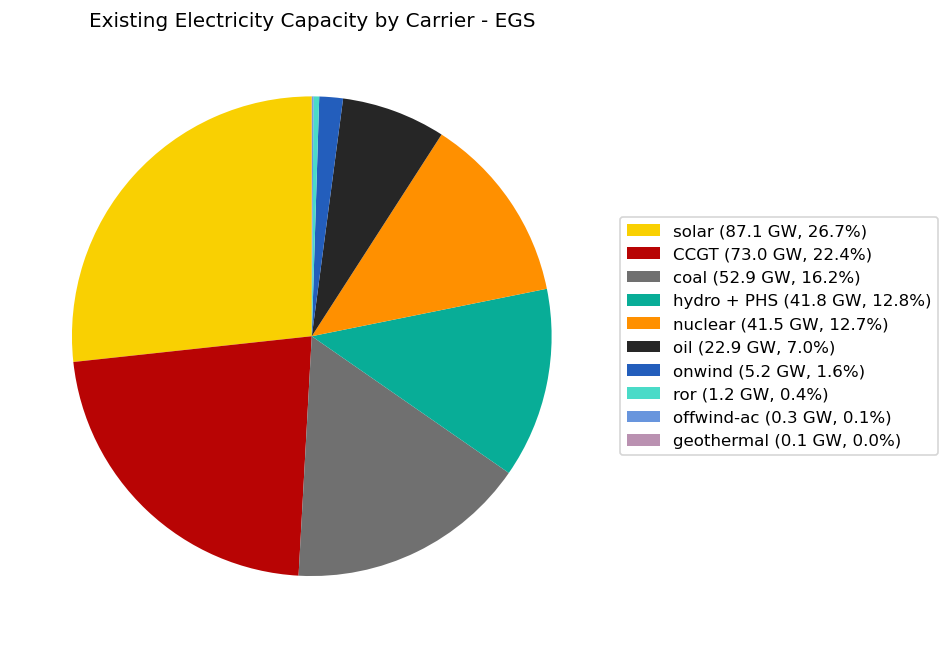

In [9]:
# ============================================================
# Existing electricity capacity by carrier
# Szenario A / bestehendes Netzwerk: n_a
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Netzwerk auswählen
# ------------------------------------------------------------

n = n_a

scenario_name = (
    SCENARIO_A_NAME
    if "SCENARIO_A_NAME" in globals()
    else "Szenario A"
)

electric_bus_carriers = ["AC", "DC", "low voltage"]


# ------------------------------------------------------------
# 1) Existing generator capacities from n.generators
# ------------------------------------------------------------

generators = n.generators.copy()

generator_capacity_by_carrier = (
    generators[
        ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
    ]
    .groupby("carrier")
    .p_nom
    .sum()
)


# ------------------------------------------------------------
# 2) Existing fossil power plant capacities from n.links
# ------------------------------------------------------------

links = n.links.copy()

# Fossil technologies that are commonly stored as links in PyPSA-Earth
fossil_pattern = (
    "coal|lignite|gas|oil|diesel|kerosene|naphta|"
    "CCGT|OCGT|CHP|solid biomass"
)

# Keep only fossil conversion links
fossil_links = links[
    links.carrier.astype(str).str.contains(
        fossil_pattern,
        case=False,
        regex=True,
        na=False
    )
].copy()

# Keep only links that produce electricity on bus1
# In PyPSA links, bus1 is normally multiplied by efficiency
fossil_links["bus1_carrier"] = fossil_links.bus1.map(n.buses.carrier)

fossil_links = fossil_links[
    fossil_links["bus1_carrier"].isin(electric_bus_carriers)
].copy()

# Convert fuel/input capacity to electric output capacity
fossil_links["electric_capacity"] = (
    fossil_links["p_nom"].fillna(0)
    * fossil_links["efficiency"].fillna(1)
)

link_capacity_by_carrier = (
    fossil_links
    .groupby("carrier")
    .electric_capacity
    .sum()
)


# ------------------------------------------------------------
# 3) Existing storage unit power capacities
# ------------------------------------------------------------

storage_units = n.storage_units.copy()

# Keep only existing/current storage units
storage_units = storage_units[
    storage_units["p_nom"].fillna(0) > 0
].copy()

# Keep only storage units connected to electricity buses
storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

storage_units = storage_units[
    storage_units["bus_carrier"].isin(electric_bus_carriers)
].copy()

storage_unit_capacity_by_carrier = (
    storage_units
    .groupby("carrier")
    .p_nom
    .sum()
)


# ------------------------------------------------------------
# 4) Combine generators, fossil links and storage units
# ------------------------------------------------------------

capacity_by_carrier_a = pd.concat(
    [
        generator_capacity_by_carrier,
        link_capacity_by_carrier,
        storage_unit_capacity_by_carrier,
    ],
    axis=0
)

# Merge PHS and hydro into one category
capacity_by_carrier_a.index = capacity_by_carrier_a.index.to_series().replace({
    "PHS": "hydro + PHS",
    "phs": "hydro + PHS",
    "hydro": "hydro + PHS",
    "Hydro": "hydro + PHS",
})

capacity_by_carrier_a = (
    capacity_by_carrier_a
    .groupby(level=0)
    .sum()
    .div(1e3)  # MW to GW
    .sort_values(ascending=False)
)

# Keep only entries > 0
capacity_by_carrier_a = capacity_by_carrier_a[
    capacity_by_carrier_a > 0
]

total_capacity_GW = capacity_by_carrier_a.sum()

print(f"{scenario_name}")
print(f"Total existing electricity capacity: {total_capacity_GW:.1f} GW")

display(
    capacity_by_carrier_a
    .rename("capacity_GW")
    .to_frame()
)


# ------------------------------------------------------------
# 5) Plot
# ------------------------------------------------------------

if "color" in n.carriers.columns:
    carrier_colors = (
        n.carriers["color"]
        .reindex(capacity_by_carrier_a.index)
        .replace("", np.nan)
    )
else:
    carrier_colors = pd.Series(
        index=capacity_by_carrier_a.index,
        data=np.nan
    )

# Use hydro color also for combined hydro + PHS category
if "hydro + PHS" in carrier_colors.index:
    if "hydro" in n.carriers.index and "color" in n.carriers.columns:
        carrier_colors.loc["hydro + PHS"] = n.carriers.loc["hydro", "color"]
    elif "PHS" in n.carriers.index and "color" in n.carriers.columns:
        carrier_colors.loc["hydro + PHS"] = n.carriers.loc["PHS", "color"]

colors = carrier_colors.fillna("#cccccc")

plt.figure(figsize=(8, 8))

wedges, _ = plt.pie(
    capacity_by_carrier_a,
    labels=None,
    startangle=90,
    colors=colors,
)

labels = [
    f"{carrier} ({capacity:.1f} GW, "
    f"{100 * capacity / capacity_by_carrier_a.sum():.1f}%)"
    for carrier, capacity in capacity_by_carrier_a.items()
]

plt.legend(
    wedges,
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
)

plt.title(f"Existing Electricity Capacity by Carrier - {scenario_name}")
plt.tight_layout()
plt.show()

EGS: 902.5 GW
without EGS: 954.9 GW


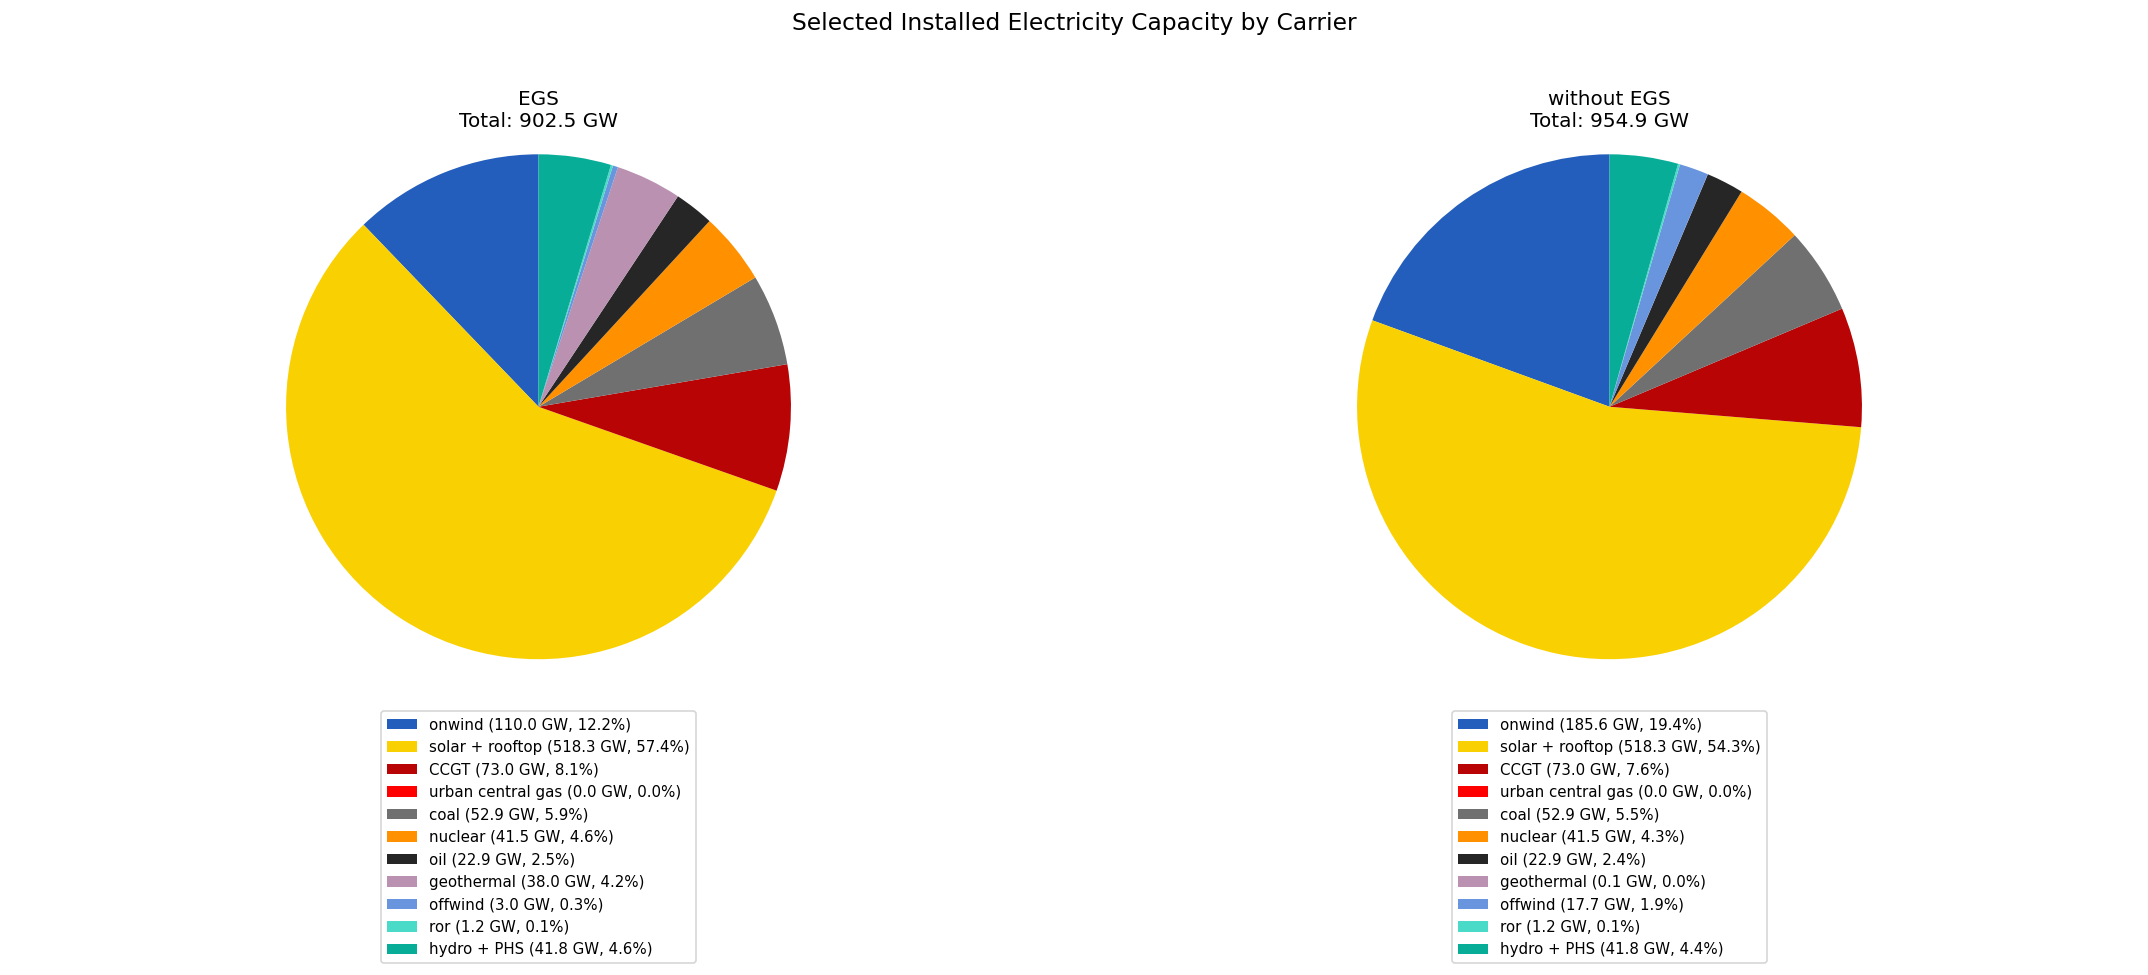

,EGS,without EGS
carrier,,
onwind,109.967128,185.619030
solar + rooftop,518.253061,518.253064
CCGT,73.019808,73.019808
urban central gas,0.000013,0.000022
coal,52.877324,52.877324
nuclear,41.482131,41.482131
oil,22.859756,22.859756
geothermal,38.042327,0.066400
offwind,2.975526,17.732975


In [10]:
# ============================================================
# Installed electricity capacity by carrier
# Vergleich: n_a vs. n_b
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

allowed_carriers_order = [
    "onwind",
    "solar + rooftop",
    "CCGT",
    "urban central gas",
    "coal",
    "nuclear",
    "oil",
    "geothermal",
    "offwind",
    "ror",
    "hydro + PHS",
]

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}


# ------------------------------------------------------------
# Helper: get final optimized capacity
# ------------------------------------------------------------

def get_nominal_capacity(df, nominal_col="p_nom"):
    """
    Returns the final nominal capacity.
    Prefer p_nom_opt if available, otherwise fall back to p_nom.
    """
    opt_col = f"{nominal_col}_opt"

    if opt_col in df.columns:
        capacity = df[opt_col].copy()

        if nominal_col in df.columns:
            capacity = capacity.fillna(df[nominal_col])

        return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0.0, index=df.index)


# ------------------------------------------------------------
# Helper: map detailed PyPSA carriers to selected display carriers
# ------------------------------------------------------------

def map_carrier(carrier):
    carrier_str = str(carrier)
    carrier_low = carrier_str.lower()

    # Solar
    if carrier_low in ["solar", "solar rooftop", "solar-rooftop"]:
        return "solar + rooftop"

    # Offshore wind
    if carrier_low.startswith("offwind"):
        return "offwind"

    # Hydro and pumped hydro storage
    if carrier_low in ["hydro", "phs", "pumped hydro storage"]:
        return "hydro + PHS"

    # Run-of-river
    if carrier_low in ["ror", "run of river", "run-of-river"]:
        return "ror"

    # Onshore wind
    if carrier_low == "onwind":
        return "onwind"

    # Fossil and nuclear technologies
    if carrier_low == "ccgt":
        return "CCGT"

    if carrier_low == "coal":
        return "coal"

    if carrier_low == "oil":
        return "oil"

    if carrier_low == "nuclear":
        return "nuclear"

    # Geothermal
    if "geothermal" in carrier_low:
        return "geothermal"

    # Urban central gas technologies, e.g. urban central gas CHP
    if "urban central gas" in carrier_low:
        return "urban central gas"

    return carrier_str


def aggregate_and_filter(series):
    """
    Map carriers, aggregate them, and keep only selected carriers.
    Input must be a Series indexed by carrier.
    """
    if series.empty:
        return pd.Series(dtype=float)

    series = series.copy()
    series.index = series.index.to_series().map(map_carrier)

    series = (
        series
        .groupby(level=0)
        .sum()
    )

    series = series[series.index.isin(allowed_carriers_order)]

    return series


# ------------------------------------------------------------
# Helper: calculate installed electricity capacity
# ------------------------------------------------------------

def calculate_installed_electric_capacity(n):
    """
    Calculates selected installed electricity capacity by carrier in GW.
    
    Includes:
    - Generators connected to electricity buses
    - Electricity-producing links
    - Storage units connected to electricity buses
    """

    # --------------------------------------------------------
    # 1) Generator capacities connected to electricity buses
    # --------------------------------------------------------

    generators = n.generators.copy()

    if not generators.empty:
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        generators = generators[
            ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
            & generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        generators["capacity_MW"] = get_nominal_capacity(generators, "p_nom")

        generator_capacity_by_carrier = (
            generators
            .groupby("carrier")["capacity_MW"]
            .sum()
        )
    else:
        generator_capacity_by_carrier = pd.Series(dtype=float)

    generator_capacity_by_carrier = aggregate_and_filter(generator_capacity_by_carrier)


    # --------------------------------------------------------
    # 2) Electricity-producing link capacities
    # --------------------------------------------------------

    links = n.links.copy()

    if not links.empty:
        links["p_nom_final"] = get_nominal_capacity(links, "p_nom")

        generation_link_pattern = (
            "coal|gas|oil|CCGT|urban central gas|geothermal"
        )

        links["is_selected_generation_link"] = links.carrier.astype(str).str.contains(
            generation_link_pattern,
            case=False,
            regex=True,
            na=False
        )

        link_capacity_parts = []

        for bus_number in range(1, 6):
            bus_col = f"bus{bus_number}"

            if bus_col not in links.columns:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(n.buses.carrier)
            input_bus_carrier = links["bus0"].map(n.buses.carrier)

            mask = (
                links["is_selected_generation_link"]
                & output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            tmp = links.loc[mask, ["carrier", "p_nom_final"]].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    tmp["efficiency_factor"] = links.loc[mask, efficiency_col].fillna(1)
                else:
                    tmp["efficiency_factor"] = links.loc[mask, efficiency_col].fillna(0)
            else:
                tmp["efficiency_factor"] = 1 if bus_number == 1 else 0

            # Convert input capacity to electrical output capacity
            tmp["capacity_MW"] = tmp["p_nom_final"] * tmp["efficiency_factor"]

            link_capacity_parts.append(tmp[["carrier", "capacity_MW"]])

        if link_capacity_parts:
            link_capacity_by_carrier = (
                pd.concat(link_capacity_parts)
                .groupby("carrier")["capacity_MW"]
                .sum()
            )
        else:
            link_capacity_by_carrier = pd.Series(dtype=float)

    else:
        link_capacity_by_carrier = pd.Series(dtype=float)

    link_capacity_by_carrier = aggregate_and_filter(link_capacity_by_carrier)


    # --------------------------------------------------------
    # 3) Storage unit power capacities
    # --------------------------------------------------------

    storage_units = n.storage_units.copy()

    if not storage_units.empty:
        storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

        storage_units = storage_units[
            storage_units["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        storage_units["capacity_MW"] = get_nominal_capacity(storage_units, "p_nom")

        storage_unit_capacity_by_carrier = (
            storage_units
            .groupby("carrier")["capacity_MW"]
            .sum()
        )
    else:
        storage_unit_capacity_by_carrier = pd.Series(dtype=float)

    storage_unit_capacity_by_carrier = aggregate_and_filter(storage_unit_capacity_by_carrier)


    # --------------------------------------------------------
    # 4) Combine generators, links and storage units
    # --------------------------------------------------------

    capacity_by_carrier = (
        pd.concat(
            [
                generator_capacity_by_carrier,
                link_capacity_by_carrier,
                storage_unit_capacity_by_carrier,
            ],
            axis=0
        )
        .groupby(level=0)
        .sum()
    )

    # Keep only selected carriers and sort by chosen order
    capacity_by_carrier = capacity_by_carrier[
        capacity_by_carrier.index.isin(allowed_carriers_order)
    ]

    capacity_by_carrier = capacity_by_carrier.reindex(allowed_carriers_order).fillna(0)

    # Convert MW to GW
    capacity_by_carrier = capacity_by_carrier.div(1e3)

    # Keep only positive capacities
    capacity_by_carrier = capacity_by_carrier[capacity_by_carrier > 0]

    return capacity_by_carrier


# ------------------------------------------------------------
# Helper: colors
# ------------------------------------------------------------

def get_carrier_colors(n, capacity_by_carrier):
    """
    Returns carrier colors from n.carriers.
    If a color is missing, grey is used.
    """

    color_source = {
        "onwind": "onwind",
        "solar + rooftop": "solar",
        "CCGT": "CCGT",
        "urban central gas": "urban central gas CHP",
        "coal": "coal",
        "nuclear": "nuclear",
        "oil": "oil",
        "geothermal": "geothermal",
        "offwind": "offwind-ac",
        "ror": "ror",
        "hydro + PHS": "hydro",
    }

    carrier_colors = []

    for carrier in capacity_by_carrier.index:
        source_carrier = color_source.get(carrier, carrier)

        if (
            hasattr(n, "carriers")
            and "color" in n.carriers.columns
            and source_carrier in n.carriers.index
        ):
            color = n.carriers.loc[source_carrier, "color"]

        elif (
            hasattr(n, "carriers")
            and "color" in n.carriers.columns
            and carrier in n.carriers.index
        ):
            color = n.carriers.loc[carrier, "color"]

        else:
            color = "#cccccc"

        if pd.isna(color) or color == "":
            color = "#cccccc"

        carrier_colors.append(color)

    return carrier_colors


# ------------------------------------------------------------
# 5) Calculate capacities for both scenarios
# ------------------------------------------------------------

capacity_results = {}

for scenario_name, network in networks_to_compare.items():
    capacity_results[scenario_name] = calculate_installed_electric_capacity(network)

    total_capacity_GW = capacity_results[scenario_name].sum()
    print(f"{scenario_name}: {total_capacity_GW:.1f} GW")


# ------------------------------------------------------------
# 6) Plot two pie charts side by side
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 8)
)

for ax, (scenario_name, network) in zip(axes, networks_to_compare.items()):

    capacity_by_carrier = capacity_results[scenario_name]
    total_capacity_GW = capacity_by_carrier.sum()

    carrier_colors = get_carrier_colors(network, capacity_by_carrier)

    wedges, _ = ax.pie(
        capacity_by_carrier,
        labels=None,
        startangle=90,
        colors=carrier_colors
    )

    labels = [
        f"{carrier} ({capacity:.1f} GW, "
        f"{100 * capacity / total_capacity_GW:.1f}%)"
        for carrier, capacity in capacity_by_carrier.items()
    ]

    ax.legend(
        wedges,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=1,
        fontsize=9
    )

    ax.set_title(
        f"{scenario_name}\n"
        f"Total: {total_capacity_GW:.1f} GW"
    )

    ax.axis("equal")


plt.suptitle(
    "Selected Installed Electricity Capacity by Carrier",
    fontsize=14,
    y=1.02
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7) Optional table output
# ------------------------------------------------------------

capacity_comparison = pd.DataFrame(capacity_results).fillna(0)

capacity_comparison.loc["Total"] = capacity_comparison.sum()

display(capacity_comparison)

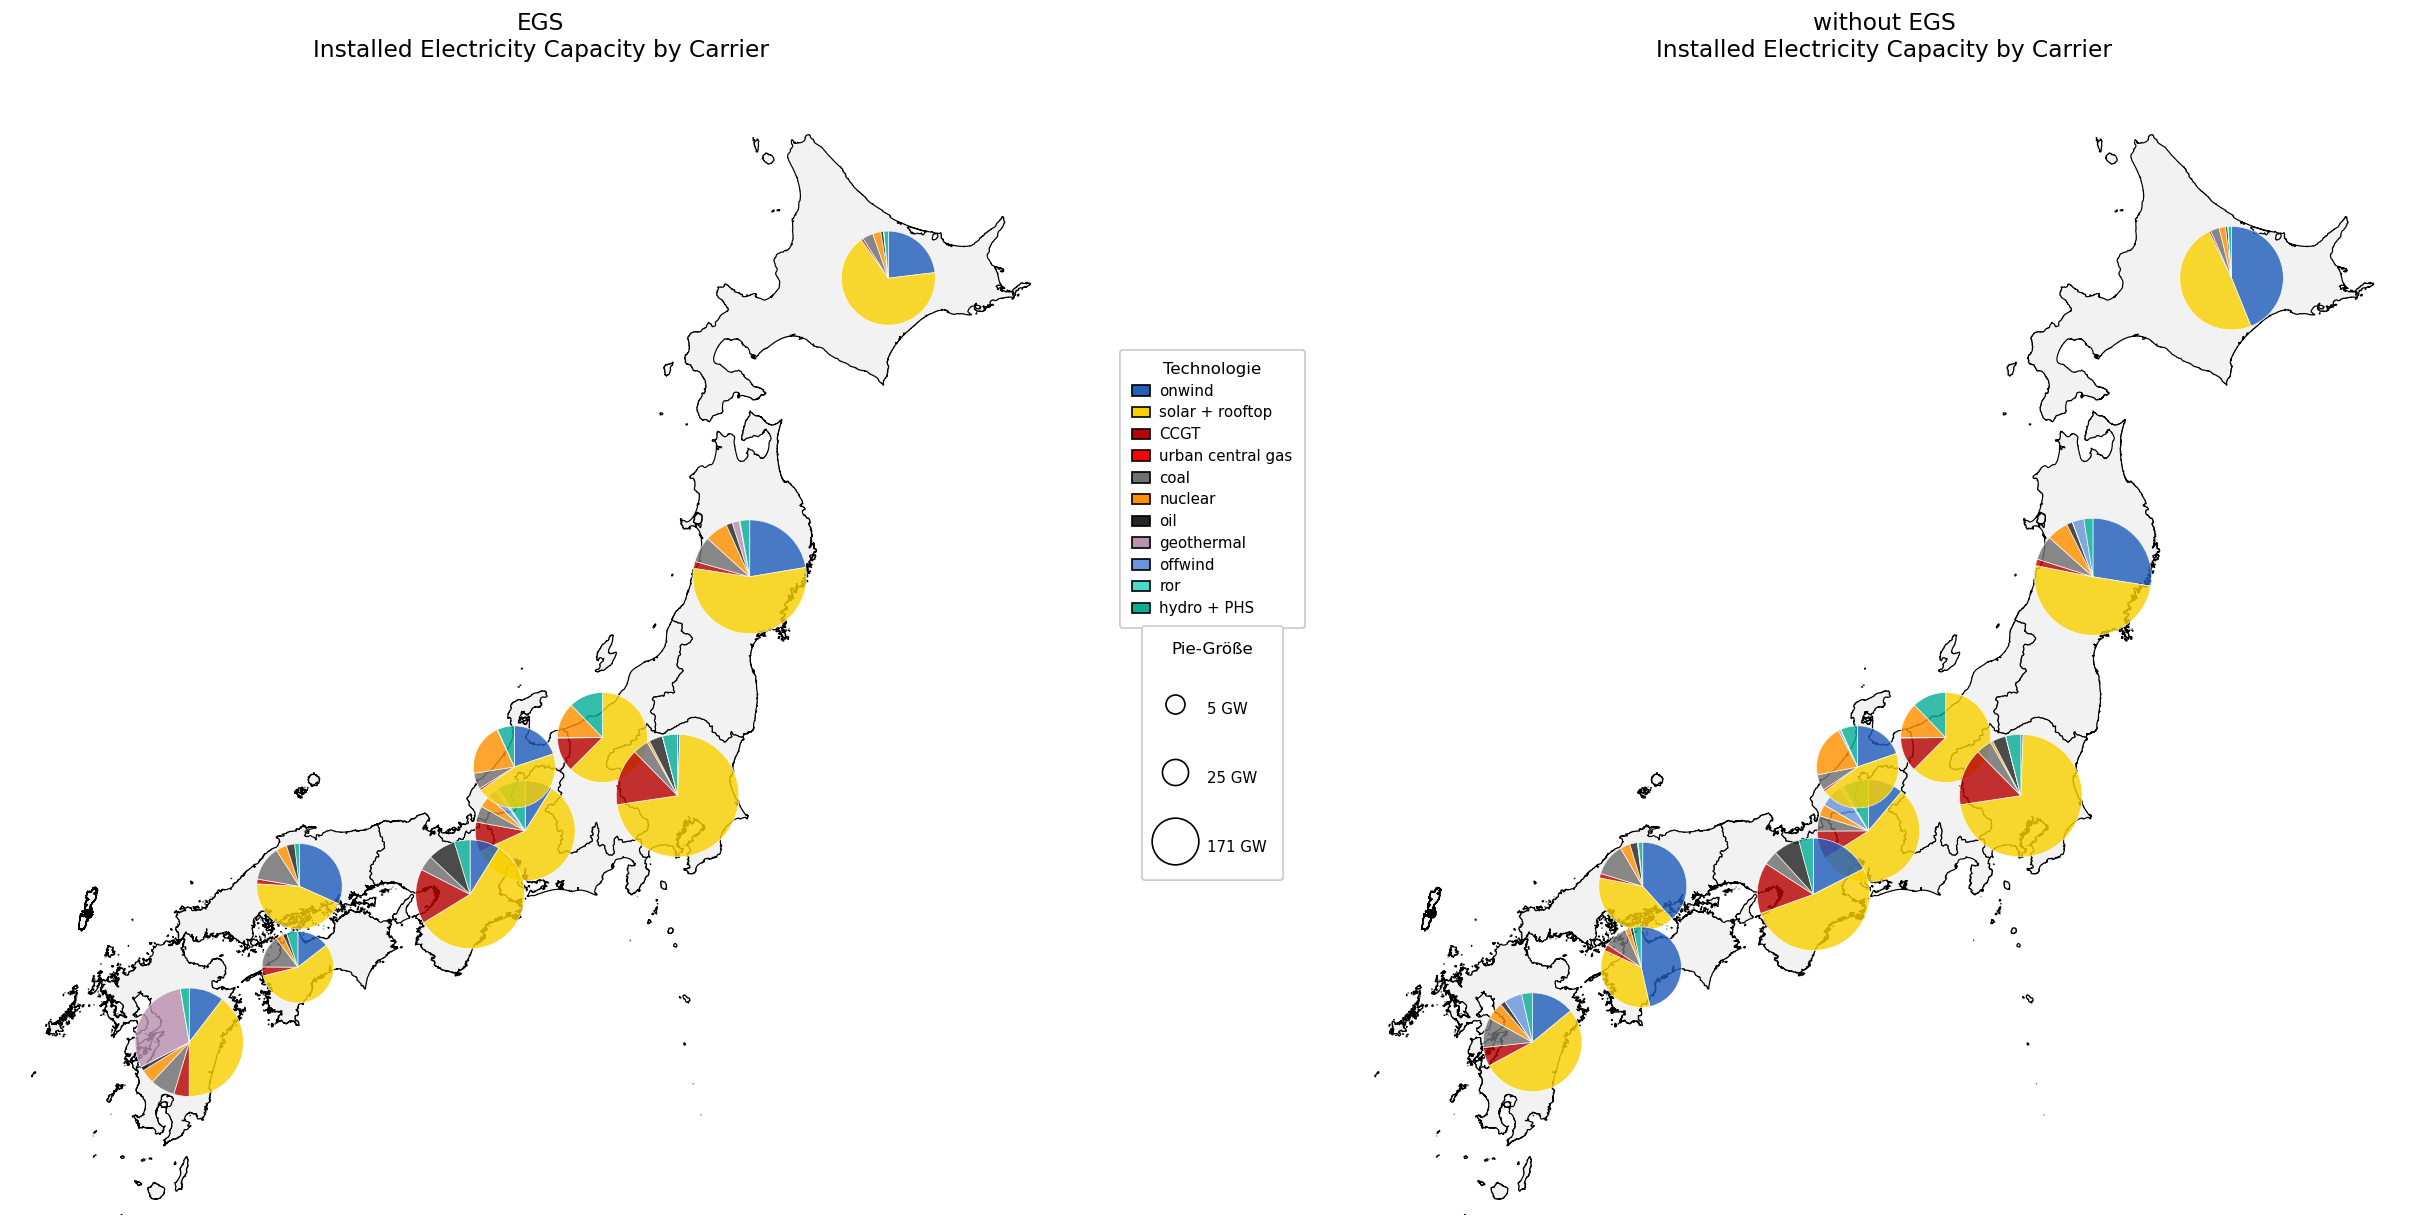

In [11]:
# ============================================================
# Zwei Karten nebeneinander:
# Szenario A vs. Szenario B
#
# Darstellung:
# - 10 Regionen
# - nur Pie-Charts je Region
# - keine Connection Lines / keine Transmission Lines
# - installierte / optimierte elektrische Leistung nach Technologie
# - inklusive fossiler Technologien wie CCGT, coal, oil, urban central gas
#
# Erwartete Variablen aus deinem Notebook:
# n_a, n_b
# gadm_shapes
# gadm_shapes_10
# GADM_SHAPES_PATH
# GADM_SHAPES_PATH_10
# ============================================================

# ============================================================
# Settings
# ============================================================

scenario_name_a = SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A"
scenario_name_b = SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B"

networks_to_plot = {
    scenario_name_a: n_a,
    scenario_name_b: n_b,
}

capacity_mode = "optimized"   # "optimized" = p_nom_opt, "current" = p_nom

electric_bus_carriers = ["AC", "DC", "low voltage"]

allowed_carriers_order = [
    "onwind",
    "solar + rooftop",
    "CCGT",
    "urban central gas",
    "coal",
    "nuclear",
    "oil",
    "geothermal",
    "offwind",
    "ror",
    "hydro + PHS",
]

generation_link_pattern = (
    "coal|lignite|gas|oil|diesel|kerosene|naphta|naphtha|"
    "CCGT|OCGT|CHP|urban central gas|geothermal"
)

simulation_gadm_level = 1
coarse_gadm_level = 1
coarse_region_id_col = "NAME_1"

map_extent = [128.0, 146.5, 30.0, 46.5]

# Pie chart settings
min_region_capacity_GW = 0.05
min_carrier_slice_GW = 0.01

pie_min_size = 0.045
pie_max_size = 0.145
pie_alpha = 0.82

# Base map style
region_fill_color = "#f2f2f2"
region_edge_color = "black"
region_linewidth = 0.7


# ============================================================
# Legend settings
# ============================================================

show_carrier_legend = True
show_size_legend = True

# Positionen in Figure-Koordinaten:
# x=0.5 liegt genau in der Mitte zwischen den beiden Karten
TECH_LEGEND_FIG_X = 0.50
TECH_LEGEND_FIG_Y = 0.6

SIZE_LEGEND_FIG_X = 0.50
SIZE_LEGEND_FIG_Y = 0.4

# Technologie-Legende
TECH_LEGEND_NCOL = 1
TECH_LEGEND_FONTSIZE = 9
TECH_LEGEND_TITLE_FONTSIZE = 10
TECH_LEGEND_FRAME_ALPHA = 0.95

# Pie-Größen-Legende
SIZE_LEGEND_FONTSIZE = 9
SIZE_LEGEND_TITLE_FONTSIZE = 10
SIZE_LEGEND_FRAME_ALPHA = 0.95

# Wichtig gegen Überlappung der Kreise
SIZE_LEGEND_LABELSPACING = 2.4
SIZE_LEGEND_HANDLEHEIGHT = 3.0
SIZE_LEGEND_BORDERPAD = 1.1

# None = automatisch aus maximaler regionaler Leistung bestimmen
manual_size_legend_values_GW = None


# ============================================================
# Helper: GADM robust laden
# ============================================================

def find_gadm_layer(gpkg_path, gadm_level):
    gpkg_path = Path(gpkg_path)

    target = f"ADM_ADM_{gadm_level}"
    layers = fiona.listlayers(str(gpkg_path))

    matches = [
        layer for layer in layers
        if layer.endswith(target) or target in layer
    ]

    if not matches:
        raise ValueError(
            f"Kein Layer für {target} in {gpkg_path} gefunden. "
            f"Vorhandene Layer: {layers}"
        )

    return matches[0]


def read_gadm_layer(gpkg_path, gadm_level):
    gpkg_path = Path(gpkg_path)

    if gpkg_path.suffix.lower() == ".gpkg":
        layer = find_gadm_layer(gpkg_path, gadm_level)
        gdf = gpd.read_file(gpkg_path, layer=layer)
    else:
        gdf = gpd.read_file(gpkg_path)

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    return gdf.to_crs("EPSG:4326")


def infer_region_id_col(gdf, gadm_level=1, allow_country_level=False):
    candidates = [
        "GADM_ID",
        f"GID_{gadm_level}",
        "GID_2",
        "GID_1",
        "region",
        "name",
        "Name",
        "NAME_2",
        "NAME_1",
        "coarse_region",
    ]

    if allow_country_level:
        candidates.append("GID_0")

    for col in candidates:
        if col in gdf.columns:
            return col

    raise ValueError(
        "Keine passende Regions-ID-Spalte gefunden. "
        f"Vorhandene Spalten: {list(gdf.columns)}"
    )


def sjoin_compat(left, right, how="left", predicate="within"):
    try:
        return gpd.sjoin(
            left,
            right,
            how=how,
            predicate=predicate,
        )
    except TypeError:
        return gpd.sjoin(
            left,
            right,
            how=how,
            op=predicate,
        )


# ============================================================
# Helper: Regionsnamen und Carrier
# ============================================================

def bus_to_region(bus_name):
    s = str(bus_name).strip()

    match = pd.Series([s]).str.extract(r"^([A-Z]{2,3}\.\d+_\d+)")[0].iloc[0]

    if pd.notna(match):
        s = match

    suffixes = [
        "_AC", "_DC",
        " AC", " DC",
        " low voltage", "_low voltage",
        " urban central heat", "_urban central heat",
        " geothermal heat", "_geothermal heat",
        " heat", "_heat",
        " gas", "_gas",
        " oil", "_oil",
        " coal", "_coal",
        " biomass", "_biomass",
        " H2", "_H2",
        " import H2 port", "_import H2 port",
        " H2 port", "_H2 port",
        " import", "_import",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    if s.startswith("JPN."):
        s = "JP." + s[len("JPN."):]

    return s


def normalize_region_id(region_id):
    return bus_to_region(region_id)


def get_nominal_capacity(df, nominal_col="p_nom", mode="optimized"):
    opt_col = f"{nominal_col}_opt"

    if mode == "optimized" and opt_col in df.columns:
        capacity = df[opt_col].copy()

        if nominal_col in df.columns:
            capacity = capacity.fillna(df[nominal_col])

        return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0.0, index=df.index)


def get_bus_columns(df):
    bus_cols = [
        col for col in df.columns
        if col.startswith("bus") and col[3:].isdigit()
    ]

    return sorted(
        bus_cols,
        key=lambda x: int(x.replace("bus", ""))
    )


def map_carrier(carrier):
    carrier_str = str(carrier)
    carrier_low = carrier_str.lower()

    if carrier_low in ["solar", "solar rooftop", "solar-rooftop"]:
        return "solar + rooftop"

    if carrier_low.startswith("offwind"):
        return "offwind"

    if carrier_low in ["hydro", "phs", "pumped hydro storage"]:
        return "hydro + PHS"

    if carrier_low in ["ror", "run of river", "run-of-river"]:
        return "ror"

    if carrier_low == "onwind":
        return "onwind"

    if carrier_low == "ccgt" or "ccgt" in carrier_low:
        return "CCGT"

    if carrier_low == "ocgt":
        return "CCGT"

    if "urban central gas" in carrier_low:
        return "urban central gas"

    if "coal" in carrier_low or "lignite" in carrier_low:
        return "coal"

    if (
        carrier_low == "oil"
        or "oil" in carrier_low
        or "diesel" in carrier_low
        or "kerosene" in carrier_low
        or "naphta" in carrier_low
        or "naphtha" in carrier_low
    ):
        return "oil"

    if carrier_low == "nuclear" or "nuclear" in carrier_low:
        return "nuclear"

    if "geothermal" in carrier_low:
        return "geothermal"

    return carrier_str


# ============================================================
# GADM vorbereiten
# ============================================================

def prepare_fine_regions(gadm_shapes_loaded, gadm_path, gadm_level=1):
    regions = gadm_shapes_loaded.copy()

    if regions.crs is None:
        regions = regions.set_crs("EPSG:4326")

    regions = regions.to_crs("EPSG:4326")

    try:
        region_id_col = infer_region_id_col(
            regions,
            gadm_level=gadm_level,
            allow_country_level=False,
        )
    except ValueError:
        regions = read_gadm_layer(
            gadm_path,
            gadm_level,
        )

        region_id_col = infer_region_id_col(
            regions,
            gadm_level=gadm_level,
            allow_country_level=False,
        )

    regions["region"] = (
        regions[region_id_col]
        .astype(str)
        .map(normalize_region_id)
    )

    return regions


def prepare_coarse_regions(gadm_shapes_10_loaded, gadm_path_10, gadm_level=1):
    coarse_regions = gadm_shapes_10_loaded.copy()

    if coarse_regions.crs is None:
        coarse_regions = coarse_regions.set_crs("EPSG:4326")

    coarse_regions = coarse_regions.to_crs("EPSG:4326")

    global coarse_region_id_col

    if coarse_region_id_col not in coarse_regions.columns:
        try:
            coarse_region_id_col = infer_region_id_col(
                coarse_regions,
                gadm_level=gadm_level,
                allow_country_level=False,
            )
        except ValueError:
            coarse_regions = read_gadm_layer(
                gadm_path_10,
                gadm_level,
            )

            if coarse_region_id_col not in coarse_regions.columns:
                coarse_region_id_col = infer_region_id_col(
                    coarse_regions,
                    gadm_level=gadm_level,
                    allow_country_level=False,
                )

    coarse_regions["coarse_region"] = (
        coarse_regions[coarse_region_id_col]
        .astype(str)
        .str.strip()
    )

    return coarse_regions


def build_fine_to_coarse_mapping(fine_regions, coarse_regions):
    fine = fine_regions.copy().to_crs("EPSG:4326")
    coarse = coarse_regions.copy().to_crs("EPSG:4326")

    fine_points = fine[["region", "geometry"]].copy()
    fine_points["geometry"] = fine_points.geometry.representative_point()

    mapping = sjoin_compat(
        fine_points,
        coarse[["coarse_region", "geometry"]],
        how="left",
        predicate="within",
    )

    mapping = mapping[["region", "coarse_region"]].drop_duplicates()

    return mapping


# ============================================================
# Elektrische Leistung je feiner Region berechnen
# ============================================================

def get_electric_capacity_by_fine_region(network):
    capacity_parts = []

    # --------------------------------------------------------
    # 1) Generatoren
    # --------------------------------------------------------

    if hasattr(network, "generators") and not network.generators.empty:
        generators = network.generators.copy()

        generators["bus_carrier"] = generators.bus.map(network.buses.carrier)

        generators = generators[
            ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
            & ~generators.carrier.astype(str).str.lower().eq("geothermal heat")
            & generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not generators.empty:
            generators["capacity_MW"] = get_nominal_capacity(
                generators,
                "p_nom",
                mode=capacity_mode,
            )

            generators["region"] = generators.bus.map(normalize_region_id)
            generators["carrier_mapped"] = generators.carrier.map(map_carrier)

            gen_capacity = (
                generators
                .groupby(["region", "carrier_mapped"])["capacity_MW"]
                .sum()
            )

            capacity_parts.append(gen_capacity)

    # --------------------------------------------------------
    # 2) Storage Units
    # --------------------------------------------------------

    if hasattr(network, "storage_units") and not network.storage_units.empty:
        storage_units = network.storage_units.copy()

        storage_units["bus_carrier"] = storage_units.bus.map(network.buses.carrier)

        storage_units = storage_units[
            storage_units["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not storage_units.empty:
            storage_units["capacity_MW"] = get_nominal_capacity(
                storage_units,
                "p_nom",
                mode=capacity_mode,
            )

            storage_units["region"] = storage_units.bus.map(normalize_region_id)
            storage_units["carrier_mapped"] = storage_units.carrier.map(map_carrier)

            sto_capacity = (
                storage_units
                .groupby(["region", "carrier_mapped"])["capacity_MW"]
                .sum()
            )

            capacity_parts.append(sto_capacity)

    # --------------------------------------------------------
    # 3) Stromerzeugende Links
    # --------------------------------------------------------

    if hasattr(network, "links") and not network.links.empty:
        links = network.links.copy()

        links["p_nom_final"] = get_nominal_capacity(
            links,
            "p_nom",
            mode=capacity_mode,
        )

        links["is_selected_generation_link"] = (
            links.carrier
            .astype(str)
            .str.contains(
                generation_link_pattern,
                case=False,
                regex=True,
                na=False,
            )
        )

        link_capacity_parts = []

        bus_cols = get_bus_columns(links)

        for bus_col in bus_cols:
            bus_number = int(bus_col.replace("bus", ""))

            if bus_number == 0:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(network.buses.carrier)
            input_bus_carrier = links["bus0"].map(network.buses.carrier)

            mask = (
                links["is_selected_generation_link"]
                & output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            tmp = links.loc[mask, ["carrier", "p_nom_final", bus_col]].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    tmp["efficiency_factor"] = links.loc[mask, efficiency_col].fillna(1)
                else:
                    tmp["efficiency_factor"] = links.loc[mask, efficiency_col].fillna(0)
            else:
                tmp["efficiency_factor"] = 1 if bus_number == 1 else 0

            tmp["capacity_MW"] = (
                tmp["p_nom_final"]
                * tmp["efficiency_factor"]
            )

            tmp["region"] = tmp[bus_col].map(normalize_region_id)
            tmp["carrier_mapped"] = tmp.carrier.map(map_carrier)

            tmp = tmp[
                tmp["carrier_mapped"].isin(allowed_carriers_order)
            ].copy()

            if tmp.empty:
                continue

            link_capacity = (
                tmp
                .groupby(["region", "carrier_mapped"])["capacity_MW"]
                .sum()
            )

            link_capacity_parts.append(link_capacity)

        if link_capacity_parts:
            link_capacity = (
                pd.concat(link_capacity_parts)
                .groupby(level=[0, 1])
                .sum()
            )

            capacity_parts.append(link_capacity)

    # --------------------------------------------------------
    # 4) Combine
    # --------------------------------------------------------

    if not capacity_parts:
        return pd.DataFrame(columns=allowed_carriers_order)

    capacity_by_region_carrier = (
        pd.concat(capacity_parts)
        .groupby(level=[0, 1])
        .sum()
    )

    capacity_df = (
        capacity_by_region_carrier
        .unstack("carrier_mapped")
        .fillna(0)
    )

    capacity_df = capacity_df.reindex(columns=allowed_carriers_order).fillna(0)

    return capacity_df


# ============================================================
# Feine Werte auf 10 Regionen aggregieren
# ============================================================

def aggregate_capacity_to_coarse_regions(capacity_fine_df, fine_regions, coarse_regions):
    fine_values = fine_regions[["region", "geometry"]].copy()

    for carrier in allowed_carriers_order:
        if carrier in capacity_fine_df.columns:
            fine_values[carrier] = (
                fine_values["region"]
                .map(capacity_fine_df[carrier])
                .fillna(0)
            )
        else:
            fine_values[carrier] = 0.0

    mapping = build_fine_to_coarse_mapping(
        fine_regions=fine_regions,
        coarse_regions=coarse_regions,
    )

    values_with_mapping = fine_values.drop(columns="geometry").merge(
        mapping,
        on="region",
        how="left",
    )

    aggregated = (
        values_with_mapping
        .dropna(subset=["coarse_region"])
        .groupby("coarse_region")[allowed_carriers_order]
        .sum()
        .reset_index()
    )

    plot_regions = coarse_regions.merge(
        aggregated,
        on="coarse_region",
        how="left",
    )

    for carrier in allowed_carriers_order:
        plot_regions[carrier] = plot_regions[carrier].fillna(0)

    plot_regions["total_capacity_MW"] = plot_regions[allowed_carriers_order].sum(axis=1)
    plot_regions["total_capacity_GW"] = plot_regions["total_capacity_MW"] / 1e3

    return plot_regions


# ============================================================
# Farben
# ============================================================

default_carrier_colors = {
    "onwind": "#235ebc",
    "solar + rooftop": "#f9d002",
    "CCGT": "#b20101",
    "urban central gas": "#d35050",
    "coal": "#707070",
    "nuclear": "#ff9000",
    "oil": "#262626",
    "geothermal": "#ba91b1",
    "offwind": "#6895dd",
    "ror": "#78c6a3",
    "hydro + PHS": "#08ad97",
}

color_source = {
    "onwind": "onwind",
    "solar + rooftop": "solar",
    "CCGT": "CCGT",
    "urban central gas": "urban central gas CHP",
    "coal": "coal",
    "nuclear": "nuclear",
    "oil": "oil",
    "geothermal": "geothermal",
    "offwind": "offwind-ac",
    "ror": "ror",
    "hydro + PHS": "hydro",
}


def get_carrier_color(carrier, networks):
    source_carrier = color_source.get(carrier, carrier)

    for network in networks:
        if (
            hasattr(network, "carriers")
            and source_carrier in network.carriers.index
            and "color" in network.carriers.columns
        ):
            color = network.carriers.loc[source_carrier, "color"]

            if pd.notna(color) and str(color).strip() != "":
                return color

        if (
            hasattr(network, "carriers")
            and carrier in network.carriers.index
            and "color" in network.carriers.columns
        ):
            color = network.carriers.loc[carrier, "color"]

            if pd.notna(color) and str(color).strip() != "":
                return color

    return default_carrier_colors.get(carrier, "#cccccc")


carrier_color_map = {
    carrier: get_carrier_color(carrier, list(networks_to_plot.values()))
    for carrier in allowed_carriers_order
}


# ============================================================
# Pie chart helper
# ============================================================

def data_to_axes_fraction(ax, x, y):
    display = ax.transData.transform((x, y))
    ax_frac = ax.transAxes.inverted().transform(display)
    return ax_frac


def add_regional_pies(
    ax,
    plot_regions,
    carriers,
    carrier_colors,
    global_max_total_GW,
    min_region_capacity_GW=0.05,
    min_carrier_slice_GW=0.01,
):
    if plot_regions.empty:
        return

    regions_with_pies = plot_regions[
        plot_regions["total_capacity_GW"] > min_region_capacity_GW
    ].copy()

    if regions_with_pies.empty:
        return

    regions_with_pies["label_point"] = regions_with_pies.geometry.representative_point()
    regions_with_pies["lon"] = regions_with_pies["label_point"].x
    regions_with_pies["lat"] = regions_with_pies["label_point"].y

    for _, row in regions_with_pies.iterrows():
        total_GW = row["total_capacity_GW"]

        if total_GW <= min_region_capacity_GW:
            continue

        values_GW = row[carriers].astype(float) / 1e3
        values_GW = values_GW[values_GW > min_carrier_slice_GW]

        if values_GW.empty:
            continue

        if global_max_total_GW > 0:
            scale = np.sqrt(total_GW / global_max_total_GW)
        else:
            scale = 0.5

        pie_size = pie_min_size + (pie_max_size - pie_min_size) * scale

        x_ax, y_ax = data_to_axes_fraction(
            ax,
            row["lon"],
            row["lat"],
        )

        left = x_ax - pie_size / 2
        bottom = y_ax - pie_size / 2

        left = np.clip(left, 0.002, 1.0 - pie_size - 0.002)
        bottom = np.clip(bottom, 0.002, 1.0 - pie_size - 0.002)

        inset = ax.inset_axes(
            [left, bottom, pie_size, pie_size],
            transform=ax.transAxes,
        )

        colors = [
            carrier_colors.get(carrier, "#cccccc")
            for carrier in values_GW.index
        ]

        inset.pie(
            values_GW.values,
            colors=colors,
            startangle=90,
            counterclock=False,
            wedgeprops=dict(
                linewidth=0.45,
                edgecolor="white",
                alpha=pie_alpha,
            ),
        )

        inset.set_aspect("equal")
        inset.set_xticks([])
        inset.set_yticks([])
        inset.set_facecolor("none")

        for spine in inset.spines.values():
            spine.set_visible(False)


# ============================================================
# Pie-Größen-Legende
# ============================================================

def get_size_legend_values(max_total_GW):
    if manual_size_legend_values_GW is not None:
        return manual_size_legend_values_GW

    if max_total_GW >= 100:
        return [5, 25, round(max_total_GW)]
    elif max_total_GW >= 50:
        return [5, 20, round(max_total_GW)]
    elif max_total_GW >= 20:
        return [2, 10, round(max_total_GW)]
    elif max_total_GW >= 10:
        return [1, 5, round(max_total_GW)]
    elif max_total_GW >= 5:
        return [1, 3, round(max_total_GW)]
    else:
        return [0.5, 1, round(max_total_GW, 1)]


def make_capacity_size_legend_handles(max_total_GW):
    if max_total_GW <= 0:
        return []

    size_values = get_size_legend_values(max_total_GW)
    size_values = sorted(set([v for v in size_values if v > 0]))

    handles = []

    for value in size_values:
        scale = np.sqrt(value / max_total_GW)

        # Nur für die Legende begrenzt, damit sich Kreise nicht überschneiden
        marker_size = 8 + 20 * scale

        handles.append(
            plt.Line2D(
                [],
                [],
                marker="o",
                linestyle="None",
                markersize=marker_size,
                markerfacecolor="white",
                markeredgecolor="black",
                markeredgewidth=1.0,
                label=f"{value:g} GW",
            )
        )

    return handles


# ============================================================
# Daten vorbereiten
# ============================================================

if "gadm_shapes" not in globals() or gadm_shapes is None:
    raise ValueError("gadm_shapes ist nicht geladen.")

if "gadm_shapes_10" not in globals() or gadm_shapes_10 is None:
    raise ValueError("gadm_shapes_10 ist nicht geladen.")

fine_regions = prepare_fine_regions(
    gadm_shapes_loaded=gadm_shapes,
    gadm_path=GADM_SHAPES_PATH,
    gadm_level=simulation_gadm_level,
)

coarse_regions = prepare_coarse_regions(
    gadm_shapes_10_loaded=gadm_shapes_10,
    gadm_path_10=GADM_SHAPES_PATH_10,
    gadm_level=coarse_gadm_level,
)

plot_regions_by_scenario = {}

for scenario_name, network in networks_to_plot.items():
    fine_capacity = get_electric_capacity_by_fine_region(network)

    plot_regions = aggregate_capacity_to_coarse_regions(
        capacity_fine_df=fine_capacity,
        fine_regions=fine_regions,
        coarse_regions=coarse_regions,
    )

    plot_regions_by_scenario[scenario_name] = plot_regions


global_max_total_GW = max(
    plot_regions["total_capacity_GW"].max()
    for plot_regions in plot_regions_by_scenario.values()
)

used_carriers = []

for carrier in allowed_carriers_order:
    total = sum(
        plot_regions[carrier].sum()
        for plot_regions in plot_regions_by_scenario.values()
        if carrier in plot_regions.columns
    )

    if total > 0:
        used_carriers.append(carrier)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, 11),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for ax, (scenario_name, plot_regions) in zip(
    axes,
    plot_regions_by_scenario.items(),
):
    plot_regions.plot(
        ax=ax,
        color=region_fill_color,
        edgecolor=region_edge_color,
        linewidth=region_linewidth,
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(
        f"{scenario_name}\nInstalled Electricity Capacity by Carrier",
        fontsize=14,
    )

    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.axis("off")

# Wichtig: Canvas zuerst zeichnen, damit inset-Positionen stimmen
fig.canvas.draw()

for ax, (scenario_name, plot_regions) in zip(
    axes,
    plot_regions_by_scenario.items(),
):
    add_regional_pies(
        ax=ax,
        plot_regions=plot_regions,
        carriers=allowed_carriers_order,
        carrier_colors=carrier_color_map,
        global_max_total_GW=global_max_total_GW,
        min_region_capacity_GW=min_region_capacity_GW,
        min_carrier_slice_GW=min_carrier_slice_GW,
    )


# ------------------------------------------------------------
# Legenden zentral zwischen den Karten
# ------------------------------------------------------------

plt.subplots_adjust(
    wspace=0.18,
    left=0.03,
    right=0.97,
    top=0.92,
    bottom=0.05
)


# ------------------------------------------------------------
# Technologie-Legende mittig
# ------------------------------------------------------------

if show_carrier_legend and used_carriers:
    carrier_handles = [
        mpatches.Patch(
            facecolor=carrier_color_map.get(carrier, "#cccccc"),
            edgecolor="black",
            label=carrier,
        )
        for carrier in used_carriers
    ]

    tech_legend = fig.legend(
        handles=carrier_handles,
        title="Technologie",
        loc="center",
        bbox_to_anchor=(TECH_LEGEND_FIG_X, TECH_LEGEND_FIG_Y),
        ncol=TECH_LEGEND_NCOL,
        fontsize=TECH_LEGEND_FONTSIZE,
        title_fontsize=TECH_LEGEND_TITLE_FONTSIZE,
        frameon=True,
        framealpha=TECH_LEGEND_FRAME_ALPHA,
        borderpad=0.8,
        labelspacing=0.45,
        handlelength=1.2,
        handletextpad=0.6,
    )

    fig.add_artist(tech_legend)


# ------------------------------------------------------------
# Pie-Größen-Legende mittig, ohne überlappende Kreise
# ------------------------------------------------------------

if show_size_legend:
    size_handles = make_capacity_size_legend_handles(global_max_total_GW)

    if size_handles:
        size_legend = fig.legend(
            handles=size_handles,
            title="Pie-Größe",
            loc="center",
            bbox_to_anchor=(SIZE_LEGEND_FIG_X, SIZE_LEGEND_FIG_Y),
            ncol=1,
            fontsize=SIZE_LEGEND_FONTSIZE,
            title_fontsize=SIZE_LEGEND_TITLE_FONTSIZE,
            frameon=True,
            framealpha=SIZE_LEGEND_FRAME_ALPHA,
            borderpad=SIZE_LEGEND_BORDERPAD,
            labelspacing=SIZE_LEGEND_LABELSPACING,
            handleheight=SIZE_LEGEND_HANDLEHEIGHT,
            handlelength=2.2,
            handletextpad=1.0,
        )

        fig.add_artist(size_legend)


plt.show()

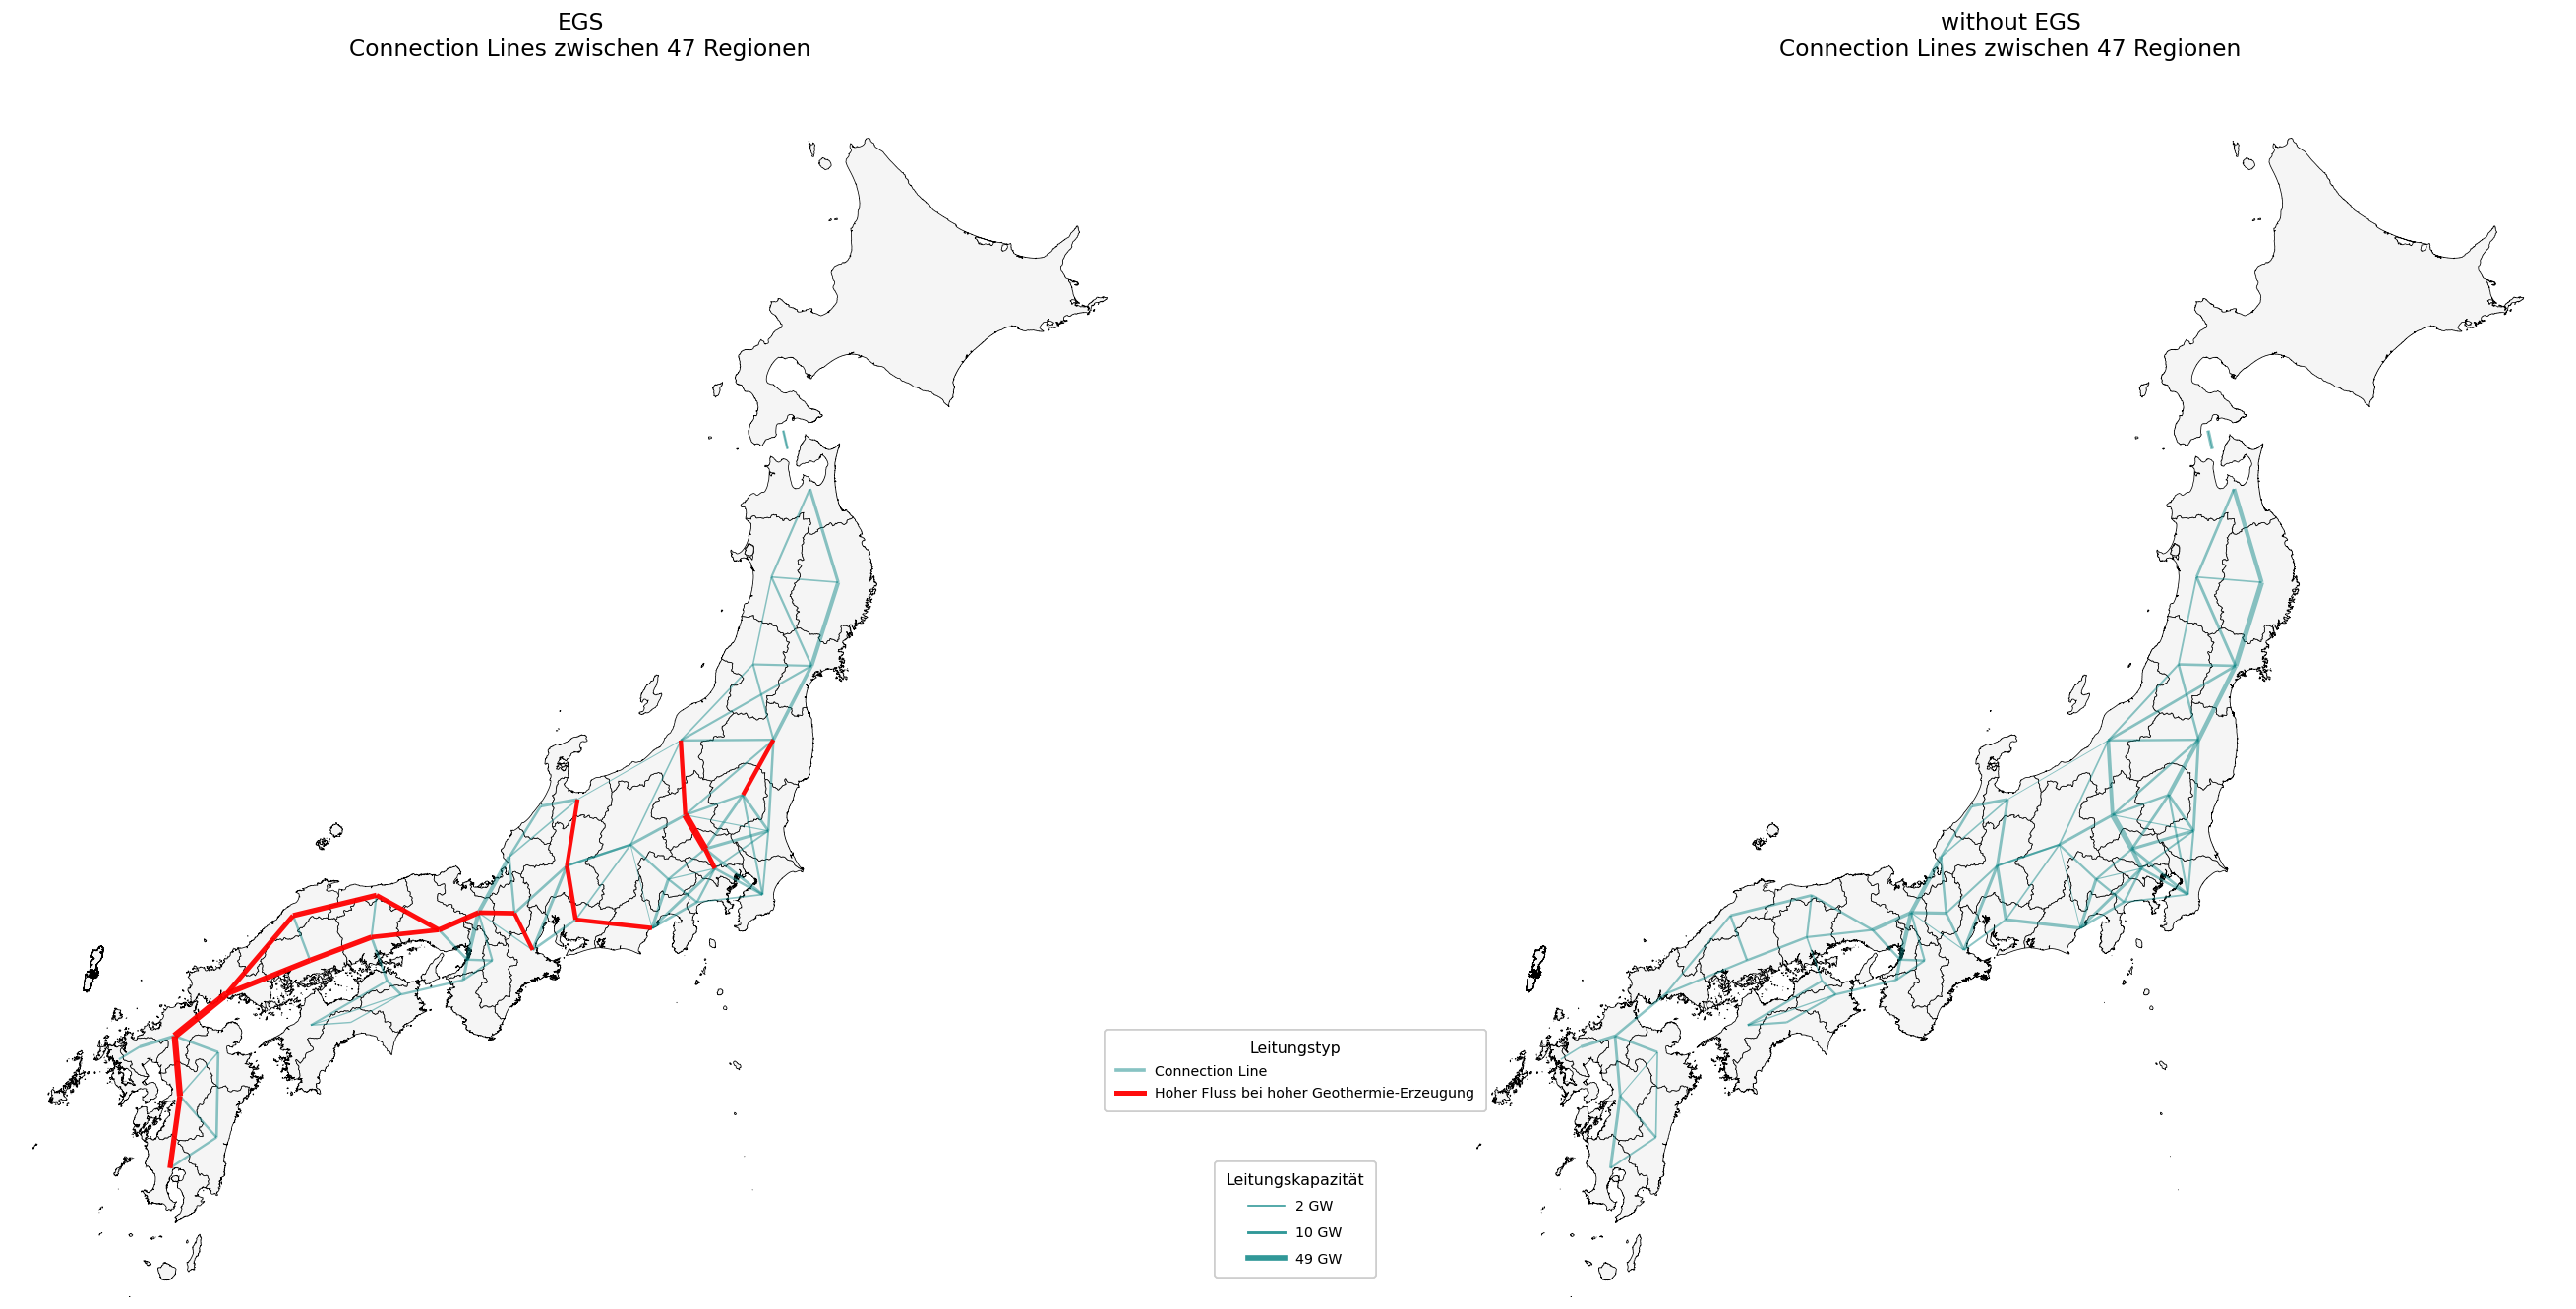

In [12]:
# ============================================================
# Zwei Karten nebeneinander:
# Szenario A vs. Szenario B
#
# Darstellung:
# - 47 GADM-Regionen
# - Connection Lines zwischen elektrischen Gebieten
# - keine Pie-Charts
# - rote Connection Lines = hohe Flüsse in Zeiten hoher Geothermie-Erzeugung
#
# Hinweis:
# PyPSA speichert keine direkte Herkunft einzelner Leitungsflüsse.
# Die roten Linien sind deshalb ein Proxy:
# Welche Leitungen sind besonders stark ausgelastet,
# wenn Geothermie-Erzeugung hoch ist?
#
# Erwartete Variablen:
# n_a, n_b
# gadm_shapes
# GADM_SHAPES_PATH
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import fiona
import warnings
from pathlib import Path
from shapely.geometry import LineString

warnings.simplefilter(action="ignore", category=UserWarning)


# ============================================================
# Settings
# ============================================================

scenario_name_a = SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A"
scenario_name_b = SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B"

networks_to_plot = {
    scenario_name_a: n_a,
    scenario_name_b: n_b,
}

electric_bus_carriers = ["AC", "DC", "low voltage"]

simulation_gadm_level = 1

# Japan extent
map_extent = [128.0, 146.5, 30.0, 46.5]

# ------------------------------------------------------------
# Region style
# ------------------------------------------------------------

region_fill_color = "whitesmoke"
region_edge_color = "black"
region_linewidth = 0.45

# ------------------------------------------------------------
# Connection line settings
# ------------------------------------------------------------

normal_line_color = "teal"
geothermal_line_color = "red"

normal_line_alpha = 0.45
geothermal_line_alpha = 0.95

line_width_min = 0.35
line_width_max = 3.4

# Welche Leitungen werden rot?
# Top-Geothermie-Zeiten werden über geo_snapshot_quantile bestimmt.
# Dann werden Leitungen rot markiert, deren Fluss in diesen Zeiten besonders hoch ist.
geo_snapshot_quantile = 0.75
geo_line_flow_quantile = 0.80

# Mindestfluss in Zeiten hoher Geothermie-Erzeugung [TWh]
min_geo_flow_proxy_TWh = 0.01

# Falls ein Szenario nur sehr wenig Geothermie-Strom erzeugt,
# werden keine roten Linien gezeigt.
# Bei dir verhindert das z.B. rote Linien im "without EGS"-Szenario,
# falls dort nur minimale bestehende Geothermie vorhanden ist.
min_total_geothermal_generation_TWh_for_red = 1.0

# ------------------------------------------------------------
# Legend settings
# ------------------------------------------------------------

show_line_color_legend = True
show_line_width_legend = True

LINE_COLOR_LEGEND_FIG_X = 0.50
LINE_COLOR_LEGEND_FIG_Y = 0.21

LINE_WIDTH_LEGEND_FIG_X = 0.50
LINE_WIDTH_LEGEND_FIG_Y = 0.105

LINE_LEGEND_FONTSIZE = 8.5
LINE_LEGEND_TITLE_FONTSIZE = 9.5

WIDTH_LEGEND_FONTSIZE = 8.5
WIDTH_LEGEND_TITLE_FONTSIZE = 9.5

# None = automatisch aus maximaler Leitungskapazität bestimmen
manual_line_width_legend_values_GW = None


# ============================================================
# Helper: GADM robust laden
# ============================================================

def find_gadm_layer(gpkg_path, gadm_level):
    gpkg_path = Path(gpkg_path)

    target = f"ADM_ADM_{gadm_level}"
    layers = fiona.listlayers(str(gpkg_path))

    matches = [
        layer for layer in layers
        if layer.endswith(target) or target in layer
    ]

    if not matches:
        raise ValueError(
            f"Kein Layer für {target} in {gpkg_path} gefunden. "
            f"Vorhandene Layer: {layers}"
        )

    return matches[0]


def read_gadm_layer(gpkg_path, gadm_level):
    gpkg_path = Path(gpkg_path)

    if gpkg_path.suffix.lower() == ".gpkg":
        layer = find_gadm_layer(gpkg_path, gadm_level)
        gdf = gpd.read_file(gpkg_path, layer=layer)
    else:
        gdf = gpd.read_file(gpkg_path)

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    return gdf.to_crs("EPSG:4326")


def infer_region_id_col(gdf, gadm_level=1):
    candidates = [
        "GADM_ID",
        f"GID_{gadm_level}",
        "GID_2",
        "GID_1",
        "region",
        "name",
        "Name",
        "NAME_2",
        "NAME_1",
    ]

    for col in candidates:
        if col in gdf.columns:
            return col

    raise ValueError(
        "Keine passende Regions-ID-Spalte gefunden. "
        f"Vorhandene Spalten: {list(gdf.columns)}"
    )


def bus_to_region(bus_name):
    s = str(bus_name).strip()

    match = pd.Series([s]).str.extract(r"^([A-Z]{2,3}\.\d+_\d+)")[0].iloc[0]

    if pd.notna(match):
        s = match

    suffixes = [
        "_AC", "_DC",
        " AC", " DC",
        " low voltage", "_low voltage",
        " urban central heat", "_urban central heat",
        " geothermal heat", "_geothermal heat",
        " heat", "_heat",
        " gas", "_gas",
        " oil", "_oil",
        " coal", "_coal",
        " biomass", "_biomass",
        " H2", "_H2",
        " import H2 port", "_import H2 port",
        " H2 port", "_H2 port",
        " import", "_import",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    if s.startswith("JPN."):
        s = "JP." + s[len("JPN."):]

    return s


def normalize_region_id(region_id):
    return bus_to_region(region_id)


def prepare_fine_regions(gadm_shapes_loaded, gadm_path, gadm_level=1):
    regions = gadm_shapes_loaded.copy()

    if regions.crs is None:
        regions = regions.set_crs("EPSG:4326")

    regions = regions.to_crs("EPSG:4326")

    try:
        region_id_col = infer_region_id_col(
            regions,
            gadm_level=gadm_level,
        )
    except ValueError:
        regions = read_gadm_layer(
            gadm_path,
            gadm_level,
        )

        region_id_col = infer_region_id_col(
            regions,
            gadm_level=gadm_level,
        )

    regions["region"] = (
        regions[region_id_col]
        .astype(str)
        .map(normalize_region_id)
    )

    return regions


# ============================================================
# Snapshot weights
# ============================================================

def get_snapshot_weights(network):
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)

        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    if hasattr(sw, "generators"):
        return sw.generators.reindex(network.snapshots).astype(float).fillna(1.0)

    if hasattr(sw, "objective"):
        return sw.objective.reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


def get_bus_columns(df):
    bus_cols = [
        col for col in df.columns
        if col.startswith("bus") and col[3:].isdigit()
    ]

    return sorted(
        bus_cols,
        key=lambda x: int(x.replace("bus", ""))
    )


# ============================================================
# Geothermie-Erzeugung
# ============================================================

def get_geothermal_electric_generation_total(network):
    """
    Gibt die gesamte geothermische Stromerzeugung je Snapshot in MW zurück.
    Gezählt werden:
    - Geothermal generators auf elektrischen Bussen
    - Geothermal links mit Output auf elektrischen Bussen
    """
    geo_ts_parts = []

    # --------------------------------------------------------
    # Geothermal generators
    # --------------------------------------------------------

    if hasattr(network, "generators") and hasattr(network, "generators_t"):
        generators = network.generators.copy()

        generators["bus_carrier"] = generators.bus.map(network.buses.carrier)

        geo_gens = generators[
            generators.carrier.astype(str).str.contains(
                "geothermal",
                case=False,
                regex=True,
                na=False,
            )
            & generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if (
            not geo_gens.empty
            and hasattr(network.generators_t, "p")
        ):
            available_gens = geo_gens.index.intersection(network.generators_t.p.columns)

            if len(available_gens) > 0:
                gen_ts = (
                    network.generators_t.p
                    .reindex(index=network.snapshots, columns=available_gens)
                    .fillna(0)
                    .clip(lower=0)
                    .sum(axis=1)
                )

                geo_ts_parts.append(gen_ts)

    # --------------------------------------------------------
    # Geothermal links producing electricity
    # --------------------------------------------------------

    if hasattr(network, "links") and hasattr(network, "links_t"):
        links = network.links.copy()

        geo_links = links[
            links.carrier.astype(str).str.contains(
                "geothermal",
                case=False,
                regex=True,
                na=False,
            )
        ].copy()

        if not geo_links.empty:
            bus_cols = get_bus_columns(geo_links)

            for bus_col in bus_cols:
                bus_number = int(bus_col.replace("bus", ""))

                if bus_number == 0:
                    continue

                p_col = f"p{bus_number}"

                if not hasattr(network.links_t, p_col):
                    continue

                output_bus_carrier = geo_links[bus_col].map(network.buses.carrier)

                mask = output_bus_carrier.isin(electric_bus_carriers)

                if not mask.any():
                    continue

                selected_links = geo_links.loc[mask].copy()

                available_links = selected_links.index.intersection(
                    getattr(network.links_t, p_col).columns
                )

                if len(available_links) == 0:
                    continue

                link_output_ts = (
                    -getattr(network.links_t, p_col)
                    .reindex(index=network.snapshots, columns=available_links)
                    .fillna(0)
                )

                link_output_ts = (
                    link_output_ts
                    .clip(lower=0)
                    .sum(axis=1)
                )

                geo_ts_parts.append(link_output_ts)

    if not geo_ts_parts:
        return pd.Series(0.0, index=network.snapshots)

    geo_total = (
        pd.concat(geo_ts_parts, axis=1)
        .sum(axis=1)
        .reindex(network.snapshots)
        .fillna(0)
    )

    return geo_total


# ============================================================
# Connection Lines
# ============================================================

def get_connection_geometries(network):
    """
    Erstellt GeoDataFrame für:
    - AC lines
    - electric-electric links
    """
    rows = []

    # --------------------------------------------------------
    # AC lines
    # --------------------------------------------------------

    if hasattr(network, "lines") and not network.lines.empty:
        lines = network.lines.copy()

        for name, line in lines.iterrows():
            bus0 = line.get("bus0")
            bus1 = line.get("bus1")

            if bus0 not in network.buses.index or bus1 not in network.buses.index:
                continue

            bus0_carrier = network.buses.loc[bus0, "carrier"]
            bus1_carrier = network.buses.loc[bus1, "carrier"]

            if bus0_carrier not in electric_bus_carriers:
                continue

            if bus1_carrier not in electric_bus_carriers:
                continue

            x0 = network.buses.loc[bus0, "x"]
            y0 = network.buses.loc[bus0, "y"]
            x1 = network.buses.loc[bus1, "x"]
            y1 = network.buses.loc[bus1, "y"]

            if pd.isna(x0) or pd.isna(y0) or pd.isna(x1) or pd.isna(y1):
                continue

            capacity_MW = line.get("s_nom_opt", np.nan)

            if pd.isna(capacity_MW) or capacity_MW <= 0:
                capacity_MW = line.get("s_nom", 0.0)

            rows.append({
                "component": "Line",
                "name": name,
                "bus0": bus0,
                "bus1": bus1,
                "region0": normalize_region_id(bus0),
                "region1": normalize_region_id(bus1),
                "capacity_MW": float(capacity_MW) if pd.notna(capacity_MW) else 0.0,
                "geometry": LineString([(x0, y0), (x1, y1)]),
            })

    # --------------------------------------------------------
    # Electric-electric links
    # --------------------------------------------------------

    if hasattr(network, "links") and not network.links.empty:
        links = network.links.copy()

        for name, link in links.iterrows():
            bus0 = link.get("bus0")
            bus1 = link.get("bus1")

            if bus0 not in network.buses.index or bus1 not in network.buses.index:
                continue

            bus0_carrier = network.buses.loc[bus0, "carrier"]
            bus1_carrier = network.buses.loc[bus1, "carrier"]

            if bus0_carrier not in electric_bus_carriers:
                continue

            if bus1_carrier not in electric_bus_carriers:
                continue

            x0 = network.buses.loc[bus0, "x"]
            y0 = network.buses.loc[bus0, "y"]
            x1 = network.buses.loc[bus1, "x"]
            y1 = network.buses.loc[bus1, "y"]

            if pd.isna(x0) or pd.isna(y0) or pd.isna(x1) or pd.isna(y1):
                continue

            capacity_MW = link.get("p_nom_opt", np.nan)

            if pd.isna(capacity_MW) or capacity_MW <= 0:
                capacity_MW = link.get("p_nom", 0.0)

            rows.append({
                "component": "Link",
                "name": name,
                "bus0": bus0,
                "bus1": bus1,
                "region0": normalize_region_id(bus0),
                "region1": normalize_region_id(bus1),
                "capacity_MW": float(capacity_MW) if pd.notna(capacity_MW) else 0.0,
                "geometry": LineString([(x0, y0), (x1, y1)]),
            })

    if not rows:
        return gpd.GeoDataFrame(
            columns=[
                "component",
                "name",
                "bus0",
                "bus1",
                "region0",
                "region1",
                "capacity_MW",
                "geometry",
            ],
            geometry="geometry",
            crs="EPSG:4326",
        )

    return gpd.GeoDataFrame(
        rows,
        geometry="geometry",
        crs="EPSG:4326",
    )


def filter_connections_to_regions(connections, valid_regions):
    """
    Behalte nur Verbindungen zwischen den 47 GADM-Regionen.
    """
    if connections.empty:
        return connections

    valid_regions = set(valid_regions)

    connections = connections[
        connections["region0"].isin(valid_regions)
        & connections["region1"].isin(valid_regions)
        & (connections["region0"] != connections["region1"])
        & (connections["capacity_MW"].fillna(0) > 0)
    ].copy()

    return connections


def get_geothermal_flow_proxy_by_connection(network, connections_gdf):
    """
    Proxy:
    Summe der absoluten Leitungsflüsse in den Zeitschritten mit hoher
    Geothermie-Erzeugung.

    Einheit: TWh über gewichtete Snapshots.
    """
    if connections_gdf.empty:
        return pd.Series(dtype=float)

    weights = get_snapshot_weights(network)

    geo_total = get_geothermal_electric_generation_total(network)

    total_geo_generation_TWh = (
        geo_total
        .mul(weights.reindex(network.snapshots).fillna(1.0), axis=0)
        .sum()
        / 1e6
    )

    if total_geo_generation_TWh < min_total_geothermal_generation_TWh_for_red:
        return pd.Series(0.0, index=connections_gdf.index)

    if geo_total.max() <= 0:
        return pd.Series(0.0, index=connections_gdf.index)

    threshold = geo_total.quantile(geo_snapshot_quantile)

    high_geo_snapshots = geo_total[
        geo_total >= threshold
    ].index

    if len(high_geo_snapshots) == 0:
        return pd.Series(0.0, index=connections_gdf.index)

    weights_high_geo = weights.reindex(high_geo_snapshots).fillna(1.0)

    flow_proxy = pd.Series(0.0, index=connections_gdf.index)

    # --------------------------------------------------------
    # AC lines
    # --------------------------------------------------------

    line_rows = connections_gdf[
        connections_gdf["component"] == "Line"
    ].copy()

    if (
        not line_rows.empty
        and hasattr(network, "lines_t")
        and hasattr(network.lines_t, "p0")
    ):
        available_lines = pd.Index(line_rows["name"]).intersection(
            network.lines_t.p0.columns
        )

        if len(available_lines) > 0:
            line_flows_MWh = (
                network.lines_t.p0
                .reindex(index=high_geo_snapshots, columns=available_lines)
                .fillna(0)
                .abs()
                .mul(weights_high_geo, axis=0)
                .sum(axis=0)
            )

            for idx, row in line_rows.iterrows():
                flow_proxy.loc[idx] = (
                    line_flows_MWh.get(row["name"], 0.0) / 1e6
                )

    # --------------------------------------------------------
    # Electric-electric links
    # --------------------------------------------------------

    link_rows = connections_gdf[
        connections_gdf["component"] == "Link"
    ].copy()

    if (
        not link_rows.empty
        and hasattr(network, "links_t")
        and hasattr(network.links_t, "p0")
    ):
        available_links = pd.Index(link_rows["name"]).intersection(
            network.links_t.p0.columns
        )

        if len(available_links) > 0:
            link_flows_MWh = (
                network.links_t.p0
                .reindex(index=high_geo_snapshots, columns=available_links)
                .fillna(0)
                .abs()
                .mul(weights_high_geo, axis=0)
                .sum(axis=0)
            )

            for idx, row in link_rows.iterrows():
                flow_proxy.loc[idx] = (
                    link_flows_MWh.get(row["name"], 0.0) / 1e6
                )

    return flow_proxy


def prepare_connections_for_plot(network, valid_regions):
    connections = get_connection_geometries(network)

    connections = filter_connections_to_regions(
        connections,
        valid_regions=valid_regions,
    )

    if connections.empty:
        return connections

    connections["geo_flow_proxy_TWh"] = get_geothermal_flow_proxy_by_connection(
        network,
        connections,
    )

    nonzero_geo_flows = connections.loc[
        connections["geo_flow_proxy_TWh"] > min_geo_flow_proxy_TWh,
        "geo_flow_proxy_TWh",
    ]

    if not nonzero_geo_flows.empty:
        red_threshold = nonzero_geo_flows.quantile(geo_line_flow_quantile)
    else:
        red_threshold = np.inf

    connections["is_high_geothermal_flow"] = (
        connections["geo_flow_proxy_TWh"] >= red_threshold
    ) & (
        connections["geo_flow_proxy_TWh"] > min_geo_flow_proxy_TWh
    )

    return connections


def assign_line_widths(connections, global_max_capacity_MW):
    if connections.empty:
        connections["line_width"] = line_width_min
        return connections

    connections = connections.copy()

    if global_max_capacity_MW > 0:
        connections["line_width"] = (
            line_width_min
            + (line_width_max - line_width_min)
            * np.sqrt(
                connections["capacity_MW"].clip(lower=0)
                / global_max_capacity_MW
            )
        )
    else:
        connections["line_width"] = line_width_min

    return connections


# ============================================================
# Legenden
# ============================================================

def get_line_width_legend_values(max_capacity_GW):
    if manual_line_width_legend_values_GW is not None:
        return manual_line_width_legend_values_GW

    if max_capacity_GW >= 50:
        return [5, 20, round(max_capacity_GW)]
    elif max_capacity_GW >= 20:
        return [2, 10, round(max_capacity_GW)]
    elif max_capacity_GW >= 10:
        return [1, 5, round(max_capacity_GW)]
    elif max_capacity_GW >= 5:
        return [1, 3, round(max_capacity_GW)]
    else:
        return [0.5, 1, round(max_capacity_GW, 1)]


def line_width_from_capacity_GW(capacity_GW, global_max_capacity_MW):
    capacity_MW = capacity_GW * 1e3

    if global_max_capacity_MW <= 0:
        return line_width_min

    return (
        line_width_min
        + (line_width_max - line_width_min)
        * np.sqrt(capacity_MW / global_max_capacity_MW)
    )


def make_line_width_legend_handles(global_max_capacity_MW):
    if global_max_capacity_MW <= 0:
        return []

    max_capacity_GW = global_max_capacity_MW / 1e3

    values_GW = get_line_width_legend_values(max_capacity_GW)
    values_GW = sorted(set([v for v in values_GW if v > 0]))

    handles = []

    for value_GW in values_GW:
        width = line_width_from_capacity_GW(
            value_GW,
            global_max_capacity_MW,
        )

        handles.append(
            mlines.Line2D(
                [],
                [],
                color=normal_line_color,
                linewidth=width,
                alpha=0.8,
                label=f"{value_GW:g} GW",
            )
        )

    return handles


# ============================================================
# Daten vorbereiten
# ============================================================

if "gadm_shapes" not in globals() or gadm_shapes is None:
    raise ValueError("gadm_shapes ist nicht geladen.")

fine_regions = prepare_fine_regions(
    gadm_shapes_loaded=gadm_shapes,
    gadm_path=GADM_SHAPES_PATH,
    gadm_level=simulation_gadm_level,
)

valid_regions = fine_regions["region"].unique().tolist()

connections_by_scenario = {}

for scenario_name, network in networks_to_plot.items():
    connections_by_scenario[scenario_name] = prepare_connections_for_plot(
        network,
        valid_regions=valid_regions,
    )

global_max_capacity_MW = max(
    (
        connections["capacity_MW"].max()
        if not connections.empty else 0
    )
    for connections in connections_by_scenario.values()
)

for scenario_name in connections_by_scenario:
    connections_by_scenario[scenario_name] = assign_line_widths(
        connections_by_scenario[scenario_name],
        global_max_capacity_MW=global_max_capacity_MW,
    )


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(24, 12),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

for ax, (scenario_name, network) in zip(axes, networks_to_plot.items()):

    # 47 Regionen
    fine_regions.plot(
        ax=ax,
        color=region_fill_color,
        edgecolor=region_edge_color,
        linewidth=region_linewidth,
        transform=ccrs.PlateCarree(),
        zorder=0,
    )

    connections = connections_by_scenario[scenario_name]

    if not connections.empty:

        normal_connections = connections[
            ~connections["is_high_geothermal_flow"]
        ].copy()

        geothermal_connections = connections[
            connections["is_high_geothermal_flow"]
        ].copy()

        if not normal_connections.empty:
            normal_connections.plot(
                ax=ax,
                color=normal_line_color,
                linewidth=normal_connections["line_width"].to_numpy(),
                alpha=normal_line_alpha,
                transform=ccrs.PlateCarree(),
                zorder=3,
            )

        if not geothermal_connections.empty:
            geothermal_connections.plot(
                ax=ax,
                color=geothermal_line_color,
                linewidth=(geothermal_connections["line_width"] * 1.25).to_numpy(),
                alpha=geothermal_line_alpha,
                transform=ccrs.PlateCarree(),
                zorder=4,
            )

    ax.set_title(
        f"{scenario_name}\nConnection Lines zwischen 47 Regionen",
        fontsize=14,
    )

    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.axis("off")


# ------------------------------------------------------------
# Zentraler Platz für Legenden
# ------------------------------------------------------------

plt.subplots_adjust(
    wspace=0.16,
    left=0.03,
    right=0.97,
    top=0.92,
    bottom=0.05,
)


# ------------------------------------------------------------
# Linien-Farblegende
# ------------------------------------------------------------

if show_line_color_legend:
    line_color_handles = [
        mlines.Line2D(
            [],
            [],
            color=normal_line_color,
            linewidth=2.2,
            alpha=normal_line_alpha,
            label="Connection Line",
        ),
        mlines.Line2D(
            [],
            [],
            color=geothermal_line_color,
            linewidth=3.0,
            alpha=geothermal_line_alpha,
            label="Hoher Fluss bei hoher Geothermie-Erzeugung",
        ),
    ]

    line_color_legend = fig.legend(
        handles=line_color_handles,
        title="Leitungstyp",
        loc="center",
        bbox_to_anchor=(LINE_COLOR_LEGEND_FIG_X, LINE_COLOR_LEGEND_FIG_Y),
        ncol=1,
        fontsize=LINE_LEGEND_FONTSIZE,
        title_fontsize=LINE_LEGEND_TITLE_FONTSIZE,
        frameon=True,
        framealpha=0.95,
        borderpad=0.8,
        labelspacing=0.6,
    )

    fig.add_artist(line_color_legend)


# ------------------------------------------------------------
# Linien-Breitenlegende
# ------------------------------------------------------------

if show_line_width_legend:
    width_handles = make_line_width_legend_handles(global_max_capacity_MW)

    if width_handles:
        line_width_legend = fig.legend(
            handles=width_handles,
            title="Leitungskapazität",
            loc="center",
            bbox_to_anchor=(LINE_WIDTH_LEGEND_FIG_X, LINE_WIDTH_LEGEND_FIG_Y),
            ncol=1,
            fontsize=WIDTH_LEGEND_FONTSIZE,
            title_fontsize=WIDTH_LEGEND_TITLE_FONTSIZE,
            frameon=True,
            framealpha=0.95,
            borderpad=0.8,
            labelspacing=0.9,
            handlelength=2.6,
        )

        fig.add_artist(line_width_legend)


plt.show()

warnings.simplefilter(action="default", category=UserWarning)

EGS: 591.59 GW
without EGS: 644.77 GW


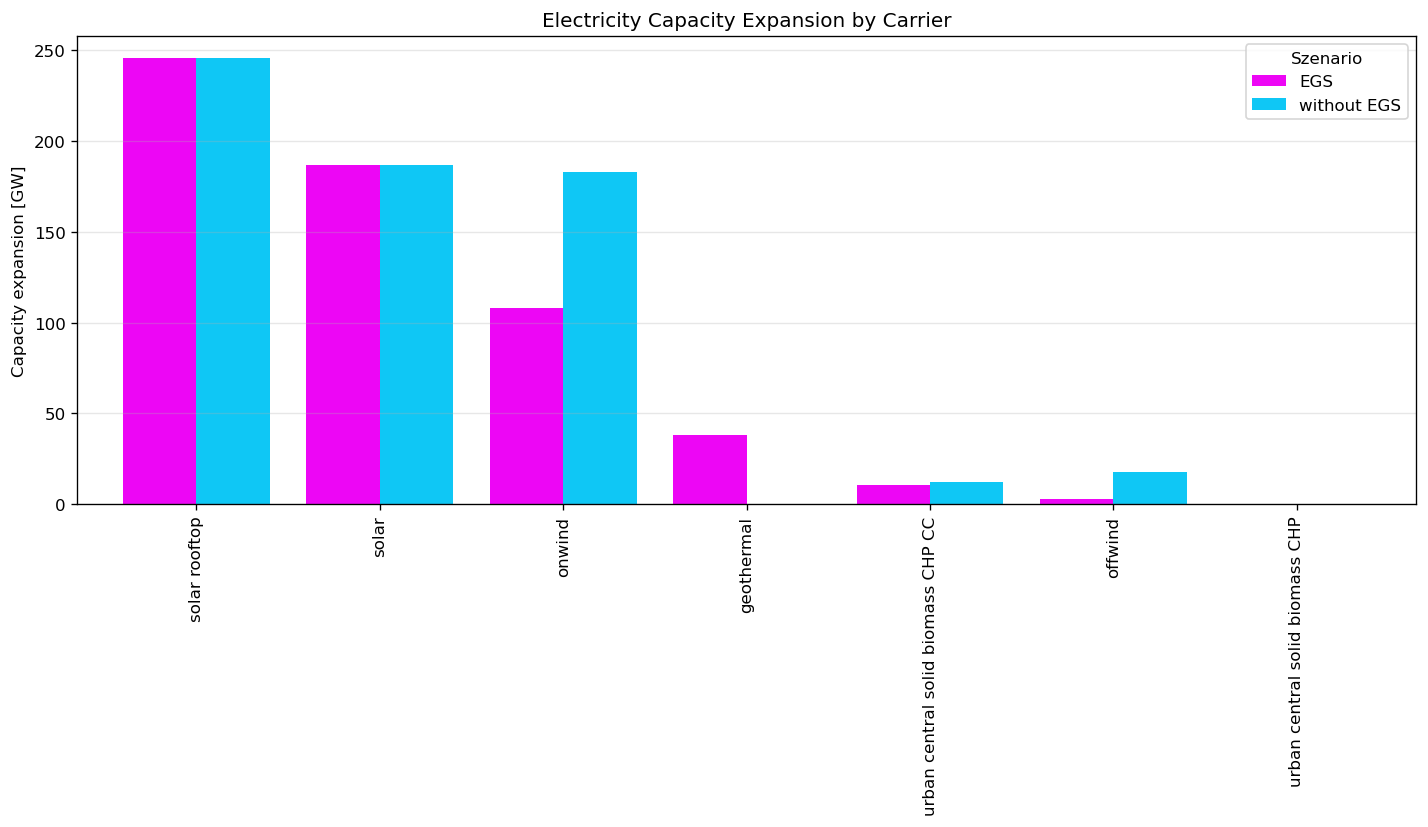

,EGS,without EGS
carrier,,
solar rooftop,245.688666,245.688669
solar,186.651103,186.651104
onwind,108.044598,182.881040
geothermal,37.975927,0.000000
urban central solid biomass CHP CC,10.571445,12.094095
offwind,2.661526,17.418975
urban central solid biomass CHP,0.000000,0.040820
Total,591.593267,644.774701


In [13]:
# ============================================================
# Electricity capacity expansion by carrier
# Vergleich: n_a vs. n_b
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Minimum expansion shown in the plot [GW]
min_expansion_GW = 0.001

# Optional carrier grouping
merge_solar_rooftop = False
merge_hydro_phs = True
merge_offwind = True

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def get_capacity(df, column="p_nom"):
    """
    Return capacity column if it exists, otherwise zero.
    """
    if column in df.columns:
        return df[column].fillna(0)

    return pd.Series(0.0, index=df.index)


def map_carrier(carrier):
    """
    Map detailed carriers to grouped display names.
    """
    carrier_str = str(carrier)
    carrier_low = carrier_str.lower()

    if merge_solar_rooftop:
        if carrier_low in ["solar", "solar rooftop", "solar-rooftop"]:
            return "solar + rooftop"

    if merge_hydro_phs:
        if carrier_low in ["hydro", "phs", "pumped hydro storage"]:
            return "hydro + PHS"

    if merge_offwind:
        if carrier_low.startswith("offwind"):
            return "offwind"

    if "urban central gas" in carrier_low:
        return "urban central gas"

    if "geothermal" in carrier_low:
        return "geothermal"

    if carrier_low == "ccgt":
        return "CCGT"

    if carrier_low == "ocgt":
        return "OCGT"

    return carrier_str


def aggregate_expansion(series):
    """
    Map carrier names and aggregate expansion by carrier.
    """
    if series.empty:
        return pd.Series(dtype=float)

    series = series.copy()
    series.index = series.index.to_series().map(map_carrier)

    return series.groupby(level=0).sum()


def calculate_capacity_expansion_by_carrier(n):
    """
    Calculates electricity capacity expansion by carrier in GW.

    Expansion = p_nom_opt - p_nom

    Includes:
    - Generators connected to electricity buses
    - StorageUnits connected to electricity buses
    - Links that produce electricity from non-electric input carriers
    """

    # --------------------------------------------------------
    # 1) Generator capacity expansion
    # --------------------------------------------------------

    generators = n.generators.copy()

    if not generators.empty:
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        generators = generators[
            ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
            & generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        generators["installed_capacity_MW"] = get_capacity(generators, "p_nom")
        generators["optimal_capacity_MW"] = get_capacity(generators, "p_nom_opt")

        generators["capacity_expansion_MW"] = (
            generators["optimal_capacity_MW"]
            - generators["installed_capacity_MW"]
        ).clip(lower=0)

        generator_expansion_by_carrier = (
            generators
            .groupby("carrier")["capacity_expansion_MW"]
            .sum()
        )
    else:
        generator_expansion_by_carrier = pd.Series(dtype=float)

    generator_expansion_by_carrier = aggregate_expansion(generator_expansion_by_carrier)


    # --------------------------------------------------------
    # 2) StorageUnit power capacity expansion
    # --------------------------------------------------------

    storage_units = n.storage_units.copy()

    if not storage_units.empty:
        storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

        storage_units = storage_units[
            storage_units["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        storage_units["installed_capacity_MW"] = get_capacity(storage_units, "p_nom")
        storage_units["optimal_capacity_MW"] = get_capacity(storage_units, "p_nom_opt")

        storage_units["capacity_expansion_MW"] = (
            storage_units["optimal_capacity_MW"]
            - storage_units["installed_capacity_MW"]
        ).clip(lower=0)

        storage_expansion_by_carrier = (
            storage_units
            .groupby("carrier")["capacity_expansion_MW"]
            .sum()
        )
    else:
        storage_expansion_by_carrier = pd.Series(dtype=float)

    storage_expansion_by_carrier = aggregate_expansion(storage_expansion_by_carrier)


    # --------------------------------------------------------
    # 3) Link electricity generation capacity expansion
    # --------------------------------------------------------

    links = n.links.copy()

    if not links.empty:
        links["installed_capacity_MW"] = get_capacity(links, "p_nom")
        links["optimal_capacity_MW"] = get_capacity(links, "p_nom_opt")

        links["input_expansion_MW"] = (
            links["optimal_capacity_MW"]
            - links["installed_capacity_MW"]
        ).clip(lower=0)

        link_expansion_parts = []

        # In PyPSA links:
        # p_nom is input-side capacity.
        # Electrical output capacity on bus1 = p_nom * efficiency
        # Electrical output capacity on bus2 = p_nom * efficiency2
        # etc.
        for bus_number in range(1, 6):
            bus_col = f"bus{bus_number}"

            if bus_col not in links.columns:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(n.buses.carrier)
            input_bus_carrier = links["bus0"].map(n.buses.carrier)

            # Count only links that produce electricity from a non-electric input.
            # This avoids counting grid links, transmission, chargers, etc.
            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            selected_links = links.loc[mask].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    efficiency = links.loc[mask, efficiency_col].fillna(1)
                else:
                    efficiency = links.loc[mask, efficiency_col].fillna(0)
            else:
                efficiency = 1 if bus_number == 1 else 0

            selected_links["electric_expansion_MW"] = (
                selected_links["input_expansion_MW"]
                * efficiency
            )

            tmp = (
                selected_links
                .groupby("carrier")["electric_expansion_MW"]
                .sum()
            )

            link_expansion_parts.append(tmp)

        if link_expansion_parts:
            link_expansion_by_carrier = (
                pd.concat(link_expansion_parts)
                .groupby(level=0)
                .sum()
            )
        else:
            link_expansion_by_carrier = pd.Series(dtype=float)

    else:
        link_expansion_by_carrier = pd.Series(dtype=float)

    link_expansion_by_carrier = aggregate_expansion(link_expansion_by_carrier)


    # --------------------------------------------------------
    # 4) Combine all electricity capacity expansion
    # --------------------------------------------------------

    capacity_expansion_by_carrier = (
        pd.concat(
            [
                generator_expansion_by_carrier,
                storage_expansion_by_carrier,
                link_expansion_by_carrier,
            ],
            axis=0
        )
        .groupby(level=0)
        .sum()
        .div(1e3)  # MW to GW
    )

    # Keep only positive expansion
    capacity_expansion_by_carrier = capacity_expansion_by_carrier[
        capacity_expansion_by_carrier > min_expansion_GW
    ]

    return capacity_expansion_by_carrier


# ------------------------------------------------------------
# 5) Calculate both scenarios
# ------------------------------------------------------------

expansion_results = {}

for scenario_name, network in networks_to_compare.items():
    expansion_results[scenario_name] = calculate_capacity_expansion_by_carrier(network)

capacity_expansion_comparison = pd.DataFrame(expansion_results).fillna(0)

# Keep only carriers expanded in at least one scenario
capacity_expansion_comparison = capacity_expansion_comparison[
    capacity_expansion_comparison.sum(axis=1) > min_expansion_GW
]

# Sort by total expansion over both scenarios
capacity_expansion_comparison = capacity_expansion_comparison.loc[
    capacity_expansion_comparison.sum(axis=1).sort_values(ascending=False).index
]

# Print totals
for scenario_name in capacity_expansion_comparison.columns:
    total_expansion_GW = capacity_expansion_comparison[scenario_name].sum()
    print(f"{scenario_name}: {total_expansion_GW:.2f} GW")


# ------------------------------------------------------------
# 6) Plot grouped bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

capacity_expansion_comparison.plot.bar(
    ax=ax,
    width=0.8,
    color=["#ed06f5", "#0fc7f5"]
)

ax.set_title("Electricity Capacity Expansion by Carrier")
ax.set_ylabel("Capacity expansion [GW]")
ax.set_xlabel("")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    ha="center"
)

ax.legend(
    title="Szenario",
    loc="upper right"
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7) Optional table output
# ------------------------------------------------------------

capacity_expansion_comparison.loc["Total"] = capacity_expansion_comparison.sum()

display(capacity_expansion_comparison)

EGS: erkannter Zeitschritt = 6 days 00:00:00
without EGS: erkannter Zeitschritt = 6 days 00:00:00


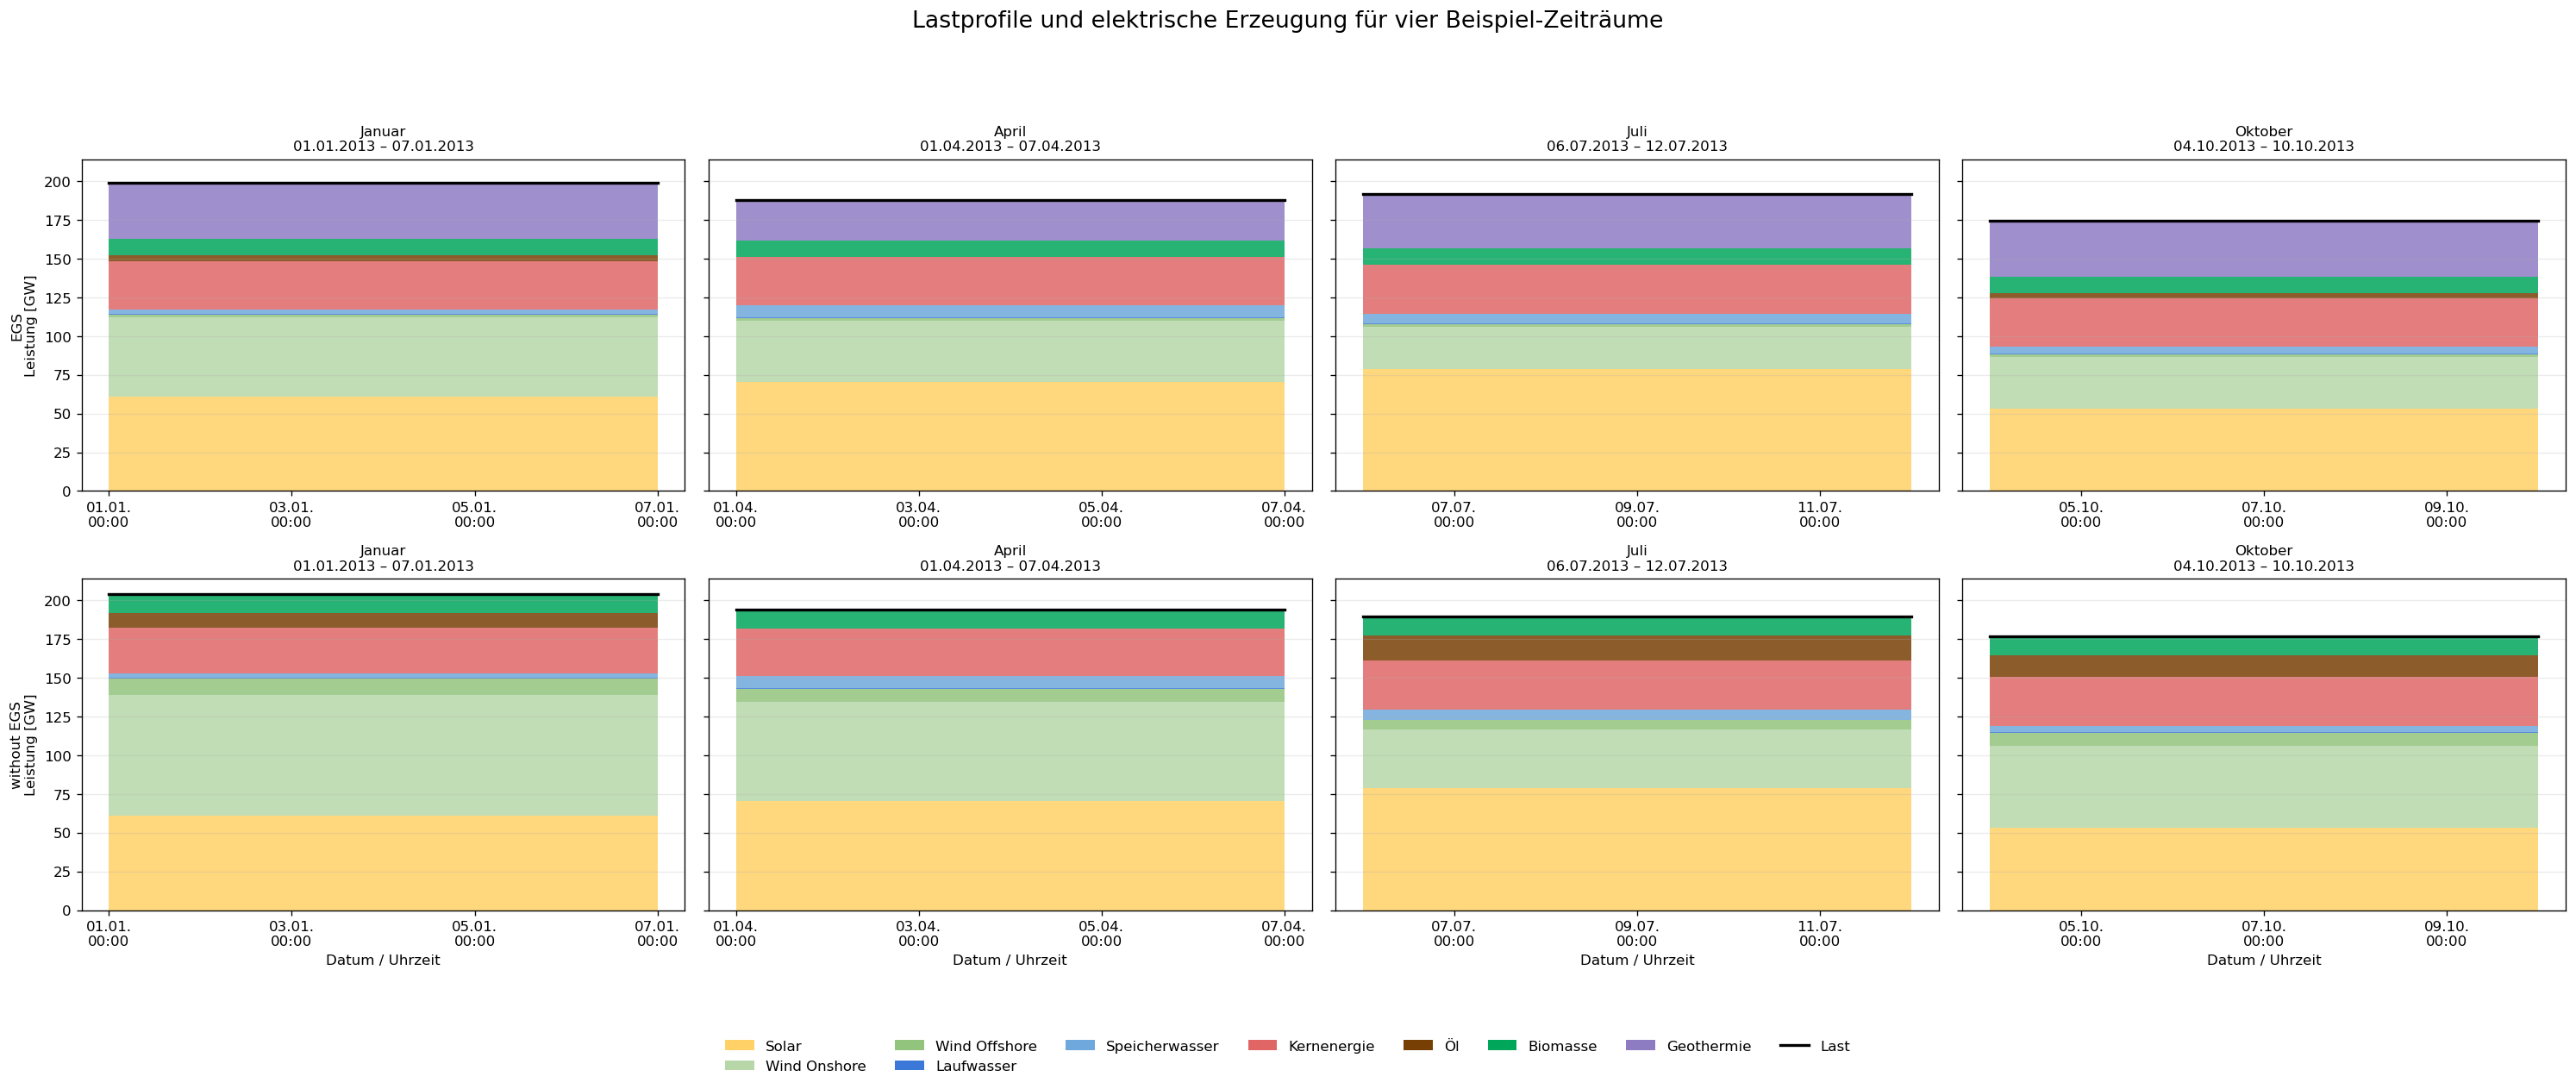

In [14]:
# ============================================================
# Lastprofile und elektrische Erzeugung für vier Beispiel-Zeiträume
# Vergleich: n_a vs. n_b
# Funktioniert auch bei grober zeitlicher Auflösung, z.B. 144h
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}

# Vier Jahreszeiten: Ziel ist jeweils der 01. des Monats.
# Falls dieser Snapshot nicht existiert, wird der nächste Snapshot im Monat verwendet.
season_months = {
    "Januar": 1,
    "April": 4,
    "Juli": 7,
    "Oktober": 10,
}

target_day = 1

POWER_DIVISOR = 1e3
POWER_UNIT = "GW"

min_stack_value = 0.001  # GW

include_link_electricity_consumption = True


# ------------------------------------------------------------
# Carrier-Mapping
# ------------------------------------------------------------

profile_carrier_order = [
    "Solar",
    "Wind Onshore",
    "Wind Offshore",
    "Laufwasser",
    "Speicherwasser",
    "Pumpspeicher",
    "Batteriespeicher",
    "Kernenergie",
    "Kohle",
    "Erdgas",
    "Öl",
    "Biomasse",
    "Geothermie",
    "Wasserstoff",
    "Andere",
]


def map_profile_carrier(carrier):
    carrier_str = str(carrier)
    carrier_low = carrier_str.lower()

    if carrier_low in ["solar", "solar rooftop", "solar-rooftop"]:
        return "Solar"

    if carrier_low == "onwind":
        return "Wind Onshore"

    if carrier_low.startswith("offwind"):
        return "Wind Offshore"

    if carrier_low in ["ror", "run of river", "run-of-river"]:
        return "Laufwasser"

    if carrier_low in ["hydro", "hydro reservoir"]:
        return "Speicherwasser"

    if carrier_low in ["phs", "pumped hydro storage"]:
        return "Pumpspeicher"

    if "battery" in carrier_low:
        return "Batteriespeicher"

    if carrier_low == "nuclear":
        return "Kernenergie"

    if "coal" in carrier_low or "lignite" in carrier_low:
        return "Kohle"

    if "gas" in carrier_low or "ccgt" in carrier_low or "ocgt" in carrier_low:
        return "Erdgas"

    if "oil" in carrier_low or "diesel" in carrier_low or "kerosene" in carrier_low or "naphta" in carrier_low:
        return "Öl"

    if "biomass" in carrier_low or "biomasse" in carrier_low:
        return "Biomasse"

    if "geothermal" in carrier_low:
        return "Geothermie"

    if "h2" in carrier_low or "hydrogen" in carrier_low or "fuel cell" in carrier_low:
        return "Wasserstoff"

    return "Andere"


profile_colors = {
    "Solar": "#ffd166",
    "Wind Onshore": "#b7d7a8",
    "Wind Offshore": "#93c47d",
    "Laufwasser": "#3c78d8",
    "Speicherwasser": "#6fa8dc",
    "Pumpspeicher": "#0b5394",
    "Batteriespeicher": "#674ea7",
    "Kernenergie": "#e06666",
    "Kohle": "#666666",
    "Erdgas": "#f6b26b",
    "Öl": "#783f04",
    "Biomasse": "#00a65a",
    "Geothermie": "#8e7cc3",
    "Wasserstoff": "#00cccc",
    "Andere": "#cccccc",
}


def get_profile_color(carrier):
    return profile_colors.get(carrier, "#cccccc")


# ------------------------------------------------------------
# Snapshot-Hilfsfunktionen
# ------------------------------------------------------------

def get_snapshot_datetime_series(n):
    """
    Gibt die Zeitinformation der Snapshots als Series zurück.
    Funktioniert auch bei MultiIndex-Snapshots.
    """
    snapshots = n.snapshots

    if isinstance(snapshots, pd.MultiIndex):
        datetime_values = pd.to_datetime(snapshots.get_level_values(-1))
    else:
        datetime_values = pd.to_datetime(snapshots)

    return pd.Series(datetime_values, index=snapshots)


def infer_snapshot_step(n):
    """
    Erkennt den typischen Zeitschritt des Netzwerks, z.B. 1h, 3h, 24h oder 144h.
    """
    datetime_series = get_snapshot_datetime_series(n)

    unique_datetimes = (
        pd.Series(pd.to_datetime(datetime_series.values))
        .drop_duplicates()
        .sort_values()
    )

    if len(unique_datetimes) < 2:
        return pd.Timedelta(hours=1)

    diffs = unique_datetimes.diff().dropna()

    return diffs.median()


def select_representative_period(n, month, day=1):
    """
    Wählt einen geeigneten Zeitraum für den Plot.

    Logik:
    - Bei feiner Auflösung bis 24h: alle Snapshots des gewählten Tages.
    - Bei grober Auflösung größer 24h, z.B. 144h:
      den Snapshot suchen, der dem 01. des Monats am nächsten liegt,
      und diesen als Zeitintervall bis zum nächsten Modell-Zeitschritt darstellen.
    """
    datetime_series = get_snapshot_datetime_series(n)
    step = infer_snapshot_step(n)

    available_years = datetime_series.dt.year.unique()
    year = int(available_years[0])

    target_datetime = pd.Timestamp(year=year, month=month, day=day)

    # Erst versuchen: exakter Kalendertag
    day_mask = (
        (datetime_series.dt.year == year)
        & (datetime_series.dt.month == month)
        & (datetime_series.dt.day == day)
    )

    # Bei feinerer Auflösung ist ein ganzer Tag sinnvoll
    if step <= pd.Timedelta(hours=24) and day_mask.any():
        selected_snapshots = list(datetime_series.index[day_mask])
        selected_datetimes = datetime_series.loc[selected_snapshots]
        return selected_snapshots, selected_datetimes, step

    # Bei grober Auflösung: nächsten Snapshot im gewünschten Monat suchen
    month_mask = (
        (datetime_series.dt.year == year)
        & (datetime_series.dt.month == month)
    )

    candidates = datetime_series.loc[month_mask]

    if candidates.empty:
        # Fallback: nächster Snapshot im gesamten Jahr
        candidates = datetime_series

    time_differences = (candidates - target_datetime).abs()
    selected_snapshot = time_differences.idxmin()

    selected_snapshots = [selected_snapshot]
    selected_datetimes = datetime_series.loc[selected_snapshots]

    return selected_snapshots, selected_datetimes, step


def extend_to_model_interval(values, selected_datetimes, step):
    """
    Erweitert die Zeitreihe bis zum Ende des Modell-Zeitschritts.

    Wichtig bei 144h:
    Ein einzelner Snapshot wird dadurch als Fläche über 144h sichtbar.
    """
    if values.empty:
        return values

    values = values.copy()
    datetime_index = pd.DatetimeIndex(pd.to_datetime(selected_datetimes.values))
    values.index = datetime_index

    last_row = values.iloc[[-1]].copy()
    last_row.index = pd.DatetimeIndex([datetime_index[-1] + step])

    values_extended = pd.concat([values, last_row])

    return values_extended


# ------------------------------------------------------------
# Aggregation nach Carrier
# ------------------------------------------------------------

def aggregate_columns_by_carrier(power_df, carrier_series):
    if power_df.empty:
        return pd.DataFrame(index=power_df.index)

    mapped_carriers = carrier_series.map(map_profile_carrier)

    grouped = (
        power_df
        .T
        .groupby(mapped_carriers)
        .sum()
        .T
    )

    return grouped


# ------------------------------------------------------------
# Elektrische Erzeugung
# ------------------------------------------------------------

def get_electric_generation_profile(n):
    generation_parts = []

    # Generatoren
    generators = n.generators.copy()

    if not generators.empty and hasattr(n, "generators_t") and hasattr(n.generators_t, "p"):
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        selected_generators = generators[
            ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
            & generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not selected_generators.empty:
            gen_p = (
                n.generators_t.p
                .reindex(columns=selected_generators.index)
                .fillna(0)
                .clip(lower=0)
            )

            generation_parts.append(
                aggregate_columns_by_carrier(gen_p, selected_generators["carrier"])
            )

    # StorageUnits, z.B. PHS
    storage_units = n.storage_units.copy()

    if not storage_units.empty and hasattr(n, "storage_units_t") and hasattr(n.storage_units_t, "p"):
        storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

        selected_storage_units = storage_units[
            storage_units["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not selected_storage_units.empty:
            su_p = (
                n.storage_units_t.p
                .reindex(columns=selected_storage_units.index)
                .fillna(0)
                .clip(lower=0)
            )

            generation_parts.append(
                aggregate_columns_by_carrier(su_p, selected_storage_units["carrier"])
            )

    # Links mit elektrischer Einspeisung
    links = n.links.copy()

    if not links.empty and hasattr(n, "links_t"):
        for bus_number in range(1, 6):
            bus_col = f"bus{bus_number}"
            p_col = f"p{bus_number}"

            if bus_col not in links.columns:
                continue

            if not hasattr(n.links_t, p_col):
                continue

            output_bus_carrier = links[bus_col].map(n.buses.carrier)

            if "bus0" in links.columns:
                input_bus_carrier = links["bus0"].map(n.buses.carrier)
            else:
                input_bus_carrier = pd.Series(index=links.index, data=np.nan)

            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            selected_links = links.loc[mask].copy()

            if selected_links.empty:
                continue

            link_p = (
                getattr(n.links_t, p_col)
                .reindex(columns=selected_links.index)
                .fillna(0)
            )

            # Negative Werte am Ausgangsbus bedeuten Einspeisung
            electric_output = (-link_p).clip(lower=0)

            generation_parts.append(
                aggregate_columns_by_carrier(electric_output, selected_links["carrier"])
            )

    if generation_parts:
        generation_profile = (
            pd.concat(generation_parts, axis=1)
            .T
            .groupby(level=0)
            .sum()
            .T
        )
    else:
        generation_profile = pd.DataFrame(index=n.snapshots)

    generation_profile = generation_profile.reindex(
        columns=[
            carrier for carrier in profile_carrier_order
            if carrier in generation_profile.columns
        ]
    )

    return generation_profile


# ------------------------------------------------------------
# Elektrische Last
# ------------------------------------------------------------

def get_electric_load_profile(n):
    load_parts = []

    # Klassische Loads
    loads = n.loads.copy()

    if not loads.empty and hasattr(n, "loads_t") and hasattr(n.loads_t, "p"):
        loads["bus_carrier"] = loads.bus.map(n.buses.carrier)

        selected_loads = loads[
            loads["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not selected_loads.empty:
            load_p = (
                n.loads_t.p
                .reindex(columns=selected_loads.index)
                .fillna(0)
                .sum(axis=1)
            )

            load_parts.append(load_p)

    # Zusätzlicher Stromverbrauch von Links
    if include_link_electricity_consumption:
        links = n.links.copy()

        if not links.empty and hasattr(n, "links_t"):
            bus_cols = [
                col for col in links.columns
                if col.startswith("bus") and col[3:].isdigit()
            ]

            for bus_col in bus_cols:
                bus_number = int(bus_col.replace("bus", ""))
                p_col = f"p{bus_number}"

                if not hasattr(n.links_t, p_col):
                    continue

                bus_carrier = links[bus_col].map(n.buses.carrier)

                other_non_electric = pd.Series(False, index=links.index)

                for other_bus_col in bus_cols:
                    if other_bus_col == bus_col:
                        continue

                    other_bus = links[other_bus_col]

                    valid_other_bus = (
                        other_bus.notna()
                        & (other_bus.astype(str) != "")
                    )

                    other_bus_carrier = other_bus.map(n.buses.carrier)

                    other_non_electric = (
                        other_non_electric
                        | (
                            valid_other_bus
                            & ~other_bus_carrier.isin(electric_bus_carriers)
                        )
                    )

                mask = (
                    bus_carrier.isin(electric_bus_carriers)
                    & other_non_electric
                )

                selected_links = links.loc[mask]

                if selected_links.empty:
                    continue

                link_p = (
                    getattr(n.links_t, p_col)
                    .reindex(columns=selected_links.index)
                    .fillna(0)
                )

                # Positive Werte bedeuten Entnahme aus dem Strombus
                electric_consumption = link_p.clip(lower=0).sum(axis=1)

                load_parts.append(electric_consumption)

        # Ladung von StorageUnits
        storage_units = n.storage_units.copy()

        if not storage_units.empty and hasattr(n, "storage_units_t") and hasattr(n.storage_units_t, "p"):
            storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

            selected_storage_units = storage_units[
                storage_units["bus_carrier"].isin(electric_bus_carriers)
            ].copy()

            if not selected_storage_units.empty:
                su_p = (
                    n.storage_units_t.p
                    .reindex(columns=selected_storage_units.index)
                    .fillna(0)
                )

                # Negative Werte bedeuten Ladung
                storage_charging = (-su_p.clip(upper=0)).sum(axis=1)

                load_parts.append(storage_charging)

    if load_parts:
        load_profile = pd.concat(load_parts, axis=1).sum(axis=1)
    else:
        load_profile = pd.Series(0.0, index=n.snapshots)

    return load_profile


# ------------------------------------------------------------
# Daten vorbereiten
# ------------------------------------------------------------

plot_data = {}
global_carriers = set()

for scenario_name, network in networks_to_compare.items():
    generation_profile = get_electric_generation_profile(network)
    load_profile = get_electric_load_profile(network)
    step = infer_snapshot_step(network)

    print(f"{scenario_name}: erkannter Zeitschritt = {step}")

    for month_name, month in season_months.items():
        selected_snapshots, selected_datetimes, step = select_representative_period(
            network,
            month=month,
            day=target_day
        )

        generation_period = (
            generation_profile
            .reindex(index=selected_snapshots)
            .fillna(0)
            .div(POWER_DIVISOR)
        )

        load_period = (
            load_profile
            .reindex(index=selected_snapshots)
            .fillna(0)
            .to_frame("Last")
            .div(POWER_DIVISOR)
        )

        generation_period = extend_to_model_interval(
            generation_period,
            selected_datetimes,
            step
        )

        load_period = extend_to_model_interval(
            load_period,
            selected_datetimes,
            step
        )["Last"]

        keep_cols = generation_period.columns[
            generation_period.max(axis=0) > min_stack_value
        ]

        global_carriers.update(keep_cols)

        plot_data[(scenario_name, month_name)] = {
            "generation": generation_period,
            "load": load_period,
            "step": step,
        }


ordered_global_carriers = [
    carrier for carrier in profile_carrier_order
    if carrier in global_carriers
]

ordered_global_carriers += sorted(
    carrier for carrier in global_carriers
    if carrier not in ordered_global_carriers
)


# ------------------------------------------------------------
# Plot: 2 Reihen x 4 Spalten
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(25, 10),
    sharey=True
)

for row_idx, scenario_name in enumerate(networks_to_compare.keys()):

    for col_idx, month_name in enumerate(season_months.keys()):

        ax = axes[row_idx, col_idx]

        data = plot_data[(scenario_name, month_name)]

        generation_period = data["generation"]
        load_period = data["load"]

        generation_plot = (
            generation_period
            .reindex(columns=ordered_global_carriers)
            .fillna(0)
        )

        x = generation_plot.index

        stack_values = [
            generation_plot[carrier].values
            for carrier in ordered_global_carriers
        ]

        stack_colors = [
            get_profile_color(carrier)
            for carrier in ordered_global_carriers
        ]

        if len(stack_values) > 0:
            ax.stackplot(
                x,
                *stack_values,
                colors=stack_colors,
                alpha=0.85,
                linewidth=0,
                step="post"
            )

        ax.plot(
            load_period.index,
            load_period.values,
            color="black",
            linewidth=2.0,
            drawstyle="steps-post",
            label="Last"
        )

        start_time = generation_plot.index[0]
        end_time = generation_plot.index[-1]

        ax.set_title(
            f"{month_name}\n"
            f"{start_time.strftime('%d.%m.%Y')} – {end_time.strftime('%d.%m.%Y')}",
            fontsize=10
        )

        ax.grid(axis="y", alpha=0.25)

        ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.\n%H:%M"))

        if col_idx == 0:
            ax.set_ylabel(
                f"{scenario_name}\nLeistung [{POWER_UNIT}]"
            )

        if row_idx == 1:
            ax.set_xlabel("Datum / Uhrzeit")


# ------------------------------------------------------------
# Gemeinsame Legende
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=get_profile_color(carrier),
        edgecolor="none",
        label=carrier
    )
    for carrier in ordered_global_carriers
]

legend_handles.append(
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2,
        label="Last"
    )
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=min(8, len(legend_handles)),
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "Lastprofile und elektrische Erzeugung für vier Beispiel-Zeiträume",
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()

EGS
  Zeitschritt: 6 days 00:00:00
  Maximale Last: 207.24 GW
  Mittlere Last: 187.76 GW

without EGS
  Zeitschritt: 6 days 00:00:00
  Maximale Last: 214.24 GW
  Mittlere Last: 190.26 GW



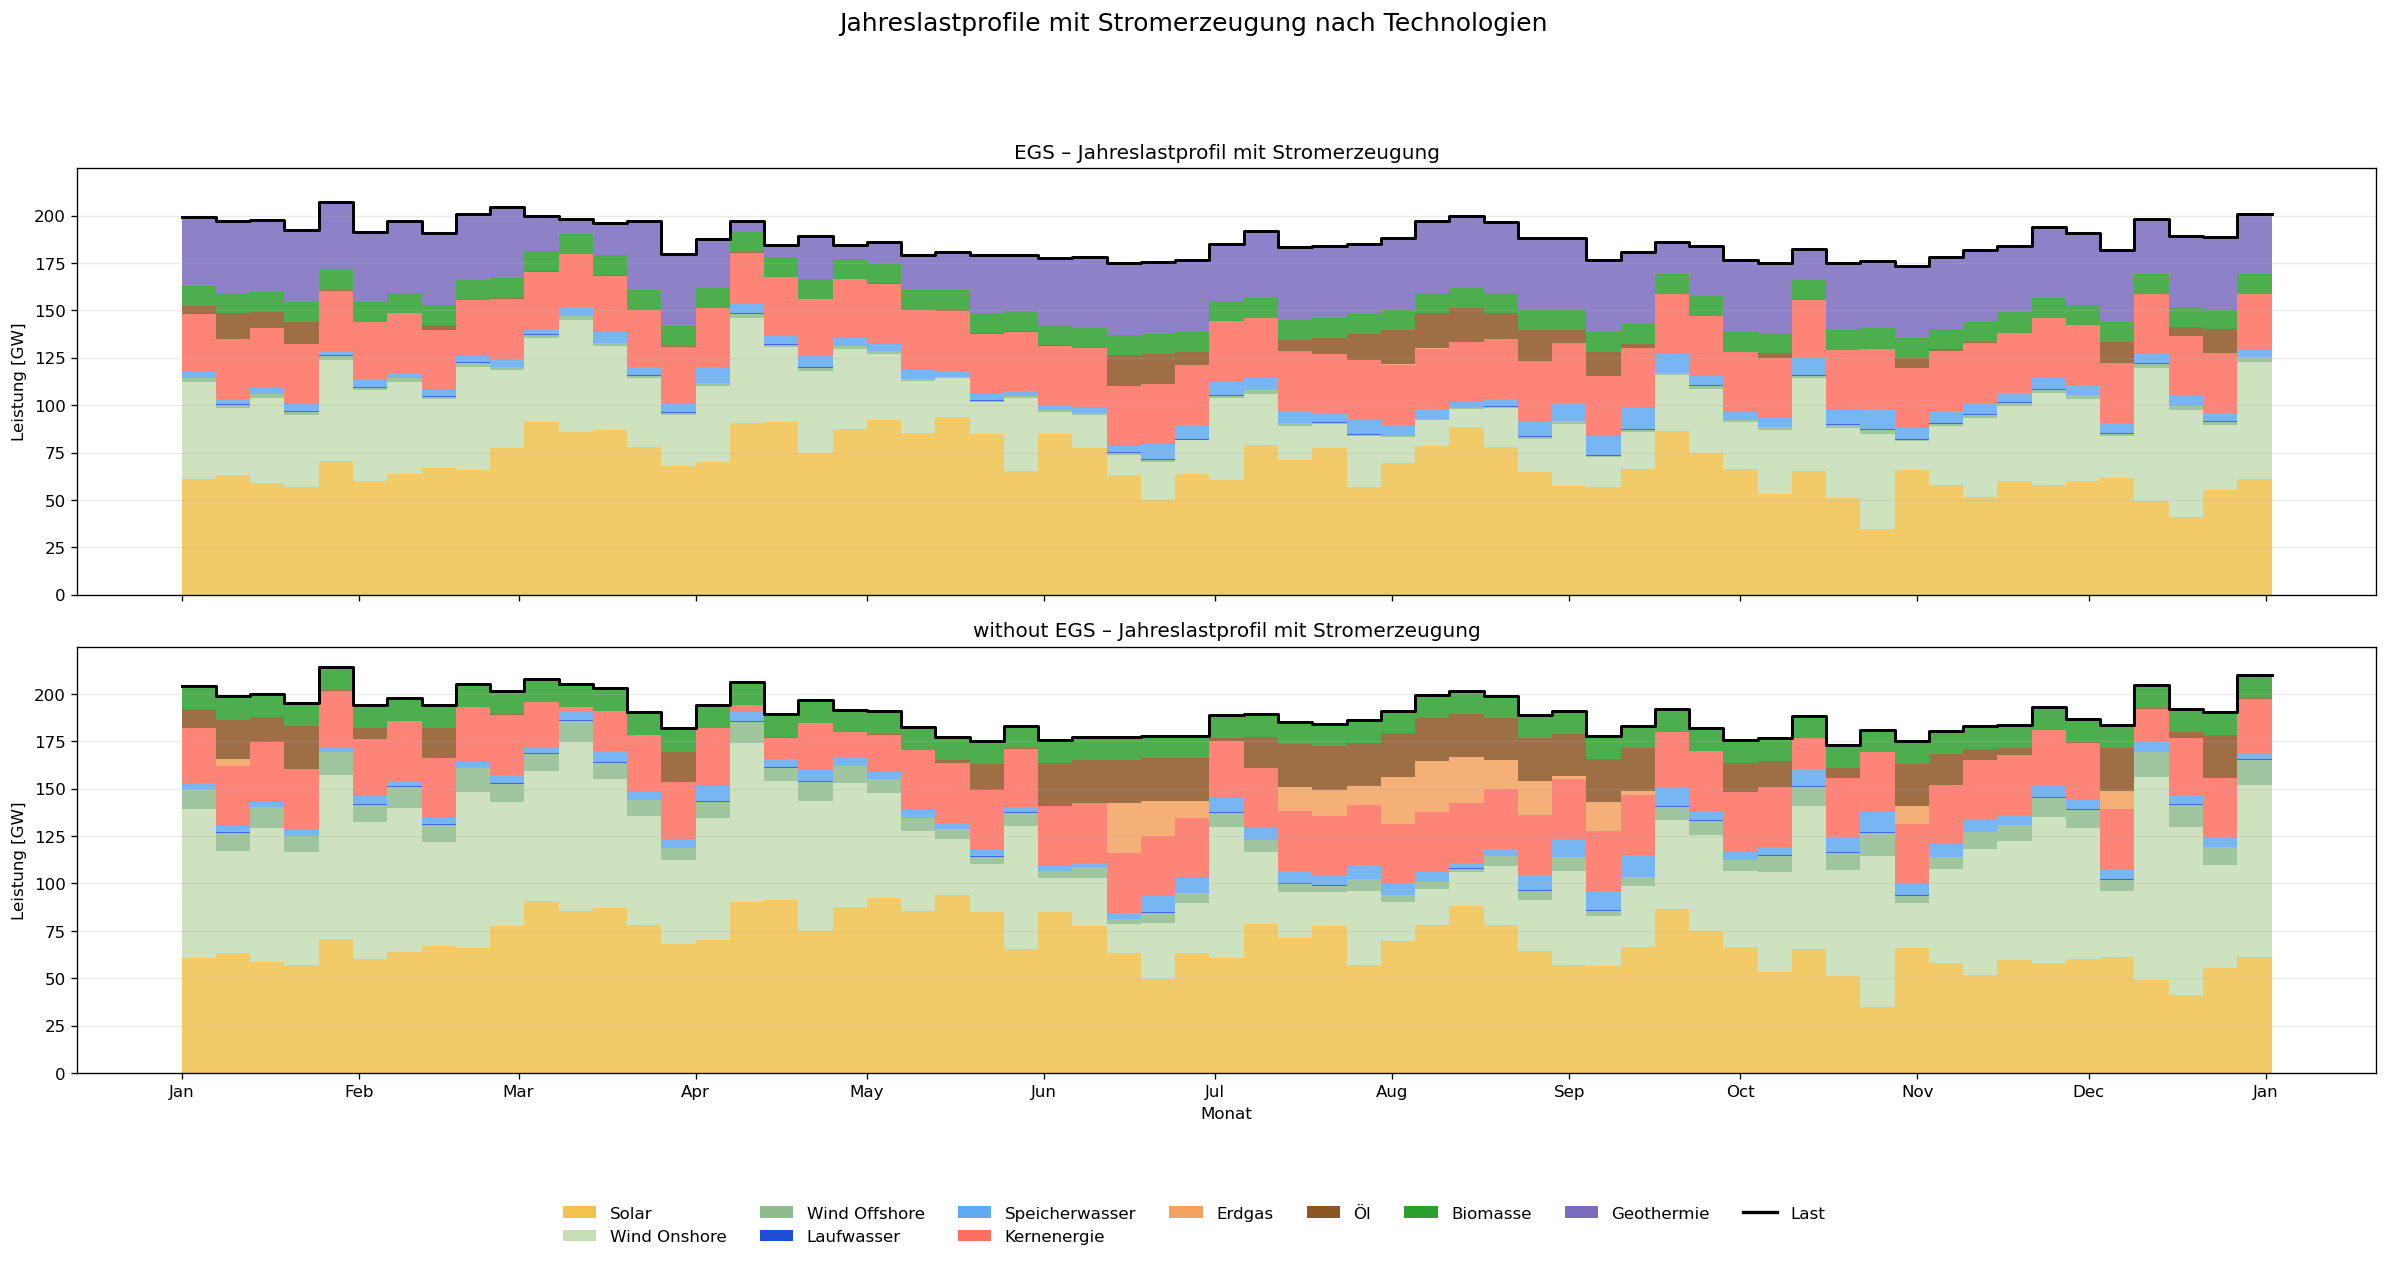

,EGS,without EGS
carrier,,
Solar,4246.542509,4245.809108
Wind Onshore,2152.928936,3335.424028
Wind Offshore,85.233836,480.348460
Laufwasser,15.241798,15.239207
Speicherwasser,325.232841,325.228907
Kernenergie,1930.614409,1769.626983
Erdgas,1.228943,242.073695
Öl,256.324613,632.436088
Biomasse,655.243484,745.973763


In [15]:
# ============================================================
# Jahreslastprofil mit Stromerzeugung nach Technologien
# Vergleich: n_a vs. n_b
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}

POWER_DIVISOR = 1e3
POWER_UNIT = "GW"

# Kleine Beiträge ausblenden
min_stack_value = 0.01  # GW

# True: berücksichtigt zusätzlich Stromverbrauch von Links
# (z.B. Elektrolyse, Wärmepumpen, Batterie-Charger)
include_link_electricity_consumption = True


# ------------------------------------------------------------
# Carrier-Mapping
# ------------------------------------------------------------

profile_carrier_order = [
    "Solar",
    "Wind Onshore",
    "Wind Offshore",
    "Laufwasser",
    "Speicherwasser",
    "Pumpspeicher",
    "Batteriespeicher",
    "Kernenergie",
    "Kohle",
    "Erdgas",
    "Öl",
    "Biomasse",
    "Geothermie",
    "Wasserstoff",
    "Andere",
]


def map_profile_carrier(carrier):
    carrier_str = str(carrier)
    carrier_low = carrier_str.lower()

    if carrier_low in ["solar", "solar rooftop", "solar-rooftop"]:
        return "Solar"

    if carrier_low == "onwind":
        return "Wind Onshore"

    if carrier_low.startswith("offwind"):
        return "Wind Offshore"

    if carrier_low in ["ror", "run of river", "run-of-river"]:
        return "Laufwasser"

    if carrier_low in ["hydro", "hydro reservoir"]:
        return "Speicherwasser"

    if carrier_low in ["phs", "pumped hydro storage"]:
        return "Pumpspeicher"

    if "battery" in carrier_low:
        return "Batteriespeicher"

    if carrier_low == "nuclear":
        return "Kernenergie"

    if "coal" in carrier_low or "lignite" in carrier_low:
        return "Kohle"

    if "gas" in carrier_low or "ccgt" in carrier_low or "ocgt" in carrier_low:
        return "Erdgas"

    if (
        "oil" in carrier_low
        or "diesel" in carrier_low
        or "kerosene" in carrier_low
        or "naphta" in carrier_low
    ):
        return "Öl"

    if "biomass" in carrier_low or "biomasse" in carrier_low:
        return "Biomasse"

    if "geothermal" in carrier_low:
        return "Geothermie"

    if "h2" in carrier_low or "hydrogen" in carrier_low or "fuel cell" in carrier_low:
        return "Wasserstoff"

    return "Andere"


profile_colors = {
    "Solar": "#f2c14e",
    "Wind Onshore": "#c7ddb5",
    "Wind Offshore": "#8fbc8f",
    "Laufwasser": "#1f4ed8",
    "Speicherwasser": "#5fa8f2",
    "Pumpspeicher": "#1f77b4",
    "Batteriespeicher": "#7e57c2",
    "Kernenergie": "#ff6f61",
    "Kohle": "#5f5f5f",
    "Erdgas": "#f4a261",
    "Öl": "#8d5524",
    "Biomasse": "#2ca02c",
    "Geothermie": "#7b6bbd",
    "Wasserstoff": "#17becf",
    "Andere": "#bdbdbd",
}


def get_profile_color(carrier):
    return profile_colors.get(carrier, "#cccccc")


# ------------------------------------------------------------
# Snapshot helper
# ------------------------------------------------------------

def get_snapshot_datetime_series(n):
    snapshots = n.snapshots

    if isinstance(snapshots, pd.MultiIndex):
        datetime_values = pd.to_datetime(snapshots.get_level_values(-1))
    else:
        datetime_values = pd.to_datetime(snapshots)

    return pd.Series(datetime_values, index=snapshots)


def infer_snapshot_step(n):
    datetime_series = get_snapshot_datetime_series(n)

    unique_datetimes = (
        pd.Series(pd.to_datetime(datetime_series.values))
        .drop_duplicates()
        .sort_values()
    )

    if len(unique_datetimes) < 2:
        return pd.Timedelta(hours=1)

    diffs = unique_datetimes.diff().dropna()

    return diffs.median()


def extend_profile_to_last_interval_df(df, n):
    """
    Verlängert DataFrame-Zeitreihe um einen zusätzlichen Endpunkt,
    damit der letzte Modell-Zeitschritt sichtbar wird.
    """
    if df.empty:
        return df

    step = infer_snapshot_step(n)
    datetime_series = get_snapshot_datetime_series(n)

    out = df.copy()
    out.index = pd.DatetimeIndex(pd.to_datetime(datetime_series.loc[out.index].values))

    last_row = out.iloc[[-1]].copy()
    last_row.index = pd.DatetimeIndex([out.index[-1] + step])

    out = pd.concat([out, last_row])

    return out


def extend_profile_to_last_interval_series(s, n):
    """
    Verlängert Series-Zeitreihe um einen zusätzlichen Endpunkt,
    damit der letzte Modell-Zeitschritt sichtbar wird.
    """
    if s.empty:
        return s

    step = infer_snapshot_step(n)
    datetime_series = get_snapshot_datetime_series(n)

    out = s.copy()
    out.index = pd.DatetimeIndex(pd.to_datetime(datetime_series.loc[out.index].values))

    last_value = pd.Series(
        [out.iloc[-1]],
        index=pd.DatetimeIndex([out.index[-1] + step])
    )

    out = pd.concat([out, last_value])

    return out


# ------------------------------------------------------------
# Aggregation helper
# ------------------------------------------------------------

def aggregate_columns_by_carrier(power_df, carrier_series):
    if power_df.empty:
        return pd.DataFrame(index=power_df.index)

    mapped_carriers = carrier_series.map(map_profile_carrier)

    grouped = (
        power_df.T
        .groupby(mapped_carriers)
        .sum()
        .T
    )

    return grouped


# ------------------------------------------------------------
# Electric generation profile
# ------------------------------------------------------------

def get_electric_generation_profile(n):
    generation_parts = []

    # --------------------------------------------------------
    # 1) Generators
    # --------------------------------------------------------
    generators = n.generators.copy()

    if not generators.empty and hasattr(n, "generators_t") and hasattr(n.generators_t, "p"):
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        selected_generators = generators[
            ~generators.carrier.astype(str).str.contains("load", case=False, na=False)
            & generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not selected_generators.empty:
            gen_p = (
                n.generators_t.p
                .reindex(columns=selected_generators.index)
                .fillna(0)
                .clip(lower=0)
            )

            gen_by_carrier = aggregate_columns_by_carrier(
                gen_p,
                selected_generators["carrier"]
            )

            generation_parts.append(gen_by_carrier)

    # --------------------------------------------------------
    # 2) StorageUnits (Entladung)
    # --------------------------------------------------------
    storage_units = n.storage_units.copy()

    if not storage_units.empty and hasattr(n, "storage_units_t") and hasattr(n.storage_units_t, "p"):
        storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

        selected_storage_units = storage_units[
            storage_units["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not selected_storage_units.empty:
            su_p = (
                n.storage_units_t.p
                .reindex(columns=selected_storage_units.index)
                .fillna(0)
                .clip(lower=0)
            )

            su_by_carrier = aggregate_columns_by_carrier(
                su_p,
                selected_storage_units["carrier"]
            )

            generation_parts.append(su_by_carrier)

    # --------------------------------------------------------
    # 3) Links, die Strom erzeugen
    # --------------------------------------------------------
    links = n.links.copy()

    if not links.empty and hasattr(n, "links_t"):
        for bus_number in range(1, 6):
            bus_col = f"bus{bus_number}"
            p_col = f"p{bus_number}"

            if bus_col not in links.columns:
                continue

            if not hasattr(n.links_t, p_col):
                continue

            output_bus_carrier = links[bus_col].map(n.buses.carrier)

            if "bus0" in links.columns:
                input_bus_carrier = links["bus0"].map(n.buses.carrier)
            else:
                input_bus_carrier = pd.Series(index=links.index, data=np.nan)

            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            selected_links = links.loc[mask].copy()

            if selected_links.empty:
                continue

            link_p = (
                getattr(n.links_t, p_col)
                .reindex(columns=selected_links.index)
                .fillna(0)
            )

            # Negative p am Ausgangsbus = Einspeisung
            electric_output = (-link_p).clip(lower=0)

            link_by_carrier = aggregate_columns_by_carrier(
                electric_output,
                selected_links["carrier"]
            )

            generation_parts.append(link_by_carrier)

    if generation_parts:
        generation_profile = (
            pd.concat(generation_parts, axis=1)
            .T
            .groupby(level=0)
            .sum()
            .T
        )
    else:
        generation_profile = pd.DataFrame(index=n.snapshots)

    generation_profile = generation_profile.reindex(
        columns=[
            carrier for carrier in profile_carrier_order
            if carrier in generation_profile.columns
        ]
    )

    return generation_profile


# ------------------------------------------------------------
# Electric load profile
# ------------------------------------------------------------

def get_electric_load_profile(n):
    load_parts = []

    # --------------------------------------------------------
    # 1) klassische Loads
    # --------------------------------------------------------
    loads = n.loads.copy()

    if not loads.empty and hasattr(n, "loads_t") and hasattr(n.loads_t, "p"):
        loads["bus_carrier"] = loads.bus.map(n.buses.carrier)

        selected_loads = loads[
            loads["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        if not selected_loads.empty:
            load_p = (
                n.loads_t.p
                .reindex(columns=selected_loads.index)
                .fillna(0)
                .sum(axis=1)
            )

            load_parts.append(load_p)

    if include_link_electricity_consumption:
        links = n.links.copy()

        # ----------------------------------------------------
        # 2) Stromverbrauch von Links
        # ----------------------------------------------------
        if not links.empty and hasattr(n, "links_t"):
            bus_cols = [
                col for col in links.columns
                if col.startswith("bus") and col[3:].isdigit()
            ]

            for bus_col in bus_cols:
                bus_number = int(bus_col.replace("bus", ""))
                p_col = f"p{bus_number}"

                if not hasattr(n.links_t, p_col):
                    continue

                bus_carrier = links[bus_col].map(n.buses.carrier)

                other_non_electric = pd.Series(False, index=links.index)

                for other_bus_col in bus_cols:
                    if other_bus_col == bus_col:
                        continue

                    other_bus = links[other_bus_col]

                    valid_other_bus = (
                        other_bus.notna()
                        & (other_bus.astype(str) != "")
                    )

                    other_bus_carrier = other_bus.map(n.buses.carrier)

                    other_non_electric = (
                        other_non_electric
                        | (
                            valid_other_bus
                            & ~other_bus_carrier.isin(electric_bus_carriers)
                        )
                    )

                mask = (
                    bus_carrier.isin(electric_bus_carriers)
                    & other_non_electric
                )

                selected_links = links.loc[mask]

                if selected_links.empty:
                    continue

                link_p = (
                    getattr(n.links_t, p_col)
                    .reindex(columns=selected_links.index)
                    .fillna(0)
                )

                electric_consumption = link_p.clip(lower=0).sum(axis=1)

                load_parts.append(electric_consumption)

        # ----------------------------------------------------
        # 3) Ladung von StorageUnits
        # ----------------------------------------------------
        storage_units = n.storage_units.copy()

        if not storage_units.empty and hasattr(n, "storage_units_t") and hasattr(n.storage_units_t, "p"):
            storage_units["bus_carrier"] = storage_units.bus.map(n.buses.carrier)

            selected_storage_units = storage_units[
                storage_units["bus_carrier"].isin(electric_bus_carriers)
            ].copy()

            if not selected_storage_units.empty:
                su_p = (
                    n.storage_units_t.p
                    .reindex(columns=selected_storage_units.index)
                    .fillna(0)
                )

                storage_charging = (-su_p.clip(upper=0)).sum(axis=1)

                load_parts.append(storage_charging)

    if load_parts:
        load_profile = pd.concat(load_parts, axis=1).sum(axis=1)
    else:
        load_profile = pd.Series(0.0, index=n.snapshots)

    return load_profile


# ------------------------------------------------------------
# Daten vorbereiten
# ------------------------------------------------------------

annual_plot_data = {}
global_carriers = set()

for scenario_name, network in networks_to_compare.items():
    generation_profile = get_electric_generation_profile(network).div(POWER_DIVISOR)
    load_profile = get_electric_load_profile(network).div(POWER_DIVISOR)

    generation_profile = extend_profile_to_last_interval_df(generation_profile, network)
    load_profile = extend_profile_to_last_interval_series(load_profile, network)

    # Nur Carrier behalten, die tatsächlich relevant sind
    keep_cols = generation_profile.columns[
        generation_profile.max(axis=0) > min_stack_value
    ]

    generation_profile = generation_profile[keep_cols]
    global_carriers.update(keep_cols)

    annual_plot_data[scenario_name] = {
        "generation": generation_profile,
        "load": load_profile,
        "step": infer_snapshot_step(network),
    }

    print(f"{scenario_name}")
    print(f"  Zeitschritt: {infer_snapshot_step(network)}")
    print(f"  Maximale Last: {load_profile.max():.2f} {POWER_UNIT}")
    print(f"  Mittlere Last: {load_profile.mean():.2f} {POWER_UNIT}")
    print()


ordered_global_carriers = [
    carrier for carrier in profile_carrier_order
    if carrier in global_carriers
]

ordered_global_carriers += sorted(
    carrier for carrier in global_carriers
    if carrier not in ordered_global_carriers
)


# ------------------------------------------------------------
# Plot: zwei Jahresprofile untereinander
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(20, 10),
    sharex=True,
    sharey=True
)

if len(networks_to_compare) == 1:
    axes = [axes]

for ax, (scenario_name, data) in zip(axes, annual_plot_data.items()):
    generation_profile = (
        data["generation"]
        .reindex(columns=ordered_global_carriers)
        .fillna(0)
    )

    load_profile = data["load"]

    x = generation_profile.index

    stack_values = [
        generation_profile[carrier].values
        for carrier in ordered_global_carriers
    ]

    stack_colors = [
        get_profile_color(carrier)
        for carrier in ordered_global_carriers
    ]

    if len(stack_values) > 0:
        ax.stackplot(
            x,
            *stack_values,
            colors=stack_colors,
            alpha=0.85,
            linewidth=0,
            step="post"
        )

    ax.plot(
        load_profile.index,
        load_profile.values,
        color="black",
        linewidth=1.8,
        drawstyle="steps-post",
        label="Last"
    )

    ax.set_title(
        f"{scenario_name} – Jahreslastprofil mit Stromerzeugung",
        fontsize=12
    )
    ax.set_ylabel(f"Leistung [{POWER_UNIT}]")
    ax.grid(axis="y", alpha=0.25)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))


axes[-1].set_xlabel("Monat")


# ------------------------------------------------------------
# Gemeinsame Legende
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=get_profile_color(carrier),
        edgecolor="none",
        label=carrier
    )
    for carrier in ordered_global_carriers
]

legend_handles.append(
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=2,
        label="Last"
    )
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=min(8, len(legend_handles)),
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    "Jahreslastprofile mit Stromerzeugung nach Technologien",
    fontsize=15,
    y=1.02
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


# ------------------------------------------------------------
# Optionale Tabellen
# ------------------------------------------------------------

generation_mix_summary = {}

for scenario_name, data in annual_plot_data.items():
    generation_profile = data["generation"]

    generation_mix_summary[scenario_name] = generation_profile.sum()

generation_mix_summary = pd.DataFrame(generation_mix_summary).fillna(0)
generation_mix_summary.index.name = "carrier"

display(generation_mix_summary)


EGS: H2-Import-Generatoren:
['JP.11_1_AC import H2 port', 'JP.13_1_AC import H2 port', 'JP.19_1_AC import H2 port', 'JP.1_1_AC import H2 port', 'JP.27_1_AC import H2 port', 'JP.33_1_AC import H2 port', 'JP.41_1_AC import H2 port', 'JP.44_1_AC import H2 port', 'JP.7_1_AC import H2 port']

EGS: Inländische H2-Produktions-Links:


,carrier,bus0,bus1
Link,,,
JP.10_1_AC H2 Electrolysis,H2 Electrolysis,JP.10_1_AC,JP.10_1_AC H2
JP.11_1_AC H2 Electrolysis,H2 Electrolysis,JP.11_1_AC,JP.11_1_AC H2
JP.12_1_AC H2 Electrolysis,H2 Electrolysis,JP.12_1_AC,JP.12_1_AC H2
JP.13_1_AC H2 Electrolysis,H2 Electrolysis,JP.13_1_AC,JP.13_1_AC H2
JP.14_1_AC H2 Electrolysis,H2 Electrolysis,JP.14_1_AC,JP.14_1_AC H2
...,...,...,...
JP.5_1_AC SMR CC,SMR CC,JP.5_1_AC gas,JP.5_1_AC H2
JP.6_1_AC SMR CC,SMR CC,JP.6_1_AC gas,JP.6_1_AC H2
JP.7_1_AC SMR CC,SMR CC,JP.7_1_AC gas,JP.7_1_AC H2



EGS: H2-Importe: 52.70 TWh_H2
EGS: Inländische H2-Produktion: 17.19 TWh_H2

without EGS: H2-Import-Generatoren:
['JP.11_1_AC import H2 port', 'JP.13_1_AC import H2 port', 'JP.19_1_AC import H2 port', 'JP.1_1_AC import H2 port', 'JP.27_1_AC import H2 port', 'JP.33_1_AC import H2 port', 'JP.41_1_AC import H2 port', 'JP.44_1_AC import H2 port', 'JP.7_1_AC import H2 port']

without EGS: Inländische H2-Produktions-Links:


,carrier,bus0,bus1
Link,,,
JP.10_1_AC H2 Electrolysis,H2 Electrolysis,JP.10_1_AC,JP.10_1_AC H2
JP.11_1_AC H2 Electrolysis,H2 Electrolysis,JP.11_1_AC,JP.11_1_AC H2
JP.12_1_AC H2 Electrolysis,H2 Electrolysis,JP.12_1_AC,JP.12_1_AC H2
JP.13_1_AC H2 Electrolysis,H2 Electrolysis,JP.13_1_AC,JP.13_1_AC H2
JP.14_1_AC H2 Electrolysis,H2 Electrolysis,JP.14_1_AC,JP.14_1_AC H2
...,...,...,...
JP.5_1_AC SMR CC,SMR CC,JP.5_1_AC gas,JP.5_1_AC H2
JP.6_1_AC SMR CC,SMR CC,JP.6_1_AC gas,JP.6_1_AC H2
JP.7_1_AC SMR CC,SMR CC,JP.7_1_AC gas,JP.7_1_AC H2



without EGS: H2-Importe: 48.34 TWh_H2
without EGS: Inländische H2-Produktion: 17.43 TWh_H2


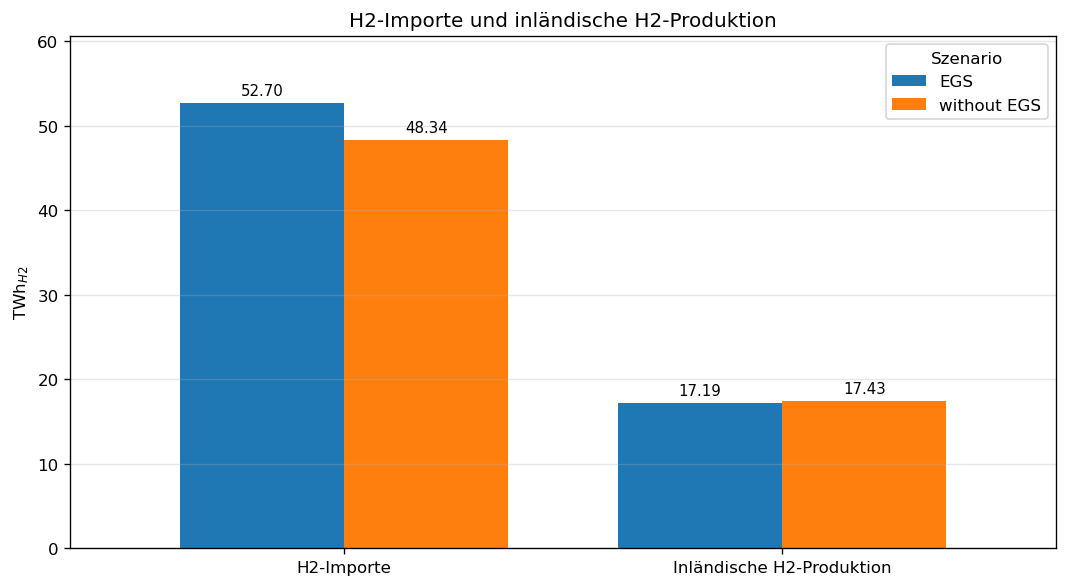

In [16]:
# ============================================================
# H2-Importe und inländische H2-Produktion
# Vergleich: n_a vs. n_b
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}

h2_prod_carriers = ["H2 Electrolysis", "SMR", "SMR CC"]

categories_order = [
    "H2-Importe",
    "Inländische H2-Produktion",
]


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def calculate_h2_import_and_domestic_production(n, scenario_name=None, verbose=True):
    """
    Berechnet H2-Importe und inländische H2-Produktion in TWh_H2.

    H2-Importe:
    - bevorzugt über Generatornamen mit Suffix ' import H2 port'
    - zusätzlich robuster Fallback über Generatoren mit carrier 'H2'
      und 'import' im Namen

    Inländische H2-Produktion:
    - über Links mit carrier H2 Electrolysis, SMR oder SMR CC
    - H2-Ausgabe liegt auf bus1 und ist in n.links_t.p1 negativ
    """

    # --------------------------------------------------------
    # H2-Busse finden
    # --------------------------------------------------------

    h2_buses = n.buses.index[
        n.buses.carrier.astype(str) == "H2"
    ]

    # --------------------------------------------------------
    # H2-Import-Generatoren finden
    # --------------------------------------------------------

    generator_index_str = n.generators.index.astype(str)

    h2_import_mask_suffix = generator_index_str.str.endswith(" import H2 port")

    h2_import_mask_fallback = (
        n.generators.carrier.astype(str).eq("H2")
        & n.generators.bus.isin(h2_buses)
        & generator_index_str.str.contains("import", case=False, na=False)
    )

    h2_import_gens = n.generators.index[
        h2_import_mask_suffix | h2_import_mask_fallback
    ]

    # --------------------------------------------------------
    # Inländische H2-Produktions-Links finden
    # --------------------------------------------------------

    h2_prod_links = n.links.index[
        n.links.carrier.isin(h2_prod_carriers)
        & n.links.bus1.isin(h2_buses)
    ]

    # --------------------------------------------------------
    # Snapshot-Gewichte
    # --------------------------------------------------------

    if hasattr(n, "snapshot_weightings") and "generators" in n.snapshot_weightings:
        weights = n.snapshot_weightings.generators
    else:
        weights = pd.Series(1.0, index=n.snapshots)

    # --------------------------------------------------------
    # 1) H2-Importe [MWh_H2]
    # --------------------------------------------------------

    if len(h2_import_gens) > 0:
        h2_import_mwh = (
            n.generators_t.p
            .reindex(columns=h2_import_gens)
            .fillna(0)
            .multiply(weights, axis=0)
            .sum()
            .sum()
        )
    else:
        h2_import_mwh = 0.0

    # --------------------------------------------------------
    # 2) Inländische H2-Produktion [MWh_H2]
    # --------------------------------------------------------

    if len(h2_prod_links) > 0:
        h2_domestic_mwh = (
            -n.links_t.p1
            .reindex(columns=h2_prod_links)
            .fillna(0)
        )

        h2_domestic_mwh = (
            h2_domestic_mwh
            .clip(lower=0)
            .multiply(weights, axis=0)
            .sum()
            .sum()
        )
    else:
        h2_domestic_mwh = 0.0

    # --------------------------------------------------------
    # Ausgabe
    # --------------------------------------------------------

    if verbose:
        prefix = f"{scenario_name}: " if scenario_name is not None else ""

        print(f"\n{prefix}H2-Import-Generatoren:")
        print(h2_import_gens.tolist())

        print(f"\n{prefix}Inländische H2-Produktions-Links:")
        if len(h2_prod_links) > 0:
            display(n.links.loc[h2_prod_links, ["carrier", "bus0", "bus1"]])
        else:
            print("Keine gefunden.")

        print(f"\n{prefix}H2-Importe: {h2_import_mwh / 1e6:,.2f} TWh_H2")
        print(f"{prefix}Inländische H2-Produktion: {h2_domestic_mwh / 1e6:,.2f} TWh_H2")

    return pd.Series({
        "H2-Importe": h2_import_mwh / 1e6,
        "Inländische H2-Produktion": h2_domestic_mwh / 1e6,
    })


# ------------------------------------------------------------
# Werte für beide Szenarien berechnen
# ------------------------------------------------------------

h2_results = {}

for scenario_name, network in networks_to_compare.items():
    h2_results[scenario_name] = calculate_h2_import_and_domestic_production(
        network,
        scenario_name=scenario_name,
        verbose=True
    )

h2_comparison = pd.DataFrame(h2_results)

h2_comparison = (
    h2_comparison
    .reindex(categories_order)
    .fillna(0)
)

#display(h2_comparison)


# ------------------------------------------------------------
# Plot: gruppierte Balken
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

scenario_colors = ["#1f77b4", "#ff7f0e"]

h2_comparison.plot.bar(
    ax=ax,
    width=0.75,
    color=scenario_colors
)

ax.set_ylabel("TWh$_{H2}$")
ax.set_xlabel("")
ax.set_title("H2-Importe und inländische H2-Produktion")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Szenario")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    ha="center"
)

# Werte über den Balken anzeigen
max_value = h2_comparison.max().max()

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.2f}" for v in container.datavalues],
        padding=3,
        fontsize=9
    )

ax.set_ylim(0, max_value * 1.15 if max_value > 0 else 1)

plt.tight_layout()
plt.show()


EGS
Direct geothermal generator contribution: 0.558 TWh

without EGS
Direct geothermal generator contribution: 0.550 TWh


Electricity [TWh]  Heat [TWh]  Other use [TWh]  \
Scenario    Carrier                                                      
EGS         Geothermal         278.768830    3.749946         0.000000   
            Gas                  0.176967   56.288109       765.782372   
            Coal                 0.000016    0.000000         0.000000   
            Oil                 36.872760    0.000000       336.773849   
without EGS Geothermal           0.549806    0.000000         0.000000   
            Gas                 34.858611   60.963587       766.028305   
            Coal                 0.000024    0.000000         0.000000   
            Oil                 91.032813    0.000000       336.773849   

                        Total [TWh]  
Scenario    Carrier                  
EGS         Geothermal   282.518775  
            Gas          822.247448  
            Coal           0.000016  
            Oil          373.646609  
without EGS Geothermal     0.549806  
            Gas          861.850503  
            Coal           0.000024  
            Oil          427.806661

Direct fossil loads [TWh]  Other link outputs [TWh]  \
Scenario    Carrier                                                        
EGS         Gas                     574.661476                191.120896   
            Coal                      0.000000                  0.000000   
            Oil                     336.773849                  0.000000   
without EGS Gas                     574.661476                191.366829   
            Coal                      0.000000                  0.000000   
            Oil                     336.773849                  0.000000   

                     Other use total [TWh]  
Scenario    Carrier                         
EGS         Gas                 765.782372  
            Coal                  0.000000  
            Oil                 336.773849  
without EGS Gas                 766.028305  
            Coal                  0.000000  
            Oil                 336.773849

,EGS,without EGS
fuel,,
gas,849.982166,912.805548
coal,0.000046,0.000069
oil,0.000001,0.000002


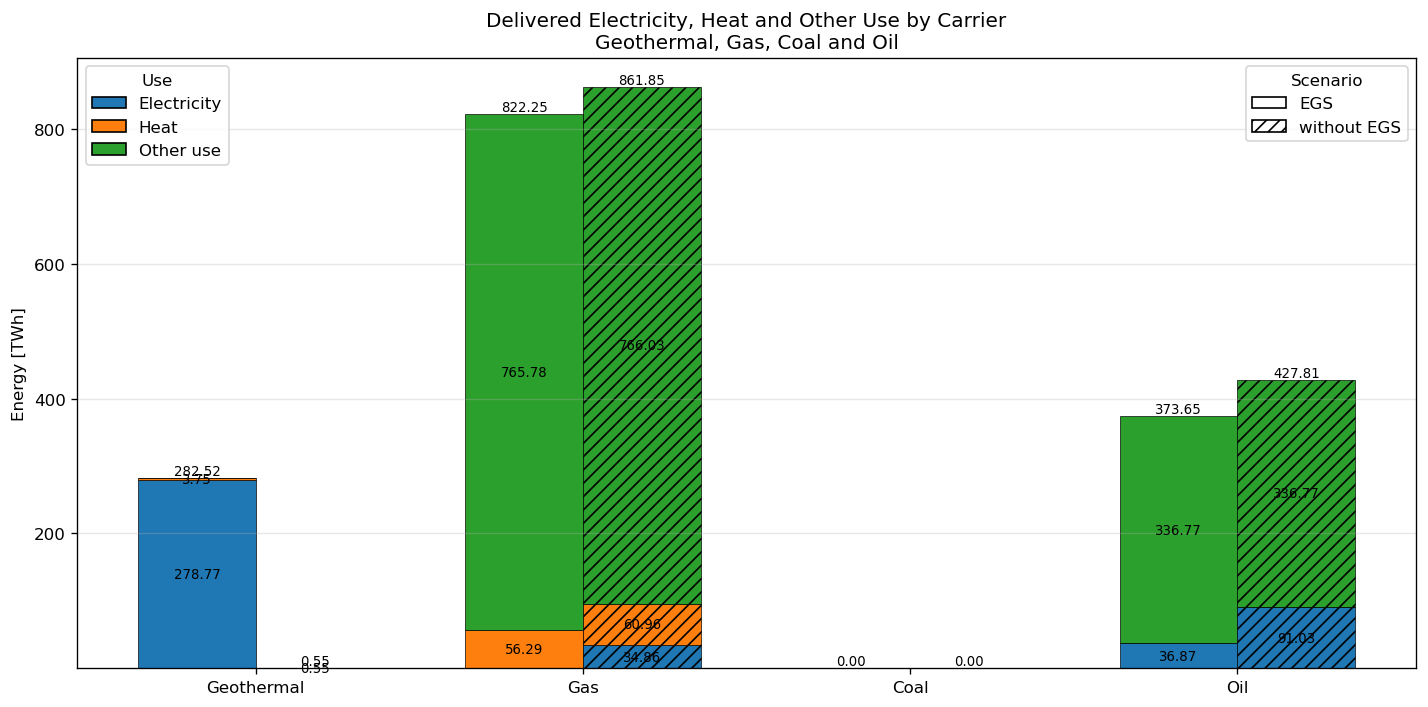

In [17]:
# ============================================================
# Delivered Electricity, Heat and Other Use by Carrier
# Vergleich: n_a vs. n_b
# Zwei gestapelte Balken je Technologie
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Heat buses are identified by their carrier name
heat_bus_pattern = "heat"

# Exclude non-energy output buses from "Other use"
non_energy_output_pattern = "co2|atmosphere|stored"

# Include existing conventional geothermal generators, if present
include_direct_geothermal_generators = True

# Exact geothermal link carrier names
orc_carrier = "geothermal organic rankine cycle"
dh_carrier = "geothermal district heat"

# Fossil fuels to analyse
fossil_fuels = ["gas", "coal", "oil"]

carrier_order = ["Geothermal", "Gas", "Coal", "Oil"]

use_columns = [
    "Electricity [TWh]",
    "Heat [TWh]",
    "Other use [TWh]",
]

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}


# ------------------------------------------------------------
# Helper: snapshot weighting
# ------------------------------------------------------------

def get_weights(n):
    """
    Returns snapshot weights in hours.
    MW * h = MWh
    """
    if (
        hasattr(n, "snapshot_weightings")
        and "generators" in n.snapshot_weightings.columns
    ):
        return n.snapshot_weightings["generators"].reindex(n.snapshots).fillna(1)

    return pd.Series(1.0, index=n.snapshots)


# ------------------------------------------------------------
# Helper: calculate output energy from links
# ------------------------------------------------------------

def get_link_output_energy_TWh(n, links_subset, output_type, weights):
    """
    Calculates delivered output energy from links in TWh.

    output_type:
        "electricity" -> output to AC/DC/low voltage buses
        "heat"        -> output to heat buses
        "other"       -> output to non-electric, non-heat, non-CO2 buses

    In PyPSA links:
        p0 is usually input.
        p1, p2, ... are outputs.
        Negative p on an output bus means injection into that bus.
    """
    energy_parts = []

    if links_subset.empty:
        return 0.0

    for bus_number in range(1, 6):
        bus_col = f"bus{bus_number}"
        p_col = f"p{bus_number}"

        if bus_col not in links_subset.columns:
            continue

        if not hasattr(n.links_t, p_col):
            continue

        output_bus_carrier = links_subset[bus_col].map(n.buses.carrier).astype(str)

        is_electricity = output_bus_carrier.isin(electric_bus_carriers)

        is_heat = output_bus_carrier.str.contains(
            heat_bus_pattern,
            case=False,
            regex=True,
            na=False,
        )

        is_non_energy = output_bus_carrier.str.contains(
            non_energy_output_pattern,
            case=False,
            regex=True,
            na=False,
        )

        if output_type == "electricity":
            mask = is_electricity

        elif output_type == "heat":
            mask = is_heat

        elif output_type == "other":
            mask = (
                ~is_electricity
                & ~is_heat
                & ~is_non_energy
                & output_bus_carrier.notna()
                & (output_bus_carrier != "nan")
            )

        else:
            raise ValueError("output_type must be 'electricity', 'heat' or 'other'.")

        if not mask.any():
            continue

        selected_links = links_subset.loc[mask]

        output = (
            -getattr(n.links_t, p_col)
            .reindex(index=n.snapshots, columns=selected_links.index)
            .fillna(0)
        )

        # Keep only positive delivered output
        output = output.clip(lower=0)

        energy_MWh = output.mul(weights, axis=0).sum().sum()
        energy_parts.append(energy_MWh)

    if len(energy_parts) == 0:
        return 0.0

    return sum(energy_parts) / 1e6  # MWh to TWh


# ------------------------------------------------------------
# Helper: calculate generator output energy
# ------------------------------------------------------------

def get_generator_energy_TWh(n, generators_subset, weights):
    """
    Calculates positive generator output in TWh.
    """
    if generators_subset.empty:
        return 0.0

    dispatch = (
        n.generators_t.p
        .reindex(index=n.snapshots, columns=generators_subset.index)
        .fillna(0)
    )

    dispatch = dispatch.clip(lower=0)

    energy_MWh = dispatch.mul(weights, axis=0).sum().sum()

    return energy_MWh / 1e6  # MWh to TWh


# ------------------------------------------------------------
# Helper: calculate direct load consumption
# ------------------------------------------------------------

def get_load_energy_TWh(n, loads_subset, weights):
    """
    Calculates direct final load consumption in TWh.
    Used for direct fossil loads, e.g. residential gas, services gas,
    transport oil, naphtha for industry, etc.
    """
    if loads_subset.empty:
        return 0.0

    static_p_set = (
        loads_subset["p_set"].fillna(0)
        if "p_set" in loads_subset.columns
        else pd.Series(0, index=loads_subset.index)
    )

    if hasattr(n.loads_t, "p_set"):
        load_ts = n.loads_t.p_set.reindex(
            index=n.snapshots,
            columns=loads_subset.index,
        )
    else:
        load_ts = pd.DataFrame(
            np.nan,
            index=n.snapshots,
            columns=loads_subset.index,
        )

    # Fill missing time series with static p_set
    load_ts = load_ts.T.fillna(static_p_set).T.fillna(0)

    load_ts = load_ts.clip(lower=0)

    energy_MWh = load_ts.mul(weights, axis=0).sum().sum()

    return energy_MWh / 1e6  # MWh to TWh


# ------------------------------------------------------------
# Main calculation for one network
# ------------------------------------------------------------

def calculate_energy_by_carrier(n, scenario_name):
    """
    Calculates delivered electricity, heat and other use for:
    - Geothermal
    - Gas
    - Coal
    - Oil
    """
    weights = get_weights(n)

    # --------------------------------------------------------
    # 1) Geothermal electricity and heat
    # --------------------------------------------------------

    links = n.links.copy()

    orc_links = links[
        links.carrier.astype(str).str.lower() == orc_carrier.lower()
    ].copy()

    dh_links = links[
        links.carrier.astype(str).str.lower() == dh_carrier.lower()
    ].copy()

    geothermal_electricity_TWh = get_link_output_energy_TWh(
        n,
        orc_links,
        output_type="electricity",
        weights=weights,
    )

    geothermal_heat_TWh = get_link_output_energy_TWh(
        n,
        dh_links,
        output_type="heat",
        weights=weights,
    )

    geothermal_other_TWh = 0.0

    direct_geothermal_generator_TWh = 0.0

    if include_direct_geothermal_generators:
        generators = n.generators.copy()

        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        direct_geothermal_generators = generators[
            generators.carrier.astype(str).str.contains(
                "geothermal",
                case=False,
                regex=True,
                na=False,
            )
            & generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        direct_geothermal_generator_TWh = get_generator_energy_TWh(
            n,
            direct_geothermal_generators,
            weights,
        )

        geothermal_electricity_TWh += direct_geothermal_generator_TWh


    # --------------------------------------------------------
    # 2) Fossil electricity, heat and other use
    # --------------------------------------------------------

    links["input_bus_carrier"] = links.bus0.map(n.buses.carrier)

    fossil_links = links[
        links["input_bus_carrier"].isin(fossil_fuels)
    ].copy()

    loads = n.loads.copy()
    loads["bus_carrier"] = loads.bus.map(n.buses.carrier)

    fossil_results = []
    other_breakdown = []

    for fuel in fossil_fuels:
        selected_fuel_links = fossil_links[
            fossil_links["input_bus_carrier"] == fuel
        ].copy()

        electricity_TWh = get_link_output_energy_TWh(
            n,
            selected_fuel_links,
            output_type="electricity",
            weights=weights,
        )

        heat_TWh = get_link_output_energy_TWh(
            n,
            selected_fuel_links,
            output_type="heat",
            weights=weights,
        )

        other_link_output_TWh = get_link_output_energy_TWh(
            n,
            selected_fuel_links,
            output_type="other",
            weights=weights,
        )

        direct_fuel_loads = loads[
            loads["bus_carrier"] == fuel
        ].copy()

        direct_load_TWh = get_load_energy_TWh(
            n,
            direct_fuel_loads,
            weights,
        )

        other_TWh = other_link_output_TWh + direct_load_TWh

        fossil_results.append({
            "carrier": fuel.capitalize(),
            "Electricity [TWh]": electricity_TWh,
            "Heat [TWh]": heat_TWh,
            "Other use [TWh]": other_TWh,
        })

        other_breakdown.append({
            "carrier": fuel.capitalize(),
            "Direct fossil loads [TWh]": direct_load_TWh,
            "Other link outputs [TWh]": other_link_output_TWh,
            "Other use total [TWh]": other_TWh,
        })


    # --------------------------------------------------------
    # 3) Combine results
    # --------------------------------------------------------

    energy_by_carrier = pd.DataFrame(
        [
            {
                "carrier": "Geothermal",
                "Electricity [TWh]": geothermal_electricity_TWh,
                "Heat [TWh]": geothermal_heat_TWh,
                "Other use [TWh]": geothermal_other_TWh,
            }
        ]
        + fossil_results
    ).set_index("carrier")

    energy_by_carrier = energy_by_carrier.reindex(carrier_order).fillna(0)

    # Remove tiny numerical values
    energy_by_carrier = energy_by_carrier.where(
        energy_by_carrier.abs() > 1e-6,
        0,
    )

    energy_by_carrier["Total [TWh]"] = energy_by_carrier[use_columns].sum(axis=1)

    other_breakdown = (
        pd.DataFrame(other_breakdown)
        .set_index("carrier")
        .reindex(["Gas", "Coal", "Oil"])
        .fillna(0)
    )

    # --------------------------------------------------------
    # 4) Optional check: primary fuel from generators
    # --------------------------------------------------------

    fuel_generators = n.generators[
        n.generators.carrier.astype(str).str.lower().isin(fossil_fuels)
    ].copy()

    if not fuel_generators.empty:
        fuel_imports_from_generators_TWh = (
            n.generators_t.p
            .reindex(columns=fuel_generators.index)
            .fillna(0)
            .clip(lower=0)
            .mul(weights, axis=0)
            .sum()
            .groupby(fuel_generators.carrier)
            .sum()
            .div(1e6)
            .sort_values(ascending=False)
        )
    else:
        fuel_imports_from_generators_TWh = pd.Series(dtype=float)

    print(f"\n{scenario_name}")
    print(
        f"Direct geothermal generator contribution: "
        f"{direct_geothermal_generator_TWh:.3f} TWh"
    )

    return {
        "energy_by_carrier": energy_by_carrier,
        "other_breakdown": other_breakdown,
        "fuel_imports_from_generators_TWh": fuel_imports_from_generators_TWh,
        "direct_geothermal_generator_TWh": direct_geothermal_generator_TWh,
    }


# ------------------------------------------------------------
# Calculate both scenarios
# ------------------------------------------------------------

scenario_results = {}

for scenario_name, network in networks_to_compare.items():
    scenario_results[scenario_name] = calculate_energy_by_carrier(
        network,
        scenario_name,
    )


# ------------------------------------------------------------
# Tables
# ------------------------------------------------------------

energy_by_carrier_comparison = pd.concat(
    {
        scenario_name: result["energy_by_carrier"]
        for scenario_name, result in scenario_results.items()
    },
    names=["Scenario", "Carrier"],
)

display(energy_by_carrier_comparison)

other_breakdown_comparison = pd.concat(
    {
        scenario_name: result["other_breakdown"]
        for scenario_name, result in scenario_results.items()
    },
    names=["Scenario", "Carrier"],
)

display(other_breakdown_comparison)

fuel_imports_comparison = pd.DataFrame({
    scenario_name: result["fuel_imports_from_generators_TWh"]
    for scenario_name, result in scenario_results.items()
}).fillna(0)

display(
    fuel_imports_comparison
    .rename_axis("fuel")
)


# ------------------------------------------------------------
# Plot: grouped stacked bar chart
# ------------------------------------------------------------

plot_data = {
    scenario_name: result["energy_by_carrier"][use_columns].copy()
    for scenario_name, result in scenario_results.items()
}

scenario_list = list(plot_data.keys())

use_colors = {
    "Electricity [TWh]": "#1f77b4",
    "Heat [TWh]": "#ff7f0e",
    "Other use [TWh]": "#2ca02c",
}

scenario_hatches = {
    scenario_list[0]: "",
    scenario_list[1]: "///" if len(scenario_list) > 1 else "",
}

x = np.arange(len(carrier_order))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(12, 6))

for scenario_idx, scenario_name in enumerate(scenario_list):
    scenario_df = (
        plot_data[scenario_name]
        .reindex(carrier_order)
        .fillna(0)
    )

    offset = (scenario_idx - (len(scenario_list) - 1) / 2) * bar_width

    bottom = np.zeros(len(carrier_order))

    for use_col in use_columns:
        values = scenario_df[use_col].values

        bars = ax.bar(
            x + offset,
            values,
            width=bar_width,
            bottom=bottom,
            color=use_colors[use_col],
            edgecolor="black",
            linewidth=0.4,
            hatch=scenario_hatches.get(scenario_name, ""),
            label=use_col if scenario_idx == 0 else None,
        )

        labels = [
            f"{value:.2f}" if value > 0.5 else ""
            for value in values
        ]

        ax.bar_label(
            bars,
            labels=labels,
            label_type="center",
            fontsize=8,
        )

        bottom += values

    # Total labels above each scenario bar
    totals = scenario_df.sum(axis=1).values

    for xpos, total in zip(x + offset, totals):
        if total > 0:
            ax.text(
                xpos,
                total,
                f"{total:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=0,
            )


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_ylabel("Energy [TWh]")
ax.set_xlabel("")
ax.set_title(
    "Delivered Electricity, Heat and Other Use by Carrier\n"
    "Geothermal, Gas, Coal and Oil"
)

ax.set_xticks(x)
ax.set_xticklabels(carrier_order, rotation=0)

ax.grid(axis="y", alpha=0.3)


# ------------------------------------------------------------
# Legends
# ------------------------------------------------------------

use_legend_handles = [
    Patch(
        facecolor=use_colors[use_col],
        edgecolor="black",
        label=use_col.replace(" [TWh]", ""),
    )
    for use_col in use_columns
]

scenario_legend_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch=scenario_hatches.get(scenario_name, ""),
        label=scenario_name,
    )
    for scenario_name in scenario_list
]

legend1 = ax.legend(
    handles=use_legend_handles,
    title="Use",
    loc="upper left",
)

ax.add_artist(legend1)

ax.legend(
    handles=scenario_legend_handles,
    title="Scenario",
    loc="upper right",
)

plt.tight_layout()
plt.show()

EGS: Total heat consumption = 90.30 TWh
without EGS: Total heat consumption = 90.30 TWh


,EGS,without EGS
heat_sector,,
residential urban decentral heat,81.546508,81.546508
urban central heat,4.492860,4.492860
residential rural heat,3.549478,3.549478
services urban decentral heat,0.684812,0.684812
services rural heat,0.029808,0.029808
Total,90.303466,90.303466



Detailed heat loads: EGS


,bus,bus_carrier,carrier,heat_consumption_TWh
Load,,,,
JP.41_1_AC residential urban decentral heat,JP.41_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,7.230596
JP.35_1_AC residential urban decentral heat,JP.35_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,6.172094
JP.19_1_AC residential urban decentral heat,JP.19_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,5.873969
JP.1_1_AC residential urban decentral heat,JP.1_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,4.287722
JP.33_1_AC residential urban decentral heat,JP.33_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,4.115623
...,...,...,...,...
JP.14_1_AC services rural heat,JP.14_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.33_1_AC services rural heat,JP.33_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.19_1_AC services rural heat,JP.19_1_AC services rural heat,services rural heat,services rural heat,0.000004



Detailed heat loads: without EGS


,bus,bus_carrier,carrier,heat_consumption_TWh
Load,,,,
JP.41_1_AC residential urban decentral heat,JP.41_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,7.230596
JP.35_1_AC residential urban decentral heat,JP.35_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,6.172094
JP.19_1_AC residential urban decentral heat,JP.19_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,5.873969
JP.1_1_AC residential urban decentral heat,JP.1_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,4.287722
JP.33_1_AC residential urban decentral heat,JP.33_1_AC residential urban decentral heat,residential urban decentral heat,residential urban decentral heat,4.115623
...,...,...,...,...
JP.14_1_AC services rural heat,JP.14_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.33_1_AC services rural heat,JP.33_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.19_1_AC services rural heat,JP.19_1_AC services rural heat,services rural heat,services rural heat,0.000004


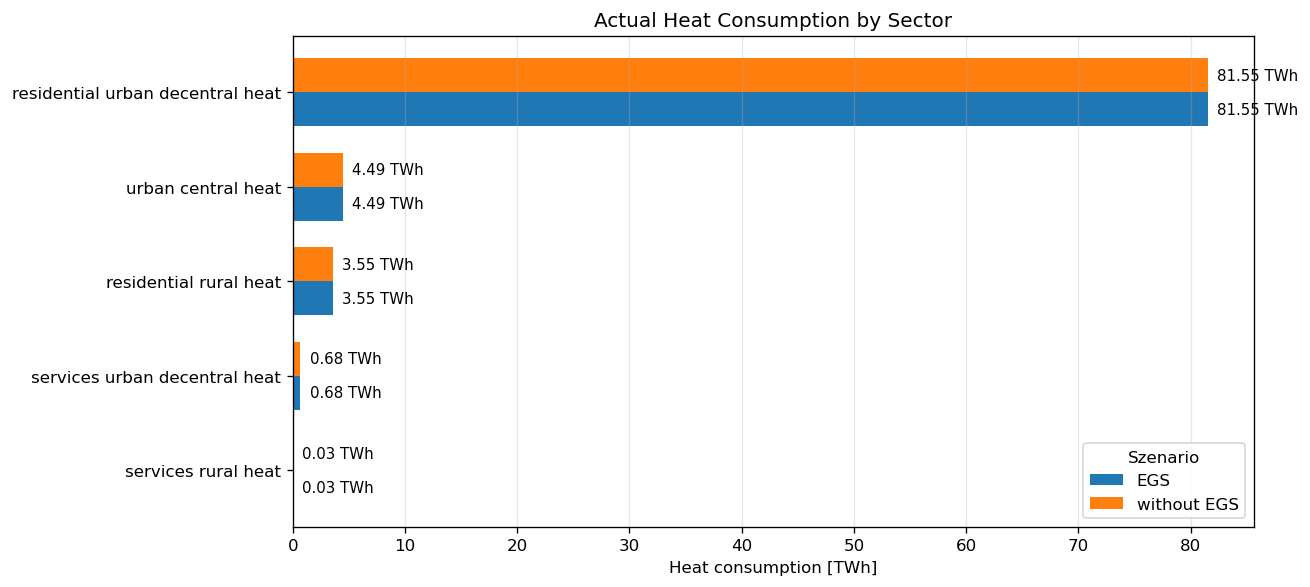

In [18]:
# ============================================================
# Actual Heat Consumption by Sector
# Vergleich: n_a vs. n_b
# Zwei Balken je Kategorie
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}

min_heat_consumption_TWh = 1e-9

scenario_colors = ["#1f77b4", "#ff7f0e"]


# ------------------------------------------------------------
# 1) Snapshot weights
# ------------------------------------------------------------

def get_snapshot_weights(network):
    """
    Returns snapshot weights for energy calculation.
    MW * hours = MWh
    """
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)

        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


# ------------------------------------------------------------
# 2) Main function: calculate heat consumption for one network
# ------------------------------------------------------------

def calculate_heat_consumption_by_sector(network, scenario_name):
    """
    Calculates actual heat consumption by heat bus carrier in TWh.

    Endverbrauch wird hier als Last auf Heat-Bussen definiert.
    Interne Wärmeflüsse, z.B. Speicher- oder Geothermieflüsse,
    werden nicht als Endverbrauch gezählt.
    """

    weights = get_snapshot_weights(network)

    # --------------------------------------------------------
    # Detect heat bus carriers
    # --------------------------------------------------------

    heat_bus_carriers = (
        network.buses.carrier.astype(str)
        .loc[lambda s: s.str.contains("heat", case=False, na=False)]
        .dropna()
        .sort_values()
        .unique()
        .tolist()
    )

    if not heat_bus_carriers:
        print(f"{scenario_name}: Keine Heat-Bus-Carrier im Netzwerk gefunden.")
        return pd.Series(dtype=float), pd.DataFrame()

    # --------------------------------------------------------
    # Heat loads
    # --------------------------------------------------------

    loads = network.loads.copy()

    if loads.empty:
        print(f"{scenario_name}: Keine Loads im Netzwerk gefunden.")
        return pd.Series(dtype=float), pd.DataFrame()

    loads["bus_carrier"] = loads.bus.map(network.buses.carrier)

    heat_loads = loads[
        loads["bus_carrier"].isin(heat_bus_carriers)
    ].copy()

    if heat_loads.empty:
        print(f"{scenario_name}: Keine Loads auf Heat-Bussen gefunden.")
        return pd.Series(dtype=float), pd.DataFrame()

    # --------------------------------------------------------
    # Load time series
    # --------------------------------------------------------

    static_p_set = (
        heat_loads["p_set"].fillna(0)
        if "p_set" in heat_loads.columns
        else pd.Series(0.0, index=heat_loads.index)
    )

    if hasattr(network.loads_t, "p_set") and not network.loads_t.p_set.empty:
        heat_load_ts = network.loads_t.p_set.reindex(
            index=network.snapshots,
            columns=heat_loads.index
        )
    else:
        heat_load_ts = pd.DataFrame(
            np.nan,
            index=network.snapshots,
            columns=heat_loads.index
)

    # Fill missing time series with static p_set
    heat_load_ts = heat_load_ts.T.fillna(static_p_set).T.fillna(0)

    # Positive values are consumption
    heat_load_ts = heat_load_ts.clip(lower=0)

    # --------------------------------------------------------
    # Convert MW to TWh
    # --------------------------------------------------------

    heat_consumption_by_load_TWh = (
        heat_load_ts
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)  # MWh to TWh
    )

    heat_loads["heat_consumption_TWh"] = heat_consumption_by_load_TWh

    # --------------------------------------------------------
    # Aggregate by heat sector
    # --------------------------------------------------------

    heat_consumption_by_sector = (
        heat_loads
        .groupby("bus_carrier")["heat_consumption_TWh"]
        .sum()
        .sort_values(ascending=False)
    )

    heat_consumption_by_sector = heat_consumption_by_sector[
        heat_consumption_by_sector > min_heat_consumption_TWh
    ]

    # --------------------------------------------------------
    # Detailed load table
    # --------------------------------------------------------

    heat_load_detail = (
        heat_loads[
            [
                "bus",
                "bus_carrier",
                "carrier",
                "heat_consumption_TWh",
            ]
        ]
        .copy()
        .sort_values("heat_consumption_TWh", ascending=False)
    )

    heat_load_detail = heat_load_detail[
        heat_load_detail["heat_consumption_TWh"] > min_heat_consumption_TWh
    ]

    total_heat_consumption_TWh = heat_consumption_by_sector.sum()

    print(
        f"{scenario_name}: Total heat consumption = "
        f"{total_heat_consumption_TWh:.2f} TWh"
    )

    return heat_consumption_by_sector, heat_load_detail


# ------------------------------------------------------------
# 3) Calculate both scenarios
# ------------------------------------------------------------

heat_results = {}
heat_detail_results = {}

for scenario_name, network in networks_to_compare.items():
    heat_sector_series, heat_detail_table = calculate_heat_consumption_by_sector(
        network,
        scenario_name
    )

    heat_results[scenario_name] = heat_sector_series
    heat_detail_results[scenario_name] = heat_detail_table


# ------------------------------------------------------------
# 4) Comparison table
# ------------------------------------------------------------

heat_consumption_comparison = pd.DataFrame(heat_results).fillna(0)

# Keep only sectors with heat consumption in at least one scenario
heat_consumption_comparison = heat_consumption_comparison[
    heat_consumption_comparison.sum(axis=1) > min_heat_consumption_TWh
]

# Sort by total heat consumption across both scenarios
heat_consumption_comparison = heat_consumption_comparison.loc[
    heat_consumption_comparison.sum(axis=1).sort_values(ascending=False).index
]

# Add total row
heat_consumption_comparison_with_total = heat_consumption_comparison.copy()
heat_consumption_comparison_with_total.loc["Total"] = (
    heat_consumption_comparison_with_total.sum(axis=0)
)

display(
    heat_consumption_comparison_with_total
    .rename_axis("heat_sector")
)


# ------------------------------------------------------------
# 5) Optional detailed load tables
# ------------------------------------------------------------

for scenario_name, detail_table in heat_detail_results.items():
    print(f"\nDetailed heat loads: {scenario_name}")
    display(detail_table)


# ------------------------------------------------------------
# 6) Plot: grouped horizontal bar chart
# ------------------------------------------------------------

plot_df = heat_consumption_comparison.sort_values(
    by=heat_consumption_comparison.columns[0],
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(11, max(5, 0.55 * len(plot_df)))
)

y = np.arange(len(plot_df.index))
bar_height = 0.36

scenario_list = list(plot_df.columns)

for scenario_idx, scenario_name in enumerate(scenario_list):
    offset = (scenario_idx - (len(scenario_list) - 1) / 2) * bar_height

    bars = ax.barh(
        y + offset,
        plot_df[scenario_name].values,
        height=bar_height,
        label=scenario_name,
        color=scenario_colors[scenario_idx % len(scenario_colors)]
    )

    # Value labels
    xmax = plot_df.max().max()

    for bar, value in zip(bars, plot_df[scenario_name].values):
        if value > min_heat_consumption_TWh:
            ax.text(
                value + (0.01 * xmax if xmax > 0 else 0.1),
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f} TWh",
                va="center",
                fontsize=9
            )


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("Heat consumption [TWh]")
ax.set_ylabel("")
ax.set_title("Actual Heat Consumption by Sector")

ax.grid(axis="x", alpha=0.3)
ax.legend(title="Szenario")

plt.tight_layout()
plt.show()

EGS: Total heat supply = 442.05 TWh
without EGS: Total heat supply = 488.22 TWh


,EGS,without EGS
technology_group,,
Solid Biomass CHP,3.524794e+02,4.011422e+02
Gas Boiler,5.628809e+01,6.096354e+01
Resistive Heater,1.833113e+01,1.593044e+01
Heat Pump,1.119808e+01,1.017899e+01
Geothermal District Heat,3.749946e+00,0.000000e+00
Gas CHP,1.940687e-05,4.280186e-05
Water Tank Discharger,4.897760e-07,8.797485e-07
Total,4.420466e+02,4.882152e+02


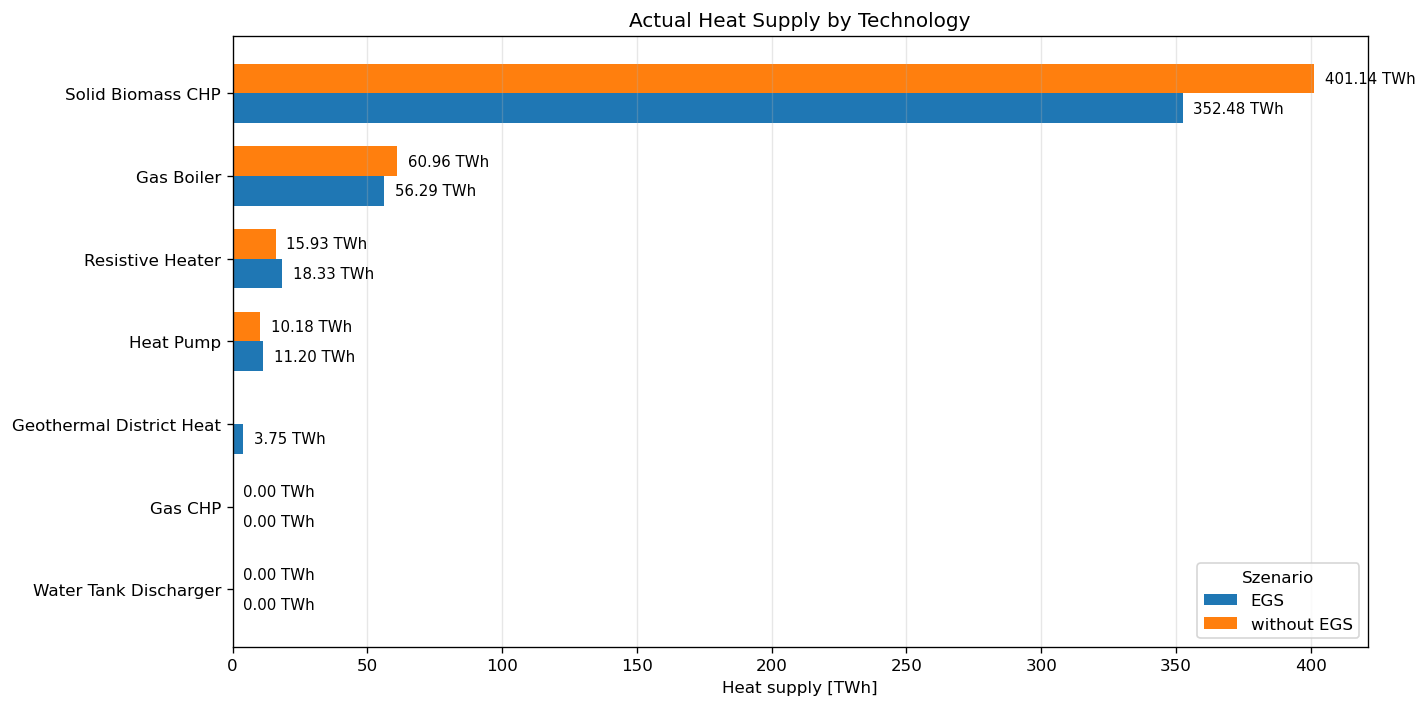

In [19]:
# ============================================================
# Actual Heat Supply by Technology
# Vergleich: n_a vs. n_b
# Zwei Balken je Technologie
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}

min_heat_supply_TWh = 1e-9

scenario_colors = ["#1f77b4", "#ff7f0e"]


# ------------------------------------------------------------
# 1) Snapshot weights
# ------------------------------------------------------------

def get_snapshot_weights(network):
    """
    Returns snapshot weights for energy calculation.
    MW * hours = MWh
    """
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)

        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


# ------------------------------------------------------------
# 2) Helper functions for clearer labels
# ------------------------------------------------------------

def rename_heat_sector(heat_sector):
    heat_sector = str(heat_sector)

    if heat_sector == "urban central heat":
        return "district heat / urban central heat"

    return heat_sector


def group_heat_technology(carrier):
    carrier = str(carrier)
    carrier_lower = carrier.lower()

    if "geothermal district heat" in carrier_lower:
        return "Geothermal District Heat"

    if "solid biomass chp" in carrier_lower:
        return "Solid Biomass CHP"

    if "gas chp" in carrier_lower:
        return "Gas CHP"

    if "gas boiler" in carrier_lower:
        return "Gas Boiler"

    if "heat pump" in carrier_lower:
        return "Heat Pump"

    if "resistive heater" in carrier_lower:
        return "Resistive Heater"

    if "water tanks discharger" in carrier_lower:
        return "Water Tank Discharger"

    if "water tanks charger" in carrier_lower:
        return "Water Tank Charger"

    if "solar thermal" in carrier_lower:
        return "Solar Thermal"

    if "biomass boiler" in carrier_lower:
        return "Biomass Boiler"

    if "oil boiler" in carrier_lower:
        return "Oil Boiler"

    return carrier


# ------------------------------------------------------------
# 3) Main function: calculate heat supply for one network
# ------------------------------------------------------------

def calculate_heat_supply_by_technology(network, scenario_name):
    """
    Calculates actual heat supply by technology group in TWh.

    Gezählt werden Link-Ausgänge auf finale Heat-Busse.
    Der Bus-Carrier 'geothermal heat' wird ausgeschlossen,
    weil er als interne Geothermie-Quelle interpretiert wird.
    """

    weights = get_snapshot_weights(network)

    # --------------------------------------------------------
    # Final heat bus carriers
    # --------------------------------------------------------

    final_heat_bus_carriers = (
        network.buses.carrier.astype(str)
        .loc[lambda s: s.str.contains("heat", case=False, na=False)]
        .dropna()
        .sort_values()
        .unique()
        .tolist()
    )

    final_heat_bus_carriers = [
        c for c in final_heat_bus_carriers
        if c.lower() != "geothermal heat"
    ]

    if not final_heat_bus_carriers:
        print(f"{scenario_name}: Keine finalen Heat-Bus-Carrier gefunden.")
        return pd.Series(dtype=float), pd.DataFrame(), pd.Series(dtype=float)

    # --------------------------------------------------------
    # Heat supply from links
    # --------------------------------------------------------

    links = network.links.copy()

    heat_supply_rows = []

    for bus_number in range(1, 6):
        bus_col = f"bus{bus_number}"
        p_col = f"p{bus_number}"

        if bus_col not in links.columns:
            continue

        if not hasattr(network.links_t, p_col):
            continue

        output_bus_carrier = links[bus_col].map(network.buses.carrier)

        mask = output_bus_carrier.isin(final_heat_bus_carriers)

        if not mask.any():
            continue

        selected_links = links.loc[mask].copy()

        # In PyPSA links:
        # negative p at output bus = injection/supply into that bus.
        heat_output = (
            -getattr(network.links_t, p_col)
            .reindex(index=network.snapshots, columns=selected_links.index)
            .fillna(0)
        ).clip(lower=0)

        heat_energy_by_link_TWh = (
            heat_output
            .mul(weights, axis=0)
            .sum(axis=0)
            .div(1e6)  # MWh to TWh
        )

        for link_name, value in heat_energy_by_link_TWh.items():
            if value <= min_heat_supply_TWh:
                continue

            technology = selected_links.loc[link_name, "carrier"]
            heat_sector = output_bus_carrier.loc[link_name]

            heat_supply_rows.append({
                "scenario": scenario_name,
                "technology": technology,
                "technology_group": group_heat_technology(technology),
                "link": link_name,
                "heat_sector": rename_heat_sector(heat_sector),
                "raw_heat_sector": heat_sector,
                "heat_supply_TWh": value,
            })

    heat_supply_detail = pd.DataFrame(heat_supply_rows)

    if heat_supply_detail.empty:
        print(f"{scenario_name}: Keine Wärmebereitstellung aus Links gefunden.")
        return pd.Series(dtype=float), pd.DataFrame(), pd.Series(dtype=float)

    # --------------------------------------------------------
    # Detailed table: technology and heat sector
    # --------------------------------------------------------

    heat_supply_by_technology_sector = (
        heat_supply_detail
        .groupby(
            ["technology", "technology_group", "heat_sector"],
            as_index=False
        )["heat_supply_TWh"]
        .sum()
        .sort_values("heat_supply_TWh", ascending=False)
    )

    # --------------------------------------------------------
    # Aggregate by technology group
    # --------------------------------------------------------

    heat_supply_by_group = (
        heat_supply_detail
        .groupby("technology_group")["heat_supply_TWh"]
        .sum()
        .sort_values(ascending=False)
    )

    # --------------------------------------------------------
    # Aggregate by final heat sector
    # --------------------------------------------------------

    heat_supply_by_sector = (
        heat_supply_detail
        .groupby("heat_sector")["heat_supply_TWh"]
        .sum()
        .sort_values(ascending=False)
    )

    total_heat_supply_TWh = heat_supply_by_group.sum()

    print(
        f"{scenario_name}: Total heat supply = "
        f"{total_heat_supply_TWh:.2f} TWh"
    )

    return heat_supply_by_group, heat_supply_by_technology_sector, heat_supply_by_sector


# ------------------------------------------------------------
# 4) Calculate both scenarios
# ------------------------------------------------------------

heat_supply_group_results = {}
heat_supply_detail_results = {}
heat_supply_sector_results = {}

for scenario_name, network in networks_to_compare.items():
    group_series, detail_table, sector_series = calculate_heat_supply_by_technology(
        network,
        scenario_name
    )

    heat_supply_group_results[scenario_name] = group_series
    heat_supply_detail_results[scenario_name] = detail_table
    heat_supply_sector_results[scenario_name] = sector_series


# ------------------------------------------------------------
# 5) Comparison table: heat supply by technology group
# ------------------------------------------------------------

heat_supply_comparison = pd.DataFrame(heat_supply_group_results).fillna(0)

heat_supply_comparison = heat_supply_comparison[
    heat_supply_comparison.sum(axis=1) > min_heat_supply_TWh
]

heat_supply_comparison = heat_supply_comparison.loc[
    heat_supply_comparison.sum(axis=1).sort_values(ascending=False).index
]

heat_supply_comparison_with_total = heat_supply_comparison.copy()
heat_supply_comparison_with_total.loc["Total"] = (
    heat_supply_comparison_with_total.sum(axis=0)
)

display(
    heat_supply_comparison_with_total
    .rename_axis("technology_group")
)


# ------------------------------------------------------------
# 6) Detailed tables
# ------------------------------------------------------------

#for scenario_name, detail_table in heat_supply_detail_results.items():
#    print(f"\nDetailed heat supply by technology and heat sector: {scenario_name}")
#    display(detail_table)


# ------------------------------------------------------------
# 7) Heat supply by final heat sector
# ------------------------------------------------------------

heat_supply_sector_comparison = pd.DataFrame(
    heat_supply_sector_results
).fillna(0)

heat_supply_sector_comparison = heat_supply_sector_comparison[
    heat_supply_sector_comparison.sum(axis=1) > min_heat_supply_TWh
]

heat_supply_sector_comparison = heat_supply_sector_comparison.loc[
    heat_supply_sector_comparison.sum(axis=1).sort_values(ascending=False).index
]

#display(heat_supply_sector_comparison.rename_axis("heat_sector"))


# ------------------------------------------------------------
# 8) Plot: grouped horizontal bar chart
# ------------------------------------------------------------

plot_df = heat_supply_comparison.sort_values(
    by=heat_supply_comparison.sum(axis=1).name
    if heat_supply_comparison.sum(axis=1).name is not None
    else heat_supply_comparison.columns[0],
    ascending=True
)

# Sauberer sortieren nach Summe über beide Szenarien
plot_df = heat_supply_comparison.loc[
    heat_supply_comparison.sum(axis=1).sort_values(ascending=True).index
]

fig, ax = plt.subplots(
    figsize=(12, max(6, 0.55 * len(plot_df)))
)

y = np.arange(len(plot_df.index))
bar_height = 0.36

scenario_list = list(plot_df.columns)

xmax = plot_df.max().max() if not plot_df.empty else 0

for scenario_idx, scenario_name in enumerate(scenario_list):
    offset = (scenario_idx - (len(scenario_list) - 1) / 2) * bar_height

    bars = ax.barh(
        y + offset,
        plot_df[scenario_name].values,
        height=bar_height,
        label=scenario_name,
        color=scenario_colors[scenario_idx % len(scenario_colors)]
    )

    for bar, value in zip(bars, plot_df[scenario_name].values):
        if value > min_heat_supply_TWh:
            ax.text(
                value + (0.01 * xmax if xmax > 0 else 0.1),
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f} TWh",
                va="center",
                fontsize=9
            )


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("Heat supply [TWh]")
ax.set_ylabel("")
ax.set_title("Actual Heat Supply by Technology")

ax.grid(axis="x", alpha=0.3)
ax.legend(title="Szenario")

plt.tight_layout()
plt.show()

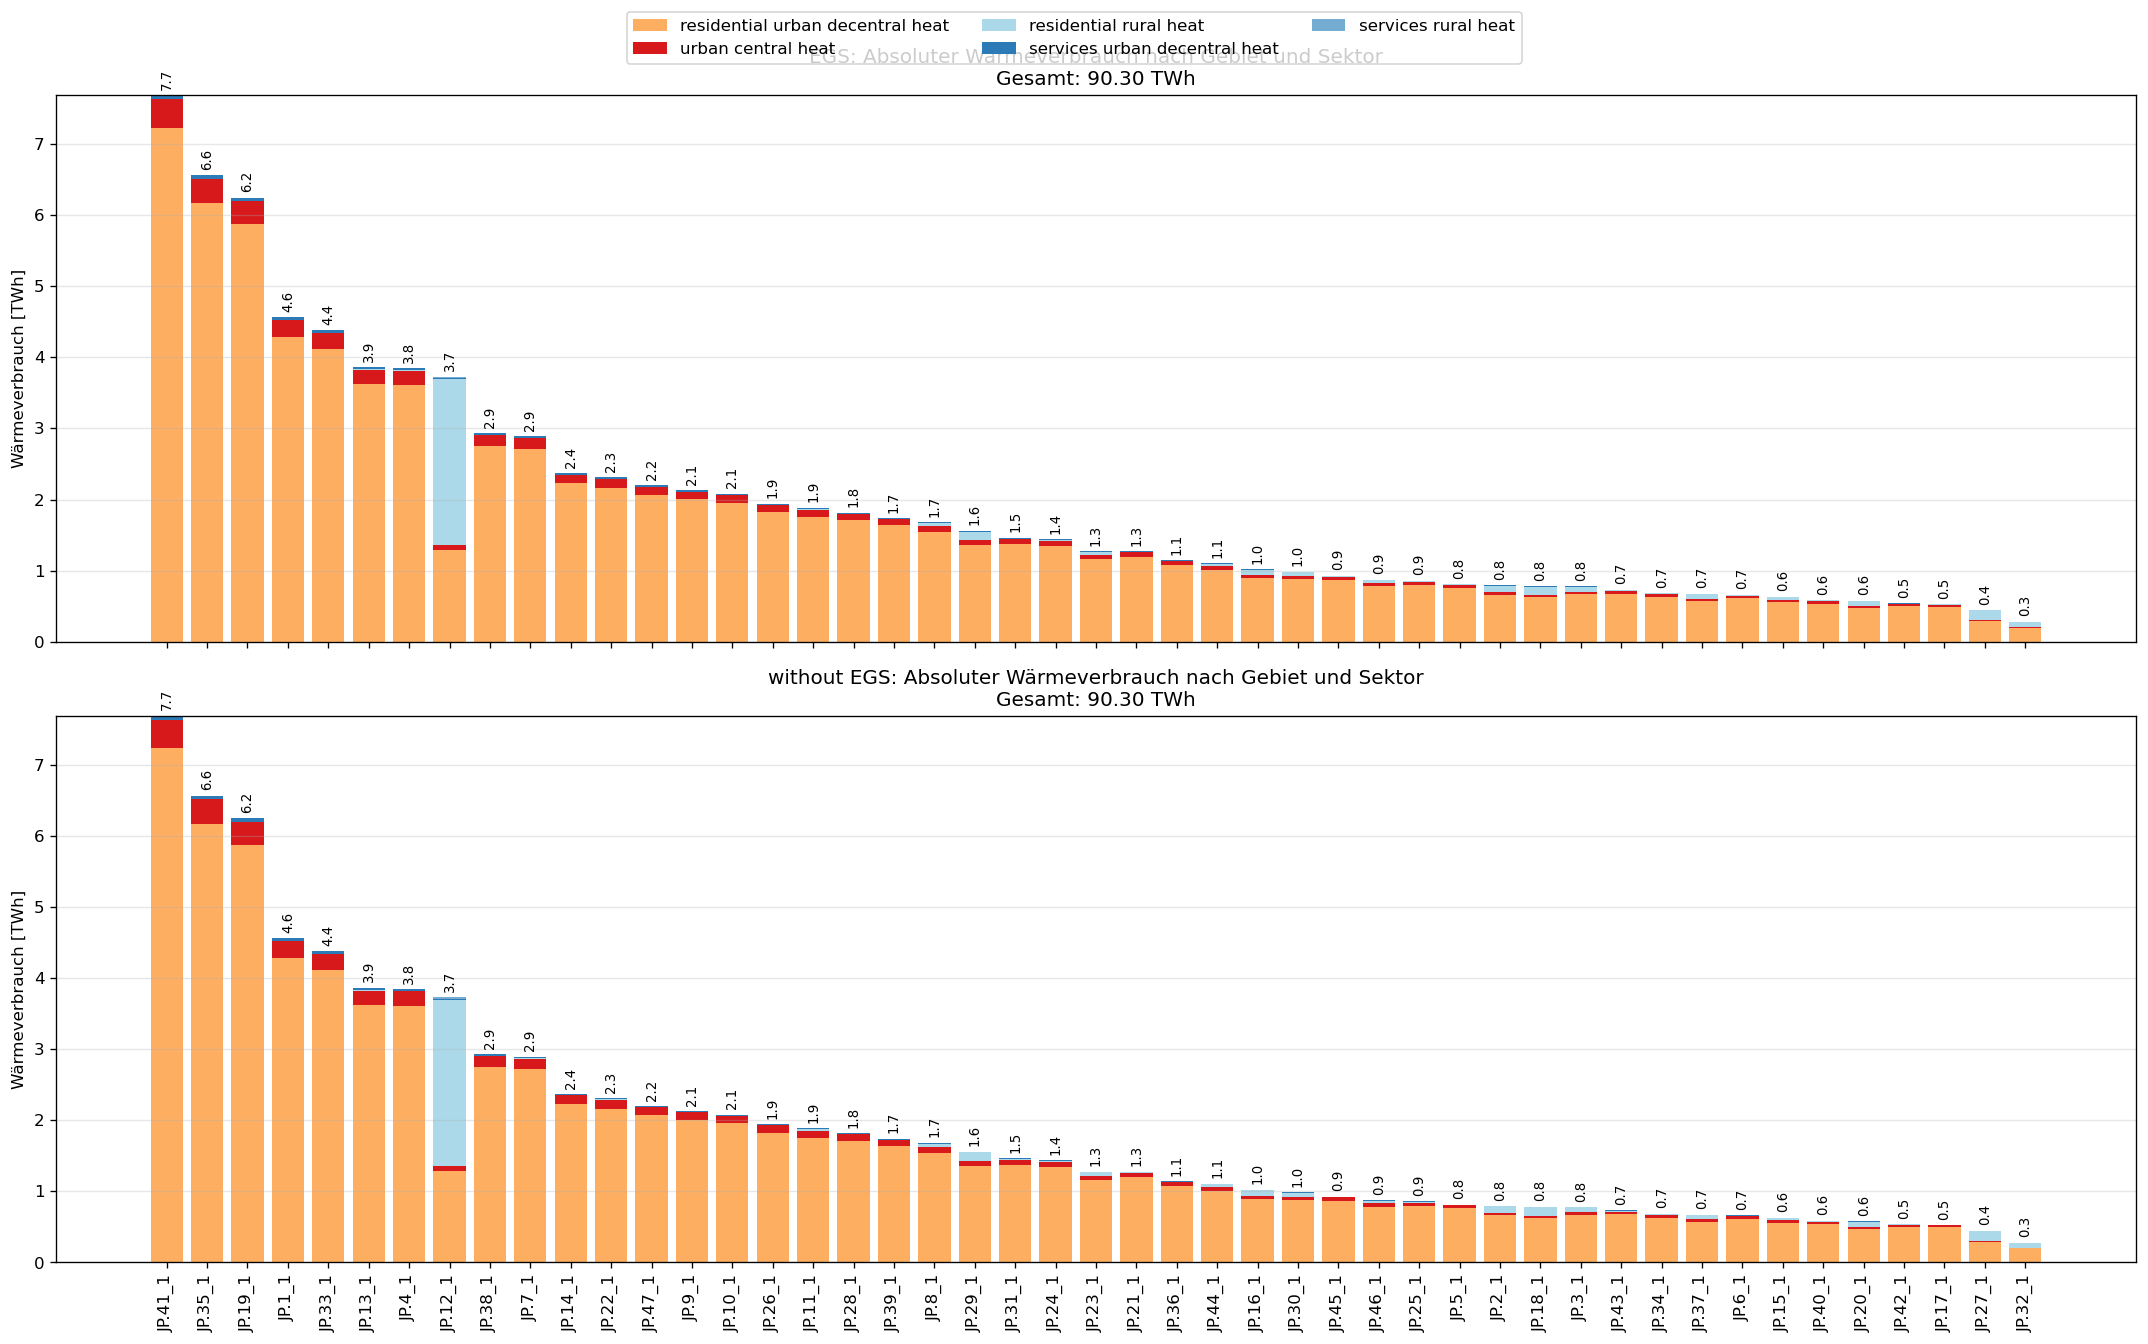

In [28]:
# ============================================================
# Absoluter Wärmeverbrauch je Gebiet und Heat-Sektor
#
# Gezeigt werden je Region:
# - residential urban decentral heat
# - urban central heat
# - residential rural heat
# - services urban decentral heat
# - services rural heat
#
# Für beide Szenarien: n_a und n_b
# Ergebnis: gestapelte Balkendiagramme mit absolutem Verbrauch
# Automatische Einheit: TWh oder GWh
# ============================================================


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

scenario_name_a = SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "EGS"
scenario_name_b = SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "without EGS"

networks_to_plot = {
    scenario_name_a: n_a,
    scenario_name_b: n_b,
}

heat_sectors_order = [
    "residential urban decentral heat",
    "urban central heat",
    "residential rural heat",
    "services urban decentral heat",
    "services rural heat",
]

# Nur Regionen anzeigen, deren gesamter Wärmeverbrauch größer ist als:
min_total_heat_TWh = 0.001

# Regionen nach gesamtem Wärmeverbrauch sortieren
sort_regions_by_total_heat = True

# Automatische Einheit:
# Wenn max. regionaler Sektorwert kleiner als dieser Wert ist, wird GWh verwendet.
# Sonst TWh.
gwh_threshold_TWh = 1.0

heat_sector_colors = {
    "residential urban decentral heat": "#fdae61",
    "urban central heat": "#d7191c",
    "residential rural heat": "#abd9e9",
    "services urban decentral heat": "#2c7bb6",
    "services rural heat": "#74add1",
}


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def bus_to_region(bus_name):
    """
    Entfernt typische PyPSA-Earth-Suffixe aus Busnamen.

    Beispiele:
    JP.13_1_AC residential urban decentral heat -> JP.13_1
    JP.13_1_AC urban central heat               -> JP.13_1
    JP.13_1_AC                                  -> JP.13_1
    JPN.13_1                                    -> JP.13_1
    """
    s = str(bus_name).strip()

    match = pd.Series([s]).str.extract(r"^([A-Z]{2,3}\.\d+_\d+)")[0].iloc[0]

    if pd.notna(match):
        s = match

    suffixes = [
        "_AC",
        "_DC",
        " AC",
        " DC",
        " low voltage",
        "_low voltage",

        " residential urban decentral heat",
        "_residential urban decentral heat",
        " urban central heat",
        "_urban central heat",
        " residential rural heat",
        "_residential rural heat",
        " services urban decentral heat",
        "_services urban decentral heat",
        " services rural heat",
        "_services rural heat",

        " heat",
        "_heat",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    if s.startswith("JPN."):
        s = "JP." + s[len("JPN."):]

    return s


def get_snapshot_weights(network):
    """
    Snapshot weights für Energieaggregation.
    MW * h = MWh
    """
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)

        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    if hasattr(sw, "generators"):
        return sw.generators.reindex(network.snapshots).astype(float).fillna(1.0)

    if hasattr(sw, "objective"):
        return sw.objective.reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


def calculate_heat_consumption_by_region_and_sector(network):
    """
    Berechnet den jährlichen Wärmeverbrauch je Region und Heat-Sektor in TWh.
    """
    weights = get_snapshot_weights(network)

    loads = network.loads.copy()

    loads["bus_carrier"] = loads.bus.map(network.buses.carrier).astype(str)
    loads["load_carrier"] = loads.carrier.astype(str)
    loads["region"] = loads.bus.map(bus_to_region)

    # Heat loads anhand bus_carrier oder load carrier erkennen
    heat_loads = loads[
        loads["bus_carrier"].isin(heat_sectors_order)
        | loads["load_carrier"].isin(heat_sectors_order)
    ].copy()

    if heat_loads.empty:
        raise ValueError("Keine passenden Heat-Loads gefunden.")

    # bevorzugt bus_carrier als Sektor verwenden
    heat_loads["heat_sector"] = np.where(
        heat_loads["bus_carrier"].isin(heat_sectors_order),
        heat_loads["bus_carrier"],
        heat_loads["load_carrier"],
    )

    # statischer p_set fallback
    if "p_set" in heat_loads.columns:
        static_p_set = heat_loads["p_set"].fillna(0)
    else:
        static_p_set = pd.Series(0.0, index=heat_loads.index)

    # zeitabhängiges p_set
    if hasattr(network.loads_t, "p_set") and not network.loads_t.p_set.empty:
        load_ts = network.loads_t.p_set.reindex(
            index=network.snapshots,
            columns=heat_loads.index,
        )
    else:
        load_ts = pd.DataFrame(
            np.nan,
            index=network.snapshots,
            columns=heat_loads.index,
        )

    # fehlende Zeitreihen durch statisches p_set ersetzen
    load_ts = load_ts.T.fillna(static_p_set).T.fillna(0)

    # positive Werte = Verbrauch
    load_ts = load_ts.clip(lower=0)

    # MW * h = MWh, danach TWh
    heat_energy_by_load_TWh = (
        load_ts
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)
    )

    heat_loads["heat_consumption_TWh"] = heat_energy_by_load_TWh

    result = (
        heat_loads
        .groupby(["region", "heat_sector"])["heat_consumption_TWh"]
        .sum()
        .unstack("heat_sector")
        .reindex(columns=heat_sectors_order)
        .fillna(0)
    )

    result["Total heat [TWh]"] = result[heat_sectors_order].sum(axis=1)

    result = result[
        result["Total heat [TWh]"] > min_total_heat_TWh
    ].copy()

    return result


# ------------------------------------------------------------
# Calculate data
# ------------------------------------------------------------

heat_data_by_scenario = {}

for scenario_name, network in networks_to_plot.items():
    heat_data_by_scenario[scenario_name] = calculate_heat_consumption_by_region_and_sector(
        network
    )


# ------------------------------------------------------------
# Gemeinsame Regionsreihenfolge
# ------------------------------------------------------------

all_regions = sorted(
    set().union(*[
        set(df.index)
        for df in heat_data_by_scenario.values()
    ])
)

if sort_regions_by_total_heat:
    total_heat_all_scenarios = pd.Series(0.0, index=all_regions)

    for df in heat_data_by_scenario.values():
        total_heat_all_scenarios = total_heat_all_scenarios.add(
            df["Total heat [TWh]"].reindex(all_regions).fillna(0),
            fill_value=0,
        )

    all_regions = (
        total_heat_all_scenarios
        .sort_values(ascending=False)
        .index
        .tolist()
    )


# ------------------------------------------------------------
# Automatische Einheit bestimmen
# ------------------------------------------------------------

max_value_TWh = max(
    df[heat_sectors_order].max().max()
    for df in heat_data_by_scenario.values()
)

if max_value_TWh < gwh_threshold_TWh:
    unit = "GWh"
    unit_factor = 1000.0
else:
    unit = "TWh"
    unit_factor = 1.0


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

n_scenarios = len(heat_data_by_scenario)

fig, axes = plt.subplots(
    n_scenarios,
    1,
    figsize=(18, 5.5 * n_scenarios),
    sharex=True,
)

if n_scenarios == 1:
    axes = [axes]

for ax, (scenario_name, df) in zip(axes, heat_data_by_scenario.items()):

    df_plot = (
        df
        .reindex(all_regions)
        .fillna(0)
    )

    # Absolute Werte in automatisch gewählter Einheit
    plot_data = df_plot[heat_sectors_order] * unit_factor
    total_heat = df_plot["Total heat [TWh]"] * unit_factor

    bottom = np.zeros(len(plot_data))
    x = np.arange(len(plot_data.index))

    for sector in heat_sectors_order:
        values = plot_data[sector].values

        ax.bar(
            x,
            values,
            bottom=bottom,
            label=sector,
            color=heat_sector_colors.get(sector, None),
        )

        bottom += values

    total_scenario_TWh = df_plot["Total heat [TWh]"].sum()

    ax.set_title(
        f"{scenario_name}: Absoluter Wärmeverbrauch nach Gebiet und Sektor\n"
        f"Gesamt: {total_scenario_TWh:.2f} TWh"
    )

    ax.set_ylabel(f"Wärmeverbrauch [{unit}]")
    ax.grid(axis="y", alpha=0.3)

    # Optional: Gesamtwerte über den Balken anzeigen
    ymax = total_heat.max()

    for i, value in enumerate(total_heat.values):
        if value > 0:
            ax.text(
                i,
                value + 0.01 * ymax,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )


axes[-1].set_xticks(np.arange(len(all_regions)))
axes[-1].set_xticklabels(
    all_regions,
    rotation=90,
    ha="center",
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout()
plt.show()

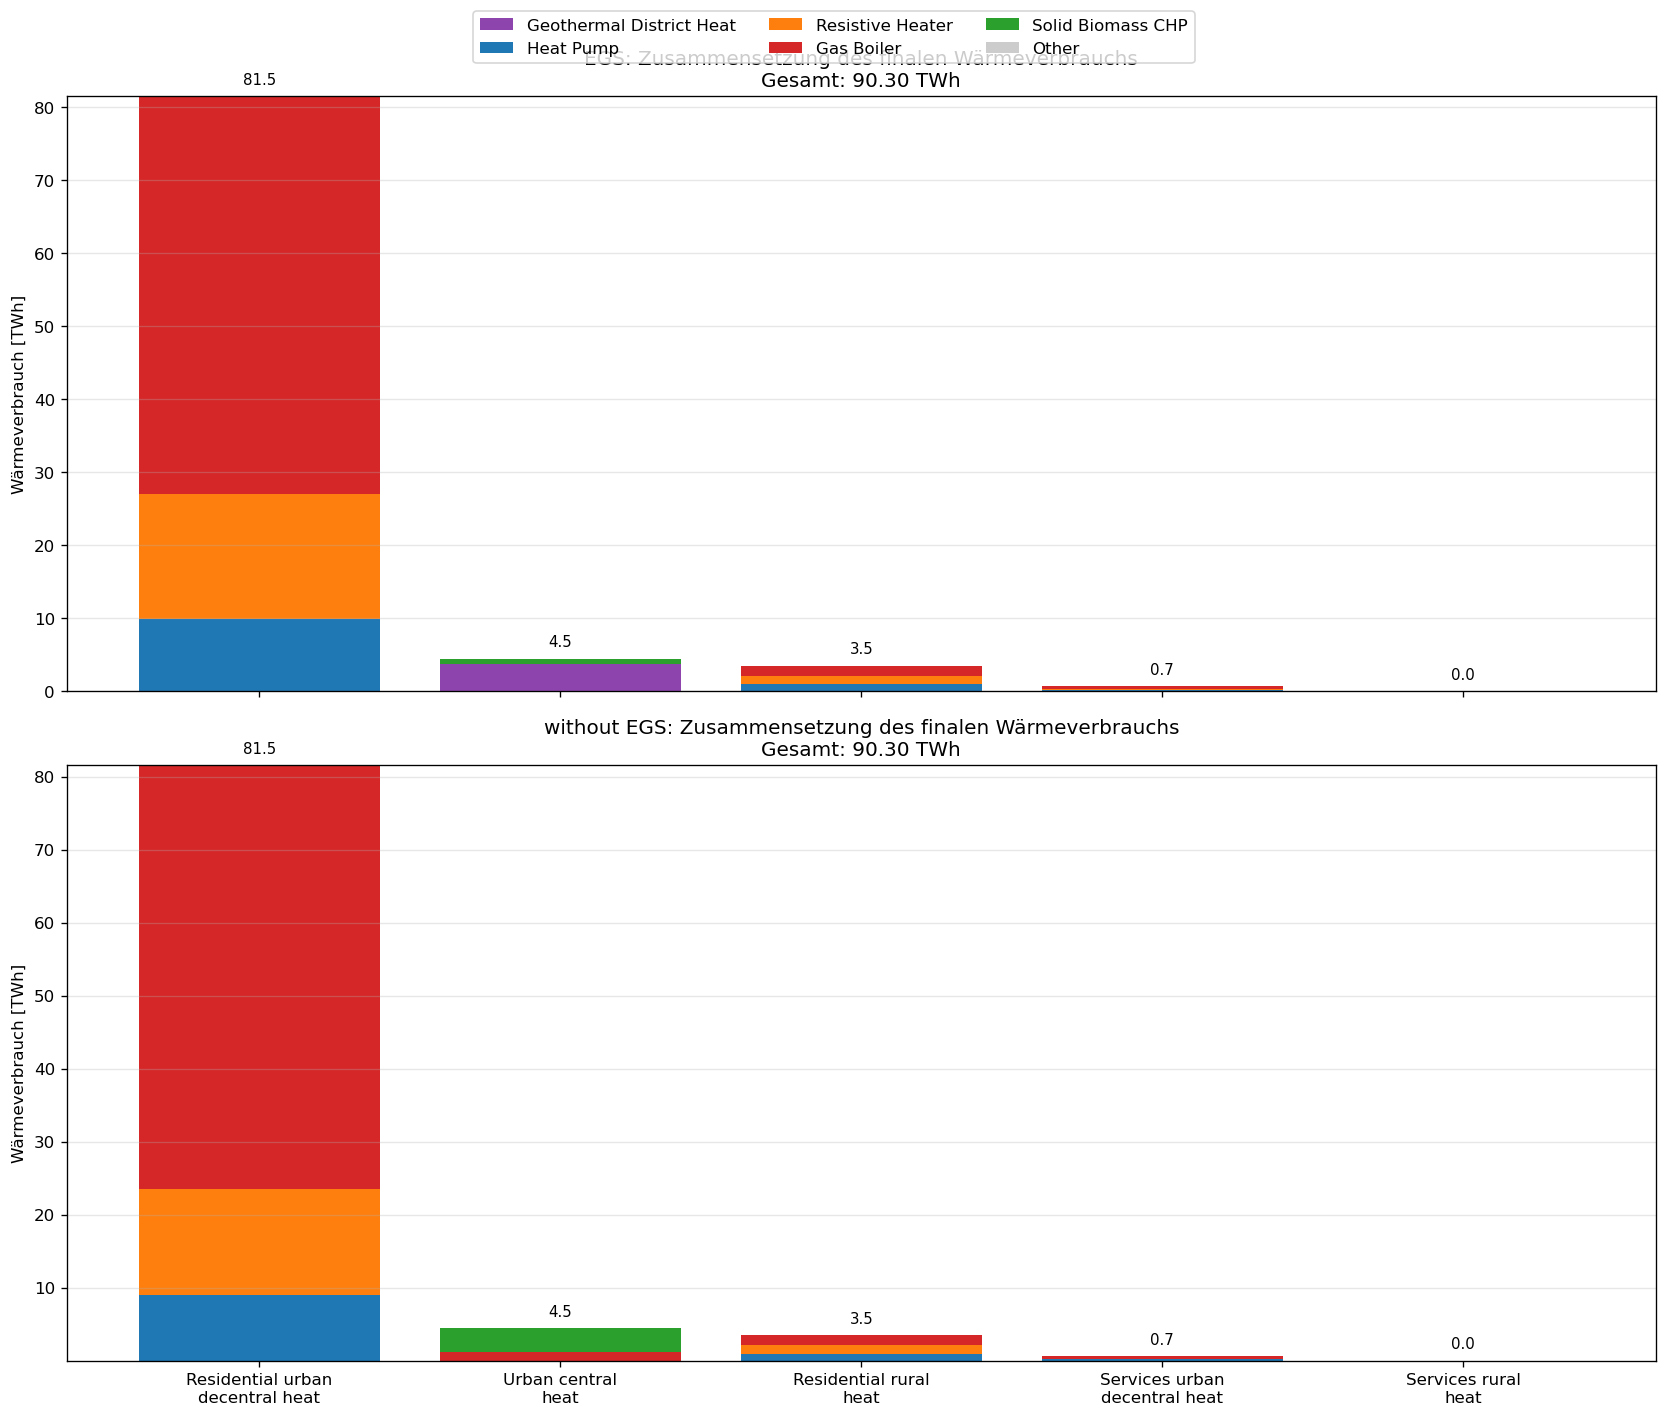

In [29]:
# ============================================================
# Zusammensetzung des finalen Wärmeverbrauchs nach Heat-Sektor
#
# Gezeigt wird:
# - residential urban decentral heat
# - urban central heat
# - residential rural heat
# - services urban decentral heat
# - services rural heat
#
# Für beide Szenarien:
# - n_a
# - n_b
#
# Logik:
# Für jeden Heat-Bus und jeden Snapshot wird die finale Heat-Load
# proportional auf die gleichzeitig einspeisenden Heat-Technologien verteilt.
#
# Ergebnis:
# Gestapelte Balkendiagramme in TWh oder GWh.
# ============================================================




# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

scenario_name_a = SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "EGS"
scenario_name_b = SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "without EGS"

networks_to_plot = {
    scenario_name_a: n_a,
    scenario_name_b: n_b,
}

heat_sectors_order = [
    "residential urban decentral heat",
    "urban central heat",
    "residential rural heat",
    "services urban decentral heat",
    "services rural heat",
]

heat_sector_labels = {
    "residential urban decentral heat": "Residential urban\ndecentral heat",
    "urban central heat": "Urban central\nheat",
    "residential rural heat": "Residential rural\nheat",
    "services urban decentral heat": "Services urban\ndecentral heat",
    "services rural heat": "Services rural\nheat",
}

# Kleine Quellen unterhalb dieser Schwelle werden zu "Other" zusammengefasst
min_source_total_TWh = 0.01

# Wenn der größte Balken kleiner als dieser Wert ist, wird GWh verwendet
gwh_threshold_TWh = 1.0

# Quellen-Reihenfolge im Stack
preferred_source_order = [
    "Geothermal District Heat",
    "Heat Pump",
    "Resistive Heater",
    "Gas Boiler",
    "Gas CHP",
    "Solid Biomass CHP",
    "Biomass Boiler",
    "Oil Boiler",
    "Coal Boiler",
    "Solar Thermal",
    "Heat Storage",
    "Other",
    "Unallocated",
]

source_colors = {
    "Geothermal District Heat": "#8e44ad",
    "Heat Pump": "#1f77b4",
    "Resistive Heater": "#ff7f0e",
    "Gas Boiler": "#d62728",
    "Gas CHP": "#b22222",
    "Solid Biomass CHP": "#2ca02c",
    "Biomass Boiler": "#66a61e",
    "Oil Boiler": "#4d4d4d",
    "Coal Boiler": "#7f7f7f",
    "Solar Thermal": "#f1c40f",
    "Heat Storage": "#17becf",
    "Other": "#cccccc",
    "Unallocated": "#000000",
}


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def get_snapshot_weights(network):
    """
    Snapshot weights für Energieaggregation.
    MW * h = MWh
    """
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)

        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    if hasattr(sw, "generators"):
        return sw.generators.reindex(network.snapshots).astype(float).fillna(1.0)

    if hasattr(sw, "objective"):
        return sw.objective.reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


def get_bus_columns(df):
    """
    Gibt alle bus-Spalten bus0, bus1, bus2, ... zurück.
    """
    bus_cols = [
        col for col in df.columns
        if col.startswith("bus") and col[3:].isdigit()
    ]

    return sorted(
        bus_cols,
        key=lambda x: int(x.replace("bus", ""))
    )


def group_heat_source(carrier):
    """
    Gruppiert detaillierte PyPSA-Earth-Link-Carrier zu übersichtlichen Wärmequellen.
    """
    carrier_str = str(carrier)
    carrier_low = carrier_str.lower()

    if "geothermal district heat" in carrier_low:
        return "Geothermal District Heat"

    if "heat pump" in carrier_low:
        return "Heat Pump"

    if "resistive heater" in carrier_low:
        return "Resistive Heater"

    if "water tanks discharger" in carrier_low:
        return "Heat Storage"

    if "solar thermal" in carrier_low:
        return "Solar Thermal"

    if "solid biomass chp" in carrier_low:
        return "Solid Biomass CHP"

    if "biomass boiler" in carrier_low or "solid biomass boiler" in carrier_low:
        return "Biomass Boiler"

    if "gas chp" in carrier_low or "urban central gas chp" in carrier_low:
        return "Gas CHP"

    if "gas boiler" in carrier_low:
        return "Gas Boiler"

    if "oil boiler" in carrier_low:
        return "Oil Boiler"

    if "coal boiler" in carrier_low:
        return "Coal Boiler"

    return carrier_str


def get_heat_load_timeseries(network):
    """
    Gibt finale Heat-Loads je Heat-Bus zurück.

    Rückgabe:
    - demand_by_bus: DataFrame [snapshots x heat_bus] in MW
    - bus_to_heat_sector: Series heat_bus -> heat_sector
    """
    loads = network.loads.copy()

    loads["bus_carrier"] = loads.bus.map(network.buses.carrier).astype(str)
    loads["load_carrier"] = loads.carrier.astype(str)

    heat_loads = loads[
        loads["bus_carrier"].isin(heat_sectors_order)
        | loads["load_carrier"].isin(heat_sectors_order)
    ].copy()

    if heat_loads.empty:
        raise ValueError("Keine finalen Heat-Loads gefunden.")

    heat_loads["heat_sector"] = np.where(
        heat_loads["bus_carrier"].isin(heat_sectors_order),
        heat_loads["bus_carrier"],
        heat_loads["load_carrier"],
    )

    if "p_set" in heat_loads.columns:
        static_p_set = heat_loads["p_set"].fillna(0)
    else:
        static_p_set = pd.Series(0.0, index=heat_loads.index)

    if hasattr(network.loads_t, "p_set") and not network.loads_t.p_set.empty:
        load_ts = network.loads_t.p_set.reindex(
            index=network.snapshots,
            columns=heat_loads.index,
        )
    else:
        load_ts = pd.DataFrame(
            np.nan,
            index=network.snapshots,
            columns=heat_loads.index,
        )

    load_ts = load_ts.T.fillna(static_p_set).T.fillna(0)
    load_ts = load_ts.clip(lower=0)

    demand_by_bus = (
        load_ts
        .T
        .groupby(heat_loads["bus"])
        .sum()
        .T
    )

    bus_to_heat_sector = (
        heat_loads
        .drop_duplicates("bus")
        .set_index("bus")["heat_sector"]
    )

    return demand_by_bus, bus_to_heat_sector


def get_heat_supply_timeseries_by_bus_and_source(network):
    """
    Ermittelt Heat-Einspeisung aus Links auf finale Heat-Busse.

    Rückgabe:
    Dictionary:
        supply_by_bus[heat_bus] = DataFrame [snapshots x source_group] in MW
    """
    links = network.links.copy()

    supply_by_bus = {}

    bus_cols = get_bus_columns(links)

    for bus_col in bus_cols:
        bus_number = int(bus_col.replace("bus", ""))

        if bus_number == 0:
            continue

        p_col = f"p{bus_number}"

        if not hasattr(network.links_t, p_col):
            continue

        output_bus_carrier = links[bus_col].map(network.buses.carrier).astype(str)

        mask = output_bus_carrier.isin(heat_sectors_order)

        if not mask.any():
            continue

        selected_links = links.loc[mask].copy()

        selected_links["source_group"] = selected_links.carrier.map(group_heat_source)

        for heat_bus, link_names in selected_links.groupby(bus_col).groups.items():

            link_names = pd.Index(link_names)

            link_output = (
                -getattr(network.links_t, p_col)
                .reindex(index=network.snapshots, columns=link_names)
                .fillna(0)
            )

            # negative p am Output-Bus = Einspeisung in den Bus
            link_output = link_output.clip(lower=0)

            if link_output.empty:
                continue

            source_groups = selected_links.loc[link_names, "source_group"]

            grouped_output = link_output.copy()
            grouped_output.columns = pd.Index(source_groups.values, name="source_group")

            grouped_output = (
                grouped_output
                .T
                .groupby(level="source_group")
                .sum()
                .T
            )

            if heat_bus in supply_by_bus:
                supply_by_bus[heat_bus] = (
                    supply_by_bus[heat_bus]
                    .add(grouped_output, fill_value=0)
                    .reindex(network.snapshots)
                    .fillna(0)
                )
            else:
                supply_by_bus[heat_bus] = grouped_output.reindex(network.snapshots).fillna(0)

    return supply_by_bus


def calculate_final_heat_mix_by_sector(network):
    """
    Ordnet den finalen Wärmeverbrauch je Heat-Sektor den Wärmequellen zu.

    Methodik:
    Für jeden Snapshot und Heat-Bus:
    source_share = source_supply / total_supply
    allocated_load = source_share * final_heat_load

    Damit wird nur die finale Nachfrage verteilt und keine überschüssige
    Erzeugung oder Speicherladung doppelt gezählt.
    """
    weights = get_snapshot_weights(network)

    demand_by_bus, bus_to_heat_sector = get_heat_load_timeseries(network)
    supply_by_bus = get_heat_supply_timeseries_by_bus_and_source(network)

    rows = []

    for heat_bus in demand_by_bus.columns:

        heat_sector = bus_to_heat_sector.get(heat_bus, None)

        if heat_sector not in heat_sectors_order:
            continue

        demand_ts = demand_by_bus[heat_bus].reindex(network.snapshots).fillna(0)

        if heat_bus not in supply_by_bus:
            unallocated_TWh = (
                demand_ts
                .mul(weights, axis=0)
                .sum()
                / 1e6
            )

            if unallocated_TWh > 0:
                rows.append({
                    "heat_sector": heat_sector,
                    "source_group": "Unallocated",
                    "heat_TWh": unallocated_TWh,
                })

            continue

        supply_ts = supply_by_bus[heat_bus].reindex(network.snapshots).fillna(0)

        total_supply_ts = supply_ts.sum(axis=1)

        shares = supply_ts.div(
            total_supply_ts.replace(0, np.nan),
            axis=0,
        ).fillna(0)

        allocated_heat_MW = shares.mul(demand_ts, axis=0)

        allocated_heat_TWh_by_source = (
            allocated_heat_MW
            .mul(weights, axis=0)
            .sum(axis=0)
            / 1e6
        )

        for source_group, value_TWh in allocated_heat_TWh_by_source.items():
            if value_TWh <= 1e-12:
                continue

            rows.append({
                "heat_sector": heat_sector,
                "source_group": source_group,
                "heat_TWh": value_TWh,
            })

        # Demand ohne simultane Supply erfassen
        unallocated_mask = (
            (demand_ts > 0)
            & (total_supply_ts <= 0)
        )

        if unallocated_mask.any():
            unallocated_TWh = (
                demand_ts.where(unallocated_mask, 0)
                .mul(weights, axis=0)
                .sum()
                / 1e6
            )

            if unallocated_TWh > 1e-12:
                rows.append({
                    "heat_sector": heat_sector,
                    "source_group": "Unallocated",
                    "heat_TWh": unallocated_TWh,
                })

    if not rows:
        return pd.DataFrame(
            0.0,
            index=heat_sectors_order,
            columns=["Unallocated"],
        )

    result_long = pd.DataFrame(rows)

    result = (
        result_long
        .groupby(["heat_sector", "source_group"])["heat_TWh"]
        .sum()
        .unstack("source_group")
        .fillna(0)
        .reindex(index=heat_sectors_order)
        .fillna(0)
    )

    return result


def combine_small_sources(df, min_total_TWh=0.01):
    """
    Fasst kleine Quellen zu 'Other' zusammen.
    """
    df = df.copy()

    source_totals = df.sum(axis=0)

    small_sources = source_totals[
        source_totals < min_total_TWh
    ].index.tolist()

    small_sources = [
        s for s in small_sources
        if s not in ["Other", "Unallocated"]
    ]

    if small_sources:
        df["Other"] = df.get("Other", 0) + df[small_sources].sum(axis=1)
        df = df.drop(columns=small_sources)

    return df


# ------------------------------------------------------------
# Calculate data
# ------------------------------------------------------------

heat_mix_by_scenario = {}

for scenario_name, network in networks_to_plot.items():
    mix = calculate_final_heat_mix_by_sector(network)
    mix = combine_small_sources(
        mix,
        min_total_TWh=min_source_total_TWh,
    )

    heat_mix_by_scenario[scenario_name] = mix


# ------------------------------------------------------------
# Einheit bestimmen
# ------------------------------------------------------------

max_value_TWh = max(
    df.sum(axis=1).max()
    for df in heat_mix_by_scenario.values()
)

if max_value_TWh < gwh_threshold_TWh:
    unit = "GWh"
    unit_factor = 1000.0
else:
    unit = "TWh"
    unit_factor = 1.0


# ------------------------------------------------------------
# Gemeinsame Source-Reihenfolge bestimmen
# ------------------------------------------------------------

all_sources = sorted(
    set().union(*[
        set(df.columns)
        for df in heat_mix_by_scenario.values()
    ])
)

source_order = [
    s for s in preferred_source_order
    if s in all_sources
] + [
    s for s in all_sources
    if s not in preferred_source_order
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

n_scenarios = len(heat_mix_by_scenario)

fig, axes = plt.subplots(
    n_scenarios,
    1,
    figsize=(14, 5.8 * n_scenarios),
    sharex=True,
)

if n_scenarios == 1:
    axes = [axes]

x = np.arange(len(heat_sectors_order))

for ax, (scenario_name, mix_df) in zip(axes, heat_mix_by_scenario.items()):

    plot_data = (
        mix_df
        .reindex(index=heat_sectors_order, columns=source_order)
        .fillna(0)
        * unit_factor
    )

    bottom = np.zeros(len(plot_data))

    for source in source_order:
        values = plot_data[source].values

        if np.allclose(values, 0):
            continue

        ax.bar(
            x,
            values,
            bottom=bottom,
            label=source,
            color=source_colors.get(source, None),
        )

        bottom += values

    total_TWh = mix_df.sum().sum()

    ax.set_title(
        f"{scenario_name}: Zusammensetzung des finalen Wärmeverbrauchs\n"
        f"Gesamt: {total_TWh:.2f} TWh"
    )

    ax.set_ylabel(f"Wärmeverbrauch [{unit}]")
    ax.grid(axis="y", alpha=0.3)

    ymax = bottom.max()

    for i, value in enumerate(bottom):
        if value > 0:
            ax.text(
                i,
                value + 0.015 * ymax,
                f"{value:.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(
    [heat_sector_labels.get(s, s) for s in heat_sectors_order],
    rotation=0,
    ha="center",
)

# Gemeinsame Legende
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True,
)

plt.tight_layout()
plt.show()

EGS: Direkter Energieverbrauch = 3041.25 TWh
without EGS: Direkter Energieverbrauch = 3041.25 TWh

Detailtabelle direkter Energieverbrauch: EGS


,bus,bus_carrier,load_carrier,energy_TWh
Load,,,,
JP.41_1_AC services gas,JP.41_1_AC gas,gas,services gas,74.670135
JP.41_1_AC services electricity,JP.41_1_AC low voltage,low voltage,services electricity,61.435906
JP.19_1_AC naphtha for industry,JP.19_1_AC oil,oil,naphtha for industry,57.618452
JP.19_1_AC industry electricity,JP.19_1_AC low voltage,low voltage,industry electricity,55.333762
JP.19_1_AC services gas,JP.19_1_AC gas,gas,services gas,47.909276
...,...,...,...,...
JP.14_1_AC services rural heat,JP.14_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.33_1_AC services rural heat,JP.33_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.19_1_AC services rural heat,JP.19_1_AC services rural heat,services rural heat,services rural heat,0.000004



Detailtabelle direkter Energieverbrauch: without EGS


,bus,bus_carrier,load_carrier,energy_TWh
Load,,,,
JP.41_1_AC services gas,JP.41_1_AC gas,gas,services gas,74.670135
JP.41_1_AC services electricity,JP.41_1_AC low voltage,low voltage,services electricity,61.435906
JP.19_1_AC naphtha for industry,JP.19_1_AC oil,oil,naphtha for industry,57.618452
JP.19_1_AC industry electricity,JP.19_1_AC low voltage,low voltage,industry electricity,55.333762
JP.19_1_AC services gas,JP.19_1_AC gas,gas,services gas,47.909276
...,...,...,...,...
JP.14_1_AC services rural heat,JP.14_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.33_1_AC services rural heat,JP.33_1_AC services rural heat,services rural heat,services rural heat,0.000006
JP.19_1_AC services rural heat,JP.19_1_AC services rural heat,services rural heat,services rural heat,0.000004


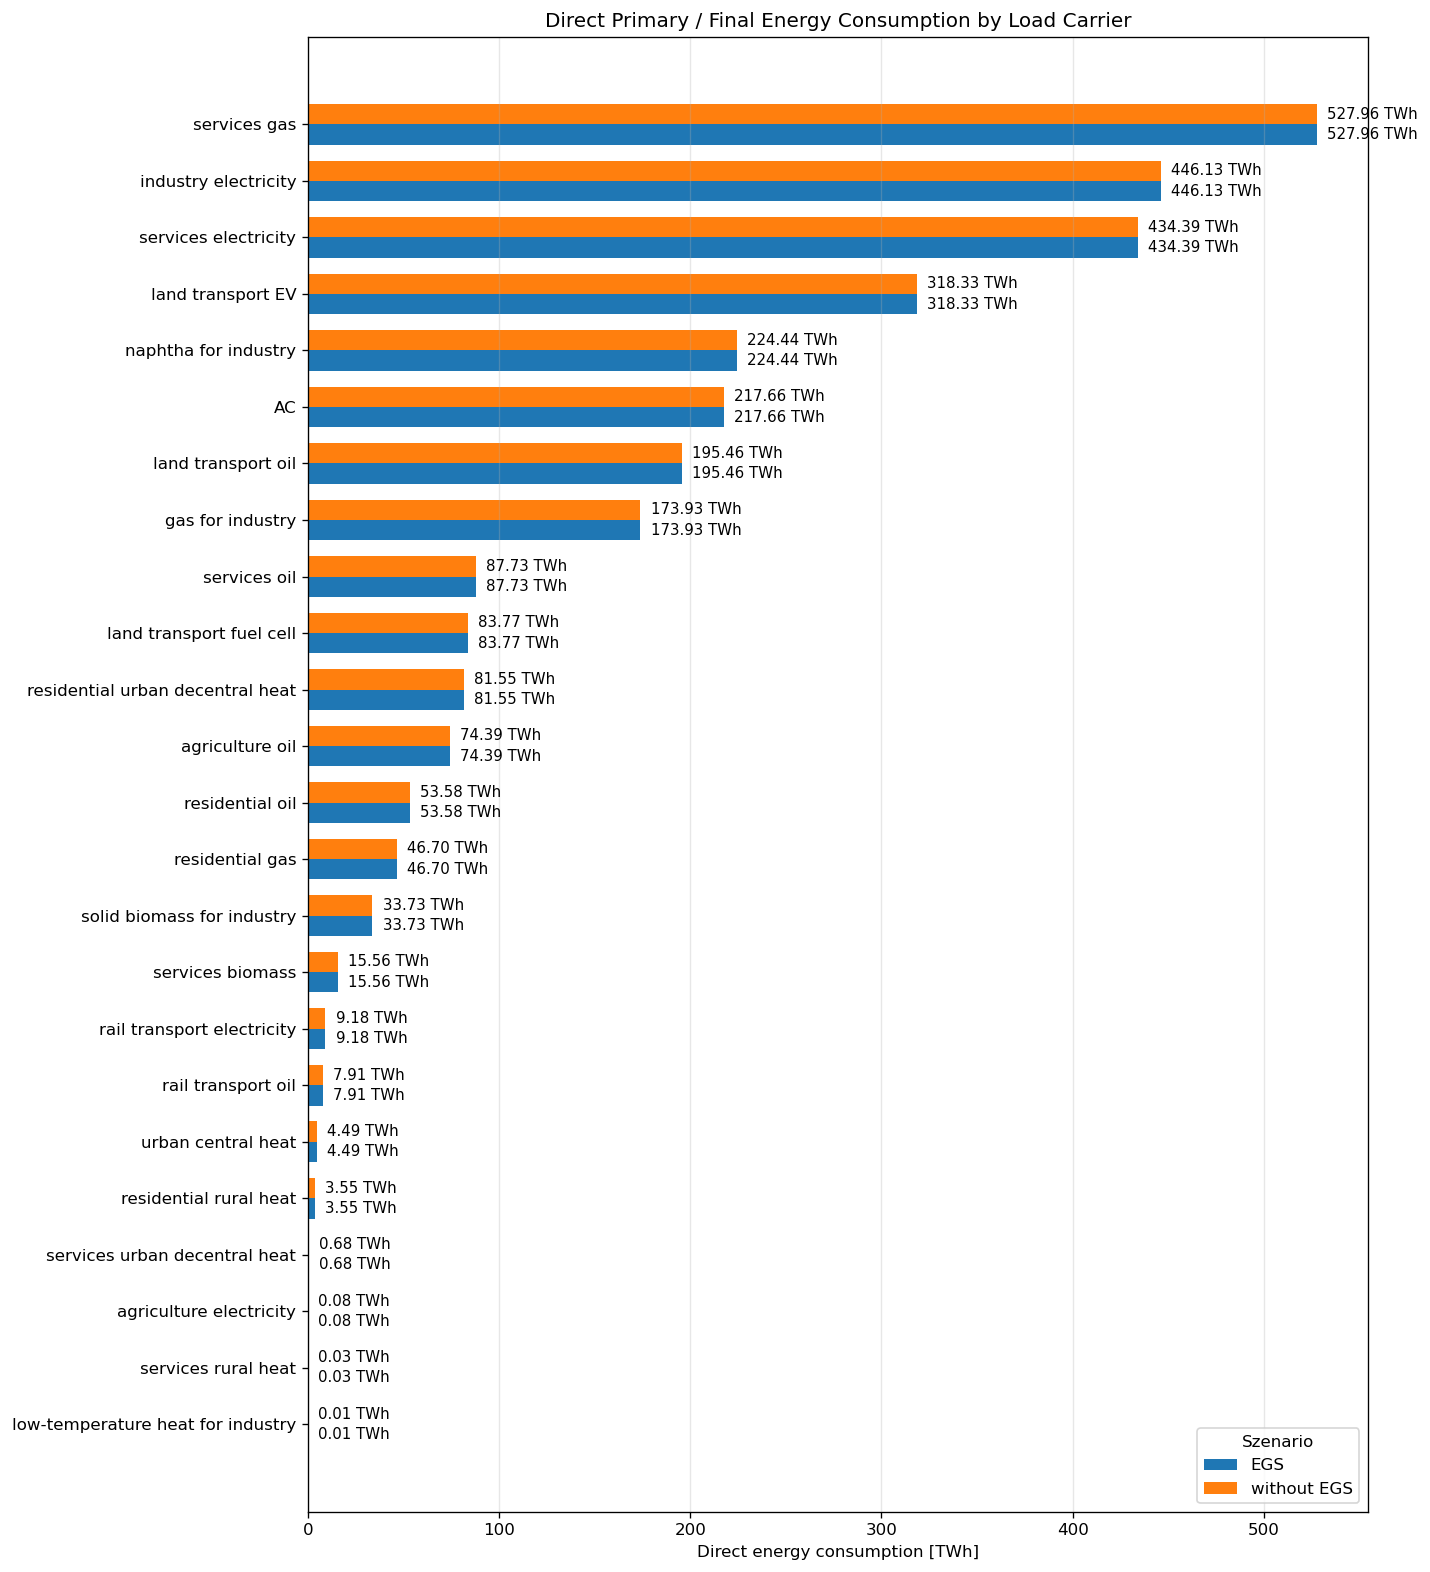

In [21]:
# ============================================================
# Direkte Primär-/Endenergieverbräuche nach Load-Carrier
# Vergleich: n_a vs. n_b
# Beispiel: naphtha for industry, gas for industry, oil, biomass, H2 etc.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Heat wird standardmäßig ausgeschlossen, weil es in separaten Heat-Analysen betrachtet wird
exclude_heat_loads = False

# Strom wird standardmäßig ausgeschlossen, damit nur direkte Brennstoff-/Primärenergieträger sichtbar sind
exclude_electricity_loads = False

# Nicht-energetische oder interne Carrier ausschließen
non_energy_bus_pattern = "co2|atmosphere|stored"

# Sehr kleine Werte ausblenden
min_energy_TWh = 1e-6

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}

scenario_colors = ["#1f77b4", "#ff7f0e"]


# ------------------------------------------------------------
# Helper: Snapshot weights
# ------------------------------------------------------------

def get_snapshot_weights(network):
    """
    Returns snapshot weights for energy calculation.
    MW * hours = MWh
    """
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)

        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


# ------------------------------------------------------------
# Helper: Load time series
# ------------------------------------------------------------

def get_load_timeseries(network, selected_loads):
    """
    Returns load time series in MW.

    Priority:
    1. loads_t.p_set
    2. loads_t.p
    3. static loads.p_set

    Missing time series values are filled with static p_set.
    """
    if selected_loads.empty:
        return pd.DataFrame(index=network.snapshots)

    static_p_set = (
        selected_loads["p_set"].fillna(0)
        if "p_set" in selected_loads.columns
        else pd.Series(0.0, index=selected_loads.index)
    )

    if (
        hasattr(network, "loads_t")
        and hasattr(network.loads_t, "p_set")
        and not network.loads_t.p_set.empty
    ):
        load_ts = network.loads_t.p_set.reindex(
            index=network.snapshots,
            columns=selected_loads.index,
        )

    elif (
        hasattr(network, "loads_t")
        and hasattr(network.loads_t, "p")
        and not network.loads_t.p.empty
    ):
        load_ts = network.loads_t.p.reindex(
            index=network.snapshots,
            columns=selected_loads.index,
        )

    else:
        load_ts = pd.DataFrame(
            np.nan,
            index=network.snapshots,
            columns=selected_loads.index,
        )

    # Wichtig: spaltenweise mit statischem p_set auffüllen
    load_ts = load_ts.fillna(static_p_set).fillna(0)

    # Positive Werte = Verbrauch
    load_ts = load_ts.clip(lower=0)

    return load_ts


# ------------------------------------------------------------
# Main function: direct primary/final energy loads by carrier
# ------------------------------------------------------------

def calculate_direct_energy_consumption_by_load_carrier(network, scenario_name):
    """
    Aggregiert direkte Energieverbräuche aus n.loads nach load.carrier.

    Gezählt werden Loads auf nicht-elektrischen und optional nicht-heat Bussen.
    Dadurch erscheinen z.B.:
    - gas for industry
    - naphtha for industry
    - solid biomass for industry
    - oil loads
    - H2 loads
    """

    weights = get_snapshot_weights(network)

    loads = network.loads.copy()

    if loads.empty:
        print(f"{scenario_name}: Keine Loads im Netzwerk gefunden.")
        return pd.Series(dtype=float), pd.DataFrame()

    loads["bus_carrier"] = loads.bus.map(network.buses.carrier).astype(str)
    loads["load_carrier"] = loads.carrier.astype(str)

    mask = pd.Series(True, index=loads.index)

    # Strom-Loads ausschließen
    if exclude_electricity_loads:
        mask = mask & ~loads["bus_carrier"].isin(electric_bus_carriers)

    # Heat-Loads ausschließen
    if exclude_heat_loads:
        mask = mask & ~loads["bus_carrier"].str.contains(
            "heat",
            case=False,
            regex=True,
            na=False,
        )

    # Nicht-energetische / interne Busse ausschließen
    mask = mask & ~loads["bus_carrier"].str.contains(
        non_energy_bus_pattern,
        case=False,
        regex=True,
        na=False,
    )

    selected_loads = loads[mask].copy()

    if selected_loads.empty:
        print(f"{scenario_name}: Keine direkten Primär-/Endenergie-Loads gefunden.")
        return pd.Series(dtype=float), pd.DataFrame()

    load_ts = get_load_timeseries(network, selected_loads)

    energy_by_load_TWh = (
        load_ts
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)  # MWh to TWh
    )

    selected_loads["energy_TWh"] = energy_by_load_TWh

    selected_loads = selected_loads[
        selected_loads["energy_TWh"] > min_energy_TWh
    ].copy()

    energy_by_carrier = (
        selected_loads
        .groupby("load_carrier")["energy_TWh"]
        .sum()
        .sort_values(ascending=False)
    )

    detail_table = (
        selected_loads[
            [
                "bus",
                "bus_carrier",
                "load_carrier",
                "energy_TWh",
            ]
        ]
        .sort_values("energy_TWh", ascending=False)
    )

    print(
        f"{scenario_name}: Direkter Energieverbrauch = "
        f"{energy_by_carrier.sum():.2f} TWh"
    )

    return energy_by_carrier, detail_table


# ------------------------------------------------------------
# Calculate both scenarios
# ------------------------------------------------------------

direct_energy_results = {}
direct_energy_detail_results = {}

for scenario_name, network in networks_to_compare.items():
    energy_by_carrier, detail_table = calculate_direct_energy_consumption_by_load_carrier(
        network,
        scenario_name,
    )

    direct_energy_results[scenario_name] = energy_by_carrier
    direct_energy_detail_results[scenario_name] = detail_table


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

direct_energy_comparison = pd.DataFrame(direct_energy_results).fillna(0)

# Nur Carrier behalten, die in mindestens einem Szenario relevant sind
direct_energy_comparison = direct_energy_comparison[
    direct_energy_comparison.sum(axis=1) > min_energy_TWh
]

# Nach Gesamtsumme über beide Szenarien sortieren
direct_energy_comparison = direct_energy_comparison.loc[
    direct_energy_comparison.sum(axis=1).sort_values(ascending=False).index
]

direct_energy_comparison_with_total = direct_energy_comparison.copy()
direct_energy_comparison_with_total.loc["Total"] = (
    direct_energy_comparison_with_total.sum(axis=0)
)

#display(
#    direct_energy_comparison_with_total
#    .rename_axis("load_carrier")
#)


# ------------------------------------------------------------
# Optional: detailed tables
# ------------------------------------------------------------

for scenario_name, detail_table in direct_energy_detail_results.items():
    print(f"\nDetailtabelle direkter Energieverbrauch: {scenario_name}")
    display(detail_table)


# ------------------------------------------------------------
# Plot: two bars per carrier
# ------------------------------------------------------------

plot_df = direct_energy_comparison.loc[
    direct_energy_comparison.sum(axis=1).sort_values(ascending=True).index
]

fig, ax = plt.subplots(
    figsize=(12, max(6, 0.55 * len(plot_df)))
)

y = np.arange(len(plot_df.index))
bar_height = 0.36

scenario_list = list(plot_df.columns)

xmax = plot_df.max().max() if not plot_df.empty else 0

for scenario_idx, scenario_name in enumerate(scenario_list):
    offset = (scenario_idx - (len(scenario_list) - 1) / 2) * bar_height

    bars = ax.barh(
        y + offset,
        plot_df[scenario_name].values,
        height=bar_height,
        label=scenario_name,
        color=scenario_colors[scenario_idx % len(scenario_colors)],
    )

    for bar, value in zip(bars, plot_df[scenario_name].values):
        if value > min_energy_TWh:
            ax.text(
                value + (0.01 * xmax if xmax > 0 else 0.1),
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f} TWh",
                va="center",
                fontsize=9,
            )


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("Direct energy consumption [TWh]")
ax.set_ylabel("")
ax.set_title(
    "Direct Primary / Final Energy Consumption by Load Carrier"
)

ax.grid(axis="x", alpha=0.3)
ax.legend(title="Szenario")

plt.tight_layout()
plt.show()


EGS


,fixed_load_demand_TWh,optimized_supply_to_load_bus_TWh,difference_supply_minus_demand_TWh
services gas,527.961207,7.809078e+02,2.529466e+02
land transport EV,318.326514,3.183269e+02,3.748241e-04
naphtha for industry,224.436335,3.442637e-06,-2.244363e+02
land transport oil,195.463649,4.878130e-06,-1.954636e+02
gas for industry,173.932032,1.739320e+02,2.842171e-14
services oil,87.733700,2.027189e-06,-8.773370e+01
land transport fuel cell,83.770135,1.168454e+02,3.307530e+01
agriculture oil,74.393730,1.856354e-06,-7.439373e+01
residential oil,53.576500,1.237947e-06,-5.357650e+01
residential gas,46.700269,6.907441e+01,2.237414e+01



without EGS


,fixed_load_demand_TWh,optimized_supply_to_load_bus_TWh,difference_supply_minus_demand_TWh
services gas,527.961207,8.386258e+02,3.106646e+02
land transport EV,318.326514,3.183272e+02,6.982011e-04
naphtha for industry,224.436335,4.936064e-06,-2.244363e+02
land transport oil,195.463649,6.877870e-06,-1.954636e+02
gas for industry,173.932032,1.739320e+02,2.842171e-14
services oil,87.733700,2.842340e-06,-8.773370e+01
land transport fuel cell,83.770135,1.319250e+02,4.815487e+01
agriculture oil,74.393730,2.617229e-06,-7.439373e+01
residential oil,53.576500,1.735737e-06,-5.357650e+01
residential gas,46.700269,7.417979e+01,2.747952e+01


fixed_load_demand_TWh  \
scenario    load_carrier                                        
EGS         services gas                           527.961207   
            land transport EV                      318.326514   
            naphtha for industry                   224.436335   
            land transport oil                     195.463649   
            gas for industry                       173.932032   
            services oil                            87.733700   
            land transport fuel cell                83.770135   
            agriculture oil                         74.393730   
            residential oil                         53.576500   
            residential gas                         46.700269   
            solid biomass for industry              33.732187   
            services biomass                        15.562500   
            rail transport oil                       7.906213   
without EGS services gas                           527.961207   
            land transport EV                      318.326514   
            naphtha for industry                   224.436335   
            land transport oil                     195.463649   
            gas for industry                       173.932032   
            services oil                            87.733700   
            land transport fuel cell                83.770135   
            agriculture oil                         74.393730   
            residential oil                         53.576500   
            residential gas                         46.700269   
            solid biomass for industry              33.732187   
            services biomass                        15.562500   
            rail transport oil                       7.906213   

                                        optimized_supply_to_load_bus_TWh  \
scenario    load_carrier                                                   
EGS         services gas                                    7.809078e+02   
            land transport EV                               3.183269e+02   
            naphtha for industry                            3.442637e-06   
            land transport oil                              4.878130e-06   
            gas for industry                                1.739320e+02   
            services oil                                    2.027189e-06   
            land transport fuel cell                        1.168454e+02   
            agriculture oil                                 1.856354e-06   
            residential oil                                 1.237947e-06   
            residential gas                                 6.907441e+01   
            solid biomass for industry                      3.373218e+01   
            services biomass                                4.549253e+02   
            rail transport oil                              1.972845e-07   
without EGS services gas                                    8.386258e+02   
            land transport EV                               3.183272e+02   
            naphtha for industry                            4.936064e-06   
            land transport oil                              6.877870e-06   
            gas for industry                                1.739320e+02   
            services oil                                    2.842340e-06   
            land transport fuel cell                        1.319250e+02   
            agriculture oil                                 2.617229e-06   
            residential oil                                 1.735737e-06   
            residential gas                                 7.417979e+01   
            solid biomass for industry                      3.373217e+01   
            services biomass                                5.104331e+02   
            rail transport oil                              2.781467e-07   

                                        difference_supply_minus_demand_TWh  
scenario    l

EGS  \
                           fixed_load_demand_TWh   
rail transport oil                      7.906213   
services biomass                       15.562500   
solid biomass for industry             33.732187   
residential gas                        46.700269   
residential oil                        53.576500   
agriculture oil                        74.393730   
land transport fuel cell               83.770135   
services oil                           87.733700   
gas for industry                      173.932032   
land transport oil                    195.463649   
naphtha for industry                  224.436335   
land transport EV                     318.326514   
services gas                          527.961207   

                                                             \
                           optimized_supply_to_load_bus_TWh   
rail transport oil                             1.972845e-07   
services biomass                               4.549253e+02   
solid biomass for industry                     3.373218e+01   
residential gas                                6.907441e+01   
residential oil                                1.237947e-06   
agriculture oil                                1.856354e-06   
land transport fuel cell                       1.168454e+02   
services oil                                   2.027189e-06   
gas for industry                               1.739320e+02   
land transport oil                             4.878130e-06   
naphtha for industry                           3.442637e-06   
land transport EV                              3.183269e+02   
services gas                                   7.809078e+02   

                                     without EGS  \
                           fixed_load_demand_TWh   
rail transport oil                      7.906213   
services biomass                       15.562500   
solid biomass for industry             33.732187   
residential gas                        46.700269   
residential oil                        53.576500   
agriculture oil                        74.393730   
land transport fuel cell               83.770135   
services oil                           87.733700   
gas for industry                      173.932032   
land transport oil                    195.463649   
naphtha for industry                  224.436335   
land transport EV                     318.326514   
services gas                          527.961207   

                                                             
                           optimized_supply_to_load_bus_TWh  
rail transport oil                             2.781467e-07  
services biomass                               5.104331e+02  
solid biomass for industry                     3.373217e+01  
residential gas                                7.417979e+01  
residential oil                                1.735737e-06  
agriculture oil                                2.617229e-06  
land transport fuel cell                       1.319250e+02  
services oil                                   2.842340e-06  
gas for industry                               1.739320e+02  
land transport oil                             6.877870e-06  
naphtha for industry                           4.936064e-06  
land transport EV                              3.183272e+02  
services gas                                   8.386258e+02

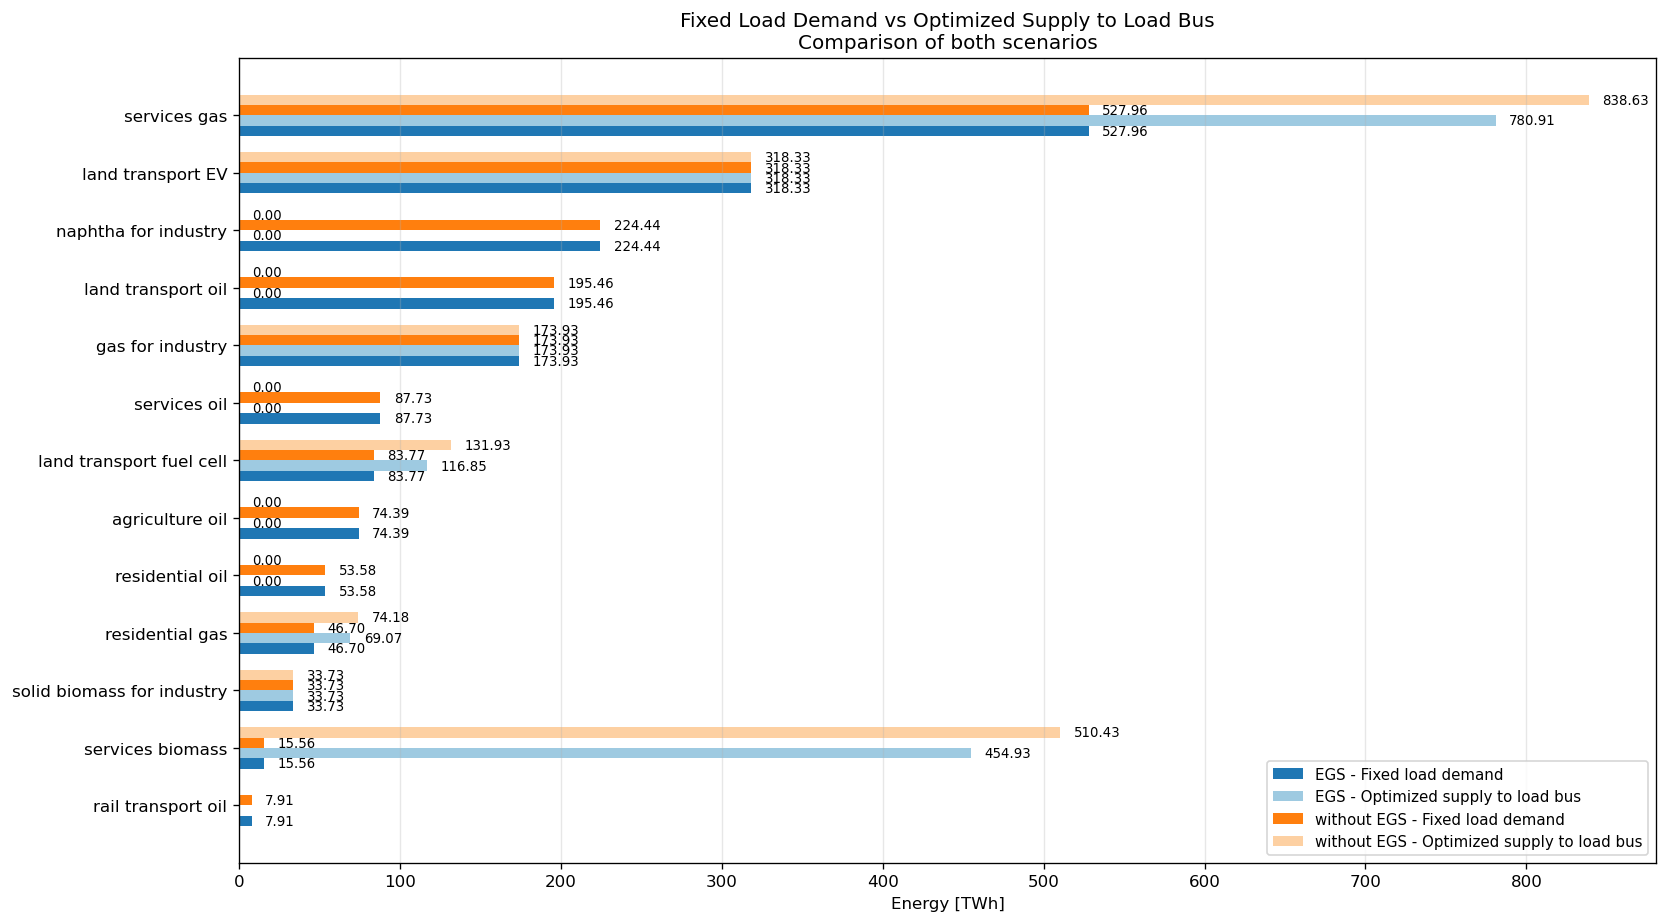

In [22]:
# ============================================================
# Vorgegebener Verbrauch vs. optimierte Bereitstellung
# nach Load-Carrier
# Vergleich: n_a vs. n_b
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

exclude_heat_loads = True
exclude_electricity_loads = True

non_energy_bus_pattern = "co2|atmosphere|stored"

min_energy_TWh = 1e-6

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def get_snapshot_weights(network):
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)

        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


def get_load_timeseries(network, selected_loads):
    static_p_set = (
        selected_loads["p_set"].fillna(0)
        if "p_set" in selected_loads.columns
        else pd.Series(0.0, index=selected_loads.index)
    )

    if (
        hasattr(network.loads_t, "p_set")
        and not network.loads_t.p_set.empty
    ):
        load_ts = network.loads_t.p_set.reindex(
            index=network.snapshots,
            columns=selected_loads.index,
        )

    elif (
        hasattr(network.loads_t, "p")
        and not network.loads_t.p.empty
    ):
        load_ts = network.loads_t.p.reindex(
            index=network.snapshots,
            columns=selected_loads.index,
        )

    else:
        load_ts = pd.DataFrame(
            np.nan,
            index=network.snapshots,
            columns=selected_loads.index,
        )

    load_ts = load_ts.fillna(static_p_set).fillna(0)

    return load_ts.clip(lower=0)


def select_direct_energy_loads(network):
    loads = network.loads.copy()

    loads["bus_carrier"] = loads.bus.map(network.buses.carrier).astype(str)
    loads["load_carrier"] = loads.carrier.astype(str)

    mask = pd.Series(True, index=loads.index)

    if exclude_electricity_loads:
        mask = mask & ~loads["bus_carrier"].isin(electric_bus_carriers)

    if exclude_heat_loads:
        mask = mask & ~loads["bus_carrier"].str.contains(
            "heat",
            case=False,
            regex=True,
            na=False,
        )

    mask = mask & ~loads["bus_carrier"].str.contains(
        non_energy_bus_pattern,
        case=False,
        regex=True,
        na=False,
    )

    return loads[mask].copy()


def calculate_load_demand_by_carrier(network, selected_loads, weights):
    load_ts = get_load_timeseries(network, selected_loads)

    energy_by_load_TWh = (
        load_ts
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)
    )

    selected_loads = selected_loads.copy()
    selected_loads["demand_TWh"] = energy_by_load_TWh

    demand_by_carrier = (
        selected_loads
        .groupby("load_carrier")["demand_TWh"]
        .sum()
    )

    return demand_by_carrier, selected_loads


def calculate_optimized_supply_to_load_buses(network, selected_loads, weights):
    """
    Berechnet die optimierte Versorgung der Busse, auf denen die ausgewählten Loads liegen.

    Enthalten:
    - Generatoren auf diesen Bussen
    - Link-Ausgänge auf diese Busse

    Achtung:
    Wenn mehrere Load-Carrier auf demselben Bus liegen, wird die Versorgung
    proportional zur Nachfrage aufgeteilt.
    """

    if selected_loads.empty:
        return pd.Series(dtype=float)

    load_buses = selected_loads["bus"].unique()

    # Nachfrage je Load und je Bus für spätere proportionale Zuordnung
    load_ts = get_load_timeseries(network, selected_loads)

    demand_by_load_TWh = (
        load_ts
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)
    )

    selected_loads = selected_loads.copy()
    selected_loads["demand_TWh"] = demand_by_load_TWh

    demand_by_bus_carrier = (
        selected_loads
        .groupby(["bus", "load_carrier"])["demand_TWh"]
        .sum()
    )

    demand_by_bus = (
        selected_loads
        .groupby("bus")["demand_TWh"]
        .sum()
    )

    # --------------------------------------------------------
    # 1) Generator supply to load buses
    # --------------------------------------------------------

    supply_by_bus_TWh = pd.Series(0.0, index=pd.Index(load_buses, name="bus"))

    generators = network.generators.copy()

    selected_generators = generators[
        generators.bus.isin(load_buses)
    ].copy()

    if not selected_generators.empty:
        gen_dispatch = (
            network.generators_t.p
            .reindex(index=network.snapshots, columns=selected_generators.index)
            .fillna(0)
            .clip(lower=0)
        )

        gen_energy_TWh = (
            gen_dispatch
            .mul(weights, axis=0)
            .sum(axis=0)
            .div(1e6)
        )

        gen_bus_energy = (
            gen_energy_TWh
            .groupby(selected_generators.bus)
            .sum()
        )

        supply_by_bus_TWh = supply_by_bus_TWh.add(gen_bus_energy, fill_value=0)

    # --------------------------------------------------------
    # 2) Link outputs to load buses
    # --------------------------------------------------------

    links = network.links.copy()

    for bus_number in range(1, 6):
        bus_col = f"bus{bus_number}"
        p_col = f"p{bus_number}"

        if bus_col not in links.columns:
            continue

        if not hasattr(network.links_t, p_col):
            continue

        selected_links = links[
            links[bus_col].isin(load_buses)
        ].copy()

        if selected_links.empty:
            continue

        link_output = (
            -getattr(network.links_t, p_col)
            .reindex(index=network.snapshots, columns=selected_links.index)
            .fillna(0)
        ).clip(lower=0)

        link_energy_TWh = (
            link_output
            .mul(weights, axis=0)
            .sum(axis=0)
            .div(1e6)
        )

        link_bus_energy = (
            link_energy_TWh
            .groupby(selected_links[bus_col])
            .sum()
        )

        supply_by_bus_TWh = supply_by_bus_TWh.add(link_bus_energy, fill_value=0)

    # --------------------------------------------------------
    # 3) Versorgung proportional auf Load-Carrier am selben Bus verteilen
    # --------------------------------------------------------

    supply_by_load_carrier = {}

    for (bus, load_carrier), demand_TWh in demand_by_bus_carrier.items():
        total_bus_demand = demand_by_bus.loc[bus]

        if total_bus_demand <= 0:
            allocated_supply = 0.0
        else:
            allocated_supply = supply_by_bus_TWh.get(bus, 0.0) * demand_TWh / total_bus_demand

        supply_by_load_carrier[load_carrier] = (
            supply_by_load_carrier.get(load_carrier, 0.0)
            + allocated_supply
        )

    return pd.Series(supply_by_load_carrier)


# ------------------------------------------------------------
# Calculate both scenarios
# ------------------------------------------------------------

comparison_tables = {}

for scenario_name, network in networks_to_compare.items():
    weights = get_snapshot_weights(network)

    selected_loads = select_direct_energy_loads(network)

    demand_by_carrier, selected_loads_with_demand = calculate_load_demand_by_carrier(
        network,
        selected_loads,
        weights,
    )

    optimized_supply_by_carrier = calculate_optimized_supply_to_load_buses(
        network,
        selected_loads_with_demand,
        weights,
    )

    result = pd.DataFrame({
        "fixed_load_demand_TWh": demand_by_carrier,
        "optimized_supply_to_load_bus_TWh": optimized_supply_by_carrier,
    }).fillna(0)

    result["difference_supply_minus_demand_TWh"] = (
        result["optimized_supply_to_load_bus_TWh"]
        - result["fixed_load_demand_TWh"]
    )

    result = result[
        result[["fixed_load_demand_TWh", "optimized_supply_to_load_bus_TWh"]]
        .sum(axis=1) > min_energy_TWh
    ]

    result = result.loc[
        result["fixed_load_demand_TWh"].sort_values(ascending=False).index
    ]

    comparison_tables[scenario_name] = result

    print(f"\n{scenario_name}")
    display(result)


# ------------------------------------------------------------
# Combined table
# ------------------------------------------------------------

combined_result = pd.concat(
    comparison_tables,
    names=["scenario", "load_carrier"]
)

display(combined_result)

# ============================================================
# Plot: Fixed load demand vs optimized supply to load bus
# Vergleich: n_a vs. n_b
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# Check input
# ------------------------------------------------------------

if "comparison_tables" not in globals():
    raise ValueError(
        "comparison_tables wurde nicht gefunden. "
        "Bitte zuerst den vorherigen Codeblock zur Berechnung "
        "von fixed_load_demand_TWh und optimized_supply_to_load_bus_TWh ausführen."
    )


# ------------------------------------------------------------
# Combine both scenarios into one comparison table
# ------------------------------------------------------------

combined_plot_df = pd.concat(comparison_tables, axis=1)

# Schöner MultiIndex-Spaltenname
combined_plot_df.columns = pd.MultiIndex.from_tuples(combined_plot_df.columns)

# Nur die beiden Spalten behalten, die wir plotten wollen
metrics_to_plot = [
    "fixed_load_demand_TWh",
    "optimized_supply_to_load_bus_TWh",
]

combined_plot_df = combined_plot_df.loc[
    :,
    combined_plot_df.columns.get_level_values(1).isin(metrics_to_plot)
]

# Nur Carrier behalten, die überhaupt relevant sind
combined_plot_df = combined_plot_df[
    combined_plot_df.sum(axis=1) > 1e-6
]

# Sortierung nach gesamter fixed demand über beide Szenarien
fixed_cols = [
    col for col in combined_plot_df.columns
    if col[1] == "fixed_load_demand_TWh"
]

combined_plot_df = combined_plot_df.loc[
    combined_plot_df[fixed_cols].sum(axis=1).sort_values(ascending=True).index
]

display(combined_plot_df)


# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------

scenario_list = list(comparison_tables.keys())

if len(scenario_list) != 2:
    print(
        "Hinweis: Der Plot ist auf zwei Szenarien ausgelegt. "
        f"Aktuell gefunden: {len(scenario_list)}"
    )

metric_labels = {
    "fixed_load_demand_TWh": "Fixed load demand",
    "optimized_supply_to_load_bus_TWh": "Optimized supply to load bus",
}

metric_colors = {
    "fixed_load_demand_TWh": ["#1f77b4", "#ff7f0e"],      # blau, orange
    "optimized_supply_to_load_bus_TWh": ["#9ecae1", "#fdd0a2"],  # hellblau, hellorange
}


# ------------------------------------------------------------
# Prepare positions
# ------------------------------------------------------------

load_carriers = combined_plot_df.index.tolist()
y = np.arange(len(load_carriers))

# 4 Balken pro Kategorie:
# Szenario A: fixed + supply
# Szenario B: fixed + supply
bar_height = 0.18

offsets = [-1.5 * bar_height, -0.5 * bar_height, 0.5 * bar_height, 1.5 * bar_height]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, max(6, 0.6 * len(load_carriers)))
)

plot_order = []
for scenario_idx, scenario_name in enumerate(scenario_list):
    for metric in metrics_to_plot:
        plot_order.append((scenario_idx, scenario_name, metric))

xmax = combined_plot_df.max().max() if not combined_plot_df.empty else 0

for offset, (scenario_idx, scenario_name, metric) in zip(offsets, plot_order):
    values = combined_plot_df[(scenario_name, metric)].values

    bars = ax.barh(
        y + offset,
        values,
        height=bar_height,
        color=metric_colors[metric][scenario_idx],
        label=f"{scenario_name} - {metric_labels[metric]}"
    )

    # Werte an Balken schreiben
    for bar, value in zip(bars, values):
        if value > 1e-6:
            ax.text(
                value + (0.01 * xmax if xmax > 0 else 0.1),
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f}",
                va="center",
                fontsize=8
            )


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax.set_yticks(y)
ax.set_yticklabels(load_carriers)

ax.set_xlabel("Energy [TWh]")
ax.set_ylabel("")
ax.set_title(
    "Fixed Load Demand vs Optimized Supply to Load Bus\n"
    "Comparison of both scenarios"
)

ax.grid(axis="x", alpha=0.3)
ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

EGS: Optimierte Versorgung direkter Energieträger = 1947.74 TWh
without EGS: Optimierte Versorgung direkter Energieträger = 2081.16 TWh


,EGS,without EGS
load_carrier,,
services gas,780.907849,838.625820
services biomass,454.925326,510.433066
land transport EV,318.326888,318.327212
gas for industry,173.932032,173.932032
land transport fuel cell,116.845437,131.925003
residential gas,69.074406,74.179790
solid biomass for industry,33.732176,33.732168
land transport oil,0.000005,0.000007
naphtha for industry,0.000003,0.000005



Detailtabelle optimierte Versorgung: EGS


,bus,load_carrier,fixed_demand_TWh,optimized_supply_to_load_bus_TWh,bus_total_fixed_demand_TWh,bus_total_optimized_supply_TWh
593,JP.3_1_AC solid biomass,services biomass,0.134954,403.516376,0.134954,403.516376
618,JP.41_1_AC gas,services gas,74.670135,90.939682,81.275005,98.983658
168,JP.19_1_AC gas,services gas,47.909276,75.435415,52.147042,82.107978
456,JP.33_1_AC gas,services gas,36.895776,46.240076,40.159354,50.330195
744,JP.4_1_AC gas,services gas,26.162471,45.858473,28.476646,49.914837
...,...,...,...,...,...,...
364,JP.29_1_AC H2,land transport fuel cell,1.466586,0.000137,1.466586,0.000137
648,JP.42_1_AC solid biomass for industry,solid biomass for industry,0.000136,0.000136,0.000136,0.000136
342,JP.27_1_AC solid biomass for industry,solid biomass for industry,0.000099,0.000099,0.000099,0.000099
256,JP.23_1_AC H2,land transport fuel cell,1.174430,0.000027,1.174430,0.000027



Detailtabelle optimierte Versorgung: without EGS


,bus,load_carrier,fixed_demand_TWh,optimized_supply_to_load_bus_TWh,bus_total_fixed_demand_TWh,bus_total_optimized_supply_TWh
593,JP.3_1_AC solid biomass,services biomass,0.134954,456.183430,0.134954,456.183430
618,JP.41_1_AC gas,services gas,74.670135,92.663500,81.275005,100.859955
168,JP.19_1_AC gas,services gas,47.909276,76.136056,52.147042,82.870593
744,JP.4_1_AC gas,services gas,26.162471,52.457867,28.476646,57.097974
456,JP.33_1_AC gas,services gas,36.895776,48.241610,40.159354,52.508772
...,...,...,...,...,...,...
144,JP.17_1_AC solid biomass for industry,solid biomass for industry,0.000141,0.000141,0.000141,0.000141
648,JP.42_1_AC solid biomass for industry,solid biomass for industry,0.000136,0.000136,0.000136,0.000136
342,JP.27_1_AC solid biomass for industry,solid biomass for industry,0.000099,0.000099,0.000099,0.000099
742,JP.4_1_AC H2,land transport fuel cell,3.530460,0.000074,3.530460,0.000074


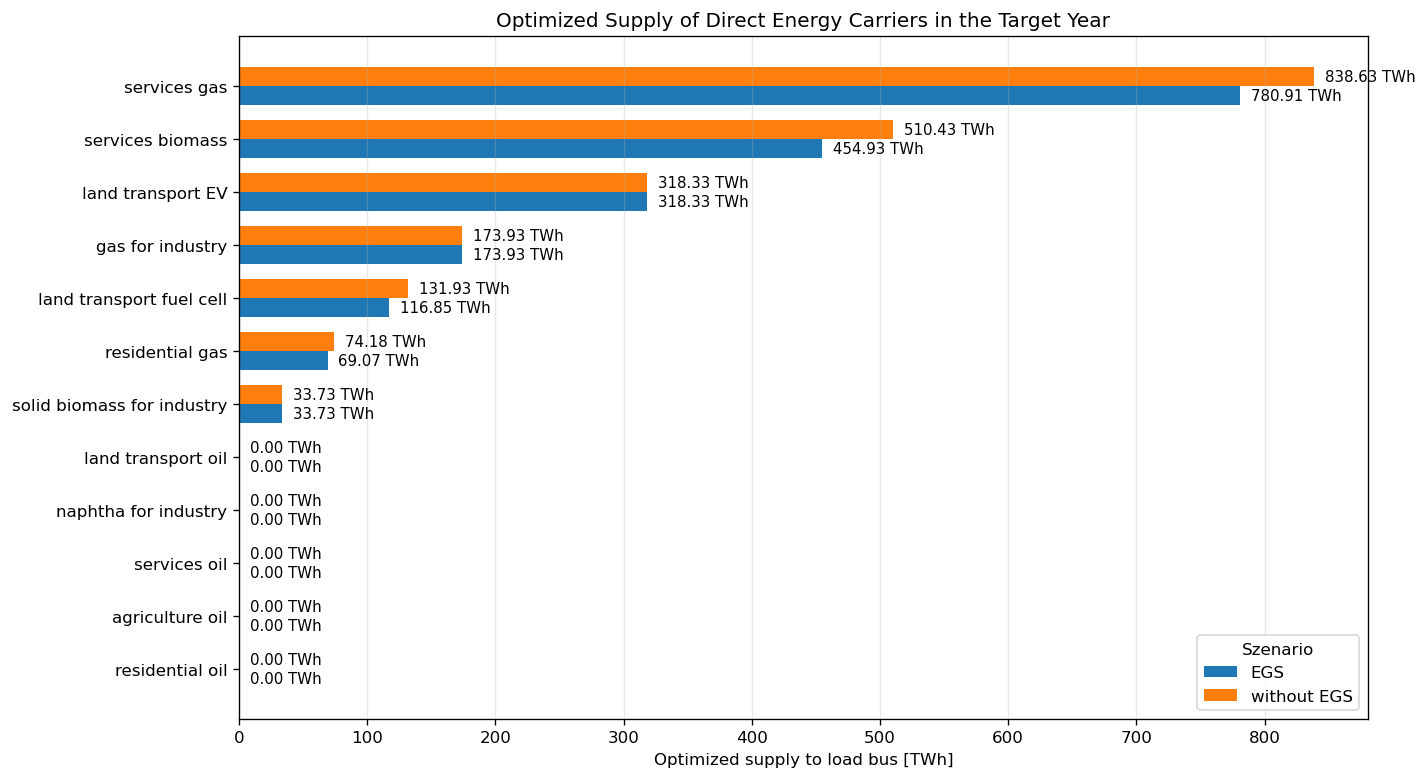

In [23]:
# ============================================================
# Nur optimierte Versorgung der direkten Energieträger
# Vergleich: n_a vs. n_b
# Zieljahr-relevante optimierte Werte
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Heat und Strom standardmäßig ausschließen,
# damit nur direkte Energieträger wie gas, naphtha, biomass usw. gezeigt werden.
exclude_heat_loads = True
exclude_electricity_loads = True

non_energy_bus_pattern = "co2|atmosphere|stored"

min_energy_TWh = 1e-6

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}

scenario_colors = ["#1f77b4", "#ff7f0e"]


# ------------------------------------------------------------
# Helper: Snapshot weights
# ------------------------------------------------------------

def get_snapshot_weights(network):
    """
    Returns snapshot weights for energy calculation.
    MW * hours = MWh
    """
    sw = getattr(network, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(network.snapshots).astype(float).fillna(1.0)

        if "objective" in sw.columns:
            return sw["objective"].reindex(network.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=network.snapshots)


# ------------------------------------------------------------
# Helper: Load time series
# ------------------------------------------------------------

def get_load_timeseries(network, selected_loads):
    """
    Returns load time series in MW.

    Priority:
    1. loads_t.p_set
    2. loads_t.p
    3. static loads.p_set
    """
    if selected_loads.empty:
        return pd.DataFrame(index=network.snapshots)

    static_p_set = (
        selected_loads["p_set"].fillna(0)
        if "p_set" in selected_loads.columns
        else pd.Series(0.0, index=selected_loads.index)
    )

    if (
        hasattr(network, "loads_t")
        and hasattr(network.loads_t, "p_set")
        and not network.loads_t.p_set.empty
    ):
        load_ts = network.loads_t.p_set.reindex(
            index=network.snapshots,
            columns=selected_loads.index,
        )

    elif (
        hasattr(network, "loads_t")
        and hasattr(network.loads_t, "p")
        and not network.loads_t.p.empty
    ):
        load_ts = network.loads_t.p.reindex(
            index=network.snapshots,
            columns=selected_loads.index,
        )

    else:
        load_ts = pd.DataFrame(
            np.nan,
            index=network.snapshots,
            columns=selected_loads.index,
        )

    load_ts = load_ts.fillna(static_p_set).fillna(0)

    return load_ts.clip(lower=0)


# ------------------------------------------------------------
# Helper: relevante Loads auswählen
# ------------------------------------------------------------

def select_direct_energy_loads(network):
    """
    Selects direct non-electric and non-heat energy loads.

    Beispiele:
    - gas for industry
    - naphtha for industry
    - solid biomass for industry
    - oil
    - H2 for industry
    """
    loads = network.loads.copy()

    if loads.empty:
        return loads

    loads["bus_carrier"] = loads.bus.map(network.buses.carrier).astype(str)
    loads["load_carrier"] = loads.carrier.astype(str)

    mask = pd.Series(True, index=loads.index)

    if exclude_electricity_loads:
        mask = mask & ~loads["bus_carrier"].isin(electric_bus_carriers)

    if exclude_heat_loads:
        mask = mask & ~loads["bus_carrier"].str.contains(
            "heat",
            case=False,
            regex=True,
            na=False,
        )

    mask = mask & ~loads["bus_carrier"].str.contains(
        non_energy_bus_pattern,
        case=False,
        regex=True,
        na=False,
    )

    return loads[mask].copy()


# ------------------------------------------------------------
# Optimierte Versorgung der Load-Busse berechnen
# ------------------------------------------------------------

def calculate_optimized_supply_to_load_buses(network, selected_loads, weights):
    """
    Berechnet die optimierte Versorgung der Busse, auf denen die ausgewählten Loads liegen.

    Enthalten:
    - Generatoren, die auf diese Busse einspeisen
    - Link-Ausgänge, die auf diese Busse einspeisen

    Wenn mehrere Load-Carrier auf demselben Bus liegen, wird die Versorgung
    proportional zur Nachfrage auf die Load-Carrier verteilt.
    """
    if selected_loads.empty:
        return pd.Series(dtype=float), pd.DataFrame()

    load_buses = selected_loads["bus"].unique()

    # --------------------------------------------------------
    # Nachfrage je Load für proportionale Zuordnung
    # --------------------------------------------------------

    load_ts = get_load_timeseries(network, selected_loads)

    demand_by_load_TWh = (
        load_ts
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)
    )

    selected_loads = selected_loads.copy()
    selected_loads["fixed_demand_TWh"] = demand_by_load_TWh

    demand_by_bus_carrier = (
        selected_loads
        .groupby(["bus", "load_carrier"])["fixed_demand_TWh"]
        .sum()
    )

    demand_by_bus = (
        selected_loads
        .groupby("bus")["fixed_demand_TWh"]
        .sum()
    )

    # --------------------------------------------------------
    # 1) Generator supply to selected load buses
    # --------------------------------------------------------

    supply_by_bus_TWh = pd.Series(
        0.0,
        index=pd.Index(load_buses, name="bus")
    )

    generators = network.generators.copy()

    selected_generators = generators[
        generators.bus.isin(load_buses)
    ].copy()

    if not selected_generators.empty:
        gen_dispatch = (
            network.generators_t.p
            .reindex(index=network.snapshots, columns=selected_generators.index)
            .fillna(0)
            .clip(lower=0)
        )

        gen_energy_TWh = (
            gen_dispatch
            .mul(weights, axis=0)
            .sum(axis=0)
            .div(1e6)
        )

        gen_bus_energy = (
            gen_energy_TWh
            .groupby(selected_generators.bus)
            .sum()
        )

        supply_by_bus_TWh = supply_by_bus_TWh.add(
            gen_bus_energy,
            fill_value=0
        )

    # --------------------------------------------------------
    # 2) Link outputs to selected load buses
    # --------------------------------------------------------

    links = network.links.copy()

    for bus_number in range(1, 6):
        bus_col = f"bus{bus_number}"
        p_col = f"p{bus_number}"

        if bus_col not in links.columns:
            continue

        if not hasattr(network.links_t, p_col):
            continue

        selected_links = links[
            links[bus_col].isin(load_buses)
        ].copy()

        if selected_links.empty:
            continue

        link_output = (
            -getattr(network.links_t, p_col)
            .reindex(index=network.snapshots, columns=selected_links.index)
            .fillna(0)
        ).clip(lower=0)

        link_energy_TWh = (
            link_output
            .mul(weights, axis=0)
            .sum(axis=0)
            .div(1e6)
        )

        link_bus_energy = (
            link_energy_TWh
            .groupby(selected_links[bus_col])
            .sum()
        )

        supply_by_bus_TWh = supply_by_bus_TWh.add(
            link_bus_energy,
            fill_value=0
        )

    # --------------------------------------------------------
    # 3) Versorgung proportional auf Load-Carrier verteilen
    # --------------------------------------------------------

    supply_by_load_carrier = {}

    detail_rows = []

    for (bus, load_carrier), demand_TWh in demand_by_bus_carrier.items():
        total_bus_demand = demand_by_bus.loc[bus]

        if total_bus_demand <= 0:
            allocated_supply = 0.0
        else:
            allocated_supply = (
                supply_by_bus_TWh.get(bus, 0.0)
                * demand_TWh
                / total_bus_demand
            )

        supply_by_load_carrier[load_carrier] = (
            supply_by_load_carrier.get(load_carrier, 0.0)
            + allocated_supply
        )

        detail_rows.append({
            "bus": bus,
            "load_carrier": load_carrier,
            "fixed_demand_TWh": demand_TWh,
            "optimized_supply_to_load_bus_TWh": allocated_supply,
            "bus_total_fixed_demand_TWh": total_bus_demand,
            "bus_total_optimized_supply_TWh": supply_by_bus_TWh.get(bus, 0.0),
        })

    optimized_supply_by_carrier = pd.Series(
        supply_by_load_carrier,
        name="optimized_supply_to_load_bus_TWh"
    )

    detail_table = pd.DataFrame(detail_rows)

    return optimized_supply_by_carrier, detail_table


# ------------------------------------------------------------
# Beide Szenarien berechnen
# ------------------------------------------------------------

optimized_supply_results = {}
optimized_supply_detail_results = {}

for scenario_name, network in networks_to_compare.items():
    weights = get_snapshot_weights(network)

    selected_loads = select_direct_energy_loads(network)

    optimized_supply_by_carrier, detail_table = calculate_optimized_supply_to_load_buses(
        network,
        selected_loads,
        weights
    )

    optimized_supply_by_carrier = optimized_supply_by_carrier[
        optimized_supply_by_carrier > min_energy_TWh
    ].sort_values(ascending=False)

    optimized_supply_results[scenario_name] = optimized_supply_by_carrier
    optimized_supply_detail_results[scenario_name] = detail_table

    print(
        f"{scenario_name}: Optimierte Versorgung direkter Energieträger = "
        f"{optimized_supply_by_carrier.sum():.2f} TWh"
    )


# ------------------------------------------------------------
# Vergleichstabelle: nur optimierte Werte
# ------------------------------------------------------------

optimized_supply_comparison = pd.DataFrame(
    optimized_supply_results
).fillna(0)

optimized_supply_comparison = optimized_supply_comparison[
    optimized_supply_comparison.sum(axis=1) > min_energy_TWh
]

optimized_supply_comparison = optimized_supply_comparison.loc[
    optimized_supply_comparison.sum(axis=1).sort_values(ascending=False).index
]

optimized_supply_comparison_with_total = optimized_supply_comparison.copy()
optimized_supply_comparison_with_total.loc["Total"] = (
    optimized_supply_comparison_with_total.sum(axis=0)
)

display(
    optimized_supply_comparison_with_total
    .rename_axis("load_carrier")
)


# ------------------------------------------------------------
# Detailtabellen
# ------------------------------------------------------------

for scenario_name, detail_table in optimized_supply_detail_results.items():
    print(f"\nDetailtabelle optimierte Versorgung: {scenario_name}")

    if detail_table.empty:
        print("Keine Werte vorhanden.")
    else:
        detail_table = detail_table[
            detail_table["optimized_supply_to_load_bus_TWh"] > min_energy_TWh
        ].sort_values(
            "optimized_supply_to_load_bus_TWh",
            ascending=False
        )

        display(detail_table)


# ------------------------------------------------------------
# Plot: Nur optimierte Werte
# ------------------------------------------------------------

plot_df = optimized_supply_comparison.loc[
    optimized_supply_comparison.sum(axis=1).sort_values(ascending=True).index
]

fig, ax = plt.subplots(
    figsize=(12, max(6, 0.55 * len(plot_df)))
)

y = np.arange(len(plot_df.index))
bar_height = 0.36

scenario_list = list(plot_df.columns)

xmax = plot_df.max().max() if not plot_df.empty else 0

for scenario_idx, scenario_name in enumerate(scenario_list):
    offset = (scenario_idx - (len(scenario_list) - 1) / 2) * bar_height

    bars = ax.barh(
        y + offset,
        plot_df[scenario_name].values,
        height=bar_height,
        label=scenario_name,
        color=scenario_colors[scenario_idx % len(scenario_colors)]
    )

    for bar, value in zip(bars, plot_df[scenario_name].values):
        if value > min_energy_TWh:
            ax.text(
                value + (0.01 * xmax if xmax > 0 else 0.1),
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f} TWh",
                va="center",
                fontsize=9
            )


ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("Optimized supply to load bus [TWh]")
ax.set_ylabel("")
ax.set_title(
    "Optimized Supply of Direct Energy Carriers in the Target Year"
)

ax.grid(axis="x", alpha=0.3)
ax.legend(title="Szenario")

plt.tight_layout()
plt.show()

EGS: explizit erfasste CO2-Emissionen = 45.95 MtCO2/a
without EGS: explizit erfasste CO2-Emissionen = 98.11 MtCO2/a


,EGS,without EGS
technology,,
Oil,27.085676,66.870103
Residential Gas Boiler,11.188930,11.879486
CCGT,0.058393,11.503328
Process Emissions CC,5.139312,5.139312
Gas for Industry CC,1.913250,1.913251
SMR CC,0.493241,0.500298
Gas Boiler,0.000005,0.229394
Services Gas Boiler,0.068683,0.072243
SMR,0.000041,0.000046


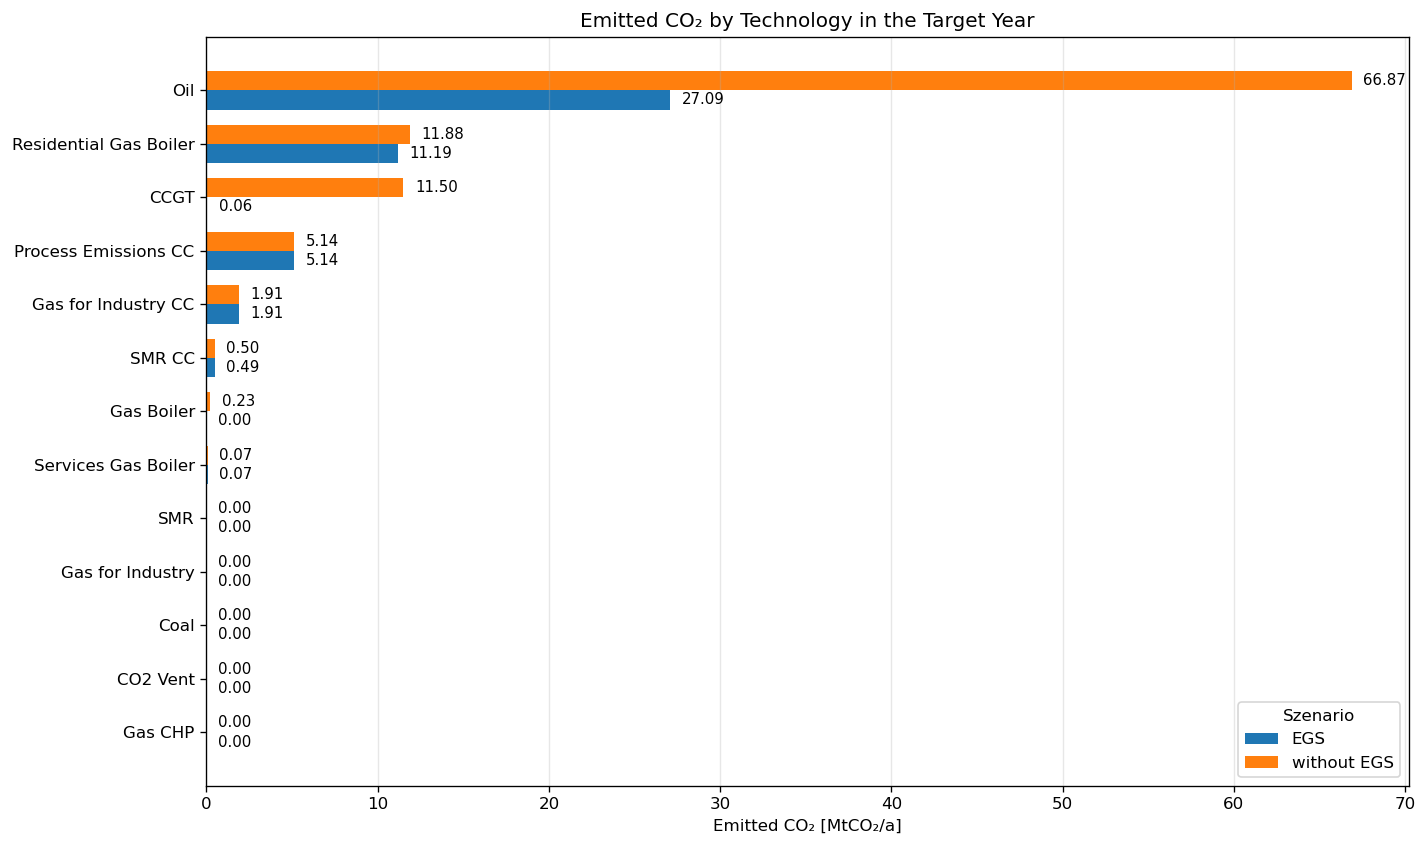

In [24]:
# ============================================================
# Emittiertes CO2 pro Technologie
# Korrigierte Version für PyPSA-Earth:
# erkennt Busname "co2 atmosphere", auch wenn carrier nur "co2" ist
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}

scenario_colors = ["#1f77b4", "#ff7f0e"]

min_co2_Mt = 1e-6


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def get_snapshot_weights(n):
    if hasattr(n, "snapshot_weightings"):
        if isinstance(n.snapshot_weightings, pd.DataFrame):
            if "generators" in n.snapshot_weightings.columns:
                return n.snapshot_weightings["generators"].reindex(n.snapshots).fillna(1.0)
            if "objective" in n.snapshot_weightings.columns:
                return n.snapshot_weightings["objective"].reindex(n.snapshots).fillna(1.0)

    return pd.Series(1.0, index=n.snapshots)


def is_co2_atmosphere_bus(n, bus_name):
    """
    Erkennt CO2-Atmosphäre-Busse robust über Busnamen und Carrier.
    In deinem Netzwerk:
        bus_name = 'co2 atmosphere'
        carrier  = 'co2'
    """
    bus_name_str = str(bus_name).lower()

    if bus_name not in n.buses.index:
        return False

    carrier_str = str(n.buses.loc[bus_name, "carrier"]).lower()

    return (
        ("co2" in bus_name_str and "atmosphere" in bus_name_str)
        or ("co2" in carrier_str and "atmosphere" in carrier_str)
    )


def find_co2_atmosphere_buses(n):
    return [
        bus
        for bus in n.buses.index
        if is_co2_atmosphere_bus(n, bus)
    ]


def clean_technology_name(carrier):
    carrier = str(carrier)

    replacements = {
        "urban central gas CHP": "Gas CHP",
        "urban central gas CHP CC": "Gas CHP CC",
        "urban central gas boiler": "Gas Boiler",
        "residential urban decentral gas boiler": "Residential Gas Boiler",
        "residential rural gas boiler": "Residential Gas Boiler",
        "services urban decentral gas boiler": "Services Gas Boiler",
        "services rural gas boiler": "Services Gas Boiler",
        "gas for industry": "Gas for Industry",
        "gas for industry CC": "Gas for Industry CC",
        "solid biomass for industry CC": "Biomass for Industry CC",
        "urban central solid biomass CHP CC": "Biomass CHP CC",
        "process emissions": "Process Emissions",
        "process emissions CC": "Process Emissions CC",
        "co2 vent": "CO2 Vent",
        "oil": "Oil",
        "coal": "Coal",
        "CCGT": "CCGT",
        "OCGT": "OCGT",
        "SMR": "SMR",
        "SMR CC": "SMR CC",
        "DAC": "DAC",
    }

    return replacements.get(carrier, carrier)


# ------------------------------------------------------------
# CO2-Emissionen pro Technologie berechnen
# ------------------------------------------------------------

def calculate_emitted_co2_by_technology(n):
    """
    Berechnet explizite CO2-Emissionen aus Link-Flüssen in den Bus
    'co2 atmosphere'.

    PyPSA-Konvention für Links:
    negative p-Werte am Ausgangsbus bedeuten Einspeisung in diesen Bus.
    Deshalb gilt:
        CO2 emission = -p_bus
    """

    weights = get_snapshot_weights(n)

    co2_atmosphere_buses = find_co2_atmosphere_buses(n)

    if len(co2_atmosphere_buses) == 0:
        print("Keine CO2-atmosphere-Busse gefunden.")
        return pd.Series(dtype=float)

    links = n.links.copy()

    emission_parts = []

    for bus_number in range(1, 6):
        bus_col = f"bus{bus_number}"
        p_col = f"p{bus_number}"

        if bus_col not in links.columns:
            continue

        if not hasattr(n.links_t, p_col):
            continue

        mask = links[bus_col].isin(co2_atmosphere_buses)

        if not mask.any():
            continue

        selected_links = links.loc[mask].copy()

        p = (
            getattr(n.links_t, p_col)
            .reindex(index=n.snapshots, columns=selected_links.index)
            .fillna(0)
        )

        # Negative Werte = Einspeisung in CO2 atmosphere
        co2_emission = (-p).clip(lower=0)

        co2_by_link_Mt = (
            co2_emission
            .mul(weights, axis=0)
            .sum(axis=0)
            .div(1e6)  # tCO2 -> MtCO2
        )

        tech_names = selected_links["carrier"].map(clean_technology_name)

        co2_by_tech = (
            co2_by_link_Mt
            .groupby(tech_names)
            .sum()
        )

        emission_parts.append(co2_by_tech)

    if not emission_parts:
        return pd.Series(dtype=float)

    result = (
        pd.concat(emission_parts)
        .groupby(level=0)
        .sum()
        .sort_values(ascending=False)
    )

    result = result[result > min_co2_Mt]

    return result


# ------------------------------------------------------------
# Beide Szenarien berechnen
# ------------------------------------------------------------

co2_by_technology_results = {}

for scenario_name, n in networks_to_compare.items():
    values = calculate_emitted_co2_by_technology(n)
    co2_by_technology_results[scenario_name] = values

    print(f"{scenario_name}: explizit erfasste CO2-Emissionen = {values.sum():.2f} MtCO2/a")


# ------------------------------------------------------------
# Tabelle
# ------------------------------------------------------------

co2_by_technology_comparison = pd.DataFrame(co2_by_technology_results).fillna(0)

co2_by_technology_comparison = co2_by_technology_comparison[
    co2_by_technology_comparison.sum(axis=1) > min_co2_Mt
]

co2_by_technology_comparison = co2_by_technology_comparison.loc[
    co2_by_technology_comparison.sum(axis=1).sort_values(ascending=False).index
]

co2_by_technology_comparison_with_total = co2_by_technology_comparison.copy()
co2_by_technology_comparison_with_total.loc["Total"] = (
    co2_by_technology_comparison_with_total.sum(axis=0)
)

display(
    co2_by_technology_comparison_with_total
    .rename_axis("technology")
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plot_df = co2_by_technology_comparison.loc[
    co2_by_technology_comparison.sum(axis=1).sort_values(ascending=True).index
]

fig, ax = plt.subplots(
    figsize=(12, max(6, 0.55 * len(plot_df)))
)

y = np.arange(len(plot_df.index))
bar_height = 0.36

scenario_list = list(plot_df.columns)

xmax = plot_df.max().max() if not plot_df.empty else 1

for scenario_idx, scenario_name in enumerate(scenario_list):
    offset = (scenario_idx - (len(scenario_list) - 1) / 2) * bar_height

    bars = ax.barh(
        y + offset,
        plot_df[scenario_name].values,
        height=bar_height,
        label=scenario_name,
        color=scenario_colors[scenario_idx % len(scenario_colors)]
    )

    for bar, value in zip(bars, plot_df[scenario_name].values):
        if value > min_co2_Mt:
            ax.text(
                value + 0.01 * xmax,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f}",
                va="center",
                fontsize=9
            )

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("Emitted CO₂ [MtCO₂/a]")
ax.set_ylabel("")
ax.set_title("Emitted CO₂ by Technology in the Target Year")

ax.grid(axis="x", alpha=0.3)
ax.legend(title="Szenario")

plt.tight_layout()
plt.show()

Werte der Grafik [MtCO2/a]


,EGS,without EGS
technology,,
Oil,27.085676,66.870103
Residential Gas Boiler,11.188930,11.879486
CCGT,0.058386,11.503328
Process Emissions CC,5.139306,5.139307
Gas for Industry CC,1.913250,1.913251
SMR CC,0.493235,0.500293
Gas Boiler,0.000000,0.229393
Services Gas Boiler,0.068680,0.072241
SMR,0.000027,0.000034


Kontroll- und Gesamtwerte [MtCO2/a]


,Gross emissions to co2 atmosphere [MtCO2/a],CO2 removed from co2 atmosphere [MtCO2/a],Net flow to co2 atmosphere [MtCO2/a],CO2 stored [MtCO2/a],Graph net emissions minus stored [MtCO2/a],CO2 atmosphere buses,CO2 atmosphere store e_nom_opt [MtCO2],CO2 atmosphere store charged [MtCO2]
EGS,45.947491,404.297551,-358.35006,551.44377,-505.49628,co2 atmosphere,5.184018,17.498409
without EGS,98.107437,456.456566,-358.34913,603.780427,-505.67299,co2 atmosphere,16.763403,35.945778


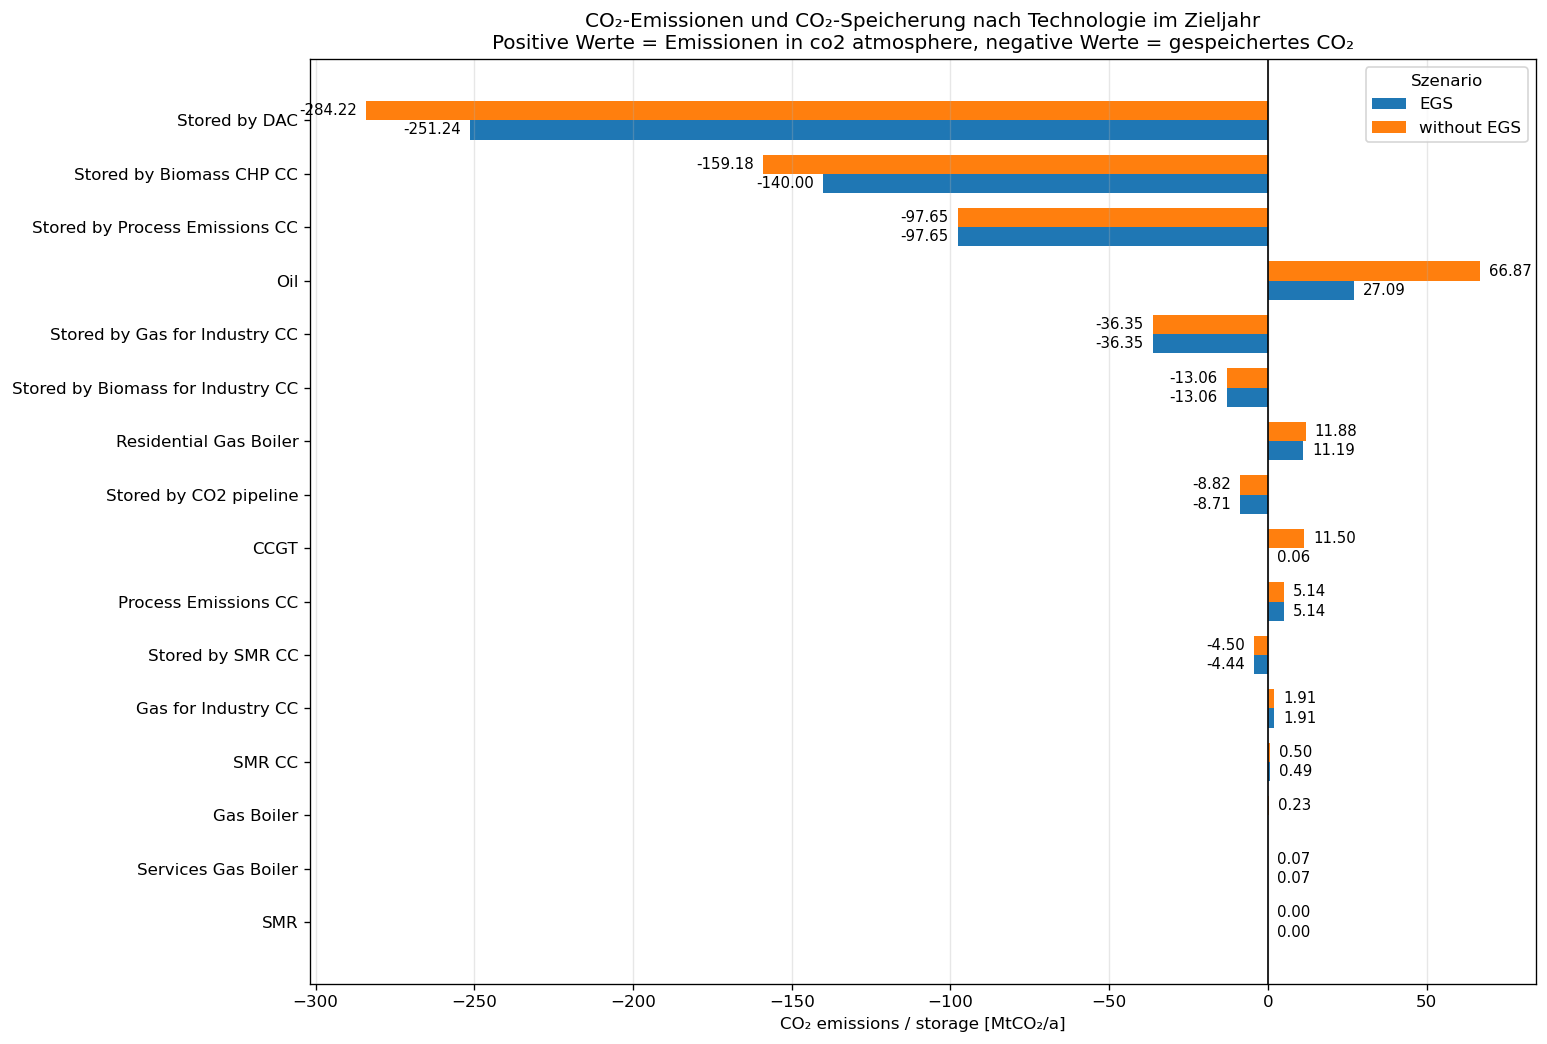

In [25]:
# ============================================================
# CO2-Emissionen und CO2-Speicherung nach Technologie
# robuste Version:
# - scannt alle busX-Spalten
# - positive Werte: Einspeisung in co2 atmosphere
# - negative Werte: Einspeisung in co2 stored
# - zusätzliche Kontrolltabelle gegen co2 atmosphere Store
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.dpi"] = 120


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

scenario_names = {
    "A": SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A",
    "B": SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B",
}

networks_to_compare = {
    scenario_names["A"]: n_a,
    scenario_names["B"]: n_b,
}

scenario_colors = ["#1f77b4", "#ff7f0e"]

min_co2_Mt = 1e-6


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

def get_snapshot_weights(n):
    sw = getattr(n, "snapshot_weightings", None)

    if isinstance(sw, pd.DataFrame):
        if "generators" in sw.columns:
            return sw["generators"].reindex(n.snapshots).astype(float).fillna(1.0)
        if "objective" in sw.columns:
            return sw["objective"].reindex(n.snapshots).astype(float).fillna(1.0)

    return pd.Series(1.0, index=n.snapshots)


def get_link_bus_columns(n):
    """
    Gibt alle Link-Bus-Spalten zurück: bus0, bus1, bus2, ...
    """
    bus_cols = [
        col for col in n.links.columns
        if col.startswith("bus") and col[3:].isdigit()
    ]

    return sorted(bus_cols, key=lambda x: int(x.replace("bus", "")))


def is_co2_text(text):
    text = str(text).lower()
    return "co2" in text or "co₂" in text


def is_co2_atmosphere_bus(n, bus_name):
    if bus_name not in n.buses.index:
        return False

    bus_name_str = str(bus_name).lower()
    carrier_str = str(n.buses.loc[bus_name, "carrier"]).lower()

    return (
        is_co2_text(bus_name_str)
        and "atmosphere" in bus_name_str
    ) or (
        is_co2_text(carrier_str)
        and "atmosphere" in carrier_str
    )


def is_co2_stored_bus(n, bus_name):
    if bus_name not in n.buses.index:
        return False

    bus_name_str = str(bus_name).lower()
    carrier_str = str(n.buses.loc[bus_name, "carrier"]).lower()

    storage_words = ["stored", "storage", "sequest", "sequestration"]

    return (
        is_co2_text(bus_name_str)
        and any(word in bus_name_str for word in storage_words)
    ) or (
        is_co2_text(carrier_str)
        and any(word in carrier_str for word in storage_words)
    )


def is_intermediate_co2_bus(n, bus_name):
    if bus_name not in n.buses.index:
        return False

    bus_name_str = str(bus_name).lower()
    carrier_str = str(n.buses.loc[bus_name, "carrier"]).lower()

    is_co2_bus = is_co2_text(bus_name_str) or is_co2_text(carrier_str)

    return (
        is_co2_bus
        and not is_co2_atmosphere_bus(n, bus_name)
        and not is_co2_stored_bus(n, bus_name)
    )


def find_co2_atmosphere_buses(n):
    return [
        bus for bus in n.buses.index
        if is_co2_atmosphere_bus(n, bus)
    ]


def find_co2_stored_buses(n):
    return [
        bus for bus in n.buses.index
        if is_co2_stored_bus(n, bus)
    ]


def find_intermediate_co2_buses(n):
    return [
        bus for bus in n.buses.index
        if is_intermediate_co2_bus(n, bus)
    ]


def clean_technology_name(carrier):
    carrier = str(carrier)

    replacements = {
        "urban central gas CHP": "Gas CHP",
        "urban central gas CHP CC": "Gas CHP CC",
        "urban central gas boiler": "Gas Boiler",
        "residential urban decentral gas boiler": "Residential Gas Boiler",
        "residential rural gas boiler": "Residential Gas Boiler",
        "services urban decentral gas boiler": "Services Gas Boiler",
        "services rural gas boiler": "Services Gas Boiler",
        "gas for industry": "Gas for Industry",
        "gas for industry CC": "Gas for Industry CC",
        "solid biomass for industry": "Biomass for Industry",
        "solid biomass for industry CC": "Biomass for Industry CC",
        "urban central solid biomass CHP": "Biomass CHP",
        "urban central solid biomass CHP CC": "Biomass CHP CC",
        "process emissions": "Process Emissions",
        "process emissions CC": "Process Emissions CC",
        "co2 vent": "CO2 Vent",
        "co2 stored": "CO2 Storage",
        "CO2 sequestration": "CO2 Storage",
        "oil": "Oil",
        "coal": "Coal",
        "CCGT": "CCGT",
        "OCGT": "OCGT",
        "SMR": "SMR",
        "SMR CC": "SMR CC",
        "DAC": "DAC",
    }

    return replacements.get(carrier, carrier)


def get_signed_link_flow_to_bus_Mt(n, selected_links, bus_number, weights):
    """
    Gibt den jährlichen CO2-Fluss in einen Bus zurück.

    PyPSA-Link-Konvention:
    pX > 0  = Entnahme aus busX
    pX < 0  = Einspeisung in busX

    Deshalb:
    signed_injection = -pX

    positive Werte  = Einspeisung in den Bus
    negative Werte  = Entnahme aus dem Bus
    """
    p_col = f"p{bus_number}"

    if selected_links.empty:
        return pd.Series(dtype=float)

    if not hasattr(n.links_t, p_col):
        return pd.Series(dtype=float)

    signed_injection = (
        -getattr(n.links_t, p_col)
        .reindex(index=n.snapshots, columns=selected_links.index)
        .fillna(0)
    )

    annual_Mt = (
        signed_injection
        .mul(weights, axis=0)
        .sum(axis=0)
        .div(1e6)
    )

    return annual_Mt


# ------------------------------------------------------------
# Positive Emissionen in co2 atmosphere
# ------------------------------------------------------------

def calculate_positive_emissions_to_atmosphere_by_technology(n):
    weights = get_snapshot_weights(n)
    links = n.links.copy()

    co2_atmosphere_buses = find_co2_atmosphere_buses(n)
    bus_cols = get_link_bus_columns(n)

    rows = []

    for bus_col in bus_cols:
        bus_number = int(bus_col.replace("bus", ""))

        mask = links[bus_col].isin(co2_atmosphere_buses)

        if not mask.any():
            continue

        selected_links = links.loc[mask].copy()

        signed_flow_Mt = get_signed_link_flow_to_bus_Mt(
            n,
            selected_links,
            bus_number,
            weights,
        )

        positive_emissions_Mt = signed_flow_Mt.clip(lower=0)

        for link_name, value in positive_emissions_Mt.items():
            if value <= min_co2_Mt:
                continue

            technology = clean_technology_name(
                selected_links.loc[link_name, "carrier"]
            )

            rows.append({
                "technology": technology,
                "link": link_name,
                "co2_Mt": value,
            })

    if not rows:
        return pd.Series(dtype=float), pd.DataFrame()

    detail = pd.DataFrame(rows)

    result = (
        detail
        .groupby("technology")["co2_Mt"]
        .sum()
        .sort_values(ascending=False)
    )

    return result, detail


# ------------------------------------------------------------
# CO2-Entnahme aus co2 atmosphere, z.B. DAC
# ------------------------------------------------------------

def calculate_removal_from_atmosphere_by_technology(n):
    """
    Diese Werte sind nicht dasselbe wie CO2 stored.
    Sie zeigen nur, ob aus co2 atmosphere wieder CO2 entnommen wird.
    Das ist wichtig für die Kontrolle gegen e_nom_opt des atmosphere Stores.
    """
    weights = get_snapshot_weights(n)
    links = n.links.copy()

    co2_atmosphere_buses = find_co2_atmosphere_buses(n)
    bus_cols = get_link_bus_columns(n)

    rows = []

    for bus_col in bus_cols:
        bus_number = int(bus_col.replace("bus", ""))

        mask = links[bus_col].isin(co2_atmosphere_buses)

        if not mask.any():
            continue

        selected_links = links.loc[mask].copy()

        signed_flow_Mt = get_signed_link_flow_to_bus_Mt(
            n,
            selected_links,
            bus_number,
            weights,
        )

        removals_Mt = (-signed_flow_Mt).clip(lower=0)

        for link_name, value in removals_Mt.items():
            if value <= min_co2_Mt:
                continue

            technology = clean_technology_name(
                selected_links.loc[link_name, "carrier"]
            )

            rows.append({
                "technology": technology,
                "link": link_name,
                "co2_removed_from_atmosphere_Mt": value,
            })

    if not rows:
        return pd.Series(dtype=float), pd.DataFrame()

    detail = pd.DataFrame(rows)

    result = (
        detail
        .groupby("technology")["co2_removed_from_atmosphere_Mt"]
        .sum()
        .sort_values(ascending=False)
    )

    return result, detail


# ------------------------------------------------------------
# Upstream CO2 zu internen CO2-Bussen
# ------------------------------------------------------------

def is_pure_co2_transport_link(n, link):
    input_bus = link.get("bus0", np.nan)

    if input_bus in n.buses.index:
        input_carrier = str(n.buses.loc[input_bus, "carrier"]).lower()
    else:
        input_carrier = ""

    link_carrier = str(link.get("carrier", "")).lower()

    is_input_co2 = is_co2_text(input_bus) or is_co2_text(input_carrier)

    has_capture_marker = (
        "dac" in link_carrier
        or "capture" in link_carrier
        or "cc" in link_carrier
        or "ccs" in link_carrier
    )

    return is_input_co2 and not has_capture_marker


def calculate_upstream_co2_to_intermediate_by_technology(n):
    weights = get_snapshot_weights(n)
    links = n.links.copy()

    intermediate_co2_buses = find_intermediate_co2_buses(n)
    bus_cols = get_link_bus_columns(n)

    rows = []

    for bus_col in bus_cols:
        bus_number = int(bus_col.replace("bus", ""))

        mask = links[bus_col].isin(intermediate_co2_buses)

        if not mask.any():
            continue

        selected_links = links.loc[mask].copy()

        signed_flow_Mt = get_signed_link_flow_to_bus_Mt(
            n,
            selected_links,
            bus_number,
            weights,
        )

        positive_injection_Mt = signed_flow_Mt.clip(lower=0)

        for link_name, value in positive_injection_Mt.items():
            if value <= min_co2_Mt:
                continue

            link = selected_links.loc[link_name]

            if is_pure_co2_transport_link(n, link):
                continue

            technology = clean_technology_name(link.get("carrier", ""))

            rows.append({
                "target_co2_bus": link[bus_col],
                "technology": technology,
                "captured_to_intermediate_MtCO2": value,
            })

    if not rows:
        return pd.DataFrame(
            columns=[
                "target_co2_bus",
                "technology",
                "captured_to_intermediate_MtCO2",
            ]
        )

    return (
        pd.DataFrame(rows)
        .groupby(["target_co2_bus", "technology"], as_index=False)["captured_to_intermediate_MtCO2"]
        .sum()
    )


# ------------------------------------------------------------
# Negative CO2-Speicherung nach Technologie
# ------------------------------------------------------------

def calculate_negative_storage_by_technology(n):
    weights = get_snapshot_weights(n)
    links = n.links.copy()

    co2_stored_buses = find_co2_stored_buses(n)
    upstream_by_bus_tech = calculate_upstream_co2_to_intermediate_by_technology(n)

    bus_cols = get_link_bus_columns(n)

    rows = []

    for bus_col in bus_cols:
        bus_number = int(bus_col.replace("bus", ""))

        mask = links[bus_col].isin(co2_stored_buses)

        if not mask.any():
            continue

        selected_links = links.loc[mask].copy()

        signed_flow_Mt = get_signed_link_flow_to_bus_Mt(
            n,
            selected_links,
            bus_number,
            weights,
        )

        stored_Mt = signed_flow_Mt.clip(lower=0)

        for link_name, stored_value in stored_Mt.items():
            if stored_value <= min_co2_Mt:
                continue

            link = selected_links.loc[link_name]
            input_bus = link.get("bus0", np.nan)

            # Falls Speicherung aus internem CO2-Bus:
            # gespeicherte Menge anteilig auf upstream Capture-Technologien verteilen.
            if (
                not upstream_by_bus_tech.empty
                and input_bus in upstream_by_bus_tech["target_co2_bus"].unique()
            ):
                source_mix = upstream_by_bus_tech[
                    upstream_by_bus_tech["target_co2_bus"] == input_bus
                ].copy()

                source_total = source_mix["captured_to_intermediate_MtCO2"].sum()

                if source_total > min_co2_Mt:
                    for _, source_row in source_mix.iterrows():
                        share = (
                            source_row["captured_to_intermediate_MtCO2"]
                            / source_total
                        )

                        rows.append({
                            "technology": f"Stored by {source_row['technology']}",
                            "stored_MtCO2": stored_value * share,
                        })

                    continue

            # Falls direkte Speicherung:
            technology = clean_technology_name(link.get("carrier", ""))

            rows.append({
                "technology": f"Stored by {technology}",
                "stored_MtCO2": stored_value,
            })

    if not rows:
        return pd.Series(dtype=float), pd.DataFrame()

    detail = pd.DataFrame(rows)

    result = (
        detail
        .groupby("technology")["stored_MtCO2"]
        .sum()
        .sort_values(ascending=False)
    )

    return -result, detail


# ------------------------------------------------------------
# CO2 atmosphere Store-Kontrolle
# ------------------------------------------------------------

def calculate_atmosphere_store_check(n):
    weights = get_snapshot_weights(n)

    atmosphere_buses = find_co2_atmosphere_buses(n)

    if len(atmosphere_buses) == 0:
        return {
            "CO2 atmosphere buses": "",
            "CO2 atmosphere store e_nom_opt [MtCO2]": np.nan,
            "CO2 atmosphere store charged [MtCO2]": np.nan,
        }

    atmosphere_stores = n.stores[
        n.stores.bus.isin(atmosphere_buses)
        | n.stores.index.isin(atmosphere_buses)
    ].copy()

    e_nom_opt_Mt = np.nan
    store_charged_Mt = np.nan

    if not atmosphere_stores.empty:
        if "e_nom_opt" in atmosphere_stores.columns:
            e_nom_opt_Mt = atmosphere_stores["e_nom_opt"].fillna(0).sum() / 1e6
        elif "e_nom" in atmosphere_stores.columns:
            e_nom_opt_Mt = atmosphere_stores["e_nom"].fillna(0).sum() / 1e6

        if hasattr(n, "stores_t") and hasattr(n.stores_t, "p"):
            p = (
                n.stores_t.p
                .reindex(index=n.snapshots, columns=atmosphere_stores.index)
                .fillna(0)
            )

            # Store-Konvention:
            # p < 0 = charging, also CO2 wird im atmosphere Store akkumuliert
            store_charged_Mt = (
                (-p).clip(lower=0)
                .mul(weights, axis=0)
                .sum()
                .sum()
                / 1e6
            )

    return {
        "CO2 atmosphere buses": ", ".join(map(str, atmosphere_buses)),
        "CO2 atmosphere store e_nom_opt [MtCO2]": e_nom_opt_Mt,
        "CO2 atmosphere store charged [MtCO2]": store_charged_Mt,
    }


# ------------------------------------------------------------
# Main calculation
# ------------------------------------------------------------

co2_plot_results = {}
co2_total_rows = {}

for scenario_name, n in networks_to_compare.items():

    positive_emissions, positive_detail = calculate_positive_emissions_to_atmosphere_by_technology(n)
    atmosphere_removal, removal_detail = calculate_removal_from_atmosphere_by_technology(n)
    negative_storage, storage_detail = calculate_negative_storage_by_technology(n)

    plot_values = pd.concat([positive_emissions, negative_storage], axis=0)
    plot_values = plot_values.groupby(level=0).sum()
    plot_values = plot_values[plot_values.abs() > min_co2_Mt]

    co2_plot_results[scenario_name] = plot_values

    gross_positive_atmosphere_Mt = positive_emissions.sum()
    gross_removal_from_atmosphere_Mt = atmosphere_removal.sum()
    net_to_atmosphere_bus_Mt = gross_positive_atmosphere_Mt - gross_removal_from_atmosphere_Mt
    stored_co2_Mt = -negative_storage.sum()

    store_check = calculate_atmosphere_store_check(n)

    co2_total_rows[scenario_name] = {
        "Gross emissions to co2 atmosphere [MtCO2/a]": gross_positive_atmosphere_Mt,
        "CO2 removed from co2 atmosphere [MtCO2/a]": gross_removal_from_atmosphere_Mt,
        "Net flow to co2 atmosphere [MtCO2/a]": net_to_atmosphere_bus_Mt,
        "CO2 stored [MtCO2/a]": stored_co2_Mt,
        "Graph net emissions minus stored [MtCO2/a]": plot_values.sum(),
        **store_check,
    }


# ------------------------------------------------------------
# Tabellen
# ------------------------------------------------------------

co2_plot_values = pd.DataFrame(co2_plot_results).fillna(0)

co2_plot_values = co2_plot_values[
    co2_plot_values.abs().sum(axis=1) > min_co2_Mt
]

positive_rows = co2_plot_values[co2_plot_values.mean(axis=1) >= 0]
negative_rows = co2_plot_values[co2_plot_values.mean(axis=1) < 0]

positive_rows = positive_rows.loc[
    positive_rows.mean(axis=1).sort_values(ascending=False).index
]

negative_rows = negative_rows.loc[
    negative_rows.mean(axis=1).sort_values(ascending=True).index
]

co2_plot_values = pd.concat([positive_rows, negative_rows])

co2_totals = pd.DataFrame(co2_total_rows).T

print("Werte der Grafik [MtCO2/a]")
display(
    co2_plot_values
    .rename_axis("technology")
)

print("Kontroll- und Gesamtwerte [MtCO2/a]")
display(co2_totals)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plot_df = co2_plot_values.loc[
    co2_plot_values.abs().mean(axis=1).sort_values(ascending=True).index
]

fig, ax = plt.subplots(
    figsize=(13, max(7, 0.55 * len(plot_df)))
)

y = np.arange(len(plot_df.index))
bar_height = 0.36

scenario_list = list(plot_df.columns)

x_abs_max = plot_df.abs().max().max() if not plot_df.empty else 1

for scenario_idx, scenario_name in enumerate(scenario_list):
    offset = (scenario_idx - (len(scenario_list) - 1) / 2) * bar_height

    values = plot_df[scenario_name].values

    bars = ax.barh(
        y + offset,
        values,
        height=bar_height,
        color=scenario_colors[scenario_idx % len(scenario_colors)],
        label=scenario_name,
    )

    for bar, value in zip(bars, values):
        if abs(value) > min_co2_Mt:
            if value >= 0:
                x_text = value + 0.01 * x_abs_max
                ha = "left"
            else:
                x_text = value - 0.01 * x_abs_max
                ha = "right"

            ax.text(
                x_text,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f}",
                va="center",
                ha=ha,
                fontsize=9,
            )

ax.axvline(0, color="black", linewidth=1.0)

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("CO₂ emissions / storage [MtCO₂/a]")
ax.set_ylabel("")
ax.set_title(
    "CO₂-Emissionen und CO₂-Speicherung nach Technologie im Zieljahr\n"
    "Positive Werte = Emissionen in co2 atmosphere, negative Werte = gespeichertes CO₂"
)

ax.grid(axis="x", alpha=0.3)
ax.legend(title="Szenario")

plt.tight_layout()
plt.show()

Hinweis: Die geladene gadm_shapes-Datei enthält keinen passenden ADM-Regions-Identifier. Lade den passenden GADM-Layer direkt aus GADM_SHAPES_PATH.
------------------------------------------------------------
Feine Simulationsregionen
------------------------------------------------------------
GADM-Level: 1
Anzahl Regionen: 47
Verwendete ID-Spalte: GID_1
Beispiele:
['JP.1_1', 'JP.2_1', 'JP.3_1', 'JP.4_1', 'JP.5_1', 'JP.6_1', 'JP.7_1', 'JP.8_1', 'JP.9_1', 'JP.10_1']
Hinweis: Die geladene gadm_shapes_10-Datei enthält keine passende Regionsspalte. Lade den passenden Layer direkt aus GADM_SHAPES_PATH_10.
------------------------------------------------------------
Grobe Darstellungsregionen
------------------------------------------------------------
GADM-Level: 1
Anzahl Regionen: 10
Verwendete ID-Spalte: NAME_1
Beispiele:
['Tokai', 'Tohoku', 'Hokkaido', 'Kinki', 'Koshinetsu', 'Hokuriku', 'Kanto', 'Chugoku', 'Kyushu', 'Shikoku']
------------------------------------------------------------

,EGS,without EGS
Geothermie [GW],38.042327,0.066400
H2-Import [TWh],52.698025,48.335839
Inländische H2-Produktion [TWh],17.188896,17.434832


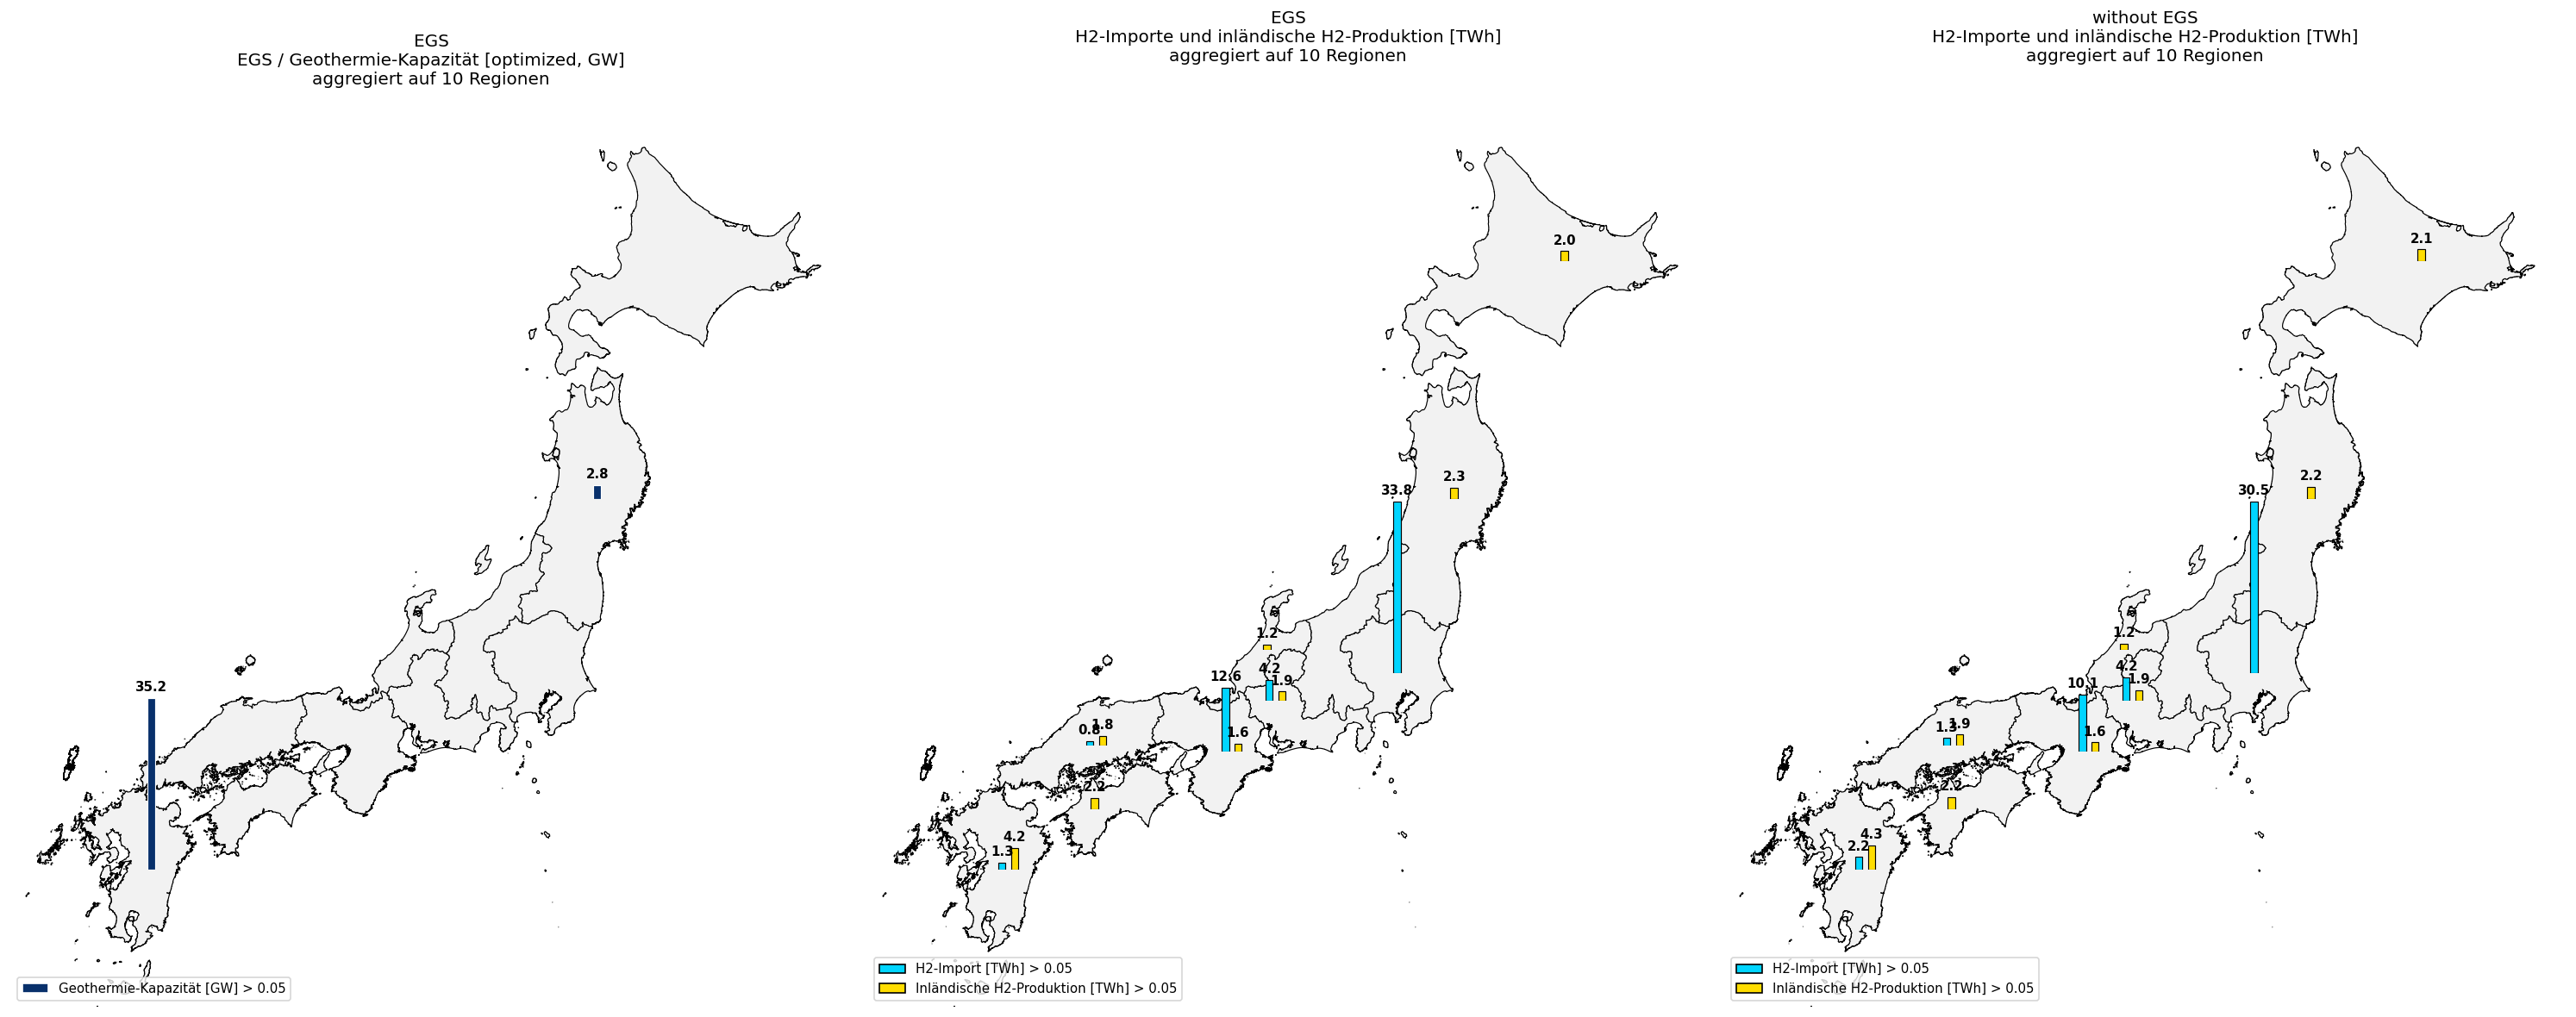


Kartenwerte EGS


,region,Geothermie [GW],H2-Import [TWh],Inländische H2-Produktion [TWh]
8,Kyushu,3.524808e+01,1.253598,4.168399
1,Tohoku,2.792242e+00,0.000000,2.271022
4,Koshinetsu,2.000404e-03,0.000000,0.000033
6,Kanto,1.102659e-06,33.823257,0.000076
3,Kinki,9.293062e-07,12.619604,1.607087
7,Chugoku,8.788972e-07,0.810883,1.836492
5,Hokuriku,5.702416e-07,0.000000,1.155929
9,Shikoku,5.534956e-07,0.000000,2.217818
0,Tokai,4.021171e-07,4.190684,1.904757
2,Hokkaido,1.217679e-07,0.000000,2.027282



Kartenwerte without EGS


,region,H2-Import [TWh],Inländische H2-Produktion [TWh]
6,Kanto,30.549999,0.000055
3,Kinki,10.131938,1.630812
0,Tokai,4.190588,1.929239
8,Kyushu,2.174041,4.274313
7,Chugoku,1.289274,1.871708
9,Shikoku,0.000000,2.233785
1,Tohoku,0.000000,2.181168
2,Hokkaido,0.000000,2.141367
5,Hokuriku,0.000000,1.172360
4,Koshinetsu,0.000000,0.000025


In [26]:
# ============================================================
# Drei Karten:
# 1) Szenario A: EGS / Geothermie-Kapazität
# 2) Szenario A: H2-Importe und inländische H2-Produktion
# 3) Szenario B: H2-Importe und inländische H2-Produktion
#
# Verwendete Geodaten:
# gadm_shapes    = load_geodata_optional(GADM_SHAPES_PATH)
# gadm_shapes_10 = load_geodata_optional(GADM_SHAPES_PATH_10)
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import fiona
from pathlib import Path


# ============================================================
# Settings
# ============================================================

capacity_mode = "optimized"   # "optimized" = p_nom_opt, "current" = p_nom

electric_bus_carriers = ["AC", "DC", "low voltage"]

# Geothermie-Erkennung
geothermal_carrier_regex = r"geothermal"

# H2-Importe
h2_import_generator_suffix = " import H2 port"

# Inländische H2-Produktion
h2_prod_carriers = ["H2 Electrolysis", "SMR", "SMR CC"]

# ------------------------------------------------------------
# GADM / Aggregation
# ------------------------------------------------------------

aggregate_to_coarse_regions = True

simulation_gadm_level = 1
coarse_gadm_level = 1

# Im 10er-GPKG ist normalerweise NAME_1 die grobe Region
coarse_region_id_col = "NAME_1"

# ------------------------------------------------------------
# Schwellenwerte für Anzeige
# ------------------------------------------------------------

geothermal_threshold_GW = 0.05
h2_threshold_TWh = 0.05

# ------------------------------------------------------------
# Farben
# ------------------------------------------------------------

region_fill_color = "#f2f2f2"
region_edge_color = "black"

geo_bar_color = "#08306b"
geo_bar_edge_color = "white"

h2_import_bar_color = "#00d5ff"
h2_domestic_bar_color = "#ffdd00"
h2_bar_edge_color = "black"

# ------------------------------------------------------------
# Balkengrößen
# ------------------------------------------------------------

bar_width = 0.042
bar_height = 0.210

geo_bar_label_fontsize = 9
h2_bar_label_fontsize = 9

# Relevanter Kartenausschnitt Japan
map_extent = [128.0, 146.5, 30.0, 46.5]

scenario_a_name = SCENARIO_A_NAME if "SCENARIO_A_NAME" in globals() else "Szenario A"
scenario_b_name = SCENARIO_B_NAME if "SCENARIO_B_NAME" in globals() else "Szenario B"


# ============================================================
# Basic checks
# ============================================================

if "gadm_shapes" not in globals() or gadm_shapes is None:
    raise ValueError(
        "gadm_shapes ist nicht geladen. Bitte vorher ausführen:\n"
        "gadm_shapes = load_geodata_optional(GADM_SHAPES_PATH)"
    )

if aggregate_to_coarse_regions:
    if "gadm_shapes_10" not in globals() or gadm_shapes_10 is None:
        raise ValueError(
            "gadm_shapes_10 ist nicht geladen. Bitte vorher ausführen:\n"
            "gadm_shapes_10 = load_geodata_optional(GADM_SHAPES_PATH_10)"
        )

if "GADM_SHAPES_PATH" not in globals():
    raise ValueError("GADM_SHAPES_PATH ist nicht definiert.")

if aggregate_to_coarse_regions and "GADM_SHAPES_PATH_10" not in globals():
    raise ValueError("GADM_SHAPES_PATH_10 ist nicht definiert.")


# ============================================================
# Helper: GADM-Layer robust laden
# ============================================================

def find_gadm_layer(gpkg_path, gadm_level):
    """
    Findet automatisch den passenden GADM-Layer in einem GeoPackage.

    Funktioniert für Layernamen wie:
      - ADM_ADM_1
      - gadm41_JPN — ADM_ADM_1
    """
    gpkg_path = Path(gpkg_path)

    target = f"ADM_ADM_{gadm_level}"
    layers = fiona.listlayers(str(gpkg_path))

    matches = [
        layer for layer in layers
        if layer.endswith(target) or target in layer
    ]

    if not matches:
        raise ValueError(
            f"Kein Layer für {target} in {gpkg_path} gefunden. "
            f"Vorhandene Layer: {layers}"
        )

    return matches[0]


def read_gadm_layer(gpkg_path, gadm_level):
    """
    Liest einen bestimmten GADM-Layer aus einem GeoPackage.
    """
    gpkg_path = Path(gpkg_path)

    if gpkg_path.suffix.lower() == ".gpkg":
        layer = find_gadm_layer(gpkg_path, gadm_level)

        gdf = gpd.read_file(
            gpkg_path,
            layer=layer
        )
    else:
        gdf = gpd.read_file(gpkg_path)

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    return gdf.to_crs("EPSG:4326")


def infer_region_id_col(gdf, gadm_level=1, allow_country_level=False):
    """
    Findet die passende Regions-ID-Spalte.

    Für feine Simulationsregionen wird GID_0 bewusst nicht verwendet,
    weil GID_0 nur das ganze Land beschreibt.
    """
    candidates = [
        "GADM_ID",
        f"GID_{gadm_level}",
        "GID_2",
        "GID_1",
        "region",
        "name",
        "Name",
        "NAME_2",
        "NAME_1",
        "coarse_region",
    ]

    if allow_country_level:
        candidates.append("GID_0")

    for col in candidates:
        if col in gdf.columns:
            return col

    raise ValueError(
        "Keine passende Regions-ID-Spalte gefunden. "
        f"Vorhandene Spalten: {list(gdf.columns)}"
    )


def prepare_fine_regions(gadm_shapes_loaded, gadm_path, gadm_level=1):
    """
    Bereitet die feinen Simulationsregionen vor.

    Falls gadm_shapes_loaded nur den Country-Level enthält
    ['GID_0', 'COUNTRY', 'geometry'], wird automatisch der richtige
    ADM_1-Layer aus GADM_SHAPES_PATH gelesen.
    """
    regions = gadm_shapes_loaded.copy()

    if regions.crs is None:
        regions = regions.set_crs("EPSG:4326")

    regions = regions.to_crs("EPSG:4326")

    try:
        fine_region_id_col = infer_region_id_col(
            regions,
            gadm_level=gadm_level,
            allow_country_level=False
        )

    except ValueError:
        print(
            "Hinweis: Die geladene gadm_shapes-Datei enthält keinen passenden "
            "ADM-Regions-Identifier. Lade den passenden GADM-Layer direkt "
            "aus GADM_SHAPES_PATH."
        )

        regions = read_gadm_layer(
            gadm_path,
            gadm_level
        )

        fine_region_id_col = infer_region_id_col(
            regions,
            gadm_level=gadm_level,
            allow_country_level=False
        )

    regions["region"] = (
        regions[fine_region_id_col]
        .astype(str)
        .map(normalize_region_id)
    )

    print("------------------------------------------------------------")
    print("Feine Simulationsregionen")
    print("------------------------------------------------------------")
    print(f"GADM-Level: {gadm_level}")
    print(f"Anzahl Regionen: {len(regions)}")
    print(f"Verwendete ID-Spalte: {fine_region_id_col}")
    print("Beispiele:")
    print(regions["region"].head(10).tolist())

    return regions, fine_region_id_col


def prepare_coarse_regions(gadm_shapes_10_loaded, gadm_path_10, gadm_level=1):
    """
    Bereitet die groben 10 Regionen vor.

    Falls die geladene Datei nicht die erwartete Spalte enthält,
    wird der passende Layer direkt aus dem GPKG geladen.
    """
    coarse_regions = gadm_shapes_10_loaded.copy()

    if coarse_regions.crs is None:
        coarse_regions = coarse_regions.set_crs("EPSG:4326")

    coarse_regions = coarse_regions.to_crs("EPSG:4326")

    global coarse_region_id_col

    if coarse_region_id_col not in coarse_regions.columns:
        try:
            coarse_region_id_col = infer_region_id_col(
                coarse_regions,
                gadm_level=gadm_level,
                allow_country_level=False
            )

        except ValueError:
            print(
                "Hinweis: Die geladene gadm_shapes_10-Datei enthält keine passende "
                "Regionsspalte. Lade den passenden Layer direkt aus GADM_SHAPES_PATH_10."
            )

            coarse_regions = read_gadm_layer(
                gadm_path_10,
                gadm_level
            )

            if coarse_region_id_col not in coarse_regions.columns:
                coarse_region_id_col = infer_region_id_col(
                    coarse_regions,
                    gadm_level=gadm_level,
                    allow_country_level=False
                )

    coarse_regions["coarse_region"] = (
        coarse_regions[coarse_region_id_col]
        .astype(str)
        .str.strip()
    )

    print("------------------------------------------------------------")
    print("Grobe Darstellungsregionen")
    print("------------------------------------------------------------")
    print(f"GADM-Level: {gadm_level}")
    print(f"Anzahl Regionen: {len(coarse_regions)}")
    print(f"Verwendete ID-Spalte: {coarse_region_id_col}")
    print("Beispiele:")
    print(coarse_regions["coarse_region"].head(10).tolist())

    return coarse_regions


# ============================================================
# Helper: Region IDs und PyPSA-Auswertung
# ============================================================

def bus_to_region(bus_name):
    """
    Entfernt typische PyPSA-Earth-Suffixe aus Busnamen oder Komponentennamen.

    Beispiel:
      JP.13_1_AC              -> JP.13_1
      JP.13_1 AC              -> JP.13_1
      JP.13_1 heat            -> JP.13_1
      JP.13_1 import H2 port  -> JP.13_1
    """
    s = str(bus_name).strip()

    suffixes = [
        "_AC", "_DC",
        " AC", " DC",
        " low voltage", "_low voltage",
        " heat", "_heat",
        " gas", "_gas",
        " oil", "_oil",
        " coal", "_coal",
        " biomass", "_biomass",

        " import H2 port", "_import H2 port",
        " H2 port", "_H2 port",
        " H2", "_H2",
        " hydrogen", "_hydrogen",
        " import", "_import",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    return s


def normalize_region_id(region_id):
    """
    Vereinheitlicht GADM-/PyPSA-Regions-IDs.

    Shape:
      JPN.13_1
    Netzwerk:
      JP.13_1_AC

    Beide werden zu:
      JP.13_1
    """
    s = bus_to_region(region_id)

    if s.startswith("JPN."):
        s = "JP." + s[len("JPN."):]

    return s.strip()


def carrier_contains(series, pattern):
    return (
        series
        .astype(str)
        .str.contains(pattern, case=False, regex=True, na=False)
    )


def sum_series_by_index(series_list):
    valid_series = [
        s for s in series_list
        if isinstance(s, pd.Series) and not s.empty
    ]

    if not valid_series:
        return pd.Series(dtype=float)

    return (
        pd.concat(valid_series, axis=0)
        .groupby(level=0)
        .sum()
    )


def get_capacity(df, nominal_col="p_nom", mode="optimized"):
    """
    Gibt je nach Modus die installierte Leistung zurück.

    mode='optimized' nutzt p_nom_opt, falls vorhanden.
    mode='current' nutzt p_nom.
    """
    if mode == "optimized":
        opt_col = f"{nominal_col}_opt"

        if opt_col in df.columns:
            capacity = df[opt_col].copy()

            if nominal_col in df.columns:
                capacity = capacity.fillna(df[nominal_col])

            return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0.0, index=df.index)


def get_snapshot_weights(n):
    """
    Snapshot-Gewichte robust auslesen.
    Priorität: n.snapshot_weightings.generators.
    """
    if hasattr(n, "snapshot_weightings"):
        sw = n.snapshot_weightings

        if isinstance(sw, pd.DataFrame):
            if "generators" in sw.columns:
                return sw["generators"].reindex(n.snapshots).fillna(1.0)

            if "objective" in sw.columns:
                return sw["objective"].reindex(n.snapshots).fillna(1.0)

        if hasattr(sw, "generators"):
            return sw.generators.reindex(n.snapshots).fillna(1.0)

        if hasattr(sw, "objective"):
            return sw.objective.reindex(n.snapshots).fillna(1.0)

    return pd.Series(1.0, index=n.snapshots)


# ============================================================
# Helper: Aggregation auf 10 Regionen
# ============================================================

def sjoin_compat(left, right, how="left", predicate="within"):
    try:
        return gpd.sjoin(left, right, how=how, predicate=predicate)
    except TypeError:
        return gpd.sjoin(left, right, how=how, op=predicate)


def aggregate_to_coarse(fine_regions, coarse_regions, value_cols):
    """
    Aggregiert additive Werte von feinen Simulationsregionen
    auf grobe Darstellungsregionen.
    """
    fine = fine_regions.copy()

    if fine.crs is None:
        fine = fine.set_crs("EPSG:4326")

    fine = fine.to_crs("EPSG:4326")

    coarse = coarse_regions.copy()

    if coarse.crs is None:
        coarse = coarse.set_crs("EPSG:4326")

    coarse = coarse.to_crs("EPSG:4326")

    existing_value_cols = [
        col for col in value_cols
        if col in fine.columns
    ]

    missing_value_cols = [
        col for col in value_cols
        if col not in fine.columns
    ]

    if missing_value_cols:
        print("Hinweis: Diese Spalten wurden nicht gefunden und nicht aggregiert:")
        print(missing_value_cols)

    if not existing_value_cols:
        raise ValueError("Keine vorhandenen Wertespalten für Aggregation gefunden.")

    fine_points = fine[["region", "geometry"]].copy()
    fine_points["geometry"] = fine_points.geometry.representative_point()

    mapping = sjoin_compat(
        fine_points,
        coarse[["coarse_region", "geometry"]],
        how="left",
        predicate="within",
    )

    mapping = mapping[["region", "coarse_region"]].drop_duplicates()

    missing = mapping[mapping["coarse_region"].isna()]

    if not missing.empty:
        print("Warnung: Einige feine Regionen konnten keiner groben Region zugeordnet werden:")
        print(missing["region"].tolist())

    fine_values = fine[["region"] + existing_value_cols].copy()

    merged = fine_values.merge(
        mapping,
        on="region",
        how="left"
    )

    aggregated = (
        merged
        .dropna(subset=["coarse_region"])
        .groupby("coarse_region")[existing_value_cols]
        .sum()
        .reset_index()
    )

    result = coarse.merge(
        aggregated,
        on="coarse_region",
        how="left"
    )

    for col in existing_value_cols:
        result[col] = result[col].fillna(0)

    result["region"] = result["coarse_region"]

    return result


# ============================================================
# PyPSA analysis: Geothermie
# ============================================================

def calculate_geothermal_capacity_by_region(n):
    """
    Berechnet installierte / optimierte Geothermie-Leistung nach Region.
    Einheit: MW
    """
    generator_geo_capacity = pd.Series(dtype=float)

    # --------------------------------------------------------
    # Geothermal generators
    # --------------------------------------------------------

    if hasattr(n, "generators") and not n.generators.empty:
        generators = n.generators.copy()

        generators = generators[
            carrier_contains(generators.carrier, geothermal_carrier_regex)
        ].copy()

        if not generators.empty:
            generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

            generators = generators[
                generators["bus_carrier"].isin(electric_bus_carriers)
            ].copy()

            if not generators.empty:
                generators["capacity_MW"] = get_capacity(
                    generators,
                    "p_nom",
                    mode=capacity_mode,
                )

                generators["region"] = generators.bus.map(normalize_region_id)

                generator_geo_capacity = (
                    generators
                    .groupby("region")["capacity_MW"]
                    .sum()
                )

    # --------------------------------------------------------
    # Geothermal links
    # --------------------------------------------------------

    link_geo_capacity_parts = []

    if hasattr(n, "links") and not n.links.empty:
        links = n.links.copy()

        links = links[
            carrier_contains(links.carrier, geothermal_carrier_regex)
        ].copy()

        if not links.empty:
            links["p_nom_final"] = get_capacity(
                links,
                "p_nom",
                mode=capacity_mode,
            )

            # dynamisch alle bus-Spalten prüfen
            bus_cols = [
                col for col in links.columns
                if col.startswith("bus") and col[3:].isdigit()
            ]

            bus_cols = sorted(
                bus_cols,
                key=lambda x: int(x.replace("bus", ""))
            )

            for bus_col in bus_cols:
                bus_number = int(bus_col.replace("bus", ""))

                if bus_number == 0:
                    continue

                if bus_number == 1:
                    efficiency_col = "efficiency"
                else:
                    efficiency_col = f"efficiency{bus_number}"

                output_bus_carrier = links[bus_col].map(n.buses.carrier)
                input_bus_carrier = links["bus0"].map(n.buses.carrier)

                mask = (
                    output_bus_carrier.isin(electric_bus_carriers)
                    & ~input_bus_carrier.isin(electric_bus_carriers)
                )

                if not mask.any():
                    continue

                selected_links = links.loc[mask].copy()

                if efficiency_col in links.columns:
                    if bus_number == 1:
                        efficiency = links.loc[mask, efficiency_col].fillna(1)
                    else:
                        efficiency = links.loc[mask, efficiency_col].fillna(0)
                else:
                    efficiency = 1 if bus_number == 1 else 0

                selected_links["capacity_MW"] = (
                    selected_links["p_nom_final"] * efficiency
                )

                selected_links["region"] = selected_links[bus_col].map(normalize_region_id)

                tmp = (
                    selected_links
                    .groupby("region")["capacity_MW"]
                    .sum()
                )

                link_geo_capacity_parts.append(tmp)

    link_geo_capacity = sum_series_by_index(link_geo_capacity_parts)

    return sum_series_by_index(
        [
            generator_geo_capacity,
            link_geo_capacity,
        ]
    )


# ============================================================
# PyPSA analysis: H2
# ============================================================

def calculate_h2_by_region(n, valid_region_ids=None):
    """
    Berechnet H2-Importe und inländische H2-Produktion nach Region.
    Einheit: MWh_H2
    """
    weights = get_snapshot_weights(n)

    h2_buses = n.buses.index[
        n.buses.carrier.astype(str) == "H2"
    ]

    # --------------------------------------------------------
    # H2 imports from generators
    # --------------------------------------------------------

    gen_index_str = n.generators.index.astype(str)

    h2_import_mask_suffix = gen_index_str.str.endswith(h2_import_generator_suffix)

    h2_import_mask_fallback = (
        n.generators.carrier.astype(str).eq("H2")
        & n.generators.bus.isin(h2_buses)
        & gen_index_str.str.contains("import", case=False, na=False)
    )

    h2_import_gens = n.generators.index[
        h2_import_mask_suffix | h2_import_mask_fallback
    ]

    if (
        len(h2_import_gens) > 0
        and hasattr(n, "generators_t")
        and hasattr(n.generators_t, "p")
    ):
        available_gens = h2_import_gens.intersection(n.generators_t.p.columns)

        h2_import_mwh_by_generator = (
            n.generators_t.p
            .reindex(columns=available_gens)
            .fillna(0)
            .clip(lower=0)
            .multiply(weights, axis=0)
            .sum()
        )
    else:
        h2_import_mwh_by_generator = pd.Series(dtype=float)

    if not h2_import_mwh_by_generator.empty:
        h2_import_regions_from_bus = (
            n.generators
            .loc[h2_import_mwh_by_generator.index, "bus"]
            .map(normalize_region_id)
        )

        h2_import_regions_from_name = pd.Series(
            h2_import_mwh_by_generator.index,
            index=h2_import_mwh_by_generator.index,
        ).map(normalize_region_id)

        if valid_region_ids is not None:
            h2_import_regions = h2_import_regions_from_bus.where(
                h2_import_regions_from_bus.isin(valid_region_ids),
                h2_import_regions_from_name,
            )
        else:
            h2_import_regions = h2_import_regions_from_bus

        h2_import_mwh_by_region = (
            pd.DataFrame({
                "region": h2_import_regions,
                "h2_import_MWh": h2_import_mwh_by_generator,
            })
            .groupby("region")["h2_import_MWh"]
            .sum()
        )
    else:
        h2_import_mwh_by_region = pd.Series(dtype=float)

    # --------------------------------------------------------
    # Domestic H2 production from links
    # --------------------------------------------------------

    h2_prod_links = n.links.index[
        n.links.carrier.isin(h2_prod_carriers)
        & n.links.bus1.isin(h2_buses)
    ]

    if (
        len(h2_prod_links) > 0
        and hasattr(n, "links_t")
        and hasattr(n.links_t, "p1")
    ):
        available_links = h2_prod_links.intersection(n.links_t.p1.columns)

        h2_domestic_mwh_by_link = (
            -n.links_t.p1
            .reindex(columns=available_links)
            .fillna(0)
        )

        h2_domestic_mwh_by_link = (
            h2_domestic_mwh_by_link
            .clip(lower=0)
            .multiply(weights, axis=0)
            .sum()
        )
    else:
        h2_domestic_mwh_by_link = pd.Series(dtype=float)

    if not h2_domestic_mwh_by_link.empty:
        h2_domestic_regions = (
            n.links
            .loc[h2_domestic_mwh_by_link.index, "bus1"]
            .map(normalize_region_id)
        )

        h2_domestic_mwh_by_region = (
            pd.DataFrame({
                "region": h2_domestic_regions,
                "h2_domestic_MWh": h2_domestic_mwh_by_link,
            })
            .groupby("region")["h2_domestic_MWh"]
            .sum()
        )
    else:
        h2_domestic_mwh_by_region = pd.Series(dtype=float)

    return h2_import_mwh_by_region, h2_domestic_mwh_by_region


# ============================================================
# Prepare plot regions for one network
# ============================================================

def prepare_plot_regions_for_network(n, fine_regions, coarse_regions=None):
    regions = fine_regions.copy()

    valid_region_ids = set(regions["region"])

    geothermal_capacity_by_region = calculate_geothermal_capacity_by_region(n)

    h2_import_mwh_by_region, h2_domestic_mwh_by_region = calculate_h2_by_region(
        n,
        valid_region_ids=valid_region_ids,
    )

    regions["installed_geothermal_capacity_MW"] = (
        regions["region"]
        .map(geothermal_capacity_by_region)
        .fillna(0)
    )

    regions["h2_import_MWh"] = (
        regions["region"]
        .map(h2_import_mwh_by_region)
        .fillna(0)
    )

    regions["h2_domestic_MWh"] = (
        regions["region"]
        .map(h2_domestic_mwh_by_region)
        .fillna(0)
    )

    if aggregate_to_coarse_regions:
        plot_regions = aggregate_to_coarse(
            fine_regions=regions,
            coarse_regions=coarse_regions,
            value_cols=[
                "installed_geothermal_capacity_MW",
                "h2_import_MWh",
                "h2_domestic_MWh",
            ],
        )
    else:
        plot_regions = regions.copy()

    plot_regions["installed_geothermal_capacity_GW"] = (
        plot_regions["installed_geothermal_capacity_MW"] / 1e3
    )

    plot_regions["h2_import_TWh"] = (
        plot_regions["h2_import_MWh"] / 1e6
    )

    plot_regions["h2_domestic_TWh"] = (
        plot_regions["h2_domestic_MWh"] / 1e6
    )

    plot_regions["has_geothermal_capacity"] = (
        plot_regions["installed_geothermal_capacity_GW"] > geothermal_threshold_GW
    )

    plot_regions["has_h2_import"] = (
        plot_regions["h2_import_TWh"] > h2_threshold_TWh
    )

    plot_regions["has_h2_domestic_production"] = (
        plot_regions["h2_domestic_TWh"] > h2_threshold_TWh
    )

    plot_regions["has_any_h2"] = (
        plot_regions["has_h2_import"]
        | plot_regions["has_h2_domestic_production"]
    )

    return plot_regions


# ============================================================
# Plot helper
# ============================================================

def data_to_axes_fraction(ax, x, y):
    display = ax.transData.transform((x, y))
    ax_frac = ax.transAxes.inverted().transform(display)

    return ax_frac


def prepare_chart_positions(ax, df, width, height, x_col="lon", y_col="lat"):
    if df.empty:
        return df.copy()

    tmp = df.copy()

    coords = tmp.apply(
        lambda row: data_to_axes_fraction(ax, row[x_col], row[y_col]),
        axis=1,
    )

    tmp["x_ax"] = [c[0] for c in coords]
    tmp["y_ax"] = [c[1] for c in coords]

    tmp = tmp[
        (tmp["x_ax"] >= 0)
        & (tmp["x_ax"] <= 1)
        & (tmp["y_ax"] >= 0)
        & (tmp["y_ax"] <= 1)
    ].copy()

    if tmp.empty:
        return tmp

    tmp["chart_left"] = tmp["x_ax"] - width / 2
    tmp["chart_bottom"] = tmp["y_ax"]
    tmp["chart_width"] = width
    tmp["chart_height"] = height

    tmp["chart_left"] = tmp["chart_left"].clip(
        lower=0.002,
        upper=1.0 - width - 0.002,
    )

    return tmp


def add_geo_bar_charts(
    ax,
    df,
    value_col="installed_geothermal_capacity_GW",
    width=0.04,
    height=0.210,
    color="#08306b",
    edgecolor="white",
    label_fontsize=9,
    threshold=0.05,
):
    chart_df = df[df[value_col] > threshold].copy()

    if chart_df.empty:
        return

    chart_df["label_point"] = chart_df.geometry.representative_point()
    chart_df["lon"] = chart_df["label_point"].x
    chart_df["lat"] = chart_df["label_point"].y

    chart_df = prepare_chart_positions(
        ax=ax,
        df=chart_df,
        width=width,
        height=height,
        x_col="lon",
        y_col="lat",
    )

    if chart_df.empty:
        return

    ymax = chart_df[value_col].max()

    if ymax <= threshold:
        return

    for _, row in chart_df.iterrows():
        value = row[value_col]

        if value <= threshold:
            continue

        inset = ax.inset_axes(
            [
                row["chart_left"],
                row["chart_bottom"],
                row["chart_width"],
                row["chart_height"],
            ],
            transform=ax.transAxes,
        )

        inset.bar(
            [0],
            [value],
            width=0.20,
            color=color,
            edgecolor=edgecolor,
            linewidth=0.7,
        )

        inset.set_ylim(0, ymax * 1.12)
        inset.set_xlim(-0.45, 0.45)

        inset.text(
            0,
            value + ymax * 0.025,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=label_fontsize,
            color="black",
            fontweight="bold",
        )

        inset.set_xticks([])
        inset.set_yticks([])
        inset.set_facecolor("none")
        inset.patch.set_alpha(0)

        for spine in inset.spines.values():
            spine.set_visible(False)


def add_h2_bar_charts(
    ax,
    df,
    import_col="h2_import_TWh",
    domestic_col="h2_domestic_TWh",
    width=0.04,
    height=0.210,
    import_color="#00d5ff",
    domestic_color="#ffdd00",
    edgecolor="black",
    label_fontsize=9,
    threshold=0.05,
):
    chart_df = df[
        (df[import_col] > threshold)
        | (df[domestic_col] > threshold)
    ].copy()

    if chart_df.empty:
        return

    chart_df["label_point"] = chart_df.geometry.representative_point()
    chart_df["lon"] = chart_df["label_point"].x
    chart_df["lat"] = chart_df["label_point"].y

    chart_df = prepare_chart_positions(
        ax=ax,
        df=chart_df,
        width=width,
        height=height,
        x_col="lon",
        y_col="lat",
    )

    if chart_df.empty:
        return

    ymax = max(
        chart_df[import_col].max(),
        chart_df[domestic_col].max(),
    )

    if ymax <= threshold:
        return

    for _, row in chart_df.iterrows():
        import_value = row[import_col]
        domestic_value = row[domestic_col]

        values = []
        colors = []
        x_positions = []

        if import_value > threshold:
            values.append(import_value)
            colors.append(import_color)
            x_positions.append(-0.16)

        if domestic_value > threshold:
            values.append(domestic_value)
            colors.append(domestic_color)
            x_positions.append(0.16)

        if not values:
            continue

        if len(values) == 1:
            x_positions = [0]
            bar_width_local = 0.20
        else:
            bar_width_local = 0.18

        inset = ax.inset_axes(
            [
                row["chart_left"],
                row["chart_bottom"],
                row["chart_width"],
                row["chart_height"],
            ],
            transform=ax.transAxes,
        )

        inset.bar(
            x_positions,
            values,
            width=bar_width_local,
            color=colors,
            edgecolor=edgecolor,
            linewidth=0.7,
        )

        inset.set_ylim(0, ymax * 1.12)
        inset.set_xlim(-0.45, 0.45)

        for x_pos, val in zip(x_positions, values):
            if val <= threshold:
                continue

            inset.text(
                x_pos,
                val + ymax * 0.025,
                f"{val:.1f}",
                ha="center",
                va="bottom",
                fontsize=label_fontsize,
                color="black",
                fontweight="bold",
            )

        inset.set_xticks([])
        inset.set_yticks([])
        inset.set_facecolor("none")
        inset.patch.set_alpha(0)

        for spine in inset.spines.values():
            spine.set_visible(False)


def draw_base_map(ax, plot_regions, title):
    plot_regions.plot(
        ax=ax,
        color=region_fill_color,
        linewidth=0.7,
        edgecolor=region_edge_color,
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(title, fontsize=12)
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.axis("off")


# ============================================================
# Prepare data
# ============================================================

fine_regions, fine_region_id_col = prepare_fine_regions(
    gadm_shapes_loaded=gadm_shapes,
    gadm_path=GADM_SHAPES_PATH,
    gadm_level=simulation_gadm_level,
)

if aggregate_to_coarse_regions:
    coarse_regions = prepare_coarse_regions(
        gadm_shapes_10_loaded=gadm_shapes_10,
        gadm_path_10=GADM_SHAPES_PATH_10,
        gadm_level=coarse_gadm_level,
    )
else:
    coarse_regions = None


# ------------------------------------------------------------
# Debug: Shape-IDs vs. Netzwerk-IDs
# ------------------------------------------------------------

shape_region_set = set(fine_regions["region"])

network_region_set_a = set(
    pd.Series(n_a.buses.index).map(normalize_region_id)
)

network_region_set_b = set(
    pd.Series(n_b.buses.index).map(normalize_region_id)
)

overlap_a = shape_region_set.intersection(network_region_set_a)
overlap_b = shape_region_set.intersection(network_region_set_b)

print("------------------------------------------------------------")
print("Vergleich Shape-IDs und Netzwerk-Bus-IDs")
print("------------------------------------------------------------")
print(f"Overlap Szenario A: {len(overlap_a)} Regionen")
print(f"Overlap Szenario B: {len(overlap_b)} Regionen")
print("Shape examples:")
print(sorted(list(shape_region_set))[:10])
print("Network A examples:")
print(sorted(list(network_region_set_a))[:10])
print("Network B examples:")
print(sorted(list(network_region_set_b))[:10])

if len(overlap_a) == 0 or len(overlap_b) == 0:
    print("WARNUNG: Keine oder sehr geringe Überschneidung zwischen Shape-IDs und Netzwerk-Bus-IDs.")


# ------------------------------------------------------------
# Werte für beide Netzwerke berechnen
# ------------------------------------------------------------

plot_regions_a = prepare_plot_regions_for_network(
    n=n_a,
    fine_regions=fine_regions,
    coarse_regions=coarse_regions,
)

plot_regions_b = prepare_plot_regions_for_network(
    n=n_b,
    fine_regions=fine_regions,
    coarse_regions=coarse_regions,
)

if aggregate_to_coarse_regions:
    region_text = "aggregiert auf 10 Regionen"
else:
    region_text = "feine GADM-Regionen"


# ------------------------------------------------------------
# Zusammenfassung
# ------------------------------------------------------------

summary = pd.DataFrame({
    scenario_a_name: {
        "Geothermie [GW]": plot_regions_a["installed_geothermal_capacity_GW"].sum(),
        "H2-Import [TWh]": plot_regions_a["h2_import_TWh"].sum(),
        "Inländische H2-Produktion [TWh]": plot_regions_a["h2_domestic_TWh"].sum(),
    },
    scenario_b_name: {
        "Geothermie [GW]": plot_regions_b["installed_geothermal_capacity_GW"].sum(),
        "H2-Import [TWh]": plot_regions_b["h2_import_TWh"].sum(),
        "Inländische H2-Produktion [TWh]": plot_regions_b["h2_domestic_TWh"].sum(),
    },
})

print("------------------------------------------------------------")
print("Zusammenfassung")
print("------------------------------------------------------------")
display(summary)


# ============================================================
# Plot 3 maps
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(25, 10),
    subplot_kw={"projection": ccrs.PlateCarree()},
)


# ------------------------------------------------------------
# Karte 1: Szenario A / EGS
# ------------------------------------------------------------

draw_base_map(
    ax=axes[0],
    plot_regions=plot_regions_a,
    title=(
        f"{scenario_a_name}\n"
        f"EGS / Geothermie-Kapazität [{capacity_mode}, GW]\n"
        f"{region_text}"
    ),
)

if not plot_regions_a["has_geothermal_capacity"].any():
    axes[0].text(
        0.5,
        0.5,
        "Keine Geothermie-Kapazitäten gefunden",
        transform=axes[0].transAxes,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85,
        ),
    )


# ------------------------------------------------------------
# Karte 2: Szenario A / H2
# ------------------------------------------------------------

draw_base_map(
    ax=axes[1],
    plot_regions=plot_regions_a,
    title=(
        f"{scenario_a_name}\n"
        f"H2-Importe und inländische H2-Produktion [TWh]\n"
        f"{region_text}"
    ),
)

if not plot_regions_a["has_any_h2"].any():
    axes[1].text(
        0.5,
        0.5,
        "Keine H2-Importe oder H2-Produktion gefunden",
        transform=axes[1].transAxes,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85,
        ),
    )


# ------------------------------------------------------------
# Karte 3: Szenario B / H2
# ------------------------------------------------------------

draw_base_map(
    ax=axes[2],
    plot_regions=plot_regions_b,
    title=(
        f"{scenario_b_name}\n"
        f"H2-Importe und inländische H2-Produktion [TWh]\n"
        f"{region_text}"
    ),
)

if not plot_regions_b["has_any_h2"].any():
    axes[2].text(
        0.5,
        0.5,
        "Keine H2-Importe oder H2-Produktion gefunden",
        transform=axes[2].transAxes,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.85,
        ),
    )


# Wichtig: erst Canvas zeichnen, dann Insets setzen
fig.canvas.draw()


# ------------------------------------------------------------
# Mini-Balkendiagramme auf Karten setzen
# ------------------------------------------------------------

add_geo_bar_charts(
    ax=axes[0],
    df=plot_regions_a,
    value_col="installed_geothermal_capacity_GW",
    width=bar_width,
    height=bar_height,
    color=geo_bar_color,
    edgecolor=geo_bar_edge_color,
    label_fontsize=geo_bar_label_fontsize,
    threshold=geothermal_threshold_GW,
)

add_h2_bar_charts(
    ax=axes[1],
    df=plot_regions_a,
    import_col="h2_import_TWh",
    domestic_col="h2_domestic_TWh",
    width=bar_width,
    height=bar_height,
    import_color=h2_import_bar_color,
    domestic_color=h2_domestic_bar_color,
    edgecolor=h2_bar_edge_color,
    label_fontsize=h2_bar_label_fontsize,
    threshold=h2_threshold_TWh,
)

add_h2_bar_charts(
    ax=axes[2],
    df=plot_regions_b,
    import_col="h2_import_TWh",
    domestic_col="h2_domestic_TWh",
    width=bar_width,
    height=bar_height,
    import_color=h2_import_bar_color,
    domestic_color=h2_domestic_bar_color,
    edgecolor=h2_bar_edge_color,
    label_fontsize=h2_bar_label_fontsize,
    threshold=h2_threshold_TWh,
)


# ============================================================
# Legends
# ============================================================

geo_legend_handles = [
    mpatches.Patch(
        facecolor=geo_bar_color,
        edgecolor=geo_bar_edge_color,
        label=f"Geothermie-Kapazität [GW] > {geothermal_threshold_GW}",
    )
]

h2_legend_handles = [
    mpatches.Patch(
        facecolor=h2_import_bar_color,
        edgecolor=h2_bar_edge_color,
        label=f"H2-Import [TWh] > {h2_threshold_TWh}",
    ),
    mpatches.Patch(
        facecolor=h2_domestic_bar_color,
        edgecolor=h2_bar_edge_color,
        label=f"Inländische H2-Produktion [TWh] > {h2_threshold_TWh}",
    ),
]

axes[0].legend(
    handles=geo_legend_handles,
    loc="lower left",
    fontsize=9,
    frameon=True,
)

axes[1].legend(
    handles=h2_legend_handles,
    loc="lower left",
    fontsize=9,
    frameon=True,
)

axes[2].legend(
    handles=h2_legend_handles,
    loc="lower left",
    fontsize=9,
    frameon=True,
)

plt.tight_layout()
plt.show()


# ============================================================
# Tabellen der Kartenwerte
# ============================================================

print(f"\nKartenwerte {scenario_a_name}")
display(
    plot_regions_a[
        [
            "region",
            "installed_geothermal_capacity_GW",
            "h2_import_TWh",
            "h2_domestic_TWh",
        ]
    ]
    .sort_values(
        [
            "installed_geothermal_capacity_GW",
            "h2_import_TWh",
            "h2_domestic_TWh",
        ],
        ascending=False,
    )
    .rename(columns={
        "installed_geothermal_capacity_GW": "Geothermie [GW]",
        "h2_import_TWh": "H2-Import [TWh]",
        "h2_domestic_TWh": "Inländische H2-Produktion [TWh]",
    })
)

print(f"\nKartenwerte {scenario_b_name}")
display(
    plot_regions_b[
        [
            "region",
            "h2_import_TWh",
            "h2_domestic_TWh",
        ]
    ]
    .sort_values(
        [
            "h2_import_TWh",
            "h2_domestic_TWh",
        ],
        ascending=False,
    )
    .rename(columns={
        "h2_import_TWh": "H2-Import [TWh]",
        "h2_domestic_TWh": "Inländische H2-Produktion [TWh]",
    })
)

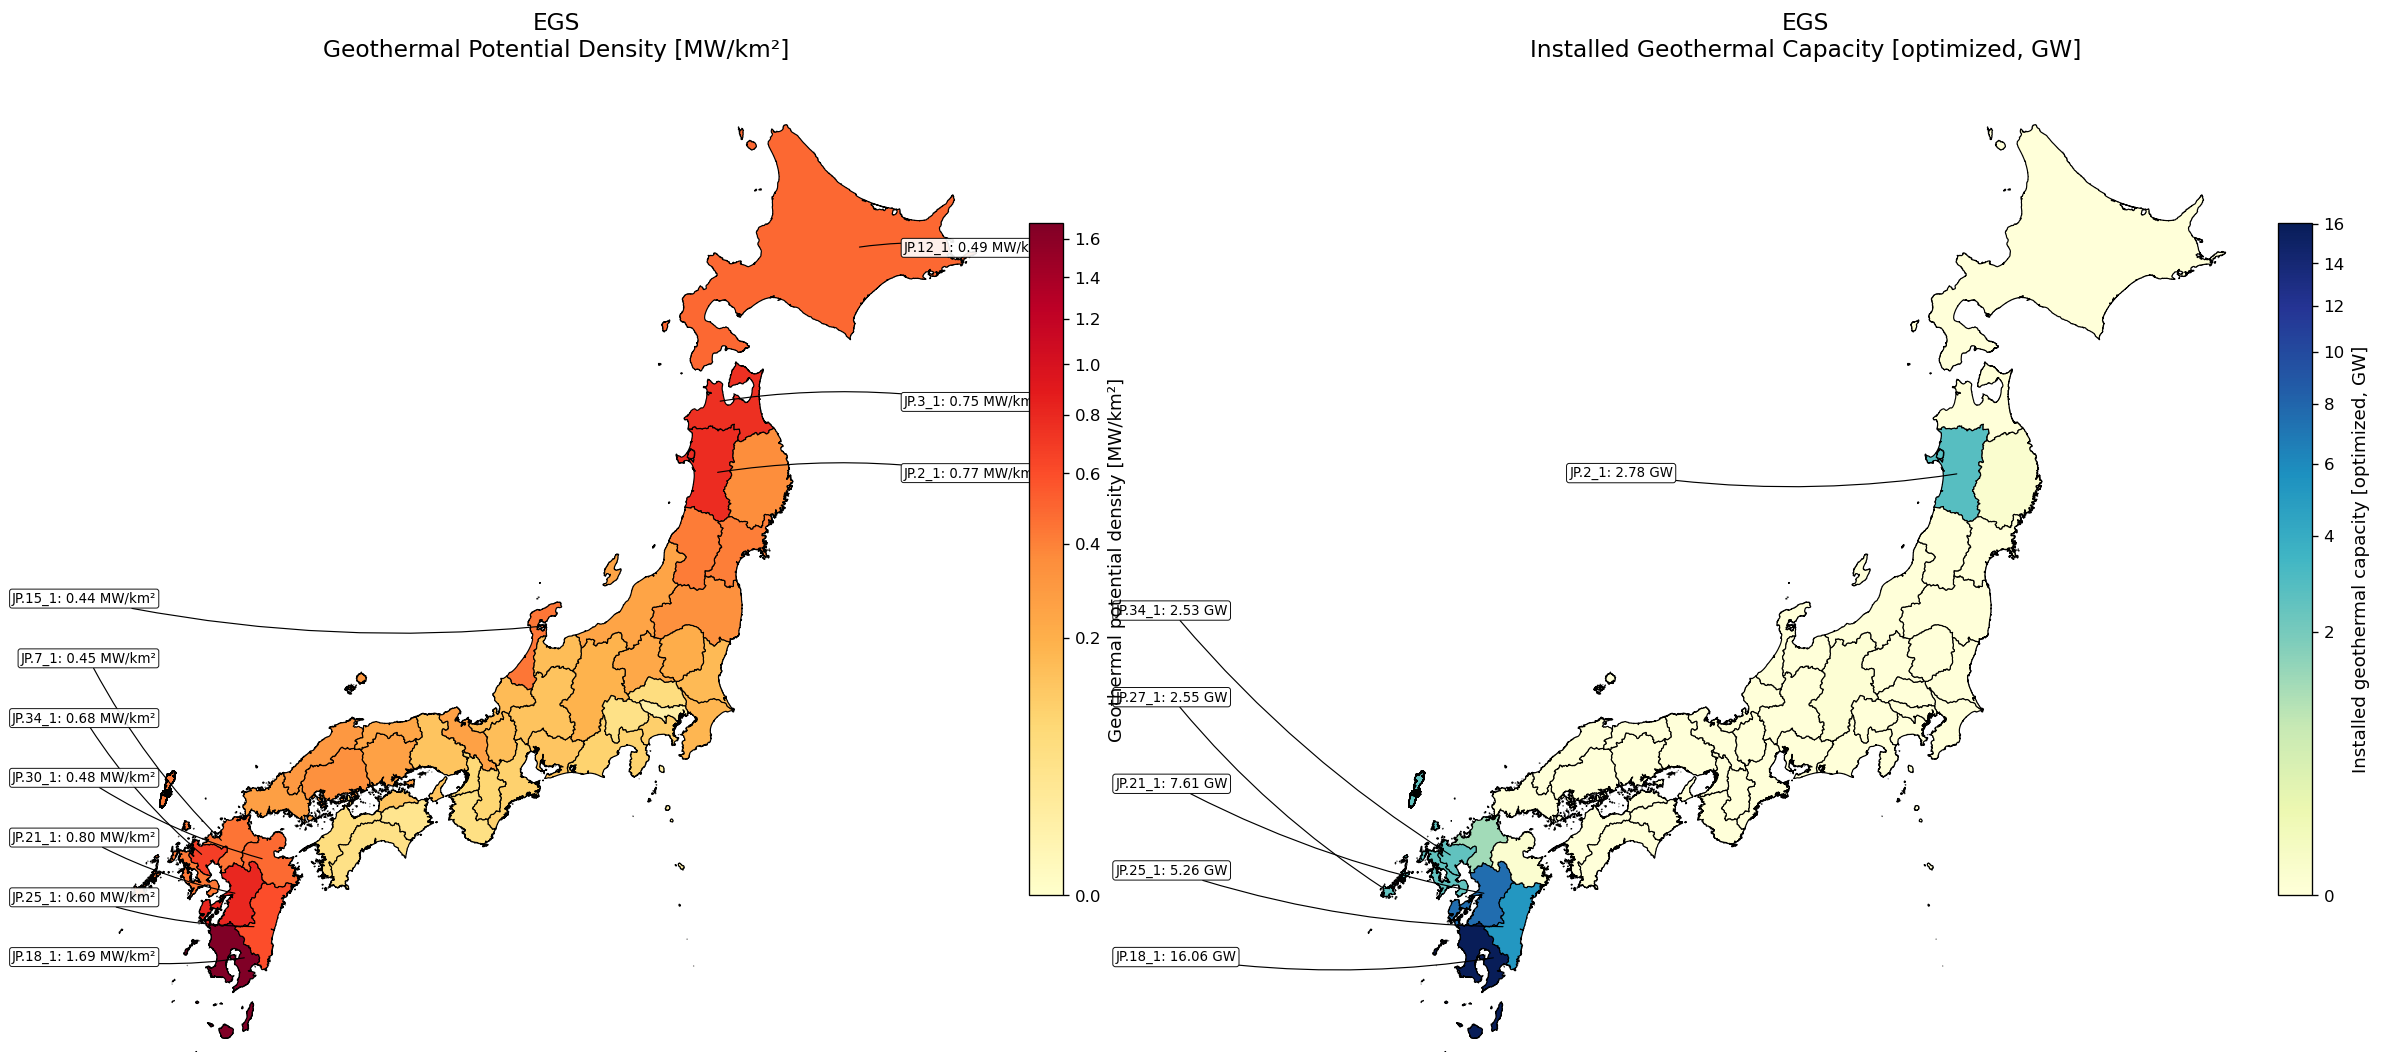

In [27]:
# ============================================================
# Geothermie-Karten für Szenario A
#
# Karte 1: Geothermisches Potenzial / Potenzialdichte
# Karte 2: Installierte bzw. optimierte Geothermie-Leistung
#
# Ohne LCOE/LCOH
# Ohne Tabellen-Output
#
# Netzwerk: n_a
# Geodaten: gadm_shapes bzw. GADM_SHAPES_PATH aus dem Notebook
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import fiona
from pathlib import Path


# ------------------------------------------------------------
# 0) Netzwerk und Szenario auswählen
# ------------------------------------------------------------

n = n_a

scenario_name = (
    SCENARIO_A_NAME
    if "SCENARIO_A_NAME" in globals()
    else "Szenario A"
)


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

EGS_POTENTIAL_PATH = Path(
    "/mnt/c/Users/nikla/Documents/Git/pypsa-earth-geothermal/resources/EGS_Test/egs_potentials_10_2050.csv"
)

potential_column = "p_nom_max"

# Falls p_nom_max in deiner CSV bereits in GW steht: "GW"
# Falls p_nom_max in MW steht: "MW"
potential_input_unit = "GW"

electric_bus_carriers = ["AC", "DC", "low voltage"]

# "optimized" = p_nom_opt, zukünftige / optimierte installierte Leistung
# "current" = p_nom, heutige / bestehende installierte Leistung
capacity_mode = "optimized"

simulation_gadm_level = 1

potential_density_cmap = "YlOrRd"
installed_capacity_cmap = "YlGnBu"

top_n_density_labels = 10
label_threshold_GW = 2.0

map_extent = [128.0, 146.5, 30.0, 46.5]


# ============================================================
# Helper: GADM robust laden
# ============================================================

def find_gadm_layer(gpkg_path, gadm_level):
    gpkg_path = Path(gpkg_path)

    target = f"ADM_ADM_{gadm_level}"
    layers = fiona.listlayers(str(gpkg_path))

    matches = [
        layer for layer in layers
        if layer.endswith(target) or target in layer
    ]

    if not matches:
        raise ValueError(
            f"Kein Layer für {target} in {gpkg_path} gefunden. "
            f"Vorhandene Layer: {layers}"
        )

    return matches[0]


def read_gadm_layer(gpkg_path, gadm_level):
    gpkg_path = Path(gpkg_path)

    if gpkg_path.suffix.lower() == ".gpkg":
        layer = find_gadm_layer(gpkg_path, gadm_level)
        gdf = gpd.read_file(gpkg_path, layer=layer)
    else:
        gdf = gpd.read_file(gpkg_path)

    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326")

    return gdf.to_crs("EPSG:4326")


def infer_region_id_col(gdf, gadm_level=1):
    candidates = [
        "GADM_ID",
        f"GID_{gadm_level}",
        "GID_2",
        "GID_1",
        "region",
        "name",
        "Name",
        "NAME_2",
        "NAME_1",
    ]

    for col in candidates:
        if col in gdf.columns:
            return col

    raise ValueError(
        "Keine passende Regions-ID-Spalte gefunden. "
        f"Vorhandene Spalten: {list(gdf.columns)}"
    )


# ============================================================
# Helper functions
# ============================================================

def get_capacity(df, nominal_col="p_nom", mode="optimized"):
    if mode == "optimized":
        opt_col = f"{nominal_col}_opt"

        if opt_col in df.columns:
            capacity = df[opt_col].copy()

            if nominal_col in df.columns:
                capacity = capacity.fillna(df[nominal_col])

            return capacity.fillna(0)

    if nominal_col in df.columns:
        return df[nominal_col].fillna(0)

    return pd.Series(0.0, index=df.index)


def bus_to_region(bus_name):
    """
    Convert PyPSA bus names to GADM region names.

    Examples:
    JP.10_1_AC                 -> JP.10_1
    JP.10_1 urban central heat -> JP.10_1
    JP.10_1 geothermal heat    -> JP.10_1
    JPN.10_1                   -> JP.10_1
    """
    s = str(bus_name).strip()

    match = pd.Series([s]).str.extract(r"^([A-Z]{2,3}\.\d+_\d+)")[0].iloc[0]

    if pd.notna(match):
        s = match

    suffixes = [
        "_AC",
        "_DC",
        " AC",
        " DC",
        " low voltage",
        "_low voltage",
        " urban central heat",
        "_urban central heat",
        " geothermal heat",
        "_geothermal heat",
        " heat",
        "_heat",
        " gas",
        "_gas",
        " oil",
        "_oil",
        " coal",
        "_coal",
        " biomass",
        "_biomass",
        " H2",
        "_H2",
    ]

    changed = True

    while changed:
        changed = False

        for suffix in suffixes:
            if s.endswith(suffix):
                s = s[: -len(suffix)].strip()
                changed = True

    if s.startswith("JPN."):
        s = "JP." + s[len("JPN."):]

    return s


def normalize_region_id(region_id):
    return bus_to_region(region_id)


def get_bus_columns(df):
    bus_cols = [
        col for col in df.columns
        if col.startswith("bus") and col[3:].isdigit()
    ]

    return sorted(
        bus_cols,
        key=lambda x: int(x.replace("bus", ""))
    )


# ------------------------------------------------------------
# 1) Load geothermal potential data
# ------------------------------------------------------------

egs_potentials = pd.read_csv(EGS_POTENTIAL_PATH)

if "region" not in egs_potentials.columns:
    raise ValueError(
        "Die EGS-Potenzialdatei enthält keine Spalte 'region'. "
        f"Vorhandene Spalten: {list(egs_potentials.columns)}"
    )

if potential_column not in egs_potentials.columns:
    raise ValueError(
        f"Die EGS-Potenzialdatei enthält keine Spalte '{potential_column}'. "
        f"Vorhandene Spalten: {list(egs_potentials.columns)}"
    )

egs_potentials["region_normalized"] = (
    egs_potentials["region"]
    .astype(str)
    .str.strip()
    .map(normalize_region_id)
)

if potential_input_unit.lower() == "mw":
    egs_potentials["geothermal_potential_GW"] = (
        egs_potentials[potential_column].fillna(0) / 1e3
    )
elif potential_input_unit.lower() == "gw":
    egs_potentials["geothermal_potential_GW"] = (
        egs_potentials[potential_column].fillna(0)
    )
else:
    raise ValueError("potential_input_unit muss 'MW' oder 'GW' sein.")


# ------------------------------------------------------------
# 2) Prepare GADM regions
# ------------------------------------------------------------

regions = gadm_shapes.copy()

if regions.crs is None:
    regions = regions.set_crs("EPSG:4326")

regions = regions.to_crs("EPSG:4326")

try:
    region_id_col = infer_region_id_col(
        regions,
        gadm_level=simulation_gadm_level
    )

except ValueError:
    regions = read_gadm_layer(
        GADM_SHAPES_PATH,
        simulation_gadm_level
    )

    region_id_col = infer_region_id_col(
        regions,
        gadm_level=simulation_gadm_level
    )

regions["region"] = (
    regions[region_id_col]
    .astype(str)
    .map(normalize_region_id)
)

potential_lookup = (
    egs_potentials
    .set_index("region_normalized")["geothermal_potential_GW"]
)

regions["geothermal_potential_GW"] = (
    regions["region"]
    .map(potential_lookup)
    .fillna(0)
)


# ------------------------------------------------------------
# 3) Calculate area-normalized geothermal potential
# ------------------------------------------------------------

regions_equal_area = regions.to_crs("EPSG:6933")

regions["area_km2"] = regions_equal_area.geometry.area / 1e6

regions["geothermal_potential_density_MW_per_km2"] = (
    regions["geothermal_potential_GW"] * 1e3
    / regions["area_km2"]
)

regions["geothermal_potential_density_MW_per_km2"] = (
    regions["geothermal_potential_density_MW_per_km2"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)


# ------------------------------------------------------------
# 4) Installed geothermal electricity capacity from generators
# ------------------------------------------------------------

generator_geo_capacity = pd.Series(dtype=float)

if hasattr(n, "generators") and len(n.generators) > 0:
    generators = n.generators.copy()

    generators = generators[
        generators.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
    ].copy()

    if not generators.empty:
        generators["bus_carrier"] = generators.bus.map(n.buses.carrier)

        generators = generators[
            generators["bus_carrier"].isin(electric_bus_carriers)
        ].copy()

        generators["capacity_MW"] = get_capacity(
            generators,
            "p_nom",
            mode=capacity_mode
        )

        generators["region"] = generators.bus.map(bus_to_region)

        generator_geo_capacity = (
            generators
            .groupby("region")["capacity_MW"]
            .sum()
        )


# ------------------------------------------------------------
# 5) Installed geothermal electricity capacity from links
# ------------------------------------------------------------

link_geo_capacity_parts = []

if hasattr(n, "links") and len(n.links) > 0:
    links = n.links.copy()

    links = links[
        links.carrier.astype(str).str.contains(
            "geothermal",
            case=False,
            regex=True,
            na=False
        )
    ].copy()

    if not links.empty:
        links["p_nom_final"] = get_capacity(
            links,
            "p_nom",
            mode=capacity_mode
        )

        bus_cols = get_bus_columns(links)

        for bus_col in bus_cols:
            bus_number = int(bus_col.replace("bus", ""))

            if bus_number == 0:
                continue

            if bus_number == 1:
                efficiency_col = "efficiency"
            else:
                efficiency_col = f"efficiency{bus_number}"

            output_bus_carrier = links[bus_col].map(n.buses.carrier)
            input_bus_carrier = links["bus0"].map(n.buses.carrier)

            mask = (
                output_bus_carrier.isin(electric_bus_carriers)
                & ~input_bus_carrier.isin(electric_bus_carriers)
            )

            if not mask.any():
                continue

            selected_links = links.loc[mask].copy()

            if efficiency_col in links.columns:
                if bus_number == 1:
                    efficiency = links.loc[mask, efficiency_col].fillna(1)
                else:
                    efficiency = links.loc[mask, efficiency_col].fillna(0)
            else:
                efficiency = 1 if bus_number == 1 else 0

            selected_links["capacity_MW"] = (
                selected_links["p_nom_final"]
                * efficiency
            )

            selected_links["region"] = selected_links[bus_col].map(bus_to_region)

            tmp = (
                selected_links
                .groupby("region")["capacity_MW"]
                .sum()
            )

            link_geo_capacity_parts.append(tmp)


if link_geo_capacity_parts:
    link_geo_capacity = (
        pd.concat(link_geo_capacity_parts)
        .groupby(level=0)
        .sum()
    )
else:
    link_geo_capacity = pd.Series(dtype=float)


# ------------------------------------------------------------
# 6) Merge installed geothermal electricity capacity onto regions
# ------------------------------------------------------------

installed_geo_capacity_by_region = (
    pd.concat(
        [
            generator_geo_capacity,
            link_geo_capacity,
        ],
        axis=0
    )
    .groupby(level=0)
    .sum()
)

regions["installed_geothermal_capacity_MW"] = (
    regions["region"]
    .map(installed_geo_capacity_by_region)
    .fillna(0)
)

regions["installed_geothermal_capacity_GW"] = (
    regions["installed_geothermal_capacity_MW"] / 1e3
)


# ------------------------------------------------------------
# 7) Plot two maps side by side
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 12),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

extent = map_extent


# ------------------------------------------------------------
# Left map: geothermal potential density
# ------------------------------------------------------------

left_col = "geothermal_potential_density_MW_per_km2"

if regions[left_col].max() > 0:
    left_norm = mcolors.PowerNorm(
        gamma=0.45,
        vmin=0,
        vmax=regions[left_col].max()
    )
else:
    left_norm = mcolors.Normalize(vmin=0, vmax=1)

regions.plot(
    column=left_col,
    ax=axes[0],
    cmap=potential_density_cmap,
    norm=left_norm,
    linewidth=0.7,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

axes[0].set_title(
    f"{scenario_name}\nGeothermal Potential Density [MW/km²]",
    fontsize=14
)

axes[0].set_extent(extent, crs=ccrs.PlateCarree())
axes[0].axis("off")


# ------------------------------------------------------------
# Right map: installed geothermal capacity
# ------------------------------------------------------------

right_col = "installed_geothermal_capacity_GW"

right_vmax = regions[right_col].max()

if right_vmax > 0:
    right_norm = mcolors.PowerNorm(
        gamma=0.45,
        vmin=0,
        vmax=right_vmax
    )
else:
    right_norm = mcolors.Normalize(vmin=0, vmax=1)

regions.plot(
    column=right_col,
    ax=axes[1],
    cmap=installed_capacity_cmap,
    norm=right_norm,
    linewidth=0.7,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

axes[1].set_title(
    f"{scenario_name}\nInstalled Geothermal Capacity [{capacity_mode}, GW]",
    fontsize=14
)

axes[1].set_extent(extent, crs=ccrs.PlateCarree())
axes[1].axis("off")


# ------------------------------------------------------------
# 8) Labels for top potential density regions
# ------------------------------------------------------------

min_density_label_spacing_deg = 1.0

top_density_regions = (
    regions
    .sort_values(left_col, ascending=False)
    .head(top_n_density_labels)
    .copy()
)

top_density_regions["label_point"] = top_density_regions.geometry.representative_point()
top_density_regions["lon"] = top_density_regions["label_point"].x
top_density_regions["lat"] = top_density_regions["label_point"].y

map_center_lon = (extent[0] + extent[1]) / 2

density_west_labels = top_density_regions[
    top_density_regions["lon"] < map_center_lon
].copy()

density_east_labels = top_density_regions[
    top_density_regions["lon"] >= map_center_lon
].copy()

density_west_text_lon = (
    density_west_labels["lon"].min() - 1.0
    if not density_west_labels.empty
    else None
)

density_east_text_lon = (
    density_east_labels["lon"].max() + 1.0
    if not density_east_labels.empty
    else None
)

if density_west_text_lon is not None:
    density_west_text_lon = max(density_west_text_lon, extent[0] + 0.4)

if density_east_text_lon is not None:
    density_east_text_lon = min(density_east_text_lon, extent[1] - 0.4)

density_lat_min = extent[2] + 0.5
density_lat_max = extent[3] - 0.5


def spread_density_label_positions(df, min_spacing=min_density_label_spacing_deg):
    if df.empty:
        return df

    df = df.sort_values("lat").copy()

    desired_y = df["lat"].to_numpy()
    adjusted_y = desired_y.copy()

    for i in range(1, len(adjusted_y)):
        if adjusted_y[i] - adjusted_y[i - 1] < min_spacing:
            adjusted_y[i] = adjusted_y[i - 1] + min_spacing

    overflow = adjusted_y[-1] - density_lat_max
    if overflow > 0:
        adjusted_y -= overflow

    for i in range(len(adjusted_y) - 2, -1, -1):
        if adjusted_y[i + 1] - adjusted_y[i] < min_spacing:
            adjusted_y[i] = adjusted_y[i + 1] - min_spacing

    underflow = density_lat_min - adjusted_y[0]
    if underflow > 0:
        adjusted_y += underflow

    df["text_lat"] = adjusted_y

    return df.sort_values("lat", ascending=False)


density_west_labels = spread_density_label_positions(density_west_labels)
density_east_labels = spread_density_label_positions(density_east_labels)

density_map_transform = ccrs.PlateCarree()._as_mpl_transform(axes[0])


def add_density_labels(df, text_lon, ha):
    if df.empty or text_lon is None:
        return

    for _, row in df.iterrows():
        lon = row["lon"]
        lat = row["lat"]
        text_lat = row["text_lat"]

        region_name = row["region"]
        density_value = row[left_col]

        label_text = f"{region_name}: {density_value:.2f} MW/km²"

        axes[0].annotate(
            label_text,
            xy=(lon, lat),
            xycoords=density_map_transform,
            xytext=(text_lon, text_lat),
            textcoords=density_map_transform,
            ha=ha,
            va="center",
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="black",
                linewidth=0.6,
                alpha=0.90
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="black",
                linewidth=0.7,
                shrinkA=0,
                shrinkB=3,
                connectionstyle="arc3,rad=0.08"
            ),
            zorder=10
        )


add_density_labels(
    density_west_labels,
    density_west_text_lon,
    ha="right"
)

add_density_labels(
    density_east_labels,
    density_east_text_lon,
    ha="left"
)


# ------------------------------------------------------------
# 9) Labels for installed capacity only
# ------------------------------------------------------------

min_label_spacing_deg = 1.45

label_regions = regions[
    regions[right_col] > label_threshold_GW
].copy()

label_regions["label_point"] = label_regions.geometry.representative_point()
label_regions["lon"] = label_regions["label_point"].x
label_regions["lat"] = label_regions["label_point"].y

west_labels = label_regions[label_regions["lon"] < 136.0].copy()
east_labels = label_regions[label_regions["lon"] >= 136.0].copy()

west_text_lon = west_labels["lon"].max() - 8.0 if not west_labels.empty else None
east_text_lon = east_labels["lon"].max() - 8.0 if not east_labels.empty else None

if west_text_lon is not None:
    west_text_lon = min(west_text_lon, extent[1] - 2.0)

if east_text_lon is not None:
    east_text_lon = min(east_text_lon, extent[1] - 1.0)

lat_min = extent[2] + 0.5
lat_max = extent[3] - 0.5


def spread_label_positions(df, min_spacing=min_label_spacing_deg):
    if df.empty:
        return df

    df = df.sort_values("lat").copy()

    desired_y = df["lat"].to_numpy()
    adjusted_y = desired_y.copy()

    for i in range(1, len(adjusted_y)):
        if adjusted_y[i] - adjusted_y[i - 1] < min_spacing:
            adjusted_y[i] = adjusted_y[i - 1] + min_spacing

    overflow = adjusted_y[-1] - lat_max
    if overflow > 0:
        adjusted_y -= overflow

    for i in range(len(adjusted_y) - 2, -1, -1):
        if adjusted_y[i + 1] - adjusted_y[i] < min_spacing:
            adjusted_y[i] = adjusted_y[i + 1] - min_spacing

    underflow = lat_min - adjusted_y[0]
    if underflow > 0:
        adjusted_y += underflow

    df["text_lat"] = adjusted_y

    return df.sort_values("lat", ascending=False)


west_labels = spread_label_positions(west_labels)
east_labels = spread_label_positions(east_labels)

map_transform = ccrs.PlateCarree()._as_mpl_transform(axes[1])


def add_capacity_labels(df, text_lon, ha="left"):
    if df.empty or text_lon is None:
        return

    for _, row in df.iterrows():
        lon = row["lon"]
        lat = row["lat"]
        text_lat = row["text_lat"]

        capacity = row[right_col]
        region_name = row["region"]

        label_text = f"{region_name}: {capacity:.2f} GW"

        axes[1].annotate(
            label_text,
            xy=(lon, lat),
            xycoords=map_transform,
            xytext=(text_lon, text_lat),
            textcoords=map_transform,
            ha=ha,
            va="center",
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.20",
                facecolor="white",
                edgecolor="black",
                linewidth=0.6,
                alpha=0.92
            ),
            arrowprops=dict(
                arrowstyle="-",
                color="black",
                linewidth=0.7,
                shrinkA=0,
                shrinkB=3,
                connectionstyle="arc3,rad=0.08"
            ),
            zorder=10
        )


add_capacity_labels(west_labels, west_text_lon, ha="left")
add_capacity_labels(east_labels, east_text_lon, ha="left")


# ------------------------------------------------------------
# 10) Colorbars
# ------------------------------------------------------------

sm_left = plt.cm.ScalarMappable(
    cmap=potential_density_cmap,
    norm=left_norm
)

sm_left.set_array([])

cbar_left = fig.colorbar(
    sm_left,
    ax=axes[0],
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar_left.set_label(
    "Geothermal potential density [MW/km²]",
    fontsize=11
)


sm_right = plt.cm.ScalarMappable(
    cmap=installed_capacity_cmap,
    norm=right_norm
)

sm_right.set_array([])

cbar_right = fig.colorbar(
    sm_right,
    ax=axes[1],
    orientation="vertical",
    fraction=0.035,
    pad=0.02
)

cbar_right.set_label(
    f"Installed geothermal capacity [{capacity_mode}, GW]",
    fontsize=11
)


plt.tight_layout()
plt.show()